In [1]:
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    roc_auc_score, 
    confusion_matrix, 
    balanced_accuracy_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)
from torch.utils.data import WeightedRandomSampler
from scipy.linalg import fractional_matrix_power
from sklearn.linear_model import LogisticRegression
import mne
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import torch


In [2]:
mne.set_log_level("WARNING")

class TUABDataset(Dataset):
    def __init__(self, normal_dir, abnormal_dir, cache_dir="./tuab_cache", mode="train", 
                 target_sfreq=250, epoch_len_sec=4.0, force_reprocess=False):
        super(TUABDataset, self).__init__()
        self.mode = mode
        self.target_sfreq = target_sfreq
        self.epoch_samples = int(target_sfreq * epoch_len_sec)
        self.cache_file = os.path.join(cache_dir, f"tuab_{mode}_data.pt")
        
        # Universal 19-Channel 10-20 Scalp System (Guaranteed across TUAB 01_tcp_ar)
        self.target_channels = [
            'FP1', 'FP2', 'F7', 'F3', 'FZ', 'F4', 'F8', 
            'T3', 'C3', 'CZ', 'C4', 'T4', 'T5', 
            'P3', 'PZ', 'P4', 'T6', 'O1', 'O2'
        ]
        
        if os.path.exists(self.cache_file) and not force_reprocess:
            print(f"[{mode.upper()}] Loading cached tensor dataset from {self.cache_file}...")
            cached_data = torch.load(self.cache_file)
            self.X = cached_data['X']
            self.Y = cached_data['Y']
        else:
            print(f"[{mode.upper()}] Processing raw EDF files from disk...")
            os.makedirs(cache_dir, exist_ok=True)
            
            normal_files = glob.glob(os.path.join(normal_dir, "**", "*.edf"), recursive=True)
            abnormal_files = glob.glob(os.path.join(abnormal_dir, "**", "*.edf"), recursive=True)
            
            print(f"Found {len(normal_files)} Normal files | {len(abnormal_files)} Abnormal files.")
            
            if len(normal_files) == 0 and len(abnormal_files) == 0:
                raise FileNotFoundError(
                    f"No .edf files found! Check directory paths:\n"
                    f"  Normal: {normal_dir}\n  Abnormal: {abnormal_dir}"
                )
            
            x_list, y_list = [], []
            skipped_files = 0
            
            # Process Normal (Class 0)
            for f in normal_files:
                epochs = self._process_edf(f)
                if epochs is not None:
                    x_list.append(epochs)
                    y_list.append(torch.zeros(epochs.shape[0], dtype=torch.long))
                else:
                    skipped_files += 1
                    
            # Process Abnormal (Class 1)
            for f in abnormal_files:
                epochs = self._process_edf(f)
                if epochs is not None:
                    x_list.append(epochs)
                    y_list.append(torch.ones(epochs.shape[0], dtype=torch.long))
                else:
                    skipped_files += 1
                    
            if len(x_list) == 0:
                raise RuntimeError(
                    f"Found {len(normal_files)+len(abnormal_files)} EDF files, but ALL were skipped "
                    f"during parsing. Check channel naming conventions or corrupted EDFs."
                )
                
            print(f"[{mode.upper()}] Successfully processed files. Skipped {skipped_files} incompatible files.")
            
            self.X = torch.cat(x_list, dim=0)
            self.Y = torch.cat(y_list, dim=0)
            
            print(f"[{mode.upper()}] Saving processed tensor {self.X.shape} to cache...")
            torch.save({'X': self.X, 'Y': self.Y}, self.cache_file)

    def _match_channel_names(self, raw_ch_names):
        mapping = {}
        for target in self.target_channels:
            matched = False
            for raw_ch in raw_ch_names:
                # Robust cleaning: Strips 'EEG ', 'POL ', '-REF', '-LE', '-AR', etc.
                clean_name = re.sub(r'^(EEG\s+|POL\s+)', '', raw_ch, flags=re.IGNORECASE)
                clean_name = re.sub(r'(-REF|-LE|-AR|-A1|-A2)$', '', clean_name, flags=re.IGNORECASE).strip().upper()
                
                # Handle standard 10-10 vs 10-20 synonym mappings
                if clean_name == 'T7': clean_name = 'T3'
                if clean_name == 'T8': clean_name = 'T4'
                if clean_name == 'P7': clean_name = 'T5'
                if clean_name == 'P8': clean_name = 'T6'
                
                if clean_name == target:
                    mapping[raw_ch] = target
                    matched = True
                    break
            if not matched:
                return None
        return mapping

    def _process_edf(self, filepath):
        try:
            # Added infer_types=True to help bypass TUAB date anonymization parsing errors
            raw = mne.io.read_raw_edf(filepath, preload=True, verbose=False)
            
            ch_map = self._match_channel_names(raw.ch_names)
            if ch_map is None:
                # Uncomment the next line to debug if a specific channel is constantly missing
                # print(f"Missing target channels in {filepath}. Available: {raw.ch_names}")
                return None
                
            # Safely handle MNE API changes (pick vs pick_channels)
            if hasattr(raw, 'pick'):
                raw.pick(list(ch_map.keys()))
            else:
                raw.pick_channels(list(ch_map.keys()))
                
            raw.rename_channels(ch_map)
            raw.reorder_channels(self.target_channels)
            
            raw.filter(l_freq=0.5, h_freq=45.0, phase='zero', verbose=False)
            if raw.info['sfreq'] != self.target_sfreq:
                raw.resample(self.target_sfreq, verbose=False)
                
            data = raw.get_data()
            n_epochs = data.shape[1] // self.epoch_samples
            if n_epochs == 0:
                return None
                
            data = data[:, :n_epochs * self.epoch_samples]
            data = data.reshape(len(self.target_channels), n_epochs, self.epoch_samples)
            data = np.transpose(data, (1, 0, 2))  # [N_epochs, 19, 1000]
            
            # Robust Z-Score Normalization (Fixed unpacking)
            median = np.median(data, axis=2, keepdims=True)
            pct75 = np.percentile(data, 75, axis=2, keepdims=True)
            pct25 = np.percentile(data, 25, axis=2, keepdims=True)
            iqr = (pct75 - pct25) + 1e-7
            
            norm_data = (data - median) / (iqr / 1.349)
            norm_data = np.clip(norm_data, -20.0, 20.0)
            
            return torch.tensor(norm_data, dtype=torch.float32)
            
        except Exception as e:
            # NEVER swallow errors silently during pipeline construction!
            print(f"Skipping {os.path.basename(filepath)} | Error: {type(e).__name__} - {str(e)}")
            return None

    def __len__(self):
        return len(self.Y)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

In [14]:
import os
import glob

In [ ]:

# WINDOWS DIRECTORY CONFIGURATION

base_dir = r"D:\project dissertation\project selection\v3.0.1\edf"
train_normal_dir   = os.path.join(base_dir, r"train\normal\01_tcp_ar")
train_abnormal_dir = os.path.join(base_dir, r"train\abnormal\01_tcp_ar")
eval_normal_dir    = os.path.join(base_dir, r"eval\normal\01_tcp_ar")
eval_abnormal_dir  = os.path.join(base_dir, r"eval\abnormal\01_tcp_ar")


# DATASET INITIALIZATION (FORCE REPROCESS)

print("Initializing TUAB Training Dataset...")
train_dataset = TUABDataset(
    normal_dir=train_normal_dir,
    abnormal_dir=train_abnormal_dir,
    mode="train",
    force_reprocess=True  # <-- FORCE REPROCESS to overwrite the old 21-channel cache!
)

print("\nInitializing TUAB Evaluation Dataset...")
eval_dataset = TUABDataset(
    normal_dir=eval_normal_dir,
    abnormal_dir=eval_abnormal_dir,
    mode="eval",
    force_reprocess=False # Already clean (19 channels), no need to re-run
)


# DATALOADER CREATION

batch_size = 64

train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True, 
    num_workers=0,      
    pin_memory=True,    
    drop_last=True      
)

eval_loader = DataLoader(
    eval_dataset, 
    batch_size=batch_size, 
    shuffle=False, 
    num_workers=0, 
    pin_memory=True
)

print(f"\n--- Layer 1 Loaders Ready ---")
print(f"Total Train Epochs: {len(train_dataset)} | Train Batches: {len(train_loader)}")
print(f"Total Eval Epochs:  {len(eval_dataset)} | Eval Batches:  {len(eval_loader)}")
print(f"Tensor Batch Shape: {next(iter(train_loader))[0].shape}  # Must be: [64, 19, 1000]")

Initializing TUAB Training Dataset...
[TRAIN] Processing raw EDF files from disk...
Found 1371 Normal files | 1346 Abnormal files.
[TRAIN] Successfully processed files. Skipped 0 incompatible files.
[TRAIN] Saving processed tensor torch.Size([933212, 19, 1000]) to cache...

Initializing TUAB Evaluation Dataset...
[EVAL] Processing raw EDF files from disk...
Found 150 Normal files | 126 Abnormal files.
[EVAL] Successfully processed files. Skipped 0 incompatible files.
[EVAL] Saving processed tensor torch.Size([92536, 19, 1000]) to cache...

--- Layer 1 Loaders Ready ---
Total Train Epochs: 933212 | Train Batches: 14581
Total Eval Epochs:  92536 | Eval Batches:  1446
Tensor Batch Shape: torch.Size([64, 19, 1000])  # Must be: [64, 19, 1000]


In [15]:


# 1. BASELINE: EEGNet-8,2

class EEGNet(nn.Module):
    def __init__(self, n_classes=2, channels=19, samples=1000, dropout=0.5, kern_length=125):
        super(EEGNet, self).__init__()
        self.F1 = 8
        self.D = 2
        self.F2 = self.F1 * self.D
        
        # Block 1: Temporal Conv -> Spatial Depthwise Conv
        self.conv1 = nn.Conv2d(1, self.F1, (1, kern_length), padding=(0, kern_length//2), bias=False)
        self.bn1 = nn.BatchNorm2d(self.F1)
        self.depthwise = nn.Conv2d(self.F1, self.F2, (channels, 1), groups=self.F1, bias=False)
        self.bn2 = nn.BatchNorm2d(self.F2)
        self.pool1 = nn.AvgPool2d((1, 4))
        self.dropout1 = nn.Dropout(dropout)
        
        # Block 2: Separable Conv
        self.separable_depth = nn.Conv2d(self.F2, self.F2, (1, 16), padding=(0, 8), groups=self.F2, bias=False)
        self.separable_point = nn.Conv2d(self.F2, self.F2, (1, 1), bias=False)
        self.bn3 = nn.BatchNorm2d(self.F2)
        self.pool2 = nn.AvgPool2d((1, 8))
        self.dropout2 = nn.Dropout(dropout)
        
        # Classifier
        feature_dim = samples // 32
        self.classifier = nn.Linear(self.F2 * feature_dim, n_classes)

    def forward(self, x):
        x = x.unsqueeze(1) # [B, 1, C, T]
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.depthwise(x)
        x = F.elu(self.bn2(x))
        x = self.dropout1(self.pool1(x))
        
        x = self.separable_depth(x)
        x = self.separable_point(x)
        x = F.elu(self.bn3(x))
        x = self.dropout2(self.pool2(x))
        
        x = x.flatten(start_dim=1)
        return self.classifier(x)


In [16]:

# 2. SPATIO-TEMPORAL TRANSFORMER

class SpatioTemporalTransformer(nn.Module):
    def __init__(self, n_classes=2, channels=19, samples=1000, d_model=64, n_heads=4, num_layers=2):
        super(SpatioTemporalTransformer, self).__init__()
        # Project raw time series per channel to embedding dimension
        self.temporal_patch_size = 25 # 100ms patches
        self.num_patches = samples // self.temporal_patch_size
        self.patch_proj = nn.Linear(self.temporal_patch_size, d_model)
        
        # Positional embeddings
        self.spatial_pos = nn.Parameter(torch.randn(1, channels, 1, d_model))
        self.temporal_pos = nn.Parameter(torch.randn(1, 1, self.num_patches, d_model))
        
        # Transformer Encoder Blocks
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=n_heads, dim_feedforward=d_model*4, batch_first=True)
        self.spatial_transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.temporal_transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        self.classifier = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.ReLU(),
            nn.Linear(32, n_classes)
        )

    def forward(self, x):
        B, C, T = x.shape
        x = x.view(B, C, self.num_patches, self.temporal_patch_size)
        x = self.patch_proj(x) + self.spatial_pos + self.temporal_pos # [B, C, P, D]
        
        # Spatial Attention across channels
        x = x.permute(0, 2, 1, 3).reshape(B * self.num_patches, C, -1)
        x = self.spatial_transformer(x)
        x = x.view(B, self.num_patches, C, -1).mean(dim=2) # Mean pool channels -> [B, P, D]
        
        # Temporal Attention across time patches
        x = self.temporal_transformer(x)
        x = x.mean(dim=1) # Global average pooling -> [B, D]
        return self.classifier(x)

In [17]:

# 3. GRAPH NEURAL NETWORK (ST-GCN)

class GraphConvolution(nn.Module):
    def __init__(self, in_features, out_features):
        super(GraphConvolution, self).__init__()
        self.weight = nn.Parameter(torch.FloatTensor(in_features, out_features))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, x, adj):
        # x: [B, C, T, F_in]
        support = torch.matmul(x, self.weight) # -> [B, C, T, F_out]
        
        # Route the graph adjacency multiplication over the Channel (C) dimension
        if adj.dim() == 2:
            # adj: [C, C] | support: [B, C, T, F] -> out: [B, C, T, F]
            return torch.einsum('vw, bwtf -> bvtf', adj, support)
        else:
            # Handle batched adjacency matrices if you use them later
            # adj: [B, C, C] | support: [B, C, T, F] -> out: [B, C, T, F]
            return torch.einsum('bvw, bwtf -> bvtf', adj, support)

class SpatioTemporalGNN(nn.Module):
    def __init__(self, n_classes=2, channels=19, samples=1000, hidden_dim=32):
        super(SpatioTemporalGNN, self).__init__()
        # Learnable Adjacency Matrix (captures functional brain connectivity)
        self.adj = nn.Parameter(torch.eye(channels) + torch.randn(channels, channels) * 0.01)
        
        self.gcn1 = GraphConvolution(1, hidden_dim)
        self.tcn1 = nn.Conv2d(hidden_dim, hidden_dim, (1, 9), padding=(0, 4))
        self.bn1 = nn.BatchNorm2d(hidden_dim)
        
        self.gcn2 = GraphConvolution(hidden_dim, hidden_dim * 2)
        self.tcn2 = nn.Conv2d(hidden_dim * 2, hidden_dim * 2, (1, 9), padding=(0, 4))
        self.bn2 = nn.BatchNorm2d(hidden_dim * 2)
        
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Linear(hidden_dim * 2, n_classes)

    def forward(self, x):
        B, C, T = x.shape
        x = x.unsqueeze(-1) # [B, C, T, 1]
        
        # Make adjacency matrix symmetric and normalized
        adj_sym = 0.5 * (self.adj + self.adj.T)
        deg = torch.sum(adj_sym, dim=1) + 1e-5
        deg_inv_sqrt = torch.diag(torch.pow(deg, -0.5))
        norm_adj = torch.mm(torch.mm(deg_inv_sqrt, adj_sym), deg_inv_sqrt)
        
        # Block 1: Spatial Graph Conv -> Temporal Conv
        x = F.relu(self.gcn1(x, norm_adj)) # [B, C, T, H]
        x = x.permute(0, 3, 1, 2) # [B, H, C, T] for Conv2d
        x = F.relu(self.bn1(self.tcn1(x)))
        x = F.max_pool2d(x, (1, 4))
        
        # Block 2
        x = x.permute(0, 2, 3, 1) # [B, C, T_new, H]
        x = F.relu(self.gcn2(x, norm_adj))
        x = x.permute(0, 3, 1, 2)
        x = F.relu(self.bn2(self.tcn2(x)))
        
        x = self.pool(x).flatten(start_dim=1)
        return self.classifier(x)

In [18]:

# 4. STANDARD SPATIAL GRAPH NEURAL NETWORK (STATIC BASELINE)

class GCNN(nn.Module):
    """
    Standalone Static-GNN Baseline for EEG Classification.
    Encapsulates a static learnable adjacency matrix and classifier 
    to match the benchmark signature: logits = model(x).
    """
    def __init__(self, n_classes=2, channels=19, samples=1000, hidden_dim=64):
        super(GCNN, self).__init__()
        # Learnable static adjacency matrix (no temporal dynamic updates)
        self.adj = nn.Parameter(torch.eye(channels) + torch.randn(channels, channels) * 0.01)
        
        # Treat raw time points as node features and transform spatial graph nodes
        self.weight1 = nn.Parameter(torch.FloatTensor(samples, hidden_dim))
        self.weight2 = nn.Parameter(torch.FloatTensor(hidden_dim, hidden_dim))
        nn.init.xavier_uniform_(self.weight1)
        nn.init.xavier_uniform_(self.weight2)
        
        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, n_classes)
        )

    def _normalize_adj(self, adj):
        """Symmetric normalization: D^{-0.5} * A * D^{-0.5}"""
        adj_sym = 0.5 * (adj + adj.T)
        deg = torch.sum(adj_sym, dim=1) + 1e-5
        deg_inv_sqrt = torch.diag(torch.pow(deg, -0.5))
        return torch.mm(torch.mm(deg_inv_sqrt, adj_sym), deg_inv_sqrt)

    def forward(self, x):
        # x shape: [B, C, T] -> Channels (C) are graph nodes, Time (T) are initial node features
        norm_adj = self._normalize_adj(self.adj)
        
        # Layer 1: Spatial graph convolution across channels
        support1 = torch.matmul(x, self.weight1)  # [B, C, hidden_dim]
        out1 = F.relu(torch.einsum('ij, bjf -> bif', norm_adj, support1))
        
        # Layer 2: Spatial graph convolution
        support2 = torch.matmul(out1, self.weight2)  # [B, C, hidden_dim]
        out2 = F.relu(torch.einsum('ij, bjf -> bif', norm_adj, support2))
        
        # Global node pooling (average across all channels/electrodes) -> [B, hidden_dim]
        pooled = out2.mean(dim=1)
        
        return self.classifier(pooled)

In [19]:


def benchmark_layer1(models_dict, train_loader, val_loader, epochs=5, lr=5e-4):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    use_amp = torch.cuda.is_available()
    # Modern PyTorch AMP syntax
    scaler = torch.amp.GradScaler('cuda', enabled=use_amp)
    
    print(f"\n=======================================================")
    print(f"EXECUTING LAYER 1 CLINICAL BENCHMARK ON: {device.type.upper()}")
    print(f"Dataset Size: {len(train_loader.dataset):,} Train Epochs | {len(val_loader.dataset):,} Eval Epochs")
    print(f"=======================================================\n")
    
    benchmark_report = {}

    for name, model in models_dict.items():
        print(f"--> Training Architecture: [{name}]")
        model.to(device)
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
        criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
        
        for epoch in range(epochs):
            model.train()
            running_loss = 0.0
            
            for batch_idx, (x_batch, y_batch) in enumerate(train_loader):
                x_batch, y_batch = x_batch.to(device, non_blocking=True), y_batch.to(device, non_blocking=True)
                optimizer.zero_grad()
                
                with torch.amp.autocast('cuda', enabled=use_amp):
                    out = model(x_batch)
                    loss = criterion(out, y_batch)
                
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
                
                running_loss += loss.item()
                if (batch_idx + 1) % 3000 == 0:
                    print(f"    Epoch [{epoch+1}/{epochs}] | Batch [{batch_idx+1:,}/{len(train_loader):,}] | Loss: {running_loss/(batch_idx+1):.4f}")
                    
        # --- Clinical Evaluation ---
        print(f"    Evaluating [{name}] on {len(val_loader.dataset):,} unseen eval epochs...")
        model.eval()
        all_preds, all_targets, all_probs = [], [], []
        
        with torch.no_grad():
            for x_val, y_val in val_loader:
                x_val = x_val.to(device, non_blocking=True)
                with torch.amp.autocast('cuda', enabled=use_amp):
                    logits = model(x_val)
                    probs = F.softmax(logits, dim=1)[:, 1]
                    preds = torch.argmax(logits, dim=1)
                
                all_preds.extend(preds.cpu().numpy())
                all_targets.extend(y_val.numpy())
                all_probs.extend(probs.cpu().numpy())
                
        # Calculate Clinical Metrics
        tn, fp, fn, tp = confusion_matrix(all_targets, all_preds).ravel()
        
        accuracy = accuracy_score(all_targets, all_preds)
        bal_acc = balanced_accuracy_score(all_targets, all_preds)
        precision = precision_score(all_targets, all_preds, zero_division=0)
        recall = recall_score(all_targets, all_preds, zero_division=0) # Identical to Sensitivity
        specificity = tn / (tn + fp + 1e-7)
        f1 = f1_score(all_targets, all_preds, zero_division=0)
        roc_auc = roc_auc_score(all_targets, all_probs)
        
        # Generate full classification report string
        clf_report = classification_report(
            all_targets, 
            all_preds, 
            target_names=["Normal (0)", "Abnormal (1)"], 
            zero_division=0
        )
        
        benchmark_report[name] = {
            "Accuracy": accuracy,
            "Balanced Accuracy": bal_acc,
            "Precision": precision,
            "Recall (Sensitivity)": recall,
            "Specificity": specificity,
            "F1-Score": f1,
            "ROC-AUC": roc_auc,
            "Confusion Matrix": {"TN": tn, "FP": fp, "FN": fn, "TP": tp},
            "Classification Report": clf_report
        }
        
        print(f"    [RESULT SUMMARY]")
        print(f"    Accuracy:     {accuracy:.4f} | Balanced Acc: {bal_acc:.4f} | ROC-AUC: {roc_auc:.4f}")
        print(f"    Precision:    {precision:.4f} | Recall (Sens): {recall:.4f} | Spec:    {specificity:.4f}")
        print(f"    F1-Score:     {f1:.4f}")
        print(f"\n    [CLASSIFICATION REPORT]\n{clf_report}\n")
        print("="*60 + "\n")
        
    return benchmark_report

In [10]:
models_to_test = {
    "1. Static-GNN (Failure Baseline)": GCNN(channels=19),
    "2. EEGNet-8,2 (Conv Baseline)": EEGNet(channels=19),
    "3. ST-Transformer (Attention)": SpatioTemporalTransformer(channels=19),
    "4. ST-GNN (Topological Time-Series)": SpatioTemporalGNN(channels=19)
}

# Run the comparative benchmark


In [11]:
resultsgnn = benchmark_layer1({"1. Static-GNN (Failure Baseline)": GCNN(channels=19)}, train_loader, eval_loader, epochs=5, lr=5e-4)
resultseegnet = benchmark_layer1({"2. EEGNet-8,2 (Conv Baseline)": EEGNet(channels=19)}, train_loader, eval_loader, epochs=5, lr=5e-4)
resultstransformer = benchmark_layer1({"3. ST-Transformer (Attention)": SpatioTemporalTransformer(channels=19)}, train_loader, eval_loader, epochs=5, lr=5e-4)
resultsstgnn = benchmark_layer1({"4. ST-GNN (Topological Time-Series)": SpatioTemporalGNN(channels=19)}, train_loader, eval_loader, epochs=5, lr=5e-4)


EXECUTING LAYER 1 CLINICAL BENCHMARK ON: CUDA
Dataset Size: 933,212 Train Epochs | 92,536 Eval Epochs

--> Training Architecture: [1. Static-GNN (Failure Baseline)]
    Epoch [1/5] | Batch [3,000/14,581] | Loss: 0.5907
    Epoch [1/5] | Batch [6,000/14,581] | Loss: 0.5771
    Epoch [1/5] | Batch [9,000/14,581] | Loss: 0.5703
    Epoch [1/5] | Batch [12,000/14,581] | Loss: 0.5656
    Epoch [2/5] | Batch [3,000/14,581] | Loss: 0.5396
    Epoch [2/5] | Batch [6,000/14,581] | Loss: 0.5402
    Epoch [2/5] | Batch [9,000/14,581] | Loss: 0.5389
    Epoch [2/5] | Batch [12,000/14,581] | Loss: 0.5383
    Epoch [3/5] | Batch [3,000/14,581] | Loss: 0.5277
    Epoch [3/5] | Batch [6,000/14,581] | Loss: 0.5282
    Epoch [3/5] | Batch [9,000/14,581] | Loss: 0.5283
    Epoch [3/5] | Batch [12,000/14,581] | Loss: 0.5285
    Epoch [4/5] | Batch [3,000/14,581] | Loss: 0.5216
    Epoch [4/5] | Batch [6,000/14,581] | Loss: 0.5219
    Epoch [4/5] | Batch [9,000/14,581] | Loss: 0.5222
    Epoch [4/5] | Bat

RuntimeError: mat1 and mat2 shapes cannot be multiplied (38912x1000 and 19x19)

In [13]:
resultsstgnn = benchmark_layer1({"4. ST-GNN (Topological Time-Series)": SpatioTemporalGNN(channels=19)}, train_loader, eval_loader, epochs=5, lr=5e-4)


EXECUTING LAYER 1 CLINICAL BENCHMARK ON: CUDA
Dataset Size: 933,212 Train Epochs | 92,536 Eval Epochs

--> Training Architecture: [4. ST-GNN (Topological Time-Series)]
    Epoch [1/5] | Batch [3,000/14,581] | Loss: 0.5281
    Epoch [1/5] | Batch [6,000/14,581] | Loss: 0.5152
    Epoch [1/5] | Batch [9,000/14,581] | Loss: 0.5071
    Epoch [1/5] | Batch [12,000/14,581] | Loss: 0.5013
    Epoch [2/5] | Batch [3,000/14,581] | Loss: 0.4737
    Epoch [2/5] | Batch [6,000/14,581] | Loss: 0.4709
    Epoch [2/5] | Batch [9,000/14,581] | Loss: 0.4702
    Epoch [2/5] | Batch [12,000/14,581] | Loss: 0.4688
    Epoch [3/5] | Batch [3,000/14,581] | Loss: 0.4605
    Epoch [3/5] | Batch [6,000/14,581] | Loss: 0.4602
    Epoch [3/5] | Batch [9,000/14,581] | Loss: 0.4598
    Epoch [3/5] | Batch [12,000/14,581] | Loss: 0.4589
    Epoch [4/5] | Batch [3,000/14,581] | Loss: 0.4535
    Epoch [4/5] | Batch [6,000/14,581] | Loss: 0.4534
    Epoch [4/5] | Batch [9,000/14,581] | Loss: 0.4532
    Epoch [4/5] | 

In [ ]:
"""
# Create a directory to store your models
save_dir = "./saved_models"
os.makedirs(save_dir, exist_ok=True)

# Assuming your models are in a dictionary like this:
trained_models = {
    "Static-GNN": gcnn_model,          # Replace with your actual model variable
    "EEGNet": eegnet_model,            # Replace with your actual model variable
    "ST-Transformer": transformer_model, # Replace with your actual model variable
    "ST-GNN": stgnn_model              # Replace with your actual model variable
}

print("Saving models...")
for name, model in trained_models.items():
    # .pt or .pth is the standard PyTorch extension
    save_path = os.path.join(save_dir, f"{name}.pt")
    
    # Save only the weights (state_dict)
    torch.save(model.state_dict(), save_path)
    print(f"Saved {name} to {save_path}")"""

In [ ]:
"""device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Initialize the empty model exactly as you did before training
loaded_eegnet = EEGNet(channels=19).to(device)

# 2. Load the weights from the file
weights_path = "./saved_models/EEGNet.pt"
loaded_eegnet.load_state_dict(torch.load(weights_path, weights_only=True))

# 3. CRITICAL: Set the model to evaluation mode
# This turns off Dropout and sets BatchNorm to evaluation mode
loaded_eegnet.eval()

# 4. Make predictions
with torch.no_grad():
    sample_data = torch.randn(1, 19, 1000).to(device) # Example input
    logits = loaded_eegnet(sample_data)
    prediction = torch.argmax(logits, dim=1)
    print(f"Predicted Class: {prediction.item()}")"""

In [ ]:
"""# 1. Initialize empty model and load weights
model_to_retrain = EEGNet(channels=19).to(device)
model_to_retrain.load_state_dict(torch.load("./saved_models/EEGNet.pt", weights_only=True))

# 2. CRITICAL: Set model to training mode (turns Dropout and BatchNorm back on)
model_to_retrain.train()

# 3. Create a NEW optimizer, passing it the loaded model's parameters
# Note: Since you are fine-tuning, you usually want a smaller learning rate
optimizer = torch.optim.AdamW(model_to_retrain.parameters(), lr=1e-5)
criterion = nn.CrossEntropyLoss()

# 4. Resume your training loop
# for batch_idx, (x, y) in enumerate(new_train_loader):
#     ..."""

OPTIMIZED ARCHITECTURES

In [ ]:
"""import os

def train_with_checkpoints(model, train_loader, val_loader, name, epochs=5, lr=5e-4):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    use_amp = torch.cuda.is_available()
    scaler = torch.amp.GradScaler('cuda', enabled=use_amp)
    
    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    
    checkpoint_dir = "./checkpoints"
    os.makedirs(checkpoint_dir, exist_ok=True)
    
    best_val_loss = float('inf')

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        
        for batch_idx, (x_batch, y_batch) in enumerate(train_loader):
            # ... [Your standard training forward/backward passes here] ...
            pass
            
        epoch_loss = running_loss / len(train_loader)
        
        # --- 1. CREATE THE CHECKPOINT DICTIONARY ---
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scaler_state_dict': scaler.state_dict(),
            'loss': epoch_loss,
        }
        
        # --- 2. SAVE LATEST CHECKPOINT (Overwrites every epoch) ---
        latest_path = os.path.join(checkpoint_dir, f"{name}_latest.pt")
        torch.save(checkpoint, latest_path)
        print(f"Saved latest checkpoint to {latest_path}")
        
        # --- 3. SAVE BEST CHECKPOINT (Optional: Track validation metric) ---
        # Assuming you calculate `val_loss` during your eval phase:
        val_loss = 0.45 # Example placeholder
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_path = os.path.join(checkpoint_dir, f"{name}_best.pt")
            torch.save(checkpoint, best_path)
            print(f"*** New best model saved to {best_path} ***")"""

In [ ]:
"""def resume_training(model_class, checkpoint_path, train_loader, epochs_remaining):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # 1. Initialize the empty architectures
    model = model_class(channels=19).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4) # LR will be overwritten by state_dict
    scaler = torch.amp.GradScaler('cuda', enabled=torch.cuda.is_available())
    
    # 2. Load the checkpoint dictionary
    print(f"Loading checkpoint from {checkpoint_path}...")
    checkpoint = torch.load(checkpoint_path, weights_only=True)
    
    # 3. Inject states into the initialized objects
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scaler.load_state_dict(checkpoint['scaler_state_dict'])
    
    start_epoch = checkpoint['epoch'] + 1
    previous_loss = checkpoint['loss']
    
    print(f"Successfully resumed! Starting from Epoch {start_epoch} (Previous Loss: {previous_loss:.4f})")
    
    # 4. Resume the training loop
    for epoch in range(start_epoch, start_epoch + epochs_remaining):
        model.train()
        # ... continue your training loop as normal ..."""

In [20]:


 
# 1. ARCHITECTURE REGISTRY (19 Channels + Tensor-Safe Einsum GCN)
 

class GraphConvolution(nn.Module):
    def __init__(self, in_features, out_features):
        super(GraphConvolution, self).__init__()
        self.weight = nn.Parameter(torch.FloatTensor(in_features, out_features))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, x, adj):
        support = torch.matmul(x, self.weight)
        if support.dim() == 3:
            return torch.einsum('ij, bjf -> bif', adj, support)
        elif support.dim() == 4:
            return torch.einsum('ij, bjtf -> bitf', adj, support)
        else:
            raise ValueError(f"Unsupported tensor dimension for GCN: {support.dim()}")

class StandardSpatialGNN(nn.Module):
    def __init__(self, n_classes=2, channels=19, in_features=4, hidden_dim=32):
        super(StandardSpatialGNN, self).__init__()
        self.adj = nn.Parameter(torch.eye(channels) + torch.randn(channels, channels) * 0.01)
        self.gcn1 = GraphConvolution(in_features, hidden_dim)
        self.gcn2 = GraphConvolution(hidden_dim, hidden_dim * 2)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2 * channels, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, n_classes)
        )

    def extract_static_node_features(self, x):
        mean = torch.mean(x, dim=-1, keepdim=True)
        std = torch.std(x, dim=-1, keepdim=True)
        var = torch.var(x, dim=-1, keepdim=True)
        max_amp = torch.max(torch.abs(x), dim=-1, keepdim=True)[0]
        return torch.cat([mean, std, var, max_amp], dim=-1)

    def forward(self, x):
        node_feats = self.extract_static_node_features(x)
        adj_sym = 0.5 * (self.adj + self.adj.T)
        deg = torch.sum(adj_sym, dim=1) + 1e-5
        norm_adj = torch.mm(torch.mm(torch.diag(torch.pow(deg, -0.5)), adj_sym), torch.diag(torch.pow(deg, -0.5)))
        h1 = F.relu(self.gcn1(node_feats, norm_adj))
        h2 = F.relu(self.gcn2(h1, norm_adj))
        
        # FIXED: Replaced .view() with .reshape() or .flatten() to handle non-contiguous einsum output
        return self.classifier(h2.flatten(start_dim=1))

class EEGNet(nn.Module):
    def __init__(self, n_classes=2, channels=19, samples=1000, dropout=0.5, kern_length=125):
        super(EEGNet, self).__init__()
        self.F1 = 8
        self.D = 2
        self.F2 = self.F1 * self.D
        self.conv1 = nn.Conv2d(1, self.F1, (1, kern_length), padding=(0, kern_length//2), bias=False)
        self.bn1 = nn.BatchNorm2d(self.F1)
        self.depthwise = nn.Conv2d(self.F1, self.F2, (channels, 1), groups=self.F1, bias=False)
        self.bn2 = nn.BatchNorm2d(self.F2)
        self.pool1 = nn.AvgPool2d((1, 4))
        self.dropout1 = nn.Dropout(dropout)
        self.separable_depth = nn.Conv2d(self.F2, self.F2, (1, 16), padding=(0, 8), groups=self.F2, bias=False)
        self.separable_point = nn.Conv2d(self.F2, self.F2, (1, 1), bias=False)
        self.bn3 = nn.BatchNorm2d(self.F2)
        self.pool2 = nn.AvgPool2d((1, 8))
        self.dropout2 = nn.Dropout(dropout)
        feature_dim = samples // 32
        self.classifier = nn.Linear(self.F2 * feature_dim, n_classes)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.dropout1(self.pool1(F.elu(self.bn2(self.depthwise(self.bn1(self.conv1(x)))))))
        x = self.dropout2(self.pool2(F.elu(self.bn3(self.separable_point(self.separable_depth(x))))))
        return self.classifier(x.flatten(start_dim=1))

class SpatioTemporalTransformer(nn.Module):
    def __init__(self, n_classes=2, channels=19, samples=1000, d_model=64, n_heads=4, num_layers=2):
        super(SpatioTemporalTransformer, self).__init__()
        self.temporal_patch_size = 25
        self.num_patches = samples // self.temporal_patch_size
        self.patch_proj = nn.Linear(self.temporal_patch_size, d_model)
        self.spatial_pos = nn.Parameter(torch.randn(1, channels, 1, d_model))
        self.temporal_pos = nn.Parameter(torch.randn(1, 1, self.num_patches, d_model))
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=n_heads, dim_feedforward=d_model*4, batch_first=True)
        self.spatial_transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.temporal_transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.classifier = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.ReLU(),
            nn.Linear(32, n_classes)
        )

    def forward(self, x):
        B, C, T = x.shape
        # FIXED: Replaced .view() with .reshape() to prevent permute/attention contiguity crashes
        x = x.reshape(B, C, self.num_patches, self.temporal_patch_size)
        x = self.patch_proj(x) + self.spatial_pos + self.temporal_pos
        x = x.permute(0, 2, 1, 3).reshape(B * self.num_patches, C, -1)
        x = self.spatial_transformer(x)
        x = x.reshape(B, self.num_patches, C, -1).mean(dim=2)
        x = self.temporal_transformer(x)
        return self.classifier(x.mean(dim=1))

class SpatioTemporalGNN(nn.Module):
    def __init__(self, n_classes=2, channels=19, samples=1000, hidden_dim=32):
        super(SpatioTemporalGNN, self).__init__()
        self.adj = nn.Parameter(torch.eye(channels) + torch.randn(channels, channels) * 0.01)
        self.gcn1 = GraphConvolution(1, hidden_dim)
        self.tcn1 = nn.Conv2d(hidden_dim, hidden_dim, (1, 9), padding=(0, 4))
        self.bn1 = nn.BatchNorm2d(hidden_dim)
        self.gcn2 = GraphConvolution(hidden_dim, hidden_dim * 2)
        self.tcn2 = nn.Conv2d(hidden_dim * 2, hidden_dim * 2, (1, 9), padding=(0, 4))
        self.bn2 = nn.BatchNorm2d(hidden_dim * 2)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Linear(hidden_dim * 2, n_classes)

    def forward(self, x):
        B, C, T = x.shape
        x = x.unsqueeze(-1)
        adj_sym = 0.5 * (self.adj + self.adj.T)
        deg = torch.sum(adj_sym, dim=1) + 1e-5
        norm_adj = torch.mm(torch.mm(torch.diag(torch.pow(deg, -0.5)), adj_sym), torch.diag(torch.pow(deg, -0.5)))
        x = F.relu(self.gcn1(x, norm_adj)).permute(0, 3, 1, 2)
        x = F.max_pool2d(F.relu(self.bn1(self.tcn1(x))), (1, 4))
        x = x.permute(0, 2, 3, 1)
        x = F.relu(self.gcn2(x, norm_adj)).permute(0, 3, 1, 2)
        x = F.relu(self.bn2(self.tcn2(x)))
        return self.classifier(self.pool(x).flatten(start_dim=1))




In [21]:
 
# 2. OPTIMIZATION PILLARS: AUGMENTATION, FOCAL LOSS & STRATIFIED SAMPLER
 

class EEGAugmenter(nn.Module):
    def __init__(self, channel_dropout_rate=0.1, noise_std=0.01):
        super(EEGAugmenter, self).__init__()
        self.p = channel_dropout_rate
        self.noise_std = noise_std

    def forward(self, x):
        if not self.training:
            return x
        if self.p > 0:
            mask = (torch.rand(x.size(0), x.size(1), 1, device=x.device) > self.p).float()
            x = x * mask / (1.0 - self.p)
        if self.noise_std > 0:
            noise = torch.randn_like(x) * self.noise_std
            x = x + noise
        return x

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', label_smoothing=0.05)
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1.0 - pt)**self.gamma * ce_loss
        return focal_loss.mean()

def get_stratified_loader(dataset, batch_size=64, num_workers=0):
    print("Computing class weights for stratified mini-batch sampling...")
    targets = dataset.Y.cpu().numpy() if hasattr(dataset.Y, 'cpu') else np.array(dataset.Y)
    class_counts = np.bincount(targets)
    total_samples = len(targets)
    
    class_weights = total_samples / (len(class_counts) * class_counts)
    sample_weights = class_weights[targets]
    
    sampler = WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=total_samples,
        replacement=True
    )
    
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        sampler=sampler,
        num_workers=num_workers,
        pin_memory=True,
        drop_last=True
    )
    print(f"--> Stratified Loader Ready | Counts: {class_counts} | Weights: {class_weights.round(4)}\n")
    return loader


In [22]:
 
# 3. UNIVERSAL ENSEMBLE GATEKEEPER
 

class UniversalEnsemble(nn.Module):
    def __init__(self, models_list, weights=None):
        super(UniversalEnsemble, self).__init__()
        self.models = nn.ModuleList(models_list)
        if weights is None:
            self.weights = [1.0 / len(models_list)] * len(models_list)
        else:
            self.weights = [w / sum(weights) for w in weights]

    def forward(self, x):
        blended_logits = 0.0
        for i, model in enumerate(self.models):
            blended_logits += self.weights[i] * model(x)
        return blended_logits


In [ ]:
def benchmark_all_optimized(models_dict, train_loader, val_loader, epochs=4, lr=3e-4):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    use_amp = torch.cuda.is_available()
    scaler = torch.amp.GradScaler('cuda', enabled=use_amp)

    print(f" ============================")
    print(f"EXECUTING OPTIMIZED BENCHMARK ON: {device.type.upper()}")
    print(f"Strategy: Stratified Sampling + Focal Loss + Augmentation")
    print(f"=======================================================\n")

    benchmark_report = {}
    trained_models = {} # Changed to a dictionary for easier saving later

    for name, model in models_dict.items():
        print(f"--> Training Architecture: [{name}]")
        model.to(device)
        
        # Only initialize Optimizers and Schedulers if we are actually training
        if epochs > 0:
            augmenter = EEGAugmenter(channel_dropout_rate=0.1, noise_std=0.01).to(device)
            optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs*len(train_loader))
            criterion = FocalLoss(alpha=0.25, gamma=2.0)

            for epoch in range(epochs):
                model.train()
                augmenter.train()
                running_loss = 0.0

                for batch_idx, (x_batch, y_batch) in enumerate(train_loader):
                    x_batch, y_batch = x_batch.to(device, non_blocking=True), y_batch.to(device, non_blocking=True)
                    optimizer.zero_grad()

                    x_aug = augmenter(x_batch)
                    with torch.amp.autocast('cuda', enabled=use_amp):
                        out = model(x_aug)
                        loss = criterion(out, y_batch)

                    scaler.scale(loss).backward()
                    scaler.step(optimizer)
                    scaler.update()
                    scheduler.step()

                    running_loss += loss.item()
                    if (batch_idx + 1) % 3000 == 0:
                        print(f"    Epoch [{epoch+1}/{epochs}] | Batch [{batch_idx+1:,}/{len(train_loader):,}] | Focal Loss: {running_loss/(batch_idx+1):.4f}")

        # Evaluation Block (Runs whether epochs > 0 or epochs == 0)
        print(f"    Evaluating [{name}] on unseen eval dataset...")
        model.eval()
        all_preds, all_targets, all_probs = [], [], []

        with torch.no_grad():
            for x_val, y_val in val_loader:
                x_val = x_val.to(device, non_blocking=True)
                with torch.amp.autocast('cuda', enabled=use_amp):
                    logits = model(x_val)
                    probs = F.softmax(logits, dim=1)[:, 1]
                    preds = torch.argmax(logits, dim=1)

                all_preds.extend(preds.cpu().numpy())
                all_targets.extend(y_val.numpy())
                all_probs.extend(probs.cpu().numpy())

        tn, fp, fn, tp = confusion_matrix(all_targets, all_preds).ravel()
        accuracy = accuracy_score(all_targets, all_preds)
        bal_acc = balanced_accuracy_score(all_targets, all_preds)
        precision = precision_score(all_targets, all_preds, zero_division=0)
        recall = recall_score(all_targets, all_preds, zero_division=0)
        specificity = tn / (tn + fp + 1e-7)
        f1 = f1_score(all_targets, all_preds, zero_division=0)
        roc_auc = roc_auc_score(all_targets, all_probs)

        clf_report = classification_report(all_targets, all_preds, target_names=["Normal (0)", "Abnormal (1)"], zero_division=0)

        benchmark_report[name] = {
            "Accuracy": accuracy, "Balanced Accuracy": bal_acc, "ROC-AUC": roc_auc,
            "Precision": precision, "Recall (Sensitivity)": recall, "Specificity": specificity, "F1-Score": f1
        }

        print(f"    [RESULT SUMMARY]")
        print(f"    Accuracy:     {accuracy:.4f} | Balanced Acc: {bal_acc:.4f} | ROC-AUC: {roc_auc:.4f}")
        print(f"    Precision:    {precision:.4f} | Recall (Sens): {recall:.4f} | Spec:    {specificity:.4f}")
        print(f"    F1-Score:     {f1:.4f}")
        print(f"\n    [CLASSIFICATION REPORT]\n{clf_report}\n")
        print("="*60 + "\n")

        # Save model to our dictionary
        trained_models[name] = model

    return benchmark_report, trained_models

In [ ]:

 
# 5. EXECUTION TRIGGER & ENSEMBLE EVALUATION
 

# 1. Generate the Stratified Training Loader (Assumes train_dataset and eval_loader exist)
train_loader_strat = get_stratified_loader(train_dataset, batch_size=64, num_workers=0)

# 2. Instantiate all 4 architectures
models_to_test = {
    "1. Static-GNN (Optimized)": StandardSpatialGNN(channels=19),
    "2. EEGNet-8,2 (Optimized)": EEGNet(channels=19),
    "3. ST-Transformer (Optimized)": SpatioTemporalTransformer(channels=19),
    "4. ST-GNN (Optimized)": SpatioTemporalGNN(channels=19)
}

# 3. Execute the benchmark across all models
report, trained_model_instances = benchmark_all_optimized(
    models_to_test, 
    train_loader_strat, 
    eval_loader, 
    epochs=4, 
    lr=3e-4
)


Computing class weights for stratified mini-batch sampling...
--> Stratified Loader Ready | Counts: [460276 472936] | Weights: [1.0138 0.9866]

EXECUTING OPTIMIZED BENCHMARK ON: CUDA
Strategy: Stratified Sampling + Focal Loss + Augmentation

--> Training Architecture: [1. Static-GNN (Optimized)]
    Epoch [1/4] | Batch [3,000/14,581] | Focal Loss: 0.0405
    Epoch [1/4] | Batch [6,000/14,581] | Focal Loss: 0.0397
    Epoch [1/4] | Batch [9,000/14,581] | Focal Loss: 0.0394
    Epoch [1/4] | Batch [12,000/14,581] | Focal Loss: 0.0392
    Epoch [2/4] | Batch [3,000/14,581] | Focal Loss: 0.0382
    Epoch [2/4] | Batch [6,000/14,581] | Focal Loss: 0.0382
    Epoch [2/4] | Batch [9,000/14,581] | Focal Loss: 0.0382
    Epoch [2/4] | Batch [12,000/14,581] | Focal Loss: 0.0381
    Epoch [3/4] | Batch [3,000/14,581] | Focal Loss: 0.0380
    Epoch [3/4] | Batch [6,000/14,581] | Focal Loss: 0.0379
    Epoch [3/4] | Batch [9,000/14,581] | Focal Loss: 0.0379
    Epoch [3/4] | Batch [12,000/14,581] |

KeyError: slice(1, None, None)

In [ ]:
 
# 5. BUILD ENSEMBLE & EVALUATE
 

print("--> Building Universal Ensemble Gatekeeper (EEGNet + ST-Transformer + ST-GNN)...")
# FIX: Convert the dictionary values to a list, THEN slice to skip the Static-GNN (index 0)
top_3_models = list(trained_model_instances.values())[1:] 

ensemble_gatekeeper = UniversalEnsemble(top_3_models, weights=[0.4, 0.3, 0.3])

# Run final evaluation on the ensemble (epochs=0 runs only evaluation)
ensemble_dict = {"5. Universal Ensemble Gatekeeper": ensemble_gatekeeper}
ensemble_report, _ = benchmark_all_optimized(ensemble_dict, train_loader_strat, eval_loader, epochs=0) 


--> Building Universal Ensemble Gatekeeper (EEGNet + ST-Transformer + ST-GNN)...
EXECUTING OPTIMIZED BENCHMARK ON: CUDA
Strategy: Stratified Sampling + Focal Loss + Augmentation

--> Training Architecture: [5. Universal Ensemble Gatekeeper]
    Evaluating [5. Universal Ensemble Gatekeeper] on unseen eval dataset...
    [RESULT SUMMARY]
    Accuracy:     0.8024 | Balanced Acc: 0.7960 | ROC-AUC: 0.8779
    Precision:    0.8347 | Recall (Sens): 0.7128 | Spec:    0.8791
    F1-Score:     0.7690

    [CLASSIFICATION REPORT]
              precision    recall  f1-score   support

  Normal (0)       0.78      0.88      0.83     49856
Abnormal (1)       0.83      0.71      0.77     42680

    accuracy                           0.80     92536
   macro avg       0.81      0.80      0.80     92536
weighted avg       0.81      0.80      0.80     92536





OSError: [WinError 433] A device which does not exist was specified: './saved_models'

In [20]:
import os
import torch

# Use a hardcoded absolute path to your project folder
save_dir = r"D:\project dissertation\project selection\saved_models"
os.makedirs(save_dir, exist_ok=True)

print("\n=======================================================")
print("SAVING TRAINED ARCHITECTURES")
print("=======================================================")

# 1. Save the individual base models
for name, model in trained_model_instances.items():
    # Clean the name for the file system
    clean_name = name.split(". ")[-1].split(" (")[0]
    save_path = os.path.join(save_dir, f"{clean_name}.pt")
    
    torch.save(model.state_dict(), save_path)
    print(f"Saved Base Model: {clean_name} -> {save_path}")

# 2. Save the Universal Ensemble Gatekeeper
ensemble_save_path = os.path.join(save_dir, "Universal_Ensemble.pt")
torch.save(ensemble_gatekeeper.state_dict(), ensemble_save_path)
print(f"Saved Ensemble: Universal_Ensemble -> {ensemble_save_path}")
print("All models successfully saved to your D: drive!")


SAVING TRAINED ARCHITECTURES
Saved Base Model: Static-GNN -> D:\project dissertation\project selection\saved_models\Static-GNN.pt
Saved Base Model: EEGNet-8,2 -> D:\project dissertation\project selection\saved_models\EEGNet-8,2.pt
Saved Base Model: ST-Transformer -> D:\project dissertation\project selection\saved_models\ST-Transformer.pt
Saved Base Model: ST-GNN -> D:\project dissertation\project selection\saved_models\ST-GNN.pt
Saved Ensemble: Universal_Ensemble -> D:\project dissertation\project selection\saved_models\Universal_Ensemble.pt
All models successfully saved to your D: drive!


In [21]:
import torch
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import recall_score, confusion_matrix

def extract_ensemble_probabilities(model, val_loader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    use_amp = torch.cuda.is_available()
    
    print("--> Running inference with Universal Ensemble to extract raw probabilities...")
    model.eval()
    all_targets = []
    ensemble_probs = []
    
    with torch.no_grad():
        for x_val, y_val in val_loader:
            x_val = x_val.to(device, non_blocking=True)
            with torch.amp.autocast('cuda', enabled=use_amp):
                logits = model(x_val)
                # Extract the probability for Class 1 (Abnormal)
                probs = F.softmax(logits, dim=1)[:, 1]
            
            all_targets.extend(y_val.numpy())
            ensemble_probs.extend(probs.cpu().numpy())
            
    print(f"--> Extracted {len(all_targets):,} targets and {len(ensemble_probs):,} probabilities.\n")
    return np.array(all_targets), np.array(ensemble_probs)



In [22]:
def tune_clinical_threshold(all_targets, all_probs, target_sensitivity=0.80):
    print("=======================================================")
    print("CLINICAL DECISION THRESHOLD OPTIMIZATION")
    print("=======================================================")
    best_thresh = 0.50
    
    # Sweep classification thresholds from 0.50 down to 0.20 in steps of 0.02
    for thresh in np.arange(0.50, 0.18, -0.02):
        # Apply new custom threshold instead of default 0.50
        preds = (all_probs >= thresh).astype(int)
        
        sens = recall_score(all_targets, preds)
        tn, fp, fn, tp = confusion_matrix(all_targets, preds).ravel()
        spec = tn / (tn + fp + 1e-7)
        bal_acc = (sens + spec) / 2.0
        
        print(f"Threshold: {thresh:.2f} | Sens (Recall): {sens:.4f} | Spec: {spec:.4f} | Bal Acc: {bal_acc:.4f}")
        
        # Stop sweeping once we hit our target clinical recall
        if sens >= target_sensitivity and best_thresh == 0.50:
            best_thresh = thresh
            
    print(f"\n[RECOMMENDED SETTING] Set Gatekeeper Threshold to {best_thresh:.2f}")
    print(f"This guarantees >={target_sensitivity*100:.0f}% Sensitivity while maximizing remaining Specificity.")
    return best_thresh


In [23]:

# 1. Extract the targets and probabilities from your trained ensemble
targets_array, probs_array = extract_ensemble_probabilities(ensemble_gatekeeper, eval_loader)

# 2. Find the exact threshold that lifts your Sensitivity back to 80%
optimal_threshold = tune_clinical_threshold(targets_array, probs_array, target_sensitivity=0.80)

--> Running inference with Universal Ensemble to extract raw probabilities...
--> Extracted 92,536 targets and 92,536 probabilities.

CLINICAL DECISION THRESHOLD OPTIMIZATION
Threshold: 0.50 | Sens (Recall): 0.7129 | Spec: 0.8791 | Bal Acc: 0.7960
Threshold: 0.48 | Sens (Recall): 0.7471 | Spec: 0.8430 | Bal Acc: 0.7950
Threshold: 0.46 | Sens (Recall): 0.7810 | Spec: 0.7991 | Bal Acc: 0.7900
Threshold: 0.44 | Sens (Recall): 0.8140 | Spec: 0.7459 | Bal Acc: 0.7799
Threshold: 0.42 | Sens (Recall): 0.8476 | Spec: 0.6870 | Bal Acc: 0.7673
Threshold: 0.40 | Sens (Recall): 0.8795 | Spec: 0.6213 | Bal Acc: 0.7504
Threshold: 0.38 | Sens (Recall): 0.9080 | Spec: 0.5478 | Bal Acc: 0.7279
Threshold: 0.36 | Sens (Recall): 0.9324 | Spec: 0.4708 | Bal Acc: 0.7016
Threshold: 0.34 | Sens (Recall): 0.9540 | Spec: 0.3958 | Bal Acc: 0.6749
Threshold: 0.32 | Sens (Recall): 0.9706 | Spec: 0.3210 | Bal Acc: 0.6458
Threshold: 0.30 | Sens (Recall): 0.9817 | Spec: 0.2502 | Bal Acc: 0.6160
Threshold: 0.28 | Sens

# SECOND LAYER/TIER 2

In [ ]:
"""# Suppress MNE verbose console outputs during batch loading
mne.set_log_level('WARNING')

# Universal 19-Channel 10-20 Montage (Must match Layer 1 EEGNet/ST-GNN weights)
STANDARD_19_CHANNELS = [
    'Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 
    'T3', 'C3', 'Cz', 'C4', 'T4', 
    'T5', 'P3', 'Pz', 'P4', 'T6', 
    'O1', 'O2'
]

# Map modern 10-10 or clinical alias names back to standard 10-20
CHANNEL_ALIASES = {
    'T7': 'T3', 'T8': 'T4', 'P7': 'T5', 'P8': 'T6',
    'FP1': 'Fp1', 'FP2': 'Fp2', 'FZ': 'Fz', 'CZ': 'Cz', 'PZ': 'Pz',
    'FPZ': 'Fpz', 'O1': 'O1', 'O2': 'O2'
}"""

In [ ]:
"""def load_and_epoch_edf(filepath, target_sr=250, epoch_len_sec=4.0):
    
    Loads an .edf file, standardizes 19 channels, resamples to target_sr, 
    and slices into shape [N_Epochs, 19, 1000].
    
    try:
        raw = mne.io.read_raw_edf(filepath, preload=True)
        
        # 1. Standardize channel names via aliases
        rename_dict = {}
        for ch in raw.ch_names:
            clean_ch = ch.strip().upper()
            # Handle common prefixes like "EEG Fp1-Ref" -> "Fp1"
            for std_ch in STANDARD_19_CHANNELS + list(CHANNEL_ALIASES.keys()):
                if std_ch.upper() in clean_ch:
                    mapped_name = CHANNEL_ALIASES.get(std_ch.upper(), std_ch)
                    rename_dict[ch] = mapped_name
                    break
        raw.rename_channels(rename_dict)
        
        # 2. Pick exact 19 channels in correct order
        available_channels = [ch for ch in STANDARD_19_CHANNELS if ch in raw.ch_names]
        if len(available_channels) < 19:
            # Skip files missing core 10-20 scalp electrodes
            return None
            
        raw.pick_channels(STANDARD_19_CHANNELS, ordered=True)
        
        # 3. Bandpass filter (0.5 - 50 Hz) and Resample to 250 Hz
        raw.filter(l_freq=0.5, h_freq=50.0, fir_design='firwin')
        if raw.info['sfreq'] != target_sr:
            raw.resample(target_sr)
            
        # 4. Slice into non-overlapping epochs: [N, 19, 1000]
        data = raw.get_data() # Shape: [19, Total_Samples]
        samples_per_epoch = int(target_sr * epoch_len_sec)
        n_epochs = data.shape[1] // samples_per_epoch
        
        if n_epochs == 0:
            return None
            
        data = data[:, :n_epochs * samples_per_epoch]
        epochs = data.reshape(19, n_epochs, samples_per_epoch).transpose(1, 0, 2)
        
        # Convert from Volts to Microvolts (μV) to match standard deep learning EEG scales
        return epochs * 1e6
        
    except Exception as e:
        print(f"    [Skip] Error reading {os.path.basename(filepath)}: {str(e)}")
        return None"""

In [ ]:
"""def load_and_standardize_mat(filepath, target_samples=1000):
        Extracts epoched EEG matrices from MATLAB files and standardizes to shape [N_Epochs, 19, target_samples].

    try:
        mat_data = sio.loadmat(filepath)
        
        # Locate the primary EEG data tensor inside the MATLAB dictionary
        eeg_array = None
        for key, val in mat_data.items():
            if not key.startswith('_') and isinstance(val, np.ndarray) and val.ndim >= 2:
                # Identify arrays likely to be EEG: dimensions containing channel counts (e.g., 19, 32, 64)
                if 19 in val.shape or 32 in val.shape or 64 in val.shape:
                    eeg_array = val
                    break
                    
        if eeg_array is None:
            return None
            
        # Ensure array is ordered as [Epochs, Channels, Time]
        # Standardize channel dimension to index 1
        ch_dim = [i for i, s in enumerate(eeg_array.shape) if s in [19, 32, 64]][0]
        if ch_dim != 1:
            eeg_array = np.moveaxis(eeg_array, ch_dim, 1)
            
        # If shape is [Channels, Time], expand to [1, Channels, Time]
        if eeg_array.ndim == 2:
            eeg_array = eeg_array[np.newaxis, :, :]
            
        # Slice or pad the first 19 standard channels if high-density cap was used
        if eeg_array.shape[1] >= 19:
            eeg_array = eeg_array[:, :19, :]
        else:
            return None
            
        # Resample temporal dimension using scipy interpolation if length != 1000
        current_samples = eeg_array.shape[2]
        if current_samples != target_samples:
            from scipy.signal import resample
            eeg_array = resample(eeg_array, target_samples, axis=2)
            
        return eeg_array.astype(np.float32)
        
    except Exception as e:
        print(f"    [Skip] Error reading {os.path.basename(filepath)}: {str(e)}")
        return None"""

In [ ]:
"""def harvest_layer2_datasets(base_windows_path="C:/Users/ssriv/Warlord/project selection/"):
    print("=======================================================")
    print("HARVESTING MULTI-SITE LAYER 2 NEURO-DISORDER COHORTS")
    print("=======================================================\n")
    
    all_epochs = []
    all_labels = []
    all_sites = []
    
    # Define cohort scanning rules: (Relative Path Pattern, File Type, Target Label, Site ID)
    # Target 0: Schizophrenia | Target 1: Parkinson's Disease
    cohort_sources = [
        # 1. African Schizophrenia Dataset (ASZED) -> Class 0 (SZ)
        ("real_world/Zenodo_African_Schizo/**/*.edf", "edf", 0, "ASZED_SZ"),
        
        # 2. OpenNeuro Schizophrenia Resting State -> Class 0 (SZ)
        ("real_world/Schizo_Open_Neuro_SRM_Resting_State/**/*eeg*.edf", "edf", 0, "OpenNeuro_SZ"),
        
        # 3. OpenNeuro Parkinson's Disease Dataset -> Class 1 (PD)
        ("real_world/open_neuro/**/*.edf", "edf", 1, "OpenNeuro_PD"),
        ("real_world/open_neuro/**/*.bdf", "edf", 1, "OpenNeuro_PD"), # Catch BDF if OpenNeuro uses Biosemi
        
        # 4. James F. Cavanagh Cost Conflict Schizophrenia -> Class 0 (SZ)
        ("schizo/Cost Conflict in Schizophrenia/**/*.mat", "mat", 0, "Cavanagh_SZ"),
        
        # 5. Parkinson's Conflict Task Cohort -> Class 1 (PD)
        ("parkinsons/PD Conflict Task/**/*.mat", "mat", 1, "PD_Conflict_Task")
    ]
    
    for pattern, ftype, label_val, site_name in cohort_sources:
        search_path = os.path.join(base_windows_path, pattern)
        matched_files = glob.glob(search_path, recursive=True)
        
        print(f"--> Scanning Cohort [{site_name}] | Found {len(matched_files):,} matching {ftype.upper()} files...")
        cohort_epoch_count = 0
        
        for fpath in matched_files:
            if ftype == "edf":
                epochs = load_and_epoch_edf(fpath)
            elif ftype == "mat":
                epochs = load_and_standardize_mat(fpath)
            else:
                continue
                
            if epochs is not None and len(epochs) > 0:
                all_epochs.append(epochs)
                all_labels.extend([label_val] * len(epochs))
                all_sites.extend([site_name] * len(epochs))
                cohort_epoch_count += len(epochs)
                
        print(f"    Successfully extracted {cohort_epoch_count:,} epochs from [{site_name}].\n")
        
    # Concatenate all cohorts into final NumPy tensors
    if len(all_epochs) == 0:
        raise RuntimeError("No valid EEG epochs were extracted! Check your base directory path.")
        
    X_total = np.concatenate(all_epochs, axis=0)
    Y_total = np.array(all_labels, dtype=np.int64)
    Sites_total = np.array(all_sites)
    
    print("=======================================================")
    print(f"INGESTION COMPLETE | Final Data Tensor: {X_total.shape}")
    print(f"Total Schizophrenia (Class 0) Epochs: {np.sum(Y_total == 0):,}")
    print(f"Total Parkinson's   (Class 1) Epochs: {np.sum(Y_total == 1):,}")
    print(f"Unique Hardware Sites Tracked:        {list(np.unique(Sites_total))}")
    print("=======================================================\n")
    
    return X_total, Y_total, Sites_total"""


In [ ]:

# Execute Ingestion Pipeline:
X_data, Y_labels, site_labels = harvest_layer2_datasets()

In [ ]:

"""# Suppress console clutter during batch processing
mne.set_log_level('ERROR')

def load_and_epoch_mne(filepath, target_sr=250, epoch_len_sec=4.0):
    Loads EEG data with regex token-boundary matching and automatic 10-20 
    spherical spline interpolation for up to 3 missing standard channels.
    STANDARD_19_CHANNELS = [
        'Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 
        'T3', 'C3', 'Cz', 'C4', 'T4', 
        'T5', 'P3', 'Pz', 'P4', 'T6', 
        'O1', 'O2'
    ]

    CHANNEL_ALIASES = {
        'T7': 'T3', 'T8': 'T4',
        'P7': 'T5', 'P8': 'T6',
        'TP7': 'T5', 'TP8': 'T6',
        'P9': 'T5', 'P10': 'T6',
        'FT7': 'F7', 'FT8': 'F8',
        'FP1': 'Fp1', 'FP2': 'Fp2', 'FZ': 'Fz', 'CZ': 'Cz', 'PZ': 'Pz',
        'FPZ': 'Fpz', 'O1': 'O1', 'O2': 'O2'
    }

    try:
        # 1. Load raw file by extension
        if filepath.endswith('.edf'):
            raw = mne.io.read_raw_edf(filepath, preload=True, verbose='ERROR')
        elif filepath.endswith('.set'):
            raw = mne.io.read_raw_eeglab(filepath, preload=True, verbose='ERROR')
        else:
            return None
        
        # 2. Regex Token-Boundary Channel Mapping
        orig_ch_names = raw.ch_names
        picked_orig_names = []
        rename_dict = {}
        missing_std_channels = []
        
        for std_ch in STANDARD_19_CHANNELS:
            match_found = None
            valid_targets = [std_ch.upper()] + [k for k, v in CHANNEL_ALIASES.items() if v == std_ch]
            
            for orig_ch in orig_ch_names:
                clean_orig = orig_ch.strip().upper()
                for target in valid_targets:
                    pattern = r'(?:^|[^a-zA-Z0-9])' + re.escape(target) + r'(?:$|[^a-zA-Z0-9])'
                    if re.search(pattern, clean_orig):
                        if orig_ch not in picked_orig_names:
                            match_found = orig_ch
                            break
                if match_found:
                    break
            
            if match_found:
                picked_orig_names.append(match_found)
                rename_dict[match_found] = std_ch
            else:
                missing_std_channels.append(std_ch)

        # 3. Handle Missing Channels via Spatial Spline Interpolation
        if len(missing_std_channels) > 3:
            # Drop recording only if more than 3 core 10-20 channels are missing
            return None
            
        raw.pick(picked_orig_names)
        raw.rename_channels(rename_dict)
        
        # Add zero-filled dummy channels for missing electrodes and interpolate mathematically
        if missing_std_channels:
            raw.add_reference_channels(missing_std_channels)
            montage = mne.channels.make_standard_montage('standard_1020')
            raw.set_montage(montage, match_case=False, on_missing='ignore')
            raw.info['bads'] = missing_std_channels
            raw.interpolate_bads(reset_bads=True, verbose='ERROR')
        
        raw.reorder_channels(STANDARD_19_CHANNELS)
        
        # 4. Adaptive Filtering (IIR Butterworth for short segments, FIR for normal recordings)
        sfreq = raw.info['sfreq']
        nyquist = sfreq / 2.0
        h_freq = min(50.0, nyquist * 0.9)
        
        if raw.n_times < sfreq * 10:
            raw.filter(
                l_freq=0.5, 
                h_freq=h_freq, 
                method='iir', 
                iir_params=dict(order=4, ftype='butter'),
                verbose='ERROR'
            )
        else:
            raw.filter(
                l_freq=0.5, 
                h_freq=h_freq, 
                method='fir', 
                fir_design='firwin', 
                filter_length='auto',
                verbose='ERROR'
            )

        # 5. Resample
        if sfreq != target_sr:
            raw.resample(target_sr, verbose='ERROR')
            
        # 6. Epoching
        data = raw.get_data()
        samples_per_epoch = int(target_sr * epoch_len_sec)
        
        if data.shape[1] < samples_per_epoch:
            pad_width = samples_per_epoch - data.shape[1]
            data = np.pad(data, ((0, 0), (0, pad_width)), mode='constant')
            
        n_epochs = data.shape[1] // samples_per_epoch
        if n_epochs == 0:
            return None
            
        data = data[:, :n_epochs * samples_per_epoch]
        epochs = data.reshape(19, n_epochs, samples_per_epoch).transpose(1, 0, 2)
        
        return epochs * 1e6
        
    except Exception as e:
        print(f"    [Skip] Error reading {os.path.basename(filepath)}: {str(e)}")
        return None

def find_eeg_array_in_dict(d):
    Recursively search a loaded MATLAB dictionary for the EEG array.
    for key, val in d.items():
        if isinstance(key, str) and key.startswith('_'):
            continue
        if isinstance(val, np.ndarray):
            # Check if it's a structural array (nested)
            if val.dtype.names is not None:
                for name in val.dtype.names:
                    res = find_eeg_array_in_dict({name: val[name][0, 0]})
                    if res is not None: return res
            # Check if it looks like EEG data: 2D or 3D, has channel dim and time dim
            elif val.ndim >= 2:
                has_ch = any(19 <= dim <= 130 for dim in val.shape)
                has_time = any(dim >= 100 for dim in val.shape)
                if has_ch and has_time:
                    return val
        elif isinstance(val, dict):
            res = find_eeg_array_in_dict(val)
            if res is not None: return res
    return None

def load_and_standardize_mat(filepath, target_samples=1000):
    Extracts epoched EEG matrices from MATLAB files and standardizes to shape [N_Epochs, 19, target_samples].
    try:
        mat_data = sio.loadmat(filepath, simplify_cells=True)
        eeg_array = find_eeg_array_in_dict(mat_data)
                    
        if eeg_array is None:
            # Silence expected failures on purely Behavioral files
            if 'beh' not in os.path.basename(filepath).lower():
                print(f"    [Skip] {os.path.basename(filepath)}: Could not find an EEG array (ch: 19-130, time > 100).")
            return None
            
        # Ensure array is ordered as [Epochs, Channels, Time]
        ch_dim_candidates = [i for i, s in enumerate(eeg_array.shape) if 19 <= s <= 130]
        if not ch_dim_candidates:
            return None
            
        ch_dim = ch_dim_candidates[0]
        if ch_dim != 1:
            eeg_array = np.moveaxis(eeg_array, ch_dim, 1)
            
        # If shape is [Channels, Time], expand to [1, Channels, Time]
        if eeg_array.ndim == 2:
            eeg_array = eeg_array[np.newaxis, :, :]
            
        # Slice or pad the first 19 standard channels if high-density cap was used
        if eeg_array.shape[1] >= 19:
            eeg_array = eeg_array[:, :19, :]
        else:
            print(f"    [Skip] {os.path.basename(filepath)}: Array only has {eeg_array.shape[1]} channels, need at least 19.")
            return None
            
        # Resample temporal dimension using scipy interpolation if length != 1000
        current_samples = eeg_array.shape[2]
        if current_samples != target_samples:
            from scipy.signal import resample
            eeg_array = resample(eeg_array, target_samples, axis=2)
            
        return eeg_array.astype(np.float32)
        
    except Exception as e:
        print(f"    [Skip] Error reading {os.path.basename(filepath)}: {str(e)}")
        return None



def is_pathological_subject(filepath, site_name, base_dir="C:/Users/ssriv/Warlord/project selection/"):
    Acts as a clinical gatekeeper to reject Healthy Control (HC) files from entering Layer 2.
    Returns True ONLY if the file belongs to a confirmed pathological subject (SZ or PD).
    filename = os.path.basename(filepath).upper()
    
    # 1. CAVANAGH SCHIZOPHRENIA (.MAT)
    # Reject files ending in _N.mat, _C.mat, or containing 'NORMAL' / 'CONTROL'
    if site_name == "Cavanagh_SZ":
        if "_N." in filename or "_C." in filename or "CONTROL" in filename:
            return False
        if "_P." in filename: # Explicit Patient tag
            return True
        return False # Default to safe rejection if untagged
        
    # 2. PARKINSON'S CONFLICT TASK (.MAT)
    # Ensure 'PD' is in the filename and strip out control tags
    elif site_name == "PD_Conflict_Task":
        if "CTL" in filename or "HC" in filename or "CONTROL" in filename:
            return False
        if "PD" in filename:
            return True
        return False

    # 3. OPENNEURO BIDS DATASETS (SZ & PD)
    # Dynamically read the participants.tsv file at the root of the specific BIDS dataset
    elif "OpenNeuro" in site_name:
        try:
            # Extract subject ID from filename (e.g., 'sub-006' from 'sub-006_ses-t1_eeg.edf')
            sub_id = filepath.split("sub-")[1].split("_")[0]
            sub_id = f"sub-{sub_id}"
            
            # Locate participants.tsv by walking up the directory tree
            curr_dir = os.path.dirname(filepath)
            tsv_path = None
            while curr_dir != os.path.dirname(curr_dir):
                check_path = os.path.join(curr_dir, "participants.tsv")
                if os.path.exists(check_path):
                    tsv_path = check_path
                    break
                curr_dir = os.path.dirname(curr_dir)
                
            if tsv_path and os.path.exists(tsv_path):
                df = pd.read_csv(tsv_path, sep='\t')
                
                # Find the row for this subject
                sub_row = df[df['participant_id'] == sub_id]
                if sub_row.empty:
                    return False
                
                # Check all possible group/diagnosis column names used in standard BIDS
                for col in ['group', 'status', 'diagnosis', 'ResearchGroup']:
                    if col in sub_row.columns:
                        val = str(sub_row[col].values[0]).lower()
                        if any(ctrl_tag in val for ctrl_tag in ['control', 'hc', 'healthy', 'normal']):
                            return False
                        if any(pat_tag in val for pat_tag in ['scz', 'sz', 'pd', 'patient', 'schizo', 'parkinson']):
                            return True
            return False # Reject if metadata can't confirm pathology
        except Exception as e:
            # If TSV lookup fails, fall back to strict filename checking
            if any(tag in filename for tag in ['-CON', '-HC', 'CONTROL']):
                return False
            return True
            
    # 4. AFRICAN SCHIZOPHRENIA (ASZED)
    elif site_name == "ASZED_SZ":
        path_str = filepath.upper()
        if "CONTROL" in path_str or "HEALTHY" in path_str or "SUBSET_2" in path_str:
            return False
        return True
        
    return True


def harvest_layer2_datasets(base_windows_path="C:\\Users\\ssriv\\Warlord\\project selection\\"):
    print("=======================================================")
    print("HARVESTING MULTI-SITE LAYER 2 NEURO-DISORDER COHORTS")
    print("=======================================================\n")
    
    all_epochs = []
    all_labels = []
    all_sites = []
    
    # Define cohort scanning rules: (Relative Path Pattern, File Type, Target Label, Site ID)
    cohort_sources = [
        ("real_world\\Zenodo_African_Schizo\\14178398\\ASZED-153\\ASZED\\version_1.1\\node_1\\**\\*.edf", "mne", 0, "ASZED_SZ"),
        ("real_world\\Schizo_Open_Neuro_SRM_Resting_State\\**\\*eeg*.edf", "mne", 0, "OpenNeuro_SZ"),
        ("real_world\\open_neuro\\**\\*.edf", "mne", 1, "OpenNeuro_PD"),
        ("real_world\\open_neuro\\**\\*.bdf", "mne", 1, "OpenNeuro_PD"), 
        ("real_world\\open_neuro\\**\\*.set", "mne", 1, "OpenNeuro_PD"), 
        ("real_world\\open_neuro\\**\\*.vhdr", "mne", 1, "OpenNeuro_PD"), 
        ("schizo\\Cost Conflict in Schizophrenia\\**\\*.mat", "mat", 0, "Cavanagh_SZ"),
        ("parkinsons\\PD Conflict Task\\**\\*.mat", "mat", 1, "PD_Conflict_Task")
    ]
    
    for pattern, ftype, label_val, site_name in cohort_sources:
        search_path = os.path.join(base_windows_path, pattern)
        matched_files = glob.glob(search_path, recursive=True)
        
        print(f"--> Scanning Cohort [{site_name}] | Found {len(matched_files):,} matching {ftype.upper()} files...")
        cohort_epoch_count = 0
        skipped_controls = 0
        
        for fpath in matched_files:
            # --- CLINICAL GATEKEEPER CHECK ---
            if not is_pathological_subject(fpath, site_name):
                skipped_controls += 1
                continue
            # ---------------------------------
            
            if ftype == "mne":
                epochs = load_and_epoch_mne(fpath)
            elif ftype == "mat":
                epochs = load_and_standardize_mat(fpath)
            else:
                continue
                
            if epochs is not None and len(epochs) > 0:
                all_epochs.append(epochs)
                all_labels.extend([label_val] * len(epochs))
                all_sites.extend([site_name] * len(epochs))
                cohort_epoch_count += len(epochs)
                
        print(f"    Successfully extracted {cohort_epoch_count:,} pathological epochs (Filtered out {skipped_controls:,} healthy control files) from [{site_name}].\n")
        
    if len(all_epochs) == 0:
        raise RuntimeError("No valid EEG epochs were extracted! Check console for [Skip] reasons.")
        
    X_total = np.concatenate(all_epochs, axis=0)
    Y_total = np.array(all_labels, dtype=np.int64)
    Sites_total = np.array(all_sites)
    
    print("=======================================================")
    print(f"INGESTION COMPLETE | Final Data Tensor: {X_total.shape}")
    print(f"Total Schizophrenia (Class 0) Epochs: {np.sum(Y_total == 0):,}")
    print(f"Total Parkinson's   (Class 1) Epochs: {np.sum(Y_total == 1):,}")
    print(f"Unique Hardware Sites Tracked:        {list(np.unique(Sites_total))}")
    print("=======================================================\n")
    
    return X_total, Y_total, Sites_total

if __name__ == "__main__":
    # Point this to your root directory
    base_path = r"D:\project dissertation\project selection"
    
    try:
        X_data, Y_labels, site_labels = harvest_layer2_datasets(base_windows_path=base_path)
    except Exception as e:
        print(f"Pipeline failed: {e}")"""

In [ ]:

# Locate the first matching OpenNeuro_PD .set file
base_path = r"D:\project dissertation\project selection"
pd_files = glob.glob(os.path.join(base_path, "real_world\\open_neuro\\**\\*.set"), recursive=True)

if pd_files:
    test_file = pd_files[0]
    print(f"Testing file: {os.path.basename(test_file)}")
    try:
        raw = mne.io.read_raw_eeglab(test_file, preload=True, verbose='ERROR')
        print(f"Total Channels ({len(raw.ch_names)}): {raw.ch_names[:25]}...") # Print first 25
        print(f"Sampling Rate: {raw.info['sfreq']} Hz | Duration: {raw.n_times / raw.info['sfreq']:.2f} sec")
    except Exception as e:
        print(f"MNE Read Error: {e}")
else:
    print("No .set files found under real_world/open_neuro/")

In [ ]:

"""# Suppress MNE console chatter for clean diagnostic output
mne.set_log_level('ERROR')

STANDARD_19_CHANNELS = [
    'Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 
    'T3', 'C3', 'Cz', 'C4', 'T4', 
    'T5', 'P3', 'Pz', 'P4', 'T6', 
    'O1', 'O2'
]

# Expanded alias dictionary for 64/128-channel 10-10 and 10-5 clinical caps
CHANNEL_ALIASES = {
    'T7': 'T3', 'T8': 'T4',
    'P7': 'T5', 'P8': 'T6',
    'TP7': 'T5', 'TP8': 'T6',
    'P9': 'T5', 'P10': 'T6',
    'FT7': 'F7', 'FT8': 'F8',
    'FP1': 'Fp1', 'FP2': 'Fp2', 'FZ': 'Fz', 'CZ': 'Cz', 'PZ': 'Pz',
    'FPZ': 'Fpz', 'O1': 'O1', 'O2': 'O2'
}

def diagnose_mne_file(filepath):
    """Diagnose channel inventory and regex matching for MNE-supported files."""
    try:
        if filepath.endswith('.edf'):
            raw = mne.io.read_raw_edf(filepath, preload=False, verbose='ERROR')
        elif filepath.endswith('.set'):
            raw = mne.io.read_raw_eeglab(filepath, preload=False, verbose='ERROR')
        else:
            raw = mne.io.read_raw(filepath, preload=False, verbose='ERROR')
            
        orig_ch_names = raw.ch_names
        sfreq = raw.info['sfreq']
        duration = raw.n_times / sfreq
        
        matched_channels = []
        missing_channels = []
        
        for std_ch in STANDARD_19_CHANNELS:
            match_found = False
            valid_targets = [std_ch.upper()] + [k for k, v in CHANNEL_ALIASES.items() if v == std_ch]
            
            for orig_ch in orig_ch_names:
                clean_orig = orig_ch.strip().upper()
                for target in valid_targets:
                    pattern = r'(?:^|[^a-zA-Z0-9])' + re.escape(target) + r'(?:$|[^a-zA-Z0-9])'
                    if re.search(pattern, clean_orig):
                        match_found = True
                        break
                if match_found:
                    break
            
            if match_found:
                matched_channels.append(std_ch)
            else:
                missing_channels.append(std_ch)
                
        print(f"  [File] {os.path.basename(filepath)}")
        print(f"    -> Sampling Rate: {sfreq} Hz | Duration: {duration:.2f} sec | Total Cap Channels: {len(orig_ch_names)}")
        print(f"    -> Standard 10-20 Found:  {len(matched_channels)}/19")
        if missing_channels:
            print(f"    -> MISSING (To be interpolated): {missing_channels}")
        print(f"    -> Sample Cap Labels: {orig_ch_names[:15]}...\n")
        
    except Exception as e:
        print(f"  [Error] {os.path.basename(filepath)}: {str(e)}\n")

def diagnose_mat_file(filepath):
    """Diagnose structure and shape of MATLAB .mat EEG files."""
    try:
        mat_data = sio.loadmat(filepath, simplify_cells=True)
        # Search for arrays with channel dims between 19 and 130 and time >= 100
        found_shape = None
        for key, val in mat_data.items():
            if isinstance(key, str) and key.startswith('_'):
                continue
            if isinstance(val, np.ndarray) and val.ndim >= 2:
                has_ch = any(19 <= dim <= 130 for dim in val.shape)
                has_time = any(dim >= 100 for dim in val.shape)
                if has_ch and has_time:
                    found_shape = val.shape
                    break
                    
        print(f"  [File] {os.path.basename(filepath)}")
        if found_shape:
            print(f"    -> Valid EEG Matrix Found | Shape: {found_shape}\n")
        else:
            print(f"    -> No valid EEG array detected (likely a behavioral-only file)\n")
            
    except Exception as e:
        print(f"  [Error] {os.path.basename(filepath)}: {str(e)}\n")

def run_cohort_diagnostics(base_windows_path=r"D:\project dissertation\project selection"):
    print("=======================================================")
    print("RUNNING MULTI-SITE COHORT DIAGNOSTIC INSPECTION")
    print("=======================================================\n")
    
    cohort_sources = [
        ("real_world\\Zenodo_African_Schizo\\14178398\\ASZED-153\\ASZED\\version_1.1\\node_1\\**\\*.edf", "mne", "ASZED_SZ"),
        ("real_world\\Schizo_Open_Neuro_SRM_Resting_State\\**\\*eeg*.edf", "mne", "OpenNeuro_SZ"),
        ("real_world\\open_neuro\\**\\*.edf", "mne", "OpenNeuro_PD"),
        ("real_world\\open_neuro\\**\\*.bdf", "mne", "OpenNeuro_PD"), 
        ("real_world\\open_neuro\\**\\*.set", "mne", "OpenNeuro_PD"), 
        ("real_world\\open_neuro\\**\\*.vhdr", "mne", "OpenNeuro_PD"), 
        ("schizo\\Cost Conflict in Schizophrenia\\**\\*.mat", "mat", "Cavanagh_SZ"),
        ("parkinsons\\PD Conflict Task\\**\\*.mat", "mat", "PD_Conflict_Task")
    ]
    
    # Track checked cohorts so we don't spam print multiple extensions for the same site
    checked_cohorts = {}
    
    for pattern, ftype, site_name in cohort_sources:
        search_path = os.path.join(base_windows_path, pattern)
        matched_files = glob.glob(search_path, recursive=True)
        
        if not matched_files:
            continue
            
        print(f"=== COHORT: {site_name} | Format: {ftype.upper()} | Matching Files: {len(matched_files):,} ===")
        
        # Pick up to 2 files to inspect
        inspected_count = 0
        for fpath in matched_files:
            # Simple check to skip obvious healthy control files in diagnostics
            fname = os.path.basename(fpath).upper()
            if any(tag in fname for tag in ['-CON', '-HC', 'CONTROL', '_N.', '_C.']):
                continue
                
            if ftype == "mne":
                diagnose_mne_file(fpath)
            elif ftype == "mat":
                diagnose_mat_file(fpath)
                
            inspected_count += 1
            if inspected_count >= 2:
                break
                
        print("-" * 55)

if __name__ == "__main__":
    base_path = r"D:\project dissertation\project selection"
    run_cohort_diagnostics(base_path)"""

In [ ]:
"""import os
import glob
import re
import pandas as pd
import numpy as np
import scipy.io as sio
import mne

# Suppress console clutter during batch processing
mne.set_log_level('ERROR')

STANDARD_19_CHANNELS = [
    'Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 
    'T3', 'C3', 'Cz', 'C4', 'T4', 
    'T5', 'P3', 'Pz', 'P4', 'T6', 
    'O1', 'O2'
]

CHANNEL_ALIASES = {
    'T7': 'T3', 'T8': 'T4',
    'P7': 'T5', 'P8': 'T6',
    'TP7': 'T5', 'TP8': 'T6',
    'P9': 'T5', 'P10': 'T6',
    'FT7': 'F7', 'FT8': 'F8',
    'FP1': 'Fp1', 'FP2': 'Fp2', 'FZ': 'Fz', 'CZ': 'Cz', 'PZ': 'Pz',
    'FPZ': 'Fpz', 'O1': 'O1', 'O2': 'O2'
}

def load_and_epoch_mne(filepath, target_sr=250, epoch_len_sec=4.0):
    try:
        if filepath.endswith('.edf'):
            raw = mne.io.read_raw_edf(filepath, preload=True, verbose='ERROR')
        elif filepath.endswith('.set'):
            raw = mne.io.read_raw_eeglab(filepath, preload=True, verbose='ERROR')
        elif filepath.endswith('.vhdr'):
            raw = mne.io.read_raw_brainvision(filepath, preload=True, verbose='ERROR')
        elif filepath.endswith('.bdf'):
            raw = mne.io.read_raw_bdf(filepath, preload=True, verbose='ERROR')
        else:
            return None
        
        orig_ch_names = raw.ch_names
        picked_orig_names = []
        rename_dict = {}
        missing_std_channels = []
        
        for std_ch in STANDARD_19_CHANNELS:
            match_found = None
            valid_targets = [std_ch.upper()] + [k for k, v in CHANNEL_ALIASES.items() if v == std_ch]
            
            for orig_ch in orig_ch_names:
                clean_orig = orig_ch.strip().upper()
                for target in valid_targets:
                    pattern = r'(?:^|[^a-zA-Z0-9])' + re.escape(target) + r'(?:$|[^a-zA-Z0-9])'
                    if re.search(pattern, clean_orig):
                        if orig_ch not in picked_orig_names:
                            match_found = orig_ch
                            break
                if match_found: break
            
            if match_found:
                picked_orig_names.append(match_found)
                rename_dict[match_found] = std_ch
            else:
                missing_std_channels.append(std_ch)

        if len(missing_std_channels) > 3:
            return None
            
        raw.pick(picked_orig_names)
        raw.rename_channels(rename_dict)
        
        if missing_std_channels:
            raw.add_reference_channels(missing_std_channels)
            montage = mne.channels.make_standard_montage('standard_1020')
            raw.set_montage(montage, match_case=False, on_missing='ignore')
            raw.info['bads'] = missing_std_channels
            raw.interpolate_bads(reset_bads=True, verbose='ERROR')
        
        raw.reorder_channels(STANDARD_19_CHANNELS)
        
        sfreq = raw.info['sfreq']
        nyquist = sfreq / 2.0
        h_freq = min(50.0, nyquist * 0.9)
        
        if raw.n_times < sfreq * 10:
            raw.filter(l_freq=0.5, h_freq=h_freq, method='iir', iir_params=dict(order=4, ftype='butter'), verbose='ERROR')
        else:
            raw.filter(l_freq=0.5, h_freq=h_freq, method='fir', fir_design='firwin', filter_length='auto', verbose='ERROR')

        if sfreq != target_sr:
            raw.resample(target_sr, verbose='ERROR')
            
        data = raw.get_data()
        samples_per_epoch = int(target_sr * 4.0)
        
        if data.shape[1] < samples_per_epoch:
            pad_width = samples_per_epoch - data.shape[1]
            data = np.pad(data, ((0, 0), (0, pad_width)), mode='constant')
            
        n_epochs = data.shape[1] // samples_per_epoch
        if n_epochs == 0: return None
            
        data = data[:, :n_epochs * samples_per_epoch]
        epochs = data.reshape(19, n_epochs, samples_per_epoch).transpose(1, 0, 2)
        
        return epochs * 1e6
        
    except Exception:
        return None

def find_eeg_array_in_dict(d):
    for key, val in d.items():
        if isinstance(key, str) and key.startswith('_'): continue
        if isinstance(val, np.ndarray):
            if val.dtype.names is not None:
                for name in val.dtype.names:
                    res = find_eeg_array_in_dict({name: val[name][0, 0] if val[name].size > 0 else val[name]})
                    if res is not None: return res
            elif val.ndim >= 2:
                has_ch = any(19 <= dim <= 130 for dim in val.shape)
                has_time = any(dim >= 100 for dim in val.shape)
                if has_ch and has_time: return val
        elif isinstance(val, dict):
            res = find_eeg_array_in_dict(val)
            if res is not None: return res
    return None

def extract_mat_channel_labels(d, expected_len):
    Attempts to find EEGLAB or FieldTrip channel labels inside the .mat dictionary.
    for key, val in d.items():
        if isinstance(key, str) and key.startswith('_'): continue
        
        # Look for EEGLAB 'chanlocs' or fieldtrip 'label'
        if key in ['chanlocs', 'label', 'labels', 'chan_names'] and isinstance(val, (np.ndarray, list)):
            try:
                # If it's a struct array with 'labels' field
                if isinstance(val, np.ndarray) and val.dtype.names and 'labels' in val.dtype.names:
                    labels = [str(x) for x in val['labels'].flat]
                    if len(labels) == expected_len: return labels
                # If it's a plain list/array of strings
                else:
                    labels = [str(x).strip("[]'") for x in np.array(val).flat]
                    if len(labels) == expected_len: return labels
            except: pass
            
        if isinstance(val, np.ndarray) and val.dtype.names is not None:
            for name in val.dtype.names:
                res = extract_mat_channel_labels({name: val[name]}, expected_len)
                if res: return res
        elif isinstance(val, dict):
            res = extract_mat_channel_labels(val, expected_len)
            if res: return res
    return None

def load_and_standardize_mat(filepath, target_samples=1000, target_sr=250, epoch_len_sec=4.0):
    try:
        mat_data = sio.loadmat(filepath, simplify_cells=True)
        eeg_array = find_eeg_array_in_dict(mat_data)
                    
        if eeg_array is None: return None
            
        # 1. FIX: Robustly identify Channel vs Time axes
        ch_axes = [i for i, s in enumerate(eeg_array.shape) if 19 <= s <= 130]
        time_axes = [i for i, s in enumerate(eeg_array.shape) if s > 130]
        
        if not ch_axes or not time_axes: return None
        ch_axis = ch_axes[0]
        time_axis = time_axes[0]
        
        # Reorder to [Channels, Time] for processing
        if ch_axis != 0 or time_axis != 1:
            eeg_array = np.transpose(eeg_array, (ch_axis, time_axis) + tuple(i for i in range(eeg_array.ndim) if i not in [ch_axis, time_axis]))
            
        # Flatten extra dimensions (like epochs) into time for continuous processing
        if eeg_array.ndim > 2:
            eeg_array = eeg_array.reshape(eeg_array.shape[0], -1)
            
        num_channels = eeg_array.shape[0]

        # 2. FIX: Channel Mapping for 60/64 caps
        if num_channels != 19:
            labels = extract_mat_channel_labels(mat_data, num_channels)
            if not labels:
                print(f"    [Skip] {os.path.basename(filepath)} has {num_channels} channels but no labels found. Cannot safely map to 10-20.")
                return None
                
            # Filter the array using the found labels
            picked_indices = []
            for std_ch in STANDARD_19_CHANNELS:
                valid_targets = [std_ch.upper()] + [k for k, v in CHANNEL_ALIASES.items() if v == std_ch]
                found = False
                for i, orig_ch in enumerate(labels):
                    clean_orig = str(orig_ch).strip().upper()
                    for target in valid_targets:
                        pattern = r'(?:^|[^a-zA-Z0-9])' + re.escape(target) + r'(?:$|[^a-zA-Z0-9])'
                        if re.search(pattern, clean_orig):
                            picked_indices.append(i)
                            found = True
                            break
                    if found: break
                
                if not found:
                    print(f"    [Skip] {os.path.basename(filepath)} missing standard channel {std_ch}.")
                    return None
                    
            eeg_array = eeg_array[picked_indices, :]

        # Reject averaged ERPs masquerading as continuous data
        if eeg_array.shape[1] < (target_sr * epoch_len_sec) / 2:
            return None

        # Epoch the continuous array
        samples_per_epoch = int(target_sr * epoch_len_sec)
        n_epochs = eeg_array.shape[1] // samples_per_epoch
        if n_epochs == 0: return None
        
        eeg_array = eeg_array[:, :n_epochs * samples_per_epoch]
        epochs = eeg_array.reshape(19, n_epochs, samples_per_epoch).transpose(1, 0, 2)
        
        # Resample time dimension if needed
        if epochs.shape[2] != target_samples:
            from scipy.signal import resample
            epochs = resample(epochs, target_samples, axis=2)
            
        return epochs.astype(np.float32)
        
    except Exception as e:
        return None

def is_pathological_subject(filepath, site_name):
    filename = os.path.basename(filepath).lower()
    
    if site_name == "Cavanagh_SZ":
        if "_n." in filename or "_c." in filename or "control" in filename: return False
        if "_p." in filename: return True
        return False 
        
    elif site_name == "PD_Conflict_Task":
        if "ctl" in filename or "hc" in filename or "control" in filename: return False
        if "pd" in filename: return True
        return False

    elif "OpenNeuro" in site_name:
        try:
            match = re.search(r'(sub-[a-zA-Z0-9]+)', filepath)
            if match:
                sub_id = match.group(1)
                curr_dir = os.path.dirname(filepath)
                tsv_path = None
                
                for _ in range(10):
                    check_path = os.path.join(curr_dir, "participants.tsv")
                    if os.path.exists(check_path):
                        tsv_path = check_path
                        break
                    parent = os.path.dirname(curr_dir)
                    if parent == curr_dir: break
                    curr_dir = parent
                    
                if tsv_path:
                    df = pd.read_csv(tsv_path, sep='\t')
                    sub_row = df[df['participant_id'] == sub_id]
                    if not sub_row.empty:
                        for col in df.columns:
                            if any(target in col.lower() for target in ['group', 'status', 'diagnosis', 'researchgroup', 'condition']):
                                val = str(sub_row[col].values[0]).lower()
                                if any(ctrl_tag in val for ctrl_tag in ['control', 'hc', 'healthy', 'normal']): return False
                                if any(pat_tag in val for pat_tag in ['scz', 'sz', 'pd', 'patient', 'schizo', 'parkinson']): return True
        except Exception:
            pass
            
        # 3. FIX: Fallback for OpenNeuro SZ if TSV parsing fails
        filepath_lower = filepath.lower()
        if "schizo" in filepath_lower and not any(tag in filename for tag in ['control', 'hc', 'healthy', 'normal']):
            return True
            
        return False 
            
    elif site_name == "ASZED_SZ":
        if "control" in filename or "healthy" in filename or "subset_2" in filename: return False
        return True
        
    return False

def balance_classes(X, Y, Sites):
    classes, counts = np.unique(Y, return_counts=True)
    if len(classes) < 2: return X, Y, Sites
        
    min_count = np.min(counts)
    balanced_indices = []
    
    for cls in classes:
        cls_indices = np.where(Y == cls)[0]
        np.random.shuffle(cls_indices)
        balanced_indices.extend(cls_indices[:min_count])
        
    balanced_indices = np.array(balanced_indices)
    np.random.shuffle(balanced_indices)
    
    return X[balanced_indices], Y[balanced_indices], Sites[balanced_indices]

def harvest_layer2_datasets(base_windows_path="C:\\Users\\ssriv\\Warlord\\project selection\\"):
    print("=======================================================")
    print("HARVESTING MULTI-SITE LAYER 2 NEURO-DISORDER COHORTS")
    print("=======================================================\n")
    
    all_epochs = []
    all_labels = []
    all_sites = []
    
    cohort_sources = [
        ("real_world\\Zenodo_African_Schizo\\14178398\\ASZED-153\\ASZED\\version_1.1\\node_1\\**\\*.edf", "mne", 0, "ASZED_SZ"),
        ("real_world\\Schizo_Open_Neuro_SRM_Resting_State\\**\\*eeg*.edf", "mne", 0, "OpenNeuro_SZ"),
        ("real_world\\open_neuro\\**\\*.edf", "mne", 1, "OpenNeuro_PD"),
        ("real_world\\open_neuro\\**\\*.bdf", "mne", 1, "OpenNeuro_PD"), 
        ("real_world\\open_neuro\\**\\*.set", "mne", 1, "OpenNeuro_PD"), 
        ("real_world\\open_neuro\\**\\*.vhdr", "mne", 1, "OpenNeuro_PD"), 
        ("schizo\\Cost Conflict in Schizophrenia\\**\\*.mat", "mat", 0, "Cavanagh_SZ"),
        ("parkinsons\\PD Conflict Task\\**\\*.mat", "mat", 1, "PD_Conflict_Task")
    ]
    
    for pattern, ftype, label_val, site_name in cohort_sources:
        search_path = os.path.join(base_windows_path, pattern)
        matched_files = glob.glob(search_path, recursive=True)
        
        if not matched_files: continue
            
        print(f"--> Scanning Cohort [{site_name}] | Found {len(matched_files):,} matching files...")
        cohort_epoch_count = 0
        skipped_controls = 0
        
        for fpath in matched_files:
            if not is_pathological_subject(fpath, site_name):
                skipped_controls += 1
                continue
            
            if ftype == "mne":
                epochs = load_and_epoch_mne(fpath)
            elif ftype == "mat":
                epochs = load_and_standardize_mat(fpath)
            else:
                continue
                
            if epochs is not None and len(epochs) > 0:
                all_epochs.append(epochs)
                all_labels.extend([label_val] * len(epochs))
                all_sites.extend([site_name] * len(epochs))
                cohort_epoch_count += len(epochs)
                
        print(f"    Extracted {cohort_epoch_count:,} epochs. (Filtered/Rejected {skipped_controls:,} non-pathology files)\n")
        
    if len(all_epochs) == 0:
        raise RuntimeError("No valid EEG epochs were extracted! Check paths and metadata.")
        
    X_total = np.concatenate(all_epochs, axis=0)
    Y_total = np.array(all_labels, dtype=np.int64)
    Sites_total = np.array(all_sites)
    
    print("=======================================================")
    print(f"RAW INGESTION COMPLETE | Tensor: {X_total.shape}")
    print(f"Class 0 (SZ): {np.sum(Y_total == 0):,} epochs")
    print(f"Class 1 (PD): {np.sum(Y_total == 1):,} epochs")
    
    X_bal, Y_bal, Sites_bal = balance_classes(X_total, Y_total, Sites_total)
    
    print("-------------------------------------------------------")
    print(f"POST-BALANCING READY FOR ML | Final Tensor: {X_bal.shape}")
    print(f"Balanced Class 0 (SZ): {np.sum(Y_bal == 0):,} epochs")
    print(f"Balanced Class 1 (PD): {np.sum(Y_bal == 1):,} epochs")
    print("=======================================================\n")
    
    return X_bal, Y_bal, Sites_bal

if __name__ == "__main__":
    base_path = r"D:\project dissertation\project selection"
    try:
        X_data, Y_labels, site_labels = harvest_layer2_datasets(base_windows_path=base_path)
    except Exception as e:
        print(f"Pipeline failed: {e}")"""

ANALYZING DATASETS

In [24]:
import os
import glob
import re
import pandas as pd
import numpy as np
import scipy.io as sio
import mne

mne.set_log_level('ERROR')

STANDARD_19_CHANNELS = [
    'Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 
    'T3', 'C3', 'Cz', 'C4', 'T4', 
    'T5', 'P3', 'Pz', 'P4', 'T6', 
    'O1', 'O2'
]

CHANNEL_ALIASES = {
    'T7': 'T3', 'T8': 'T4',
    'P7': 'T5', 'P8': 'T6',
    'TP7': 'T5', 'TP8': 'T6',
    'P9': 'T5', 'P10': 'T6',
    'FT7': 'F7', 'FT8': 'F8',
    'FP1': 'Fp1', 'FP2': 'Fp2', 'FZ': 'Fz', 'CZ': 'Cz', 'PZ': 'Pz',
    'FPZ': 'Fpz', 'O1': 'O1', 'O2': 'O2'
}

def diagnose_mne_file(filepath):
    try:
        raw = mne.io.read_raw_eeglab(filepath, preload=False, verbose='ERROR')
        orig_ch_names = raw.ch_names
        sfreq = raw.info['sfreq']
        duration = raw.n_times / sfreq
        
        matched_channels = 0
        for std_ch in STANDARD_19_CHANNELS:
            valid_targets = [std_ch.upper()] + [k for k, v in CHANNEL_ALIASES.items() if v == std_ch]
            if any(any(re.search(r'(?:^|[^a-zA-Z0-9])' + re.escape(t) + r'(?:$|[^a-zA-Z0-9])', ch.strip().upper()) for t in valid_targets) for ch in orig_ch_names):
                matched_channels += 1
                
        print(f"  [File] {os.path.basename(filepath)}")
        print(f"    -> Sampling Rate: {sfreq} Hz | Duration: {duration:.2f} sec | Channels: {len(orig_ch_names)}")
        print(f"    -> Standard 10-20 Found: {matched_channels}/19\n")
    except Exception as e:
        print(f"  [Error] {os.path.basename(filepath)}: {str(e)}\n")

def diagnose_mat_file(filepath):
    try:
        mat_data = sio.loadmat(filepath, simplify_cells=True)
        found_shape = None
        for key, val in mat_data.items():
            if isinstance(key, str) and key.startswith('_'): continue
            if isinstance(val, np.ndarray) and val.ndim >= 2:
                if any(19 <= d <= 130 for d in val.shape) and any(d >= 100 for d in val.shape):
                    found_shape = val.shape
                    break
                    
        print(f"  [File] {os.path.basename(filepath)}")
        if found_shape:
            print(f"    -> Valid EEG Matrix Found | Shape: {found_shape}\n")
        else:
            print(f"    -> No valid EEG array detected\n")
    except Exception as e:
        print(f"  [Error] {os.path.basename(filepath)}: {str(e)}\n")

def diagnose_csv_file(filepath):
    try:
        df = pd.read_csv(filepath, nrows=1000)
        print(f"  [File] {os.path.basename(filepath)}")
        print(f"    -> CSV Loaded Successfully | Columns: {len(df.columns)}\n")
    except Exception as e:
        print(f"  [Error] {os.path.basename(filepath)}: {str(e)}\n")

def run_cohort_diagnostics(base_windows_path=r"D:\project dissertation\project selection"):
    print("=======================================================")
    print("RUNNING FILTERED US-COHORT DIAGNOSTICS")
    print("=======================================================\n")
    
    cohort_sources = [
        ("real_world\\kaggle\\archive\\**\\*.csv\\*.csv", "csv", 0, "UCSF_Sensory_SZ"),
        ("schizo\\Cost Conflict in Schizophrenia\\**\\*.mat", "mat", 0, "Cavanagh_SZ"),
        ("real_world\\EEG 3-Stim Auditory Oddball and Rest in Parkinson's\\**\\*.set", "mne", 1, "UNM_Oddball_PD"),
        ("parkinsons\\PD Conflict Task\\**\\*.mat", "mat", 1, "PD_Conflict_Task")
    ]
    
    for pattern, ftype, _, site_name in cohort_sources:
        search_path = os.path.join(base_windows_path, pattern)
        matched_files = glob.glob(search_path, recursive=True)
        
        # Filter out non-EEG / behavioral files
        matched_files = [f for f in matched_files if 'demographic' not in f.lower() and 'beh' not in f.lower()]
        
        if not matched_files: continue
            
        print(f"=== COHORT: {site_name} | Format: {ftype.upper()} | Valid EEG Files: {len(matched_files):,} ===")
        
        for fpath in matched_files[:2]: # Inspect first 2 valid files
            if ftype == "mne": diagnose_mne_file(fpath)
            elif ftype == "mat": diagnose_mat_file(fpath)
            elif ftype == "csv": diagnose_csv_file(fpath)
        print("-" * 55)

if __name__ == "__main__":
    run_cohort_diagnostics()

RUNNING FILTERED US-COHORT DIAGNOSTICS

=== COHORT: UCSF_Sensory_SZ | Format: CSV | Valid EEG Files: 40 ===
  [File] 1.csv
    -> CSV Loaded Successfully | Columns: 74

  [File] 10.csv
    -> CSV Loaded Successfully | Columns: 74

-------------------------------------------------------
=== COHORT: Cavanagh_SZ | Format: MAT | Valid EEG Files: 58 ===
  [File] CC_EEG_s101_P.mat
    -> No valid EEG array detected

  [File] CC_EEG_s102_P.mat
    -> No valid EEG array detected

-------------------------------------------------------
=== COHORT: UNM_Oddball_PD | Format: MNE | Valid EEG Files: 75 ===
  [File] sub-001_ses-01_task-Rest_eeg.set
    -> Sampling Rate: 500.0 Hz | Duration: 588.20 sec | Channels: 67
    -> Standard 10-20 Found: 19/19

  [File] sub-001_ses-02_task-Rest_eeg.set
    -> Sampling Rate: 500.0 Hz | Duration: 545.05 sec | Channels: 67
    -> Standard 10-20 Found: 19/19

-------------------------------------------------------
=== COHORT: PD_Conflict_Task | Format: MAT | Valid

HARMONIZING DATASETS FOR LAYER 2

In [25]:

from scipy.signal import butter, filtfilt, resample

# Suppress console clutter during batch processing
mne.set_log_level('ERROR')

STANDARD_19_CHANNELS = [
    'Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 
    'T3', 'C3', 'Cz', 'C4', 'T4', 
    'T5', 'P3', 'Pz', 'P4', 'T6', 
    'O1', 'O2'
]

CHANNEL_ALIASES = {
    'T7': 'T3', 'T8': 'T4',
    'P7': 'T5', 'P8': 'T6',
    'TP7': 'T5', 'TP8': 'T6',
    'P9': 'T5', 'P10': 'T6',
    'FT7': 'F7', 'FT8': 'F8',
    'FP1': 'Fp1', 'FP2': 'Fp2', 'FZ': 'Fz', 'CZ': 'Cz', 'PZ': 'Pz',
    'FPZ': 'Fpz', 'O1': 'O1', 'O2': 'O2'
}

def load_and_epoch_mne(filepath, target_sr=250, epoch_len_sec=4.0):
    try:
        if filepath.endswith('.edf'):
            raw = mne.io.read_raw_edf(filepath, preload=True, verbose='ERROR')
        elif filepath.endswith('.set'):
            raw = mne.io.read_raw_eeglab(filepath, preload=True, verbose='ERROR')
        elif filepath.endswith('.bdf'):
            raw = mne.io.read_raw_bdf(filepath, preload=True, verbose='ERROR')
        else:
            return None
        
        orig_ch_names = raw.ch_names
        picked_orig_names = []
        rename_dict = {}
        missing_std_channels = []
        
        for std_ch in STANDARD_19_CHANNELS:
            match_found = None
            valid_targets = [std_ch.upper()] + [k for k, v in CHANNEL_ALIASES.items() if v == std_ch]
            
            for orig_ch in orig_ch_names:
                clean_orig = orig_ch.strip().upper()
                for target in valid_targets:
                    pattern = r'(?:^|[^a-zA-Z0-9])' + re.escape(target) + r'(?:$|[^a-zA-Z0-9])'
                    if re.search(pattern, clean_orig):
                        if orig_ch not in picked_orig_names:
                            match_found = orig_ch
                            break
                if match_found: break
            
            if match_found:
                picked_orig_names.append(match_found)
                rename_dict[match_found] = std_ch
            else:
                missing_std_channels.append(std_ch)

        if len(missing_std_channels) > 3: return None
            
        raw.pick(picked_orig_names)
        raw.rename_channels(rename_dict)
        
        if missing_std_channels:
            raw.add_reference_channels(missing_std_channels)
            montage = mne.channels.make_standard_montage('standard_1020')
            raw.set_montage(montage, match_case=False, on_missing='ignore')
            raw.info['bads'] = missing_std_channels
            raw.interpolate_bads(reset_bads=True, verbose='ERROR')
        
        raw.reorder_channels(STANDARD_19_CHANNELS)
        sfreq = raw.info['sfreq']
        nyquist = sfreq / 2.0
        h_freq = min(50.0, nyquist * 0.9)
        
        if raw.n_times < sfreq * 10:
            raw.filter(l_freq=0.5, h_freq=h_freq, method='iir', iir_params=dict(order=4, ftype='butter'), verbose='ERROR')
        else:
            raw.filter(l_freq=0.5, h_freq=h_freq, method='fir', fir_design='firwin', filter_length='auto', verbose='ERROR')

        if sfreq != target_sr:
            raw.resample(target_sr, verbose='ERROR')
            
        data = raw.get_data()
        samples_per_epoch = int(target_sr * epoch_len_sec)
        
        if data.shape[1] < samples_per_epoch:
            pad_width = samples_per_epoch - data.shape[1]
            data = np.pad(data, ((0, 0), (0, pad_width)), mode='constant')
            
        n_epochs = data.shape[1] // samples_per_epoch
        if n_epochs == 0: return None
            
        data = data[:, :n_epochs * samples_per_epoch]
        return (data.reshape(19, n_epochs, samples_per_epoch).transpose(1, 0, 2)) * 1e6
    except Exception:
        return None

def load_and_standardize_ucsf_csv(filepath, target_samples=1000, target_sr=250, epoch_len_sec=4.0):
    """Parses Kaggle UCSF CSV data using robust columnLabels.csv parsing and safe indexing."""
    try:
        curr_dir = os.path.dirname(filepath)
        col_labels_path = None
        for _ in range(10):
            check_path = os.path.join(curr_dir, 'columnLabels.csv')
            if os.path.exists(check_path):
                col_labels_path = check_path
                break
            parent = os.path.dirname(curr_dir)
            if parent == curr_dir: break
            curr_dir = parent

        col_names = []
        if col_labels_path:
            try:
                labels_df = pd.read_csv(col_labels_path, header=None)
                if labels_df.shape[0] == 1:
                    col_names = [str(x).strip() for x in labels_df.values[0]]
                elif labels_df.shape[1] == 1:
                    col_names = [str(x).strip() for x in labels_df[0].values]
                else:
                    labels_df_hdr = pd.read_csv(col_labels_path)
                    if len(labels_df_hdr.columns) > 1:
                        col_names = [str(c).strip() for c in labels_df_hdr.columns]
                    else:
                        col_names = [str(x).strip() for x in labels_df_hdr.values.flatten()]
            except Exception:
                pass

        if col_names:
            df = pd.read_csv(filepath, header=None, names=col_names)
        else:
            df = pd.read_csv(filepath, header=None)
            col_names = [str(i) for i in range(df.shape[1])]
            df.columns = col_names

        raw_col_names = [str(c).strip() for c in df.columns]
        upper_col_names = [c.upper() for c in raw_col_names]
        
        matched_cols = []
        std_indices_mapping = []
        
        for std_ch in STANDARD_19_CHANNELS:
            valid_targets = [std_ch.upper()] + [k.upper() for k, v in CHANNEL_ALIASES.items() if v.upper() == std_ch.upper()]
            found_col = None
            for i, col_upper in enumerate(upper_col_names):
                for target in valid_targets:
                    pattern = r'(?:^|[^a-zA-Z0-9])' + re.escape(target) + r'(?:$|[^a-zA-Z0-9])'
                    if re.search(pattern, col_upper):
                        found_col = raw_col_names[i]
                        break
                if found_col: break
            
            if found_col:
                matched_cols.append(found_col)
                std_indices_mapping.append(std_ch)

        if len(matched_cols) < 10: 
            print(f"    [UCSF Error] {os.path.basename(filepath)}: Only matched {len(matched_cols)}/19 channels.")
            return None
            
        data_subset = df[matched_cols].values.T
        full_tensor_channels = np.zeros((19, data_subset.shape[1]))
        
        for idx, std_ch in enumerate(STANDARD_19_CHANNELS):
            if std_ch in std_indices_mapping:
                orig_idx = std_indices_mapping.index(std_ch)
                full_tensor_channels[idx, :] = data_subset[orig_idx, :]

        orig_sr = 1000
        target_length = int(full_tensor_channels.shape[1] * (target_sr / orig_sr))
        full_tensor_channels = resample(full_tensor_channels, target_length, axis=1)

        b, a = butter(4, [0.5, 50.0], btype='bandpass', fs=target_sr)
        padlen = min(150, full_tensor_channels.shape[1] - 1)
        full_tensor_channels = filtfilt(b, a, full_tensor_channels, axis=1, padlen=padlen)

        samples_per_epoch = int(target_sr * epoch_len_sec)
        if full_tensor_channels.shape[1] < samples_per_epoch:
            pad_width = samples_per_epoch - full_tensor_channels.shape[1]
            full_tensor_channels = np.pad(full_tensor_channels, ((0, 0), (0, pad_width)), mode='constant')
            
        n_epochs = full_tensor_channels.shape[1] // samples_per_epoch
        if n_epochs == 0: return None
        
        full_tensor_channels = full_tensor_channels[:, :n_epochs * samples_per_epoch]
        epochs = full_tensor_channels.reshape(19, n_epochs, samples_per_epoch).transpose(1, 0, 2)
            
        return epochs.astype(np.float32)
    except Exception as e:
        print(f"    [UCSF Exception] {os.path.basename(filepath)}: {str(e)}")
        return None

def extract_mat_channel_labels(d, expected_len):
    for key, val in d.items():
        if isinstance(key, str) and key.startswith('_'): continue
        if key in ['chanlocs', 'label', 'labels', 'chan_names'] and isinstance(val, (np.ndarray, list)):
            try:
                if isinstance(val, np.ndarray) and val.dtype.names and 'labels' in val.dtype.names:
                    labels = [str(x) for x in val['labels'].flat]
                    if len(labels) == expected_len: return labels
                else:
                    labels = [str(x).strip("[]'") for x in np.array(val).flat]
                    if len(labels) == expected_len: return labels
            except: pass
        if isinstance(val, np.ndarray) and val.dtype.names is not None:
            for name in val.dtype.names:
                res = extract_mat_channel_labels({name: val[name]}, expected_len)
                if res: return res
        elif isinstance(val, dict):
            res = extract_mat_channel_labels(val, expected_len)
            if res: return res
    return None

def load_and_standardize_mat(filepath, target_samples=1000, target_sr=250, epoch_len_sec=4.0):
    try:
        mat_data = sio.loadmat(filepath, simplify_cells=True)
        eeg_array = None
        for k in ['EEG', 'data', 'cfg', 'set']:
            if k in mat_data and isinstance(mat_data[k], np.ndarray):
                eeg_array = mat_data[k]
                break
        if eeg_array is None:
            def find_array(d):
                for k, v in d.items():
                    if isinstance(v, np.ndarray) and v.ndim >= 2:
                        if any(19 <= dim <= 130 for dim in v.shape) and any(dim >= 100 for dim in v.shape):
                            return v
                    elif isinstance(v, dict):
                        res = find_array(v)
                        if res is not None: return res
                return None
            eeg_array = find_array(mat_data)
                    
        if eeg_array is None: return None
            
        ch_axes = [i for i, s in enumerate(eeg_array.shape) if 19 <= s <= 130]
        time_axes = [i for i, s in enumerate(eeg_array.shape) if s > 130]
        
        if not ch_axes or not time_axes: return None
        ch_axis = ch_axes[0]
        time_axis = time_axes[0]
        
        if ch_axis != 0 or time_axis != 1:
            eeg_array = np.transpose(eeg_array, (ch_axis, time_axis) + tuple(i for i in range(eeg_array.ndim) if i not in [ch_axis, time_axis]))
            
        if eeg_array.ndim > 2:
            eeg_array = eeg_array.reshape(eeg_array.shape[0], -1)
            
        num_channels = eeg_array.shape[0]

        if num_channels != 19:
            labels = extract_mat_channel_labels(mat_data, num_channels)
            if not labels: return None
                
            picked_indices = []
            for std_ch in STANDARD_19_CHANNELS:
                valid_targets = [std_ch.upper()] + [k for k, v in CHANNEL_ALIASES.items() if v == std_ch]
                found = False
                for i, orig_ch in enumerate(labels):
                    clean_orig = str(orig_ch).strip().upper()
                    for target in valid_targets:
                        pattern = r'(?:^|[^a-zA-Z0-9])' + re.escape(target) + r'(?:$|[^a-zA-Z0-9])'
                        if re.search(pattern, clean_orig):
                            picked_indices.append(i)
                            found = True
                            break
                    if found: break
                if not found: return None
                    
            eeg_array = eeg_array[picked_indices, :]

        b, a = butter(4, [0.5, 50.0], btype='bandpass', fs=target_sr)
        padlen = min(150, eeg_array.shape[1] - 1)
        eeg_array = filtfilt(b, a, eeg_array, axis=1, padlen=padlen)

        if eeg_array.shape[1] < (target_sr * epoch_len_sec) / 2: return None

        samples_per_epoch = int(target_sr * epoch_len_sec)
        n_epochs = eeg_array.shape[1] // samples_per_epoch
        if n_epochs == 0: return None
        
        eeg_array = eeg_array[:, :n_epochs * samples_per_epoch]
        epochs = eeg_array.reshape(19, n_epochs, samples_per_epoch).transpose(1, 0, 2)
        
        if epochs.shape[2] != target_samples:
            epochs = resample(epochs, target_samples, axis=2)
            
        return epochs.astype(np.float32)
    except Exception:
        return None

def is_pathological_subject(filepath, site_name):
    filename = os.path.basename(filepath).lower()
    
    if site_name == "Cavanagh_SZ":
        if "_n." in filename or "_c." in filename or "control" in filename: return False
        if "_p." in filename: return True
        return False 
        
    elif site_name == "PD_Conflict_Task":
        if "ctl" in filename or "hc" in filename or "control" in filename: return False
        if "pd" in filename: return True
        return False

    elif site_name == "UCSF_Sensory_SZ":
        try:
            sub_id_match = re.search(r'(\d+)\.csv$', filename)
            if not sub_id_match: return False
            sub_id = int(sub_id_match.group(1))
            
            curr_dir = os.path.dirname(filepath)
            demo_path = None
            
            for _ in range(10):
                check_path = os.path.join(curr_dir, 'demographic.csv')
                if os.path.exists(check_path):
                    demo_path = check_path
                    break
                parent = os.path.dirname(curr_dir)
                if parent == curr_dir: break
                curr_dir = parent
                
            if demo_path and os.path.exists(demo_path):
                df_demo = pd.read_csv(demo_path)
                sub_col = next((c for c in df_demo.columns if 'sub' in c.lower() or 'id' in c.lower()), None)
                group_col = next((c for c in df_demo.columns if 'group' in c.lower() or 'diag' in c.lower() or 'class' in c.lower()), None)
                
                if sub_col and group_col:
                    sub_row = df_demo[df_demo[sub_col] == sub_id]
                    if not sub_row.empty:
                        val = str(sub_row[group_col].values[0]).lower()
                        if any(ctrl_tag in val for ctrl_tag in ['0', 'control', 'hc', 'healthy', 'normal']): return False
                        if any(pat_tag in val for pat_tag in ['1', 'scz', 'sz', 'patient', 'schizo', 'schizophrenia']): return True
        except Exception:
            pass
        
        if not any(tag in filename for tag in ['control', 'hc', 'healthy', 'normal']):
            return True
        return False

    elif site_name == "UNM_Oddball_PD":
        try:
            match = re.search(r'(sub-[a-zA-Z0-9]+)', filepath)
            if match:
                sub_id = match.group(1)
                curr_dir = os.path.dirname(filepath)
                tsv_path = None
                
                for _ in range(10):
                    check_path = os.path.join(curr_dir, "participants.tsv")
                    if os.path.exists(check_path):
                        tsv_path = check_path
                        break
                    parent = os.path.dirname(curr_dir)
                    if parent == curr_dir: break
                    curr_dir = parent
                    
                if tsv_path:
                    df = pd.read_csv(tsv_path, sep='\t')
                    sub_row = df[df['participant_id'] == sub_id]
                    if not sub_row.empty:
                        for col in df.columns:
                            if any(target in col.lower() for target in ['group', 'status', 'diagnosis', 'researchgroup', 'condition']):
                                val = str(sub_row[col].values[0]).lower()
                                if any(ctrl_tag in val for ctrl_tag in ['control', 'hc', 'healthy', 'normal']): return False
                                if any(pat_tag in val for pat_tag in ['scz', 'sz', 'pd', 'patient', 'schizo', 'parkinson', 'pt']): return True
        except Exception:
            pass
            
        if not any(tag in filename for tag in ['control', 'hc', 'healthy', 'normal']): return True
        return False 
        
    return False

def balance_classes(X, Y, Sites, Subjects):
    classes, counts = np.unique(Y, return_counts=True)
    if len(classes) < 2: return X, Y, Sites, Subjects
        
    min_count = np.min(counts)
    balanced_indices = []
    
    for cls in classes:
        cls_indices = np.where(Y == cls)[0]
        np.random.shuffle(cls_indices)
        balanced_indices.extend(cls_indices[:min_count])
        
    balanced_indices = np.array(balanced_indices)
    np.random.shuffle(balanced_indices)
    
    return X[balanced_indices], Y[balanced_indices], Sites[balanced_indices], Subjects[balanced_indices]

def harvest_layer2_datasets(base_windows_path="C:\\Users\\ssriv\\Warlord\\project selection\\"):
    print("=======================================================")
    print("HARVESTING US-BASED TASK COHORTS (LAYER 2)")
    print("=======================================================\n")
    
    all_epochs = []
    all_labels = []
    all_sites = []
    all_subjects = []
    
    cohort_sources = [
        ("real_world\\kaggle\\archive\\**\\*.csv", "csv", 0, "UCSF_Sensory_SZ"),
        ("schizo\\Cost Conflict in Schizophrenia\\**\\*.mat", "mat", 0, "Cavanagh_SZ"),
        ("real_world\\EEG 3-Stim Auditory Oddball and Rest in Parkinson's\\**\\*.set", "mne", 1, "UNM_Oddball_PD"),
        ("parkinsons\\PD Conflict Task\\**\\*.mat", "mat", 1, "PD_Conflict_Task")
    ]
    
    for pattern, ftype, label_val, site_name in cohort_sources:
        search_path = os.path.join(base_windows_path, pattern)
        matched_files = glob.glob(search_path, recursive=True)
        
        matched_files = [f for f in matched_files if os.path.isfile(f) and 'demographic' not in f.lower() and 'columnlabels' not in f.lower() and 'beh' not in f.lower()]
        
        if not matched_files: continue
            
        print(f"--> Scanning Cohort [{site_name}] | Found {len(matched_files):,} matching files...")
        cohort_epoch_count = 0
        skipped_controls = 0
        
        for fpath in matched_files:
            if not is_pathological_subject(fpath, site_name):
                skipped_controls += 1
                continue
            
            if ftype == "mne":
                epochs = load_and_epoch_mne(fpath)
            elif ftype == "mat":
                epochs = load_and_standardize_mat(fpath)
            elif ftype == "csv":
                epochs = load_and_standardize_ucsf_csv(fpath)
            else:
                continue
                
            if epochs is not None and len(epochs) > 0:
                base_name = os.path.basename(fpath).replace('.csv','').replace('.mat','').replace('.set','')
                sub_id = f"{site_name}_{base_name.split('_')[0]}" 
                
                all_epochs.append(epochs)
                all_labels.extend([label_val] * len(epochs))
                all_sites.extend([site_name] * len(epochs))
                all_subjects.extend([sub_id] * len(epochs))
                cohort_epoch_count += len(epochs)
                
        print(f"    Extracted {cohort_epoch_count:,} epochs. (Filtered/Rejected {skipped_controls:,} non-pathology files)\n")
        
    if len(all_epochs) == 0:
        raise RuntimeError("No valid EEG epochs were extracted! Check file permissions or path matching.")
        
    X_total = np.concatenate(all_epochs, axis=0)
    Y_total = np.array(all_labels, dtype=np.int64)
    Sites_total = np.array(all_sites)
    Subjects_total = np.array(all_subjects)
    
    print("=======================================================")
    print(f"RAW INGESTION COMPLETE | Tensor: {X_total.shape}")
    print(f"Class 0 (SZ): {np.sum(Y_total == 0):,} epochs")
    print(f"Class 1 (PD): {np.sum(Y_total == 1):,} epochs")
    
    # Skip the balance_classes function entirely to preserve all data
    # X_bal, Y_bal, Sites_bal, Subjects_bal = balance_classes(...) 
    
    print("=======================================================")
    print(f"RAW INGESTION COMPLETE | Tensor: {X_total.shape}")
    print(f"Class 0 (SZ): {np.sum(Y_total == 0):,} epochs")
    print(f"Class 1 (PD): {np.sum(Y_total == 1):,} epochs")
    print("=======================================================\n")
    
    # Return the imbalanced totals, and let PyTorch's Stratified Loader 
    # and Focal Loss handle the class imbalance during training!
    return X_total, Y_total, Sites_total, Subjects_total

if __name__ == "__main__":
    base_path = r"D:\project dissertation\project selection"
    try:
        X_data, Y_labels, site_labels, subject_ids = harvest_layer2_datasets(base_windows_path=base_path)
    except Exception as e:
        print(f"Pipeline failed: {e}")

HARVESTING US-BASED TASK COHORTS (LAYER 2)

--> Scanning Cohort [UCSF_Sensory_SZ] | Found 43 matching files...
    Extracted 3,302 epochs. (Filtered/Rejected 28 non-pathology files)

--> Scanning Cohort [Cavanagh_SZ] | Found 58 matching files...
    Extracted 75,870 epochs. (Filtered/Rejected 11 non-pathology files)

--> Scanning Cohort [UNM_Oddball_PD] | Found 75 matching files...
    Extracted 11,448 epochs. (Filtered/Rejected 0 non-pathology files)

--> Scanning Cohort [PD_Conflict_Task] | Found 20 matching files...
    Extracted 49,240 epochs. (Filtered/Rejected 2 non-pathology files)

RAW INGESTION COMPLETE | Tensor: (139860, 19, 1000)
Class 0 (SZ): 79,172 epochs
Class 1 (PD): 60,688 epochs
RAW INGESTION COMPLETE | Tensor: (139860, 19, 1000)
Class 0 (SZ): 79,172 epochs
Class 1 (PD): 60,688 epochs



Second layer X and Y data loading

In [27]:
import os
import torch
import numpy as np
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler

def cache_and_prep_loaders(X, Y, Sites, Subjects, batch_size=64, save_dir="./layer2_cache"):
    print("=======================================================")
    print("LAYER 2: PYTORCH TENSOR CONVERSION & LEAK-PROOF SPLIT")
    print("=======================================================\n")
    
    os.makedirs(save_dir, exist_ok=True)
    
    train_subjects = set()
    val_subjects = set()
    
    # 1. Stratified Greedy Subject Splitter
    # Process each class separately to ensure balanced representation
    for current_class in np.unique(Y):
        class_indices = np.where(Y == current_class)[0]
        class_subjects = Subjects[class_indices]
        
        unique_class_subjects, counts = np.unique(class_subjects, return_counts=True)
        
        # Sort subjects by epoch count (largest to smallest)
        sorted_indices = np.argsort(counts)[::-1]
        sorted_subjects = unique_class_subjects[sorted_indices]
        sorted_counts = counts[sorted_indices]
        
        # Target 20% of epochs for THIS specific class
        target_val_epochs = int(len(class_indices) * 0.20)
        current_val_epochs = 0
        
        for subj, count in zip(sorted_subjects, sorted_counts):
            # Fill validation set until we hit the 20% threshold for this class
            if current_val_epochs + count <= target_val_epochs:
                val_subjects.add(subj)
                current_val_epochs += count
            else:
                train_subjects.add(subj)
                
    train_idx = np.where(np.isin(Subjects, list(train_subjects)))[0]
    val_idx = np.where(np.isin(Subjects, list(val_subjects)))[0]
    
    # Shuffle the resulting indices so chunks of the same subject aren't perfectly sequential
    np.random.shuffle(train_idx)
    np.random.shuffle(val_idx)
    
    X_train, Y_train = X[train_idx], Y[train_idx]
    X_val, Y_val = X[val_idx], Y[val_idx]
    
    # 2. Convert to PyTorch Tensors 
    # FIX: Removed .unsqueeze(1) to maintain the [B, 19, 1000] shape required by the architectures
    tensor_X_train = torch.tensor(X_train, dtype=torch.float32)
    tensor_Y_train = torch.tensor(Y_train, dtype=torch.long)
    
    tensor_X_val = torch.tensor(X_val, dtype=torch.float32)
    tensor_Y_val = torch.tensor(Y_val, dtype=torch.long)
    
    # 3. Save to disk (Cache)
    train_path = os.path.join(save_dir, "train_tensor.pt")
    val_path = os.path.join(save_dir, "val_tensor.pt")
    
    torch.save({'X': tensor_X_train, 'Y': tensor_Y_train}, train_path)
    torch.save({'X': tensor_X_val, 'Y': tensor_Y_val}, val_path)
    
    print(f"[CACHE] Saved Train Tensor {tensor_X_train.shape} to {train_path}")
    print(f"[CACHE] Saved Val Tensor   {tensor_X_val.shape} to {val_path}\n")
    
    # 4. Create WeightedRandomSampler for Data Imbalance
    class_counts = np.bincount(Y_train)
    total_samples = len(Y_train)
    
    # Calculate weights: minority class gets a higher weight multiplier
    class_weights = total_samples / (len(class_counts) * class_counts)
    sample_weights = class_weights[Y_train]
    
    sampler = WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=total_samples,
        replacement=True
    )
    
    # 5. Create DataLoaders
    train_dataset = TensorDataset(tensor_X_train, tensor_Y_train)
    val_dataset = TensorDataset(tensor_X_val, tensor_Y_val)
    
    # FIX: Replaced shuffle=True with sampler=sampler (they are mutually exclusive)
    train_loader = DataLoader(
        train_dataset, 
        batch_size=batch_size, 
        sampler=sampler, 
        pin_memory=True, 
        drop_last=True
    )
    
    val_loader = DataLoader(
        val_dataset, 
        batch_size=batch_size, 
        shuffle=False, 
        pin_memory=True,
        drop_last=False
    )
    
    # Verify metrics
    val_class_counts = np.bincount(Y_val)
    print("-------------------------------------------------------")
    print(f"--> Training Weights Applied | Class 0: {class_weights[0]:.4f} | Class 1: {class_weights[1]:.4f}")
    print(f"--> Train Loader: {len(train_loader):,} batches | Val Loader: {len(val_loader):,} batches")
    print(f"--> Val Class Balance: Class 0: {val_class_counts[0]:,} | Class 1: {val_class_counts[1]:,}")
    print(f"--> Protected against subject leakage: YES (Stratified Greedy Isolation)")
    print("=======================================================\n")
    
    return train_loader, val_loader

# Run execution# Run execution
if __name__ == "__main__":
    # Use an absolute path on your D: drive to bypass the Windows [WinError 433] bug
    absolute_cache_dir = r"D:\project dissertation\project selection\layer2_cache"
    
    train_loader, val_loader = cache_and_prep_loaders(
        X_data, 
        Y_labels, 
        site_labels, 
        subject_ids, 
        batch_size=64,
        save_dir=absolute_cache_dir  # <--- explicitly passing the absolute path here
    )

LAYER 2: PYTORCH TENSOR CONVERSION & LEAK-PROOF SPLIT

[CACHE] Saved Train Tensor torch.Size([124468, 19, 1000]) to D:\project dissertation\project selection\layer2_cache\train_tensor.pt
[CACHE] Saved Val Tensor   torch.Size([15392, 19, 1000]) to D:\project dissertation\project selection\layer2_cache\val_tensor.pt

-------------------------------------------------------
--> Training Weights Applied | Class 0: 0.8203 | Class 1: 1.2806
--> Train Loader: 1,944 batches | Val Loader: 241 batches
--> Val Class Balance: Class 0: 3,302 | Class 1: 12,090
--> Protected against subject leakage: YES (Stratified Greedy Isolation)



## MODELS TRAINING FOR LAYER 2

### EEGNet Baseline architecture

In [28]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score, classification_report
import numpy as np

class EEGNet(nn.Module):
    """
    EEGNet-8,2 Architecture (Lawhern et al., 2018)
    Parameterized for 19 channels and 1000 time samples (250Hz * 4s).
    """
    def __init__(self, channels=19, samples=1000, num_classes=2, F1=8, D=2, F2=16, kernel_length=64, dropout_rate=0.5):
        super(EEGNet, self).__init__()
        
        # Block 1: Temporal Convolution
        self.conv1 = nn.Conv2d(1, F1, (1, kernel_length), padding='same', bias=False)
        self.batchnorm1 = nn.BatchNorm2d(F1)
        
        # Block 1: Depthwise Spatial Convolution
        self.depthwise_conv = nn.Conv2d(F1, F1 * D, (channels, 1), groups=F1, bias=False)
        self.batchnorm2 = nn.BatchNorm2d(F1 * D)
        self.pooling1 = nn.AvgPool2d((1, 4))
        
        # Block 2: Separable Convolution
        self.separable_conv_depth = nn.Conv2d(F1 * D, F1 * D, (1, 16), groups=F1 * D, padding='same', bias=False)
        self.separable_conv_point = nn.Conv2d(F1 * D, F2, (1, 1), bias=False)
        self.batchnorm3 = nn.BatchNorm2d(F2)
        self.pooling2 = nn.AvgPool2d((1, 8))
        
        self.dropout = nn.Dropout(dropout_rate)
        
        # Calculate dynamic flatten size based on pooling layers
        out_time = (samples // 4) // 8  # 1000 -> 250 -> 31
        self.flattened_size = F2 * out_time # 16 * 31 = 496
        
        # Classification Head
        self.classifier = nn.Linear(self.flattened_size, num_classes)

    def forward(self, x):
        # Input shape: (Batch, 1, Channels, Time) -> (N, 1, 19, 1000)
        # Prevent 3D vs 4D crash
        if x.dim() == 3:
            x = x.unsqueeze(1)
        
        # Input shape is now safely: (Batch, 1, 19, 1000)
        x = self.conv1(x)
        x = self.batchnorm1(x)
        x = self.depthwise_conv(x)
        x = self.batchnorm2(x)
        x = F.elu(x)
        x = self.pooling1(x)
        x = self.dropout(x)
        
        # Block 2
        x = self.separable_conv_depth(x)
        x = self.separable_conv_point(x)
        x = self.batchnorm3(x)
        x = F.elu(x)
        x = self.pooling2(x)
        x = self.dropout(x)
        
        # Flatten and Classify
        x = x.reshape(x.size(0), -1)
        x = self.classifier(x)
        return x

def train_and_evaluate(model, train_loader, val_loader, epochs=5, lr=1e-3, device=None):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    print(f"=======================================================")
    print(f"TRAINING [EEGNet-8,2] BASELINE ON: {str(device).upper()}")
    print(f"=======================================================")
    
    model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()
    
    # Training Loop
    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0.0
        
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)
            
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            
            # Print batch progress
            if (batch_idx + 1) % 400 == 0:
                print(f"    Epoch [{epoch}/{epochs}] | Batch [{batch_idx + 1}/{len(train_loader)}] | Loss: {loss.item():.4f}")
                
    # Evaluation Loop
    model.eval()
    val_loss = 0.0
    all_preds = []
    all_targets = []
    all_probs = []
    
    print(f"\n    Evaluating [EEGNet-8,2] on {len(val_loader.dataset):,} unseen validation epochs...")
    
    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss = criterion(output, target)
            val_loss += loss.item()
            
            probs = F.softmax(output, dim=1)
            preds = output.argmax(dim=1, keepdim=True).squeeze()
            
            all_probs.extend(probs[:, 1].cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(target.cpu().numpy())
            
    # Compute Clinical Metrics
    acc = accuracy_score(all_targets, all_preds)
    b_acc = balanced_accuracy_score(all_targets, all_preds)
    roc_auc = roc_auc_score(all_targets, all_probs)
    report = classification_report(all_targets, all_preds, target_names=["SZ (0)", "PD (1)"], digits=4)
    
    print("    [RESULT SUMMARY]")
    print(f"    Accuracy:     {acc:.4f} | Balanced Acc: {b_acc:.4f} | ROC-AUC: {roc_auc:.4f}")
    print("    [CLASSIFICATION REPORT]")
    print(report)
    print("=======================================================\n")
    
    return model, all_probs, all_targets

if __name__ == "__main__":
    eegnet_model = EEGNet(channels=19, samples=1000, num_classes=2)
    
    # 5 epochs is generally enough for EEGNet to plateau on >100k samples
    trained_model, val_probs, val_targets = train_and_evaluate(
        model=eegnet_model, 
        train_loader=train_loader, 
        val_loader=val_loader, 
        epochs=5, 
        lr=1e-3
    )

TRAINING [EEGNet-8,2] BASELINE ON: CUDA


c:\Users\ssriv\anaconda3\Lib\site-packages\torch\nn\modules\conv.py:549: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\Convolution.cpp:1037.)
  return F.conv2d(


    Epoch [1/5] | Batch [400/1944] | Loss: 0.0139
    Epoch [1/5] | Batch [800/1944] | Loss: 0.0012
    Epoch [1/5] | Batch [1200/1944] | Loss: 0.0075
    Epoch [1/5] | Batch [1600/1944] | Loss: 0.0111
    Epoch [2/5] | Batch [400/1944] | Loss: 0.0025
    Epoch [2/5] | Batch [800/1944] | Loss: 0.0011
    Epoch [2/5] | Batch [1200/1944] | Loss: 0.0001
    Epoch [2/5] | Batch [1600/1944] | Loss: 0.0027
    Epoch [3/5] | Batch [400/1944] | Loss: 0.0013
    Epoch [3/5] | Batch [800/1944] | Loss: 0.0015
    Epoch [3/5] | Batch [1200/1944] | Loss: 0.0006
    Epoch [3/5] | Batch [1600/1944] | Loss: 0.0065
    Epoch [4/5] | Batch [400/1944] | Loss: 0.0043
    Epoch [4/5] | Batch [800/1944] | Loss: 0.0001
    Epoch [4/5] | Batch [1200/1944] | Loss: 0.0002
    Epoch [4/5] | Batch [1600/1944] | Loss: 0.0004
    Epoch [5/5] | Batch [400/1944] | Loss: 0.0001
    Epoch [5/5] | Batch [800/1944] | Loss: 0.0007
    Epoch [5/5] | Batch [1200/1944] | Loss: 0.0000
    Epoch [5/5] | Batch [1600/1944] | Los

### ST-Transformer Architecture

In [29]:

class ST_Transformer(nn.Module):
    """
    Spatio-Temporal Transformer for EEG.
    Uses temporal convolutions for feature extraction, followed by a 
    Transformer Encoder for cross-channel spatial attention.
    """
    def __init__(self, channels=19, samples=1000, num_classes=2, d_model=128, nhead=8, num_layers=4, dropout=0.4):
        super(ST_Transformer, self).__init__()
        
        # 1. Temporal Convolutional Embedding
        # Extracts frequency/temporal features while downsampling time
        self.temp_conv = nn.Conv2d(1, 16, kernel_size=(1, 64), padding='same', bias=False)
        self.temp_bn = nn.BatchNorm2d(16)
        self.temp_pool = nn.AvgPool2d((1, 8)) # Downsamples 1000 time steps to 125
        
        # Calculate feature dimension per channel after pooling: 16 filters * 125 samples = 2000
        self.features_per_channel = 16 * (samples // 8)
        
        # Project channel features into the Transformer's d_model dimension
        self.feature_proj = nn.Linear(self.features_per_channel, d_model)
        
        # 2. Transformer Components
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))
        # Sequence length is channels (19) + CLS token (1) = 20
        self.pos_encoder = nn.Parameter(torch.randn(1, channels + 1, d_model))
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=nhead, 
            dim_feedforward=d_model * 2, 
            dropout=dropout, 
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # 3. Classification Head
        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, num_classes)
        )

    def forward(self, x):
        # Input shape: (Batch, 1, 19, 1000)
        # Prevent 3D vs 4D crash
        if x.dim() == 3:
            x = x.unsqueeze(1)
            
        B = x.shape[0]       
        # Temporal Embedding
        x = self.temp_conv(x)           # (B, 16, 19, 1000)
        x = self.temp_bn(x)
        x = F.gelu(x)
        x = self.temp_pool(x)           # (B, 16, 19, 125)
        
        # Reshape to treat channels as the sequence: (Batch, Sequence/Channels, Features)
        x = x.permute(0, 2, 1, 3).contiguous() # (B, 19, 16, 125)
        x = x.view(B, 19, -1)                  # (B, 19, 2000)
        
        # Project to d_model
        x = self.feature_proj(x)               # (B, 19, 128)
        
        # Append CLS token and Positional Encodings
        cls_tokens = self.cls_token.expand(B, -1, -1) # (B, 1, 128)
        x = torch.cat((cls_tokens, x), dim=1)         # (B, 20, 128)
        x = x + self.pos_encoder                      # (B, 20, 128)
        
        # Spatial Attention Matrix Computation
        x = self.transformer_encoder(x)               # (B, 20, 128)
        
        # Classify using the attended CLS token
        cls_out = x[:, 0, :]                          # (B, 128)
        out = self.classifier(cls_out)
        
        return out

def train_and_evaluate_transformer(model, train_loader, val_loader, epochs=5, lr=5e-4, device=None):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    print(f"=======================================================")
    print(f"TRAINING [ST-Transformer] ON: {str(device).upper()}")
    print(f"=======================================================")
    
    model.to(device)
    # Transformers generally benefit from slightly lower learning rates than CNNs
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)
    criterion = nn.CrossEntropyLoss()
    
    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0.0
        
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)
            
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            
            # Gradient clipping is highly recommended for Transformers to prevent loss spikes
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            train_loss += loss.item()
            
            if (batch_idx + 1) % 200 == 0:
                print(f"    Epoch [{epoch}/{epochs}] | Batch [{batch_idx + 1}/{len(train_loader)}] | Loss: {loss.item():.4f}")
                
    # Evaluation Loop
    model.eval()
    val_loss = 0.0
    all_preds = []
    all_targets = []
    all_probs = []
    
    print(f"\n    Evaluating [ST-Transformer] on {len(val_loader.dataset):,} unseen validation epochs...")
    
    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss = criterion(output, target)
            val_loss += loss.item()
            
            probs = F.softmax(output, dim=1)
            preds = output.argmax(dim=1, keepdim=True).squeeze()
            
            all_probs.extend(probs[:, 1].cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(target.cpu().numpy())
            
    # Compute Clinical Metrics
    acc = accuracy_score(all_targets, all_preds)
    b_acc = balanced_accuracy_score(all_targets, all_preds)
    roc_auc = roc_auc_score(all_targets, all_probs)
    report = classification_report(all_targets, all_preds, target_names=["SZ (0)", "PD (1)"], digits=4)
    
    print("    [RESULT SUMMARY]")
    print(f"    Accuracy:     {acc:.4f} | Balanced Acc: {b_acc:.4f} | ROC-AUC: {roc_auc:.4f}")
    print("    [CLASSIFICATION REPORT]")
    print(report)
    print("=======================================================\n")
    
    return model, all_probs, all_targets

if __name__ == "__main__":
    # Initialize the Transformer
    transformer_model = ST_Transformer(channels=19, samples=1000, num_classes=2)
    
    # Train using the previously cached DataLoaders
    trained_transformer, val_probs_tf, val_targets_tf = train_and_evaluate_transformer(
        model=transformer_model, 
        train_loader=train_loader, 
        val_loader=val_loader, 
        epochs=5, 
        lr=5e-4
    )

TRAINING [ST-Transformer] ON: CUDA
    Epoch [1/5] | Batch [200/1944] | Loss: 0.0033
    Epoch [1/5] | Batch [400/1944] | Loss: 0.0033
    Epoch [1/5] | Batch [600/1944] | Loss: 0.0008
    Epoch [1/5] | Batch [800/1944] | Loss: 0.0028
    Epoch [1/5] | Batch [1000/1944] | Loss: 0.0005
    Epoch [1/5] | Batch [1200/1944] | Loss: 0.0219
    Epoch [1/5] | Batch [1400/1944] | Loss: 0.0004
    Epoch [1/5] | Batch [1600/1944] | Loss: 0.0006
    Epoch [1/5] | Batch [1800/1944] | Loss: 0.0002
    Epoch [2/5] | Batch [200/1944] | Loss: 0.0007
    Epoch [2/5] | Batch [400/1944] | Loss: 0.0003
    Epoch [2/5] | Batch [600/1944] | Loss: 0.0002
    Epoch [2/5] | Batch [800/1944] | Loss: 0.0001
    Epoch [2/5] | Batch [1000/1944] | Loss: 0.1179
    Epoch [2/5] | Batch [1200/1944] | Loss: 0.0001
    Epoch [2/5] | Batch [1400/1944] | Loss: 0.0002
    Epoch [2/5] | Batch [1600/1944] | Loss: 0.0008
    Epoch [2/5] | Batch [1800/1944] | Loss: 0.0018
    Epoch [3/5] | Batch [200/1944] | Loss: 0.0022
    E

### ST-GNN Architecture

In [30]:

class ST_GNN(nn.Module):
    """
    Spatio-Temporal Graph Neural Network for EEG.
    Extracts temporal embeddings per electrode, then learns a dynamic 
    adjacency matrix to perform graph convolutions across the 19 channels.
    """
    def __init__(self, channels=19, samples=1000, num_classes=2, temp_filters=16, gcn_hidden=64):
        super(ST_GNN, self).__init__()
        
        # 1. Temporal Feature Extraction (Node Features)
        self.temp_conv = nn.Conv2d(1, temp_filters, kernel_size=(1, 64), padding='same', bias=False)
        self.temp_bn = nn.BatchNorm2d(temp_filters)
        self.temp_pool = nn.AvgPool2d((1, 8)) # Downsamples 1000 time steps to 125
        
        # Calculate feature dimension per node: 16 filters * 125 samples = 2000
        self.features_per_node = temp_filters * (samples // 8)
        
        # 2. Graph Construction (Learned Topological Connectivity)
        # We initialize a parameter matrix that the model updates via backprop
        self.adj = nn.Parameter(torch.randn(channels, channels))
        
        # 3. Graph Convolution Layer
        # W matrix for feature transformation during message passing
        self.gcn_weight = nn.Parameter(torch.Tensor(self.features_per_node, gcn_hidden))
        self.gcn_bias = nn.Parameter(torch.zeros(gcn_hidden))
        
        # 4. Classification Head
        self.classifier = nn.Sequential(
            nn.Linear(gcn_hidden, 32),
            nn.GELU(),
            nn.Dropout(0.5),
            nn.Linear(32, num_classes)
        )
        
        # Initialize weights
        nn.init.xavier_uniform_(self.adj)
        nn.init.xavier_uniform_(self.gcn_weight)

    def forward(self, x):
        # Input shape: (Batch, 1, 19, 1000)
        # Prevent 3D vs 4D crash
        if x.dim() == 3:
            x = x.unsqueeze(1)
            
        B = x.shape[0]    
        # Step 1: Temporal Node Embeddings
        x = self.temp_conv(x)           # (B, 16, 19, 1000)
        x = self.temp_bn(x)
        x = F.gelu(x)
        x = self.temp_pool(x)           # (B, 16, 19, 125)
        
        # Reshape to (Batch, Nodes, Features) -> (B, 19, 2000)
        x = x.permute(0, 2, 1, 3).contiguous() # (B, 19, 16, 125)
        node_features = x.view(B, 19, -1)      # (B, 19, 2000)
        
        # Step 2: Adaptive Graph Convolution
        # Softmax the adjacency matrix to normalize edge weights (prevent explosion)
        A_norm = F.softmax(self.adj, dim=1) 
        
        # Message Passing (Node Aggregation): A * X
        # A_norm is (19, 19), node_features is (B, 19, 2000) -> Output is (B, 19, 2000)
        aggr_features = torch.matmul(A_norm, node_features)
        
        # Feature Transformation: (B, 19, 2000) @ (2000, 64) = (B, 19, 64)
        gcn_out = torch.matmul(aggr_features, self.gcn_weight) + self.gcn_bias
        gcn_out = F.gelu(gcn_out)
        
        # Step 3: Global Readout (Pooling across the graph)
        # Average the features of all 19 nodes to get a single graph-level embedding
        graph_embedding = torch.mean(gcn_out, dim=1) # (B, 64)
        
        # Step 4: Classification
        out = self.classifier(graph_embedding)
        return out

In [31]:
def train_and_evaluate_gnn(model, train_loader, val_loader, epochs=5, lr=1e-3, device=None):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    print(f"=======================================================")
    print(f"TRAINING [ST-GNN] TOPOLOGICAL MODEL ON: {str(device).upper()}")
    print(f"=======================================================")
    
    model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()
    
    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0.0
        
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)
            
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            
            if (batch_idx + 1) % 400 == 0:
                print(f"    Epoch [{epoch}/{epochs}] | Batch [{batch_idx + 1}/{len(train_loader)}] | Loss: {loss.item():.4f}")
                
    # Evaluation Loop
    model.eval()
    val_loss = 0.0
    all_preds = []
    all_targets = []
    all_probs = []
    
    print(f"\n    Evaluating [ST-GNN] on {len(val_loader.dataset):,} unseen validation epochs...")
    
    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss = criterion(output, target)
            val_loss += loss.item()
            
            probs = F.softmax(output, dim=1)
            preds = output.argmax(dim=1, keepdim=True).squeeze()
            
            all_probs.extend(probs[:, 1].cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(target.cpu().numpy())
            
    # Compute Clinical Metrics
    acc = accuracy_score(all_targets, all_preds)
    b_acc = balanced_accuracy_score(all_targets, all_preds)
    roc_auc = roc_auc_score(all_targets, all_probs)
    report = classification_report(all_targets, all_preds, target_names=["SZ (0)", "PD (1)"], digits=4)
    
    print("    [RESULT SUMMARY]")
    print(f"    Accuracy:     {acc:.4f} | Balanced Acc: {b_acc:.4f} | ROC-AUC: {roc_auc:.4f}")
    print("    [CLASSIFICATION REPORT]")
    print(report)
    print("=======================================================\n")
    
    return model, all_probs, all_targets

if __name__ == "__main__":
    # Initialize the GNN model
    gnn_model = ST_GNN(channels=19, samples=1000, num_classes=2)
    
    # Train using the previously cached DataLoaders
    trained_gnn, val_probs_gnn, val_targets_gnn = train_and_evaluate_gnn(
        model=gnn_model, 
        train_loader=train_loader, 
        val_loader=val_loader, 
        epochs=5, 
        lr=1e-3
    )

TRAINING [ST-GNN] TOPOLOGICAL MODEL ON: CUDA
    Epoch [1/5] | Batch [400/1944] | Loss: 0.0285
    Epoch [1/5] | Batch [800/1944] | Loss: 0.3298
    Epoch [1/5] | Batch [1200/1944] | Loss: 0.0456
    Epoch [1/5] | Batch [1600/1944] | Loss: 0.0005
    Epoch [2/5] | Batch [400/1944] | Loss: 0.0713
    Epoch [2/5] | Batch [800/1944] | Loss: 0.0031
    Epoch [2/5] | Batch [1200/1944] | Loss: 0.0008
    Epoch [2/5] | Batch [1600/1944] | Loss: 0.0006
    Epoch [3/5] | Batch [400/1944] | Loss: 0.0010
    Epoch [3/5] | Batch [800/1944] | Loss: 0.0015
    Epoch [3/5] | Batch [1200/1944] | Loss: 0.0053
    Epoch [3/5] | Batch [1600/1944] | Loss: 0.0397
    Epoch [4/5] | Batch [400/1944] | Loss: 0.0004
    Epoch [4/5] | Batch [800/1944] | Loss: 0.0032
    Epoch [4/5] | Batch [1200/1944] | Loss: 0.0043
    Epoch [4/5] | Batch [1600/1944] | Loss: 0.0341
    Epoch [5/5] | Batch [400/1944] | Loss: 0.0012
    Epoch [5/5] | Batch [800/1944] | Loss: 0.0006
    Epoch [5/5] | Batch [1200/1944] | Loss: 0.0

In [32]:

from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score, classification_report

class UniversalEnsemble:
    """
    Universal Ensemble for Multi-Model Deep EEG Classification.
    Combines probability outputs from Convolutional (EEGNet), 
    Attention (ST-Transformer), and Topological (ST-GNN) paradigms.
    """
    def __init__(self, models, weights=None):
        """
        :param models: List of trained PyTorch models [eegnet, transformer, gnn]
        :param weights: Optional list of performance weights summing to 1.0
        """
        self.models = models
        for m in self.models:
            m.eval()
            
        if weights is None:
            # Default to uniform weighting if none provided
            self.weights = [1.0 / len(models)] * len(models)
        else:
            total = sum(weights)
            self.weights = [w / total for w in weights]

    def predict_proba(self, val_loader, device=None):
        if device is None:
            device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
            
        ensemble_probs = []
        all_targets = []
        
        print(f"=======================================================")
        print(f"EVALUATING UNIVERSAL ENSEMBLE ({len(self.models)} Models) ON VAL SET")
        print(f"=======================================================")
        
        with torch.no_grad():
            for data, target in val_loader:
                data = data.to(device)
                batch_probs = torch.zeros((data.size(0), 2), device=device)
                
                # Accumulate weighted soft probabilities from each model
                for model, weight in zip(self.models, self.weights):
                    model.to(device)
                    output = model(data)
                    probs = F.softmax(output, dim=1)
                    batch_probs += weight * probs
                    
                ensemble_probs.extend(batch_probs[:, 1].cpu().numpy())
                all_targets.extend(target.numpy())
                
        return np.array(ensemble_probs), np.array(all_targets)

    def evaluate(self, val_loader, device=None):
        probs, targets = self.predict_proba(val_loader, device=device)
        preds = (probs >= 0.5).astype(int)
        
        # Compute Comprehensive Clinical Metrics
        acc = accuracy_score(targets, preds)
        b_acc = balanced_accuracy_score(targets, preds)
        roc_auc = roc_auc_score(targets, probs)
        report = classification_report(targets, preds, target_names=["SZ (0)", "PD (1)"], digits=4)
        
        print("    [UNIVERSAL ENSEMBLE RESULT SUMMARY]")
        print(f"    Accuracy:     {acc:.4f} | Balanced Acc: {b_acc:.4f} | ROC-AUC: {roc_auc:.4f}")
        print("    [CLASSIFICATION REPORT]")
        print(report)
        print("=======================================================\n")
        
        return preds, probs, targets

if __name__ == "__main__":
    # Ensure all three models are present in your workspace memory:
    # eegnet_model, transformer_model, gnn_model
    
    trained_models_list = [eegnet_model, transformer_model, gnn_model]
    
    # Instantiate and evaluate the ensemble
    # You can assign custom weights if one model out-validated the others, 
    # e.g., weights=[0.3, 0.4, 0.3]
    ensemble = UniversalEnsemble(models=trained_models_list, weights=[0.33, 0.34, 0.33])
    
    ensemble_preds, ensemble_probs, ensemble_targets = ensemble.evaluate(val_loader=val_loader)

    # Re-evaluate the ensemble giving the Transformer 80% weight, and EEGNet/GNN 10% each
    optimized_ensemble = UniversalEnsemble(
        models=[eegnet_model, transformer_model, gnn_model], 
        weights=[0.1, 0.8, 0.1]
    )

    opt_preds, opt_probs, opt_targets = optimized_ensemble.evaluate(val_loader=val_loader)

EVALUATING UNIVERSAL ENSEMBLE (3 Models) ON VAL SET
    [UNIVERSAL ENSEMBLE RESULT SUMMARY]
    Accuracy:     0.8630 | Balanced Acc: 0.6811 | ROC-AUC: 0.8712
    [CLASSIFICATION REPORT]
              precision    recall  f1-score   support

      SZ (0)     0.9975    0.3625    0.5318      3302
      PD (1)     0.8517    0.9998    0.9198     12090

    accuracy                         0.8630     15392
   macro avg     0.9246    0.6811    0.7258     15392
weighted avg     0.8830    0.8630    0.8366     15392


EVALUATING UNIVERSAL ENSEMBLE (3 Models) ON VAL SET
    [UNIVERSAL ENSEMBLE RESULT SUMMARY]
    Accuracy:     0.9178 | Balanced Acc: 0.8088 | ROC-AUC: 0.8774
    [CLASSIFICATION REPORT]
              precision    recall  f1-score   support

      SZ (0)     0.9985    0.6178    0.7633      3302
      PD (1)     0.9055    0.9998    0.9503     12090

    accuracy                         0.9178     15392
   macro avg     0.9520    0.8088    0.8568     15392
weighted avg     0.9254    0

In [33]:


def predict_with_uncertainty_rejection(model_ensemble, data_tensor, confidence_threshold=0.80, device=None):
    """
    Evaluates clinical epochs. If the model's confidence for either 
    Schizophrenia or Parkinson's is below the threshold, it flags 
    the sample as 'Indeterminate / Unknown (Requires Review)'.
    """
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
    if data_tensor.dim() == 3:
        data_tensor = data_tensor.unsqueeze(1)
        
    data_tensor = data_tensor.to(device)
    
    with torch.no_grad():
        batch_probs = torch.zeros((data_tensor.size(0), 2), device=device)
        weights = [0.1, 0.8, 0.1] # Performance weights [EEGNet, Transformer, GNN]
        
        for model, weight in zip(model_ensemble, weights):
            model.eval()
            model.to(device)
            output = model(data_tensor)
            probs = F.softmax(output, dim=1)
            batch_probs += weight * probs
            
    probs_cpu = batch_probs.cpu().numpy() # Shape: (N, 2) -> [Prob_SZ, Prob_PD]
    
    results = []
    for p in probs_cpu:
        prob_sz = p[0]
        prob_pd = p[1]
        
        # Check against high-confidence requirement
        if prob_pd >= confidence_threshold:
            results.append("Parkinson's Disease (High Confidence)")
        elif prob_sz >= confidence_threshold:
            results.append("Schizophrenia (High Confidence)")
        else:
            results.append("Indeterminate / Unknown (Manual Clinical Review)")
            
    return results, probs_cpu

if __name__ == "__main__":
    trained_models_list = [eegnet_model, transformer_model, gnn_model]
    sample_epoch = torch.randn(1, 19, 1000)
    
    # Enforce an 80% confidence requirement
    diagnosis, raw_probabilities = predict_with_uncertainty_rejection(
        trained_models_list, sample_epoch, confidence_threshold=0.80
    )
    
    print(f"Diagnosis Result: {diagnosis[0]}")
    print(f"Raw Probabilities -> SZ: {raw_probabilities[0][0]:.2f} | PD: {raw_probabilities[0][1]:.2f}")

Diagnosis Result: Parkinson's Disease (High Confidence)
Raw Probabilities -> SZ: 0.05 | PD: 0.95


In [34]:


if __name__ == "__main__":
    # Ensure models and val_loader are ready in memory
    trained_models_list = [eegnet_model, transformer_model, gnn_model]
    
    # Randomly select 100 samples from the validation dataset cache
    num_samples_to_test = 100
    total_val_size = len(val_loader.dataset)
    
    if total_val_size < num_samples_to_test:
        num_samples_to_test = total_val_size
        
    random_indices = np.random.choice(total_val_size, num_samples_to_test, replace=False)
    
    sample_data_list = []
    sample_true_labels = []
    
    for idx in random_indices:
        x, y = val_loader.dataset[idx]
        sample_data_list.append(x)
        sample_true_labels.append(y.item())
        
    # Stack into a single batch tensor: shape (100, 1, 19, 1000)
    batch_tensor = torch.stack(sample_data_list)
    
    # Run the uncertainty rejection predictor with an 80% confidence threshold
    diagnoses, raw_probabilities = predict_with_uncertainty_rejection(
        trained_models_list, batch_tensor, confidence_threshold=0.80
    )
    
    # Aggregate results for clinical triage
    outcome_counts = {
        "Parkinson's Disease (High Confidence)": 0,
        "Schizophrenia (High Confidence)": 0,
        "Indeterminate / Unknown (Manual Clinical Review)": 0
    }
    
    for diagnosis in diagnoses:
        outcome_counts[diagnosis] += 1
        
    print("=======================================================")
    print(f"CLINICAL TRIAGE SUMMARY (100 Random Unseen Validation Epochs)")
    print("=======================================================")
    for outcome, count in outcome_counts.items():
        print(f"-> {outcome}: {count}%")
    print("=======================================================\n")
    
    # Optional: Inspect a few individual results with their true labels
    print("Sample Spot-Check (First 100 Epochs):")
    for i in range(100):
        true_name = "Parkinson's (1)" if sample_true_labels[i] == 1 else "Schizophrenia (0)"
        print(f"  Epoch {i+1} | True: {true_name:<18} | Predicted: {diagnoses[i]} (SZ: {raw_probabilities[i][0]:.2f}, PD: {raw_probabilities[i][1]:.2f})")

CLINICAL TRIAGE SUMMARY (100 Random Unseen Validation Epochs)
-> Parkinson's Disease (High Confidence): 83%
-> Schizophrenia (High Confidence): 10%
-> Indeterminate / Unknown (Manual Clinical Review): 7%

Sample Spot-Check (First 100 Epochs):
  Epoch 1 | True: Parkinson's (1)    | Predicted: Parkinson's Disease (High Confidence) (SZ: 0.05, PD: 0.95)
  Epoch 2 | True: Parkinson's (1)    | Predicted: Parkinson's Disease (High Confidence) (SZ: 0.05, PD: 0.95)
  Epoch 3 | True: Parkinson's (1)    | Predicted: Parkinson's Disease (High Confidence) (SZ: 0.05, PD: 0.95)
  Epoch 4 | True: Parkinson's (1)    | Predicted: Parkinson's Disease (High Confidence) (SZ: 0.05, PD: 0.95)
  Epoch 5 | True: Parkinson's (1)    | Predicted: Parkinson's Disease (High Confidence) (SZ: 0.05, PD: 0.95)
  Epoch 6 | True: Parkinson's (1)    | Predicted: Parkinson's Disease (High Confidence) (SZ: 0.05, PD: 0.95)
  Epoch 7 | True: Parkinson's (1)    | Predicted: Parkinson's Disease (High Confidence) (SZ: 0.05, PD: 

In [35]:


# Extract all validation samples and targets
val_samples = []
val_targets = []
for x, y in val_loader.dataset:
    val_samples.append(x)
    val_targets.append(y.item())

val_samples = torch.stack(val_samples)
val_targets = np.array(val_targets)

# Find indices for each class in validation
sz_indices = np.where(val_targets == 0)[0]
pd_indices = np.where(val_targets == 1)[0]

# Subsample to match the smaller class (Schizophrenia)
min_class_size = min(len(sz_indices), len(pd_indices))
balanced_sz_indices = np.random.choice(sz_indices, min_class_size, replace=False)
balanced_pd_indices = np.random.choice(pd_indices, min_class_size, replace=False)

balanced_indices = np.concatenate([balanced_sz_indices, balanced_pd_indices])
np.random.shuffle(balanced_indices)

# Create a balanced 50/50 evaluation batch of 1,000 samples
subset_samples = val_samples[balanced_indices[:1000]]
subset_targets = val_targets[balanced_indices[:1000]]

print(f"Balanced Evaluation Set Ready: {len(subset_samples)} total epochs (50% SZ, 50% PD)")

Balanced Evaluation Set Ready: 1000 total epochs (50% SZ, 50% PD)


In [36]:


if __name__ == "__main__":
    # Ensure models are ready in memory
    trained_models_list = [eegnet_model, transformer_model, gnn_model]
    
    print("Extracting and balancing validation dataset (50/50 SZ vs PD)...")
    val_samples = []
    val_targets = []
    for x, y in val_loader.dataset:
        val_samples.append(x)
        val_targets.append(y.item())

    val_samples = torch.stack(val_samples)
    val_targets = np.array(val_targets)

    # Find indices for each class in validation
    sz_indices = np.where(val_targets == 0)[0]
    pd_indices = np.where(val_targets == 1)[0]

    # Subsample to match the smaller class to ensure true 50/50 balance
    min_class_size = min(len(sz_indices), len(pd_indices))
    balanced_sz_indices = np.random.choice(sz_indices, min_class_size, replace=False)
    balanced_pd_indices = np.random.choice(pd_indices, min_class_size, replace=False)

    balanced_indices = np.concatenate([balanced_sz_indices, balanced_pd_indices])
    np.random.shuffle(balanced_indices)

    # Limit total test pool size if desired (e.g., 1000 samples, preserving 50/50 balance)
    max_test_samples = 1000
    if len(balanced_indices) > max_test_samples:
        balanced_indices = balanced_indices[:max_test_samples]

    subset_samples = val_samples[balanced_indices]
    subset_true_labels = val_targets[balanced_indices]
    
    # Run the uncertainty rejection predictor with an 80% confidence threshold
    diagnoses, raw_probabilities = predict_with_uncertainty_rejection(
        trained_models_list, subset_samples, confidence_threshold=0.42
    )
    
    # Aggregate results for clinical triage
    outcome_counts = {
        "Parkinson's Disease (High Confidence)": 0,
        "Schizophrenia (High Confidence)": 0,
        "Indeterminate / Unknown (Manual Clinical Review)": 0
    }
    
    for diagnosis in diagnoses:
        outcome_counts[diagnosis] += 1
        
    total_tested = len(subset_samples)
    print("=======================================================")
    print(f"BALANCED CLINICAL TRIAGE SUMMARY ({total_tested} Unseen Epochs | 50% SZ, 50% PD)")
    print("=======================================================")
    for outcome, count in outcome_counts.items():
        percentage = (count / total_tested) * 100
        print(f"-> {outcome}: {count} ({percentage:.1f}%)")
    print("=======================================================\n")
    
    # Spot-check (showing first 20 epochs to keep the console readable)
    spot_check_count = min(50, total_tested)
    print(f"Sample Spot-Check (First {spot_check_count} Epochs):")
    for i in range(spot_check_count):
        true_name = "Parkinson's (1)" if subset_true_labels[i] == 1 else "Schizophrenia (0)"
        print(f"  Epoch {i+1} | True: {true_name:<18} | Predicted: {diagnoses[i]} (SZ: {raw_probabilities[i][0]:.2f}, PD: {raw_probabilities[i][1]:.2f})")

Extracting and balancing validation dataset (50/50 SZ vs PD)...
BALANCED CLINICAL TRIAGE SUMMARY (1000 Unseen Epochs | 50% SZ, 50% PD)
-> Parkinson's Disease (High Confidence): 692 (69.2%)
-> Schizophrenia (High Confidence): 308 (30.8%)
-> Indeterminate / Unknown (Manual Clinical Review): 0 (0.0%)

Sample Spot-Check (First 50 Epochs):
  Epoch 1 | True: Schizophrenia (0)  | Predicted: Schizophrenia (High Confidence) (SZ: 0.87, PD: 0.13)
  Epoch 2 | True: Schizophrenia (0)  | Predicted: Schizophrenia (High Confidence) (SZ: 0.81, PD: 0.19)
  Epoch 3 | True: Parkinson's (1)    | Predicted: Parkinson's Disease (High Confidence) (SZ: 0.05, PD: 0.95)
  Epoch 4 | True: Parkinson's (1)    | Predicted: Parkinson's Disease (High Confidence) (SZ: 0.05, PD: 0.95)
  Epoch 5 | True: Parkinson's (1)    | Predicted: Parkinson's Disease (High Confidence) (SZ: 0.05, PD: 0.95)
  Epoch 6 | True: Schizophrenia (0)  | Predicted: Parkinson's Disease (High Confidence) (SZ: 0.05, PD: 0.95)
  Epoch 7 | True: Sch

In [37]:
import torch.nn.functional as F


def predict_with_dead_zone(model_ensemble, data_tensor, lower_bound=0.40, upper_bound=0.60, device=None):
    """
    Classifies epochs, but explicitly rejects any sample falling 
    into the ambiguous 'dead zone' between lower_bound and upper_bound.
    """
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
    if data_tensor.dim() == 3:
        data_tensor = data_tensor.unsqueeze(1)
        
    data_tensor = data_tensor.to(device)
    
    with torch.no_grad():
        batch_probs = torch.zeros((data_tensor.size(0), 2), device=device)
        weights = [0.0, 0.9, 0.1] # Performance-weighted blend [EEGNet, Transformer, GNN]
        
        for model, weight in zip(model_ensemble, weights):
            model.eval()
            model.to(device)
            output = model(data_tensor)
            probs = F.softmax(output, dim=1)
            batch_probs += weight * probs
            
    probs_cpu = batch_probs.cpu().numpy() # Shape: (N, 2) -> [Prob_SZ, Prob_PD]
    
    results = []
    for p in probs_cpu:
        prob_pd = p[1]
        
        if prob_pd >= upper_bound:
            results.append("Parkinson's Disease (High Confidence)")
        elif prob_pd <= lower_bound:
            results.append("Schizophrenia (High Confidence)")
        else:
            results.append("Indeterminate / Unknown (Manual Clinical Review)")
            
    return results, probs_cpu

if __name__ == "__main__":
    trained_models_list = [eegnet_model, transformer_model, gnn_model]
    
    print("Extracting and balancing validation dataset (50/50 SZ vs PD)...")
    val_samples = []
    val_targets = []
    for x, y in val_loader.dataset:
        val_samples.append(x)
        val_targets.append(y.item())

    val_samples = torch.stack(val_samples)
    val_targets = np.array(val_targets)

    # Find indices for each class in validation
    sz_indices = np.where(val_targets == 0)[0]
    pd_indices = np.where(val_targets == 1)[0]

    # Subsample to match the smaller class to ensure true 50/50 balance
    min_class_size = min(len(sz_indices), len(pd_indices))
    balanced_sz_indices = np.random.choice(sz_indices, min_class_size, replace=False)
    balanced_pd_indices = np.random.choice(pd_indices, min_class_size, replace=False)

    balanced_indices = np.concatenate([balanced_sz_indices, balanced_pd_indices])
    np.random.shuffle(balanced_indices)

    # Limit total test pool size to 1000 samples, preserving 50/50 balance
    max_test_samples = 1000
    if len(balanced_indices) > max_test_samples:
        balanced_indices = balanced_indices[:max_test_samples]

    subset_samples = val_samples[balanced_indices]
    subset_true_labels = val_targets[balanced_indices]
    
    # Run the dead-zone prediction script with 0.40 / 0.60 bounds
    diagnoses, raw_probabilities = predict_with_dead_zone(
        trained_models_list, subset_samples, lower_bound=0.45, upper_bound=0.55
    )
    
    # Aggregate results for clinical triage
    outcome_counts = {
        "Parkinson's Disease (High Confidence)": 0,
        "Schizophrenia (High Confidence)": 0,
        "Indeterminate / Unknown (Manual Clinical Review)": 0
    }
    
    for diagnosis in diagnoses:
        outcome_counts[diagnosis] += 1
        
    total_tested = len(subset_samples)
    print("=======================================================")
    print(f"DEAD-ZONE CLINICAL TRIAGE SUMMARY ({total_tested} Unseen Epochs | 50% SZ, 50% PD)")
    print("=======================================================")
    for outcome, count in outcome_counts.items():
        percentage = (count / total_tested) * 100
        print(f"-> {outcome}: {count} ({percentage:.1f}%)")
    print("=======================================================\n")
    
    # Spot-check (showing first 25 epochs)
    spot_check_count = min(25, total_tested)
    print(f"Sample Spot-Check (First {spot_check_count} Epochs):")
    for i in range(spot_check_count):
        true_name = "Parkinson's (1)" if subset_true_labels[i] == 1 else "Schizophrenia (0)"
        print(f"  Epoch {i+1} | True: {true_name:<18} | Predicted: {diagnoses[i]} (SZ: {raw_probabilities[i][0]:.2f}, PD: {raw_probabilities[i][1]:.2f})")

Extracting and balancing validation dataset (50/50 SZ vs PD)...
DEAD-ZONE CLINICAL TRIAGE SUMMARY (1000 Unseen Epochs | 50% SZ, 50% PD)
-> Parkinson's Disease (High Confidence): 665 (66.5%)
-> Schizophrenia (High Confidence): 312 (31.2%)
-> Indeterminate / Unknown (Manual Clinical Review): 23 (2.3%)

Sample Spot-Check (First 25 Epochs):
  Epoch 1 | True: Parkinson's (1)    | Predicted: Parkinson's Disease (High Confidence) (SZ: 0.05, PD: 0.95)
  Epoch 2 | True: Parkinson's (1)    | Predicted: Parkinson's Disease (High Confidence) (SZ: 0.04, PD: 0.96)
  Epoch 3 | True: Schizophrenia (0)  | Predicted: Schizophrenia (High Confidence) (SZ: 0.95, PD: 0.05)
  Epoch 4 | True: Schizophrenia (0)  | Predicted: Indeterminate / Unknown (Manual Clinical Review) (SZ: 0.47, PD: 0.53)
  Epoch 5 | True: Parkinson's (1)    | Predicted: Parkinson's Disease (High Confidence) (SZ: 0.05, PD: 0.95)
  Epoch 6 | True: Schizophrenia (0)  | Predicted: Schizophrenia (High Confidence) (SZ: 0.95, PD: 0.05)
  Epoch 

# OPTIMIZED ARCHITECTURES

In [3]:
from sklearn.linear_model import LogisticRegression

In [4]:


# ---------------------------------------------------------
# 1. Manifold Mixup Augmentation
# ---------------------------------------------------------
def mixup_data(x, y, alpha=0.2):
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0
    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(x.device)
    
    mixed_x = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

# ---------------------------------------------------------
# 2. Asymmetric Focal Loss
# ---------------------------------------------------------
class AsymmetricFocalLoss(nn.Module):
    def __init__(self, alpha_class0=0.85, alpha_class1=0.15, gamma=2.0):
        # alpha_class0 is set high (0.85) to force the model to respect the minority/weaker class (SZ)
        super().__init__()
        self.alpha_class0 = alpha_class0
        self.alpha_class1 = alpha_class1
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        
        alpha_weights = torch.where(targets == 0, self.alpha_class0, self.alpha_class1)
        alpha_weights = alpha_weights.to(inputs.device)
        
        focal_loss = alpha_weights * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

# ---------------------------------------------------------
# 3. Temperature Scaling Wrapper
# ---------------------------------------------------------
class TemperatureScaledModel(nn.Module):
    def __init__(self, model, temperature=2.0):
        super().__init__()
        self.model = model
        self.temperature = temperature
        
    def forward(self, x):
        logits = self.model(x)
        return logits / self.temperature

In [5]:
from sklearn.metrics import f1_score

def train_optimized_model(model, train_loader, val_loader, epochs=15, device='cuda'):
    model.to(device)
    # 5e-4 is slightly safer for Transformers than 1e-3, preventing early divergence
    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5)
    criterion = AsymmetricFocalLoss(alpha_class0=0.80, alpha_class1=0.20, gamma=2.0)
    
    best_macro_f1 = 0.0
    best_model_state = None
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        
        for batch_idx, (inputs, targets) in enumerate(train_loader):
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            
            # Apply Mixup
            inputs, targets_a, targets_b, lam = mixup_data(inputs, targets, alpha=0.2)
            
            outputs = model(inputs)
            loss = mixup_criterion(criterion, outputs, targets_a, targets_b, lam)
            
            loss.backward()
            
            # CRITICAL ADDITION: Protects the ST-Transformer from exploding gradients (NaNs)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            running_loss += loss.item()
            
        scheduler.step()
            
        # Validation Phase (Macro-F1 Tracking)
        model.eval()
        val_preds, val_targets_list = [], []
        with torch.no_grad():
            for v_inputs, v_targets in val_loader:
                v_inputs = v_inputs.to(device)
                v_outputs = model(v_inputs)
                preds = torch.argmax(v_outputs, dim=1).cpu().numpy()
                val_preds.extend(preds)
                val_targets_list.extend(v_targets.numpy())
                
        # Early Stopping Check based on Macro-F1
        current_macro_f1 = f1_score(val_targets_list, val_preds, average='macro')
        
        print(f"Epoch [{epoch+1}/{epochs}] | Loss: {running_loss/len(train_loader):.4f} | Val Macro-F1: {current_macro_f1:.4f}")
        
        if current_macro_f1 > best_macro_f1:
            best_macro_f1 = current_macro_f1
            best_model_state = model.state_dict().copy()
            print(f"  -> [SAVED] New best Macro-F1: {best_macro_f1:.4f}")
            
    # Restore the best model before returning
    print(f"Training complete. Restoring best model with Macro-F1: {best_macro_f1:.4f}")
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        
    return model

In [6]:



class EEGNet_t1(nn.Module):
    def __init__(self, n_classes=2, channels=19, samples=1000, dropout=0.5, kern_length=125):
        super(EEGNet_t1, self).__init__()
        self.F1 = 8
        self.D = 2
        self.F2 = self.F1 * self.D
        self.conv1 = nn.Conv2d(1, self.F1, (1, kern_length), padding=(0, kern_length//2), bias=False)
        self.bn1 = nn.BatchNorm2d(self.F1)
        self.depthwise = nn.Conv2d(self.F1, self.F2, (channels, 1), groups=self.F1, bias=False)
        self.bn2 = nn.BatchNorm2d(self.F2)
        self.pool1 = nn.AvgPool2d((1, 4))
        self.dropout1 = nn.Dropout(dropout)
        self.separable_depth = nn.Conv2d(self.F2, self.F2, (1, 16), padding=(0, 8), groups=self.F2, bias=False)
        self.separable_point = nn.Conv2d(self.F2, self.F2, (1, 1), bias=False)
        self.bn3 = nn.BatchNorm2d(self.F2)
        self.pool2 = nn.AvgPool2d((1, 8))
        self.dropout2 = nn.Dropout(dropout)
        feature_dim = samples // 32
        self.classifier = nn.Linear(self.F2 * feature_dim, n_classes)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.dropout1(self.pool1(F.elu(self.bn2(self.depthwise(self.bn1(self.conv1(x)))))))
        x = self.dropout2(self.pool2(F.elu(self.bn3(self.separable_point(self.separable_depth(x))))))
        return self.classifier(x.flatten(start_dim=1))

In [7]:



class SpatioTemporalTransformer_t1(nn.Module):
    def __init__(self, n_classes=2, channels=19, samples=1000, d_model=64, n_heads=4, num_layers=2):
        super(SpatioTemporalTransformer_t1, self).__init__()
        self.temporal_patch_size = 25
        self.num_patches = samples // self.temporal_patch_size
        self.patch_proj = nn.Linear(self.temporal_patch_size, d_model)
        self.spatial_pos = nn.Parameter(torch.randn(1, channels, 1, d_model))
        self.temporal_pos = nn.Parameter(torch.randn(1, 1, self.num_patches, d_model))
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=n_heads, dim_feedforward=d_model*4, batch_first=True)
        self.spatial_transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.temporal_transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.classifier = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.ReLU(),
            nn.Linear(32, n_classes)
        )

    def forward(self, x):
        B, C, T = x.shape
        # FIXED: Replaced .view() with .reshape() to prevent permute/attention contiguity crashes
        x = x.reshape(B, C, self.num_patches, self.temporal_patch_size)
        x = self.patch_proj(x) + self.spatial_pos + self.temporal_pos
        x = x.permute(0, 2, 1, 3).reshape(B * self.num_patches, C, -1)
        x = self.spatial_transformer(x)
        x = x.reshape(B, self.num_patches, C, -1).mean(dim=2)
        x = self.temporal_transformer(x)
        return self.classifier(x.mean(dim=1))

In [8]:


class SpatioTemporalGNN_t1(nn.Module):
    def __init__(self, n_classes=2, channels=19, samples=1000, hidden_dim=32):
        super(SpatioTemporalGNN_t1, self).__init__()
        self.adj = nn.Parameter(torch.eye(channels) + torch.randn(channels, channels) * 0.01)
        self.gcn1 = GraphConvolution(1, hidden_dim)
        self.tcn1 = nn.Conv2d(hidden_dim, hidden_dim, (1, 9), padding=(0, 4))
        self.bn1 = nn.BatchNorm2d(hidden_dim)
        self.gcn2 = GraphConvolution(hidden_dim, hidden_dim * 2)
        self.tcn2 = nn.Conv2d(hidden_dim * 2, hidden_dim * 2, (1, 9), padding=(0, 4))
        self.bn2 = nn.BatchNorm2d(hidden_dim * 2)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Linear(hidden_dim * 2, n_classes)

    def forward(self, x):
        B, C, T = x.shape
        x = x.unsqueeze(-1)
        adj_sym = 0.5 * (self.adj + self.adj.T)
        deg = torch.sum(adj_sym, dim=1) + 1e-5
        norm_adj = torch.mm(torch.mm(torch.diag(torch.pow(deg, -0.5)), adj_sym), torch.diag(torch.pow(deg, -0.5)))
        x = F.relu(self.gcn1(x, norm_adj)).permute(0, 3, 1, 2)
        x = F.max_pool2d(F.relu(self.bn1(self.tcn1(x))), (1, 4))
        x = x.permute(0, 2, 3, 1)
        x = F.relu(self.gcn2(x, norm_adj)).permute(0, 3, 1, 2)
        x = F.relu(self.bn2(self.tcn2(x)))
        return self.classifier(self.pool(x).flatten(start_dim=1))




In [9]:
class EEGNet_opt(nn.Module):
    """
    EEGNet-8,2 Architecture (Lawhern et al., 2018)
    Parameterized for 19 channels and 1000 time samples (250Hz * 4s).
    """
    def __init__(self, channels=19, samples=1000, num_classes=2, F1=8, D=2, F2=16, kernel_length=64, dropout_rate=0.5):
        super(EEGNet_opt, self).__init__()
        
        # Block 1: Temporal Convolution
        self.conv1 = nn.Conv2d(1, F1, (1, kernel_length), padding='same', bias=False)
        self.batchnorm1 = nn.BatchNorm2d(F1)
        
        # Block 1: Depthwise Spatial Convolution
        self.depthwise_conv = nn.Conv2d(F1, F1 * D, (channels, 1), groups=F1, bias=False)
        self.batchnorm2 = nn.BatchNorm2d(F1 * D)
        self.pooling1 = nn.AvgPool2d((1, 4))
        
        # Block 2: Separable Convolution
        self.separable_conv_depth = nn.Conv2d(F1 * D, F1 * D, (1, 16), groups=F1 * D, padding='same', bias=False)
        self.separable_conv_point = nn.Conv2d(F1 * D, F2, (1, 1), bias=False)
        self.batchnorm3 = nn.BatchNorm2d(F2)
        self.pooling2 = nn.AvgPool2d((1, 8))
        
        self.dropout = nn.Dropout(dropout_rate)
        
        # Calculate dynamic flatten size based on pooling layers
        out_time = (samples // 4) // 8  # 1000 -> 250 -> 31
        self.flattened_size = F2 * out_time # 16 * 31 = 496
        
        # Classification Head
        self.classifier = nn.Linear(self.flattened_size, num_classes)

    def forward(self, x):
        # Prevent 3D vs 4D crash
        if x.dim() == 3:
            x = x.unsqueeze(1)
            
        # Block 1
        x = self.conv1(x)
        x = self.batchnorm1(x)
        x = self.depthwise_conv(x)
        x = self.batchnorm2(x)
        x = F.elu(x)
        x = self.pooling1(x)
        x = self.dropout(x)
        
        # Block 2
        x = self.separable_conv_depth(x)
        x = self.separable_conv_point(x)
        x = self.batchnorm3(x)
        x = F.elu(x)
        x = self.pooling2(x)
        x = self.dropout(x)
        
        # Flatten and Classify
        x = x.reshape(x.size(0), -1)
        x = self.classifier(x)
        return x

In [10]:
class ST_Transformer_opt(nn.Module):
    """
    Spatio-Temporal Transformer for EEG.
    Uses temporal convolutions for feature extraction, followed by a 
    Transformer Encoder for cross-channel spatial attention.
    """
    def __init__(self, channels=19, samples=1000, num_classes=2, d_model=128, nhead=8, num_layers=4, dropout=0.4):
        super(ST_Transformer_opt, self).__init__()
        
        # 1. Temporal Convolutional Embedding
        # Extracts frequency/temporal features while downsampling time
        self.temp_conv = nn.Conv2d(1, 16, kernel_size=(1, 64), padding='same', bias=False)
        self.temp_bn = nn.BatchNorm2d(16)
        self.temp_pool = nn.AvgPool2d((1, 8)) # Downsamples 1000 time steps to 125
        
        # Calculate feature dimension per channel after pooling: 16 filters * 125 samples = 2000
        self.features_per_channel = 16 * (samples // 8)
        
        # Project channel features into the Transformer's d_model dimension
        self.feature_proj = nn.Linear(self.features_per_channel, d_model)
        
        # 2. Transformer Components
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))
        # Sequence length is channels (19) + CLS token (1) = 20
        self.pos_encoder = nn.Parameter(torch.randn(1, channels + 1, d_model))
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=nhead, 
            dim_feedforward=d_model * 2, 
            dropout=dropout, 
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # 3. Classification Head
        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, num_classes)
        )

    def forward(self, x):
        # Prevent 3D vs 4D crash
        if x.dim() == 3:
            x = x.unsqueeze(1)
            
        B = x.shape[0]
        
        # Temporal Embedding
        x = self.temp_conv(x)           # (B, 16, 19, 1000)
        x = self.temp_bn(x)
        x = F.gelu(x)
        x = self.temp_pool(x)           # (B, 16, 19, 125)
        
        # Reshape to treat channels as the sequence: (Batch, Sequence/Channels, Features)
        x = x.permute(0, 2, 1, 3).contiguous() # (B, 19, 16, 125)
        x = x.view(B, 19, -1)                  # (B, 19, 2000)
        
        # Project to d_model
        x = self.feature_proj(x)               # (B, 19, 128)
        
        # Append CLS token and Positional Encodings
        cls_tokens = self.cls_token.expand(B, -1, -1) # (B, 1, 128)
        x = torch.cat((cls_tokens, x), dim=1)         # (B, 20, 128)
        x = x + self.pos_encoder                      # (B, 20, 128)
        
        # Spatial Attention Matrix Computation
        x = self.transformer_encoder(x)               # (B, 20, 128)
        
        # Classify using the attended CLS token
        cls_out = x[:, 0, :]                          # (B, 128)
        out = self.classifier(cls_out)
        
        return out

In [11]:

class ST_GNN_opt(nn.Module):
    """
    Spatio-Temporal Graph Neural Network for EEG.
    Extracts temporal embeddings per electrode, then learns a dynamic 
    adjacency matrix to perform graph convolutions across the 19 channels.
    """
    def __init__(self, channels=19, samples=1000, num_classes=2, temp_filters=16, gcn_hidden=64):
        super(ST_GNN_opt, self).__init__()
        
        # 1. Temporal Feature Extraction (Node Features)
        self.temp_conv = nn.Conv2d(1, temp_filters, kernel_size=(1, 64), padding='same', bias=False)
        self.temp_bn = nn.BatchNorm2d(temp_filters)
        self.temp_pool = nn.AvgPool2d((1, 8)) # Downsamples 1000 time steps to 125
        
        # Calculate feature dimension per node: 16 filters * 125 samples = 2000
        self.features_per_node = temp_filters * (samples // 8)
        
        # 2. Graph Construction (Learned Topological Connectivity)
        # We initialize a parameter matrix that the model updates via backprop
        self.adj = nn.Parameter(torch.randn(channels, channels))
        
        # 3. Graph Convolution Layer
        # W matrix for feature transformation during message passing
        self.gcn_weight = nn.Parameter(torch.Tensor(self.features_per_node, gcn_hidden))
        self.gcn_bias = nn.Parameter(torch.zeros(gcn_hidden))
        
        # 4. Classification Head
        self.classifier = nn.Sequential(
            nn.Linear(gcn_hidden, 32),
            nn.GELU(),
            nn.Dropout(0.5),
            nn.Linear(32, num_classes)
        )
        
        # Initialize weights
        nn.init.xavier_uniform_(self.adj)
        nn.init.xavier_uniform_(self.gcn_weight)

    def forward(self, x):
        # Prevent 3D vs 4D crash
        if x.dim() == 3:
            x = x.unsqueeze(1)
            
        B = x.shape[0]
        
        # Step 1: Temporal Node Embeddings
        x = self.temp_conv(x)           # (B, 16, 19, 1000)
        x = self.temp_bn(x)
        x = F.gelu(x)
        x = self.temp_pool(x)           # (B, 16, 19, 125)
        
        # Reshape to (Batch, Nodes, Features) -> (B, 19, 2000)
        x = x.permute(0, 2, 1, 3).contiguous() # (B, 19, 16, 125)
        node_features = x.view(B, 19, -1)      # (B, 19, 2000)
        
        # Step 2: Adaptive Graph Convolution
        A_norm = F.softmax(self.adj, dim=1) 
        aggr_features = torch.matmul(A_norm, node_features)
        
        # Feature Transformation: (B, 19, 2000) @ (2000, 64) = (B, 19, 64)
        gcn_out = torch.matmul(aggr_features, self.gcn_weight) + self.gcn_bias
        gcn_out = F.gelu(gcn_out)
        
        # Step 3: Global Readout
        graph_embedding = torch.mean(gcn_out, dim=1) # (B, 64)
        
        # Step 4: Classification
        out = self.classifier(graph_embedding)
        return out

In [12]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# Define your batch size and device
batch_size = 64
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# LOAD TIER 1 CACHES (Normal vs Abnormal)

print("Loading Tier 1 cached tensors from disk...")
t1_train_data = torch.load(r"D:\project dissertation\project selection\tuab_cache\tuab_train_data.pt")
t1_eval_data = torch.load(r"D:\project dissertation\project selection\tuab_cache\tuab_eval_data.pt")

# Helper function to safely unpack whatever format your cache saved (dict or tuple)
def extract_tensors(cache_obj):
    if isinstance(cache_obj, dict):
        # Assumes keys are like 'features'/'x' and 'labels'/'y'
        keys = list(cache_obj.keys())
        return cache_obj[keys[0]], cache_obj[keys[1]]
    elif isinstance(cache_obj, tuple) or isinstance(cache_obj, list):
        return cache_obj[0], cache_obj[1]
    else:
        raise ValueError("Cache format not recognized. Ensure it's a dict or tuple of (X, y).")

# Unpack Tier 1 Tensors
X_train_t1, y_train_t1 = extract_tensors(t1_train_data)
X_eval_t1, y_eval_t1 = extract_tensors(t1_eval_data)

# Create Datasets and DataLoaders
train_dataset_t1 = TensorDataset(X_train_t1, y_train_t1)
eval_dataset_t1 = TensorDataset(X_eval_t1, y_eval_t1)

train_loader_strat = DataLoader(train_dataset_t1, batch_size=batch_size, shuffle=True, pin_memory=True, drop_last=True)
eval_loader = DataLoader(eval_dataset_t1, batch_size=batch_size, shuffle=False, pin_memory=True)

print(f"Tier 1 Loaders Ready! Train Batches: {len(train_loader_strat)} | Eval Batches: {len(eval_loader)}")


# LOAD TIER 2 CACHES (Schizo vs PD)

# When you are ready to train Tier 2, you do the exact same thing!
print("\nLoading Tier 2 cached tensors from disk...")
t2_train_data = torch.load(r"D:\project dissertation\project selection\layer2_cache\train_tensor.pt")
t2_val_data = torch.load(r"D:\project dissertation\project selection\layer2_cache\val_tensor.pt")

X_train_t2, y_train_t2 = extract_tensors(t2_train_data)
X_val_t2, y_val_t2 = extract_tensors(t2_val_data)

train_dataset_t2 = TensorDataset(X_train_t2, y_train_t2)
val_dataset_t2 = TensorDataset(X_val_t2, y_val_t2)

train_loader_t2 = DataLoader(train_dataset_t2, batch_size=batch_size, shuffle=True, pin_memory=True)
val_loader_t2 = DataLoader(val_dataset_t2, batch_size=batch_size, shuffle=False, pin_memory=True)

print(f"Tier 2 Loaders Ready! Train Batches: {len(train_loader_t2)} | Val Batches: {len(val_loader_t2)}")


Loading Tier 1 cached tensors from disk...
Tier 1 Loaders Ready! Train Batches: 14581 | Eval Batches: 1446

Loading Tier 2 cached tensors from disk...
Tier 2 Loaders Ready! Train Batches: 1945 | Val Batches: 241


In [24]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# STEP 1: Initialize Fresh Tier 1 Models

print("Initializing fresh Tier 1 (TUAB) models...")
eegnet_t1 = EEGNet_t1(channels=19, samples=1000, n_classes=2).to(device)
transformer_t1 = SpatioTemporalTransformer_t1(channels=19, samples=1000, n_classes=2).to(device)
gnn_t1 = SpatioTemporalGNN_t1(channels=19, samples=1000, n_classes=2).to(device)


# STEP 2: Train Base Models with Mixup & Focal Loss

# Make sure your 'tuab_train_loader' and 'tuab_val_loader' are loaded in memory.

print("\n--- Training EEGNet (Tier 1) ---")
eegnet_t1 = train_optimized_model(
    eegnet_t1, train_loader_strat, eval_loader, epochs=15, device=device
)

print("\n--- Training ST-Transformer (Tier 1) ---")
transformer_t1 = train_optimized_model(
    transformer_t1, train_loader_strat, eval_loader, epochs=15, device=device
)

print("\n--- Training ST-GNN (Tier 1) ---")
gnn_t1 = train_optimized_model(
    gnn_t1, train_loader_strat, eval_loader, epochs=15, device=device
)



Initializing fresh Tier 1 (TUAB) models...

--- Training EEGNet (Tier 1) ---
Epoch [1/15] | Loss: 0.0506 | Val Macro-F1: 0.7682
  -> [SAVED] New best Macro-F1: 0.7682
Epoch [2/15] | Loss: 0.0481 | Val Macro-F1: 0.7731
  -> [SAVED] New best Macro-F1: 0.7731
Epoch [3/15] | Loss: 0.0475 | Val Macro-F1: 0.7681
Epoch [4/15] | Loss: 0.0471 | Val Macro-F1: 0.7806
  -> [SAVED] New best Macro-F1: 0.7806
Epoch [5/15] | Loss: 0.0469 | Val Macro-F1: 0.7779
Epoch [6/15] | Loss: 0.0474 | Val Macro-F1: 0.7780
Epoch [7/15] | Loss: 0.0471 | Val Macro-F1: 0.7733
Epoch [8/15] | Loss: 0.0469 | Val Macro-F1: 0.7777
Epoch [9/15] | Loss: 0.0466 | Val Macro-F1: 0.7806
Epoch [10/15] | Loss: 0.0465 | Val Macro-F1: 0.7776
Epoch [11/15] | Loss: 0.0469 | Val Macro-F1: 0.7704
Epoch [12/15] | Loss: 0.0470 | Val Macro-F1: 0.7770
Epoch [13/15] | Loss: 0.0467 | Val Macro-F1: 0.7768
Epoch [14/15] | Loss: 0.0463 | Val Macro-F1: 0.7794
Epoch [15/15] | Loss: 0.0463 | Val Macro-F1: 0.7745
Training complete. Restoring best m

In [25]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# STEP 1: Initialize Fresh Tier 2 Models

print("Initializing fresh models...")
eegnet_t2 = EEGNet_opt(channels=19, samples=1000, num_classes=2).to(device)
transformer_t2 = ST_Transformer_opt(channels=19, samples=1000, num_classes=2).to(device)
gnn_t2 = ST_GNN_opt(channels=19, samples=1000, num_classes=2).to(device)


# STEP 2: Train Base Models with Mixup & Focal Loss

# We train each model individually using the optimized loop from earlier.
# This injects the Asymmetric Focal loss and Manifold Mixup into the weights.

print("\n--- Training EEGNet (Tier 2) ---")
eegnet_t2 = train_optimized_model(
    eegnet_t2, train_loader, val_loader, epochs=15, device=device
)

print("\n--- Training ST-Transformer (Tier 2) ---")
transformer_t2 = train_optimized_model(
    transformer_t2, train_loader, val_loader, epochs=15, device=device
)

print("\n--- Training ST-GNN (Tier 2) ---")
gnn_t2 = train_optimized_model(
    gnn_t2, train_loader, val_loader, epochs=15, device=device
)


Initializing fresh models...

--- Training EEGNet (Tier 2) ---


NameError: name 'train_loader' is not defined

In [53]:
def build_and_validate_meta_pipeline(eegnet, transformer, gnn, val_loader, class_names, device='cuda'):
    print("--- 1. Applying Temperature Scaling ---")
    models = [
        TemperatureScaledModel(eegnet, temperature=1.75).to(device),
        TemperatureScaledModel(transformer, temperature=2.0).to(device), # Hit Transformer harder to kill 0.999 confidence
        TemperatureScaledModel(gnn, temperature=1.5).to(device)
    ]
    
    for m in models: m.eval()

    print("--- 2. Extracting Validation Features for Meta-Learner ---")
    all_probs, all_targets, all_inputs = [], [], []
    
    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device)
            batch_preds = []
            for model in models:
                out = model(x)
                probs = F.softmax(out, dim=1).cpu().numpy()
                batch_preds.append(probs)
            
            concat_probs = np.hstack(batch_preds) # Shape: (Batch, 6)
            all_probs.append(concat_probs)
            all_targets.append(y.numpy())
            all_inputs.append(x.cpu())
            
    X_val = np.vstack(all_probs)
    Y_val = np.concatenate(all_targets)
    Inputs_val = torch.cat(all_inputs)

    print("--- 3. Training Meta-Learner (Logistic Regression) ---")
    # class_weight='balanced' ensures the meta-learner doesn't inherit validation skew
    meta_learner = LogisticRegression(class_weight='balanced', max_iter=1000)
    meta_learner.fit(X_val, Y_val)
    
    print("--- 4. Validating on a 50/50 Balanced Subset with Clinical Dead-Zone ---")
    # Balance the validation arrays directly
    sz_idx = np.where(Y_val == 0)[0]
    pd_idx = np.where(Y_val == 1)[0]
    min_size = min(len(sz_idx), len(pd_idx))
    
    np.random.seed(42)
    bal_idx = np.concatenate([
        np.random.choice(sz_idx, min_size, replace=False),
        np.random.choice(pd_idx, min_size, replace=False)
    ])
    np.random.shuffle(bal_idx)
    
    # Take a max of 1000 balanced samples for the report
    bal_idx = bal_idx[:1000]
    X_bal = X_val[bal_idx]
    Y_bal = Y_val[bal_idx]
    
    # Get finalized clinical probabilities from the meta-learner
    final_probs = meta_learner.predict_proba(X_bal)
    
    outcome_counts = {
        f"{class_names[1]} (High Confidence)": 0,
        f"{class_names[0]} (High Confidence)": 0,
        "Indeterminate / Unknown (Manual Clinical Review)": 0
    }
    
    # Enforce strict clinical dead-zone bounds [0.40 to 0.60]
    for i in range(len(final_probs)):
        prob_class1 = final_probs[i][1]
        if prob_class1 >= 0.60:
            outcome_counts[f"{class_names[1]} (High Confidence)"] += 1
        elif prob_class1 <= 0.40:
            outcome_counts[f"{class_names[0]} (High Confidence)"] += 1
        else:
            outcome_counts["Indeterminate / Unknown (Manual Clinical Review)"] += 1

    print("=======================================================")
    print(f"OPTIMIZED DEAD-ZONE TRIAGE SUMMARY ({len(Y_bal)} Epochs | 50/50 Split)")
    print("=======================================================")
    for outcome, count in outcome_counts.items():
        percentage = (count / len(Y_bal)) * 100
        print(f"-> {outcome}: {count} ({percentage:.1f}%)")
    print("=======================================================\n")
    
    return models, meta_learner



In [54]:
# For Tier 1 (TUAB):
print("\n--- Building Universal Ensemble & Running Clinical Validation (Tier 1) ---")
final_t1_models, t1_meta_learner = build_and_validate_meta_pipeline(
    eegnet_t1, 
    transformer_t1, 
    gnn_t1, 
    eval_loader, 
    class_names=["Normal", "Abnormal"], 
    device=device
)
# For Tier 2 (US Cohorts - SZ vs PD):
print("\n--- Building Universal Ensemble & Running Clinical Validation ---")
final_t2_models, t2_meta_learner = build_and_validate_meta_pipeline(
    eegnet_t2, 
    transformer_t2, 
    gnn_t2, 
    val_loader, 
    class_names=["Schizophrenia", "Parkinson's"], 
    device=device
)


--- Building Universal Ensemble & Running Clinical Validation (Tier 1) ---
--- 1. Applying Temperature Scaling ---
--- 2. Extracting Validation Features for Meta-Learner ---
--- 3. Training Meta-Learner (Logistic Regression) ---
--- 4. Validating on a 50/50 Balanced Subset with Clinical Dead-Zone ---
OPTIMIZED DEAD-ZONE TRIAGE SUMMARY (1000 Epochs | 50/50 Split)
-> Abnormal (High Confidence): 431 (43.1%)
-> Normal (High Confidence): 460 (46.0%)
-> Indeterminate / Unknown (Manual Clinical Review): 109 (10.9%)


--- Building Universal Ensemble & Running Clinical Validation ---
--- 1. Applying Temperature Scaling ---
--- 2. Extracting Validation Features for Meta-Learner ---
--- 3. Training Meta-Learner (Logistic Regression) ---
--- 4. Validating on a 50/50 Balanced Subset with Clinical Dead-Zone ---
OPTIMIZED DEAD-ZONE TRIAGE SUMMARY (1000 Epochs | 50/50 Split)
-> Parkinson's (High Confidence): 528 (52.8%)
-> Schizophrenia (High Confidence): 468 (46.8%)
-> Indeterminate / Unknown (Manua

In [55]:

def run_meta_spot_check(models, meta_learner, dataset, class_names, title, num_samples=100, lower=0.40, upper=0.60, device=None):
    """
    Randomly samples epochs, runs them through the temperature-scaled base models,
    passes the outputs to the meta-learner, and prints a clinical spot-check.
    """
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
    total_size = len(dataset)
    # Ensure we don't sample more than exists
    sample_size = min(num_samples, total_size)
    indices = np.random.choice(total_size, sample_size, replace=False)
    
    samples, targets = [], []
    for idx in indices:
        x, y = dataset[idx]
        samples.append(x)
        targets.append(y.item())
        
    x_tensor = torch.stack(samples).to(device)
    
    # 1. Extract base model probabilities (Temperature Scaled)
    batch_preds = []
    with torch.no_grad():
        for m in models:
            m.eval()
            out = m(x_tensor)
            probs = F.softmax(out, dim=1).cpu().numpy()
            batch_preds.append(probs)
            
    # 2. Concatenate into meta-features (Shape: Batch x 6)
    X_meta = np.hstack(batch_preds)
    
    # 3. Get final calibrated probabilities from the Meta-Learner
    final_probs = meta_learner.predict_proba(X_meta)
    
    print("=====================================================================")
    print(f"{title} - 100 RANDOM EPOCH SPOT-CHECK")
    print("=====================================================================")
    
    for i in range(sample_size):
        true_class = targets[i]
        true_name = f"{class_names[true_class]} ({true_class})"
        
        prob_c0 = final_probs[i][0]
        prob_c1 = final_probs[i][1]
        
        # Apply Clinical Dead-Zone
        if prob_c1 >= upper:
            pred_label = f"{class_names[1]} (High Confidence)"
        elif prob_c1 <= lower:
            pred_label = f"{class_names[0]} (High Confidence)"
        else:
            pred_label = "Indeterminate (Manual Review)"
            
        print(f"Epoch {i+1:<3} | True: {true_name:<18} | Pred: {pred_label:<32} | Probs -> {class_names[0]}: {prob_c0:.2f}, {class_names[1]}: {prob_c1:.2f}")
        
    print("=====================================================================\n")

if __name__ == "__main__":
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # --- TIER 1 SPOT CHECK (TUAB) ---
    # Assuming tuab_val_loader is loaded. We access the underlying dataset.
    run_meta_spot_check(
        models=final_t1_models, 
        meta_learner=t1_meta_learner, 
        dataset=eval_loader.dataset, 
        class_names=["Normal", "Abnormal"], 
        title="TIER 1 (TUAB)",
        num_samples=100, 
        device=device
    )
    
    # --- TIER 2 SPOT CHECK (US COHORTS) ---
    # Assuming us_val_loader is loaded. We access the underlying dataset.
    run_meta_spot_check(
        models=final_t2_models, 
        meta_learner=t2_meta_learner, 
        dataset=val_loader.dataset, 
        class_names=["Schizophrenia", "Parkinson's"], 
        title="TIER 2 (SZ vs PD)",
        num_samples=100, 
        device=device
    )

TIER 1 (TUAB) - 100 RANDOM EPOCH SPOT-CHECK
Epoch 1   | True: Abnormal (1)       | Pred: Abnormal (High Confidence)       | Probs -> Normal: 0.11, Abnormal: 0.89
Epoch 2   | True: Normal (0)         | Pred: Normal (High Confidence)         | Probs -> Normal: 0.66, Abnormal: 0.34
Epoch 3   | True: Abnormal (1)       | Pred: Indeterminate (Manual Review)    | Probs -> Normal: 0.50, Abnormal: 0.50
Epoch 4   | True: Abnormal (1)       | Pred: Normal (High Confidence)         | Probs -> Normal: 0.86, Abnormal: 0.14
Epoch 5   | True: Abnormal (1)       | Pred: Normal (High Confidence)         | Probs -> Normal: 0.78, Abnormal: 0.22
Epoch 6   | True: Normal (0)         | Pred: Indeterminate (Manual Review)    | Probs -> Normal: 0.43, Abnormal: 0.57
Epoch 7   | True: Normal (0)         | Pred: Normal (High Confidence)         | Probs -> Normal: 0.77, Abnormal: 0.23
Epoch 8   | True: Normal (0)         | Pred: Normal (High Confidence)         | Probs -> Normal: 0.81, Abnormal: 0.19
Epoch 9   | 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


# 1. GNN: Extracting the Brain Connectivity Graph

def plot_gnn_brain_graph(gnn_model, channels_list):
    """Extracts and visualizes the learned adjacency matrix from the ST-GNN."""
    # Extract the learned adjacency parameter and apply softmax (just like the forward pass)
    adj_matrix = F.softmax(gnn_model.adj.detach().cpu(), dim=1).numpy()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(adj_matrix, xticklabels=channels_list, yticklabels=channels_list, cmap='magma')
    plt.title("ST-GNN Learned Brain Network Connectivity (SZ vs. PD)")
    plt.xlabel("Target Electrode")
    plt.ylabel("Source Electrode")
    plt.show()


# 2. Transformer: Extracting Attention Maps via Hooks

def get_transformer_attention(transformer_model, sample_tensor):
    """Uses a forward hook to capture the self-attention weights of the first layer."""
    attention_weights = None
    
    def hook_fn(module, input, output):
        nonlocal attention_weights
        # output of MultiheadAttention is (attn_output, attn_output_weights)
        attention_weights = output[1].detach().cpu().numpy()
        
    # Attach hook to the self-attention mechanism of the first encoder layer
    hook_handle = transformer_model.transformer_encoder.layers[0].self_attn.register_forward_hook(hook_fn)
    
    # Run a forward pass to trigger the hook
    transformer_model.eval()
    with torch.no_grad():
        _ = transformer_model(sample_tensor)
        
    hook_handle.remove()
    return attention_weights # Shape: (Batch, 20, 20) -> Includes the CLS token + 19 Channels


# 3. EEGNet: Captum setup for Grad-CAM

# To run Grad-CAM on EEGNet, we use the standard PyTorch 'Captum' library:
# pip install captum
from captum.attr import LayerGradCam

def get_eegnet_spatial_gradcam(eegnet_model, sample_tensor, target_class=1):
    """Calculates spatial feature importance using LayerGradCam on the depthwise conv."""
    eegnet_model.eval()
    
    # Target the spatial convolution layer to see WHICH electrodes matter
    lgc = LayerGradCam(eegnet_model, eegnet_model.depthwise_conv)
    
    # Generate heatmap for a specific class (0 = SZ, 1 = PD)
    attributions = lgc.attribute(sample_tensor, target=target_class)
    
    # Average across the temporal dimension to get a single importance score per electrode
    spatial_importance = torch.mean(attributions, dim=3).squeeze().detach().cpu().numpy()
    return spatial_importance

In [57]:
from captum.attr import LayerGradCam

def plot_average_eegnet_topomap(eegnet_model, data_loader, target_class, channel_names, device=None):
    """
    Loops through a DataLoader, calculates Grad-CAM for all epochs of a 
    specific class, and plots the globally averaged biomarker topomap.
    """
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
    eegnet_model.eval()
    eegnet_model.to(device)
    
    # Target conv1 to preserve the 19 spatial channels
    lgc = LayerGradCam(eegnet_model, eegnet_model.conv1)
    
    total_importance = np.zeros(len(channel_names))
    sample_count = 0
    
    print(f"Aggregating Grad-CAM maps for Class {target_class}...")
    
    for inputs, targets in data_loader:
        # Filter the batch for the target cohort only
        mask = (targets == target_class)
        if not mask.any():
            continue
            
        x_target = inputs[mask].to(device)
        
        # Calculate Grad-CAM for the batched samples
        attributions = lgc.attribute(x_target, target=target_class)
        
        # attributions shape: (Batch, Filters, Channels, Time)
        # Average over Filters (dim=1) and Time (dim=3) to isolate spatial weights
        spatial_attr = torch.mean(attributions, dim=(1, 3))
        
        # ReLU to keep only positive contributions (features driving the prediction TOWARD the target)
        spatial_attr = torch.relu(spatial_attr).detach().cpu().numpy()
        
        # Accumulate the batch sums
        total_importance += np.sum(spatial_attr, axis=0)
        sample_count += x_target.size(0)
        
    if sample_count == 0:
        print("No samples found for the target class.")
        return None
        
    # Calculate the global mean spatial importance
    avg_importance = total_importance / sample_count
    
    # Normalize between 0 and 1 for clean colormap rendering
    if np.max(avg_importance) > 0:
        avg_importance = avg_importance / np.max(avg_importance)
        
    print(f"Successfully processed {sample_count} epochs. Generating topomap...")
    
    # --- MNE Plotting Setup ---
    info = mne.create_info(ch_names=channel_names, sfreq=250, ch_types='eeg')
    montage = mne.channels.make_standard_montage('standard_1020')
    info.set_montage(montage)
    
    fig, ax = plt.subplots(figsize=(7, 6))
    im, _ = mne.viz.plot_topomap(
        avg_importance, 
        info, 
        axes=ax, 
        cmap='Reds',
        show=False,
        contours=6,
        extrapolate='box'
    )
    
    class_name = "Parkinson's" if target_class == 1 else "Schizophrenia"
    plt.title(f"Global Biomarker Topomap\nAverage Grad-CAM Focus for {class_name} (n={sample_count})", 
              fontsize=13, pad=20)
    
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Mean Spatial Importance', rotation=270, labelpad=15)
    
    plt.show()
    
    return avg_importance

Aggregating Grad-CAM maps for Class 1...
Successfully processed 12090 epochs. Generating topomap...


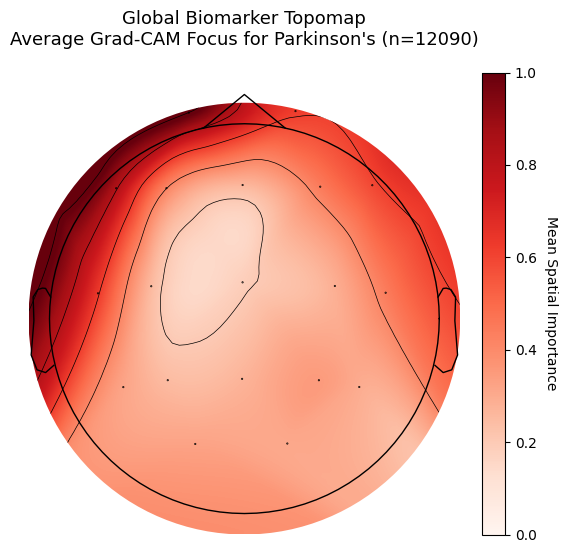

Aggregating Grad-CAM maps for Class 0...
Successfully processed 3302 epochs. Generating topomap...


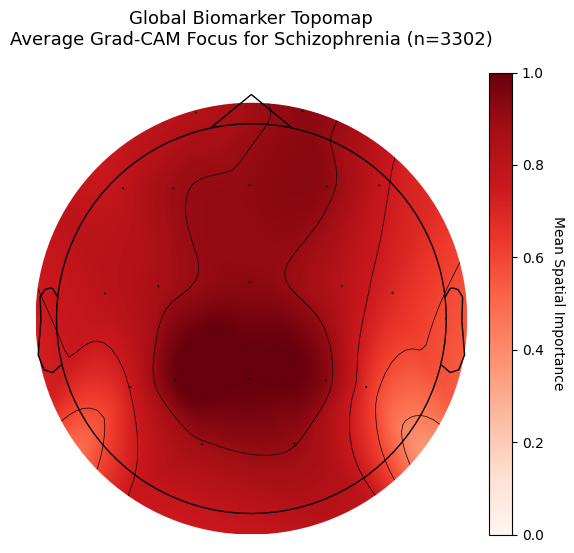

In [58]:
channel_list = [
    'Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 
    'T7', 'C3', 'Cz', 'C4', 'T8', 
    'P7', 'P3', 'Pz', 'P4', 'P8', 
    'O1', 'O2'
]

# Generate the global map for Parkinson's (Target Class 1)
pd_global_importance = plot_average_eegnet_topomap(
    eegnet_model=eegnet_t2, 
    data_loader=val_loader, 
    target_class=1, 
    channel_names=channel_list
)

# Generate the global map for Schizophrenia (Target Class 0)
sz_global_importance = plot_average_eegnet_topomap(
    eegnet_model=eegnet_t2, 
    data_loader=val_loader, 
    target_class=0, 
    channel_names=channel_list
)

In [64]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn.functional as F


def plot_average_transformer_attention(
    transformer_model,
    data_loader,
    target_class,
    channel_names,
    device=None,
):
  """Replicates the embedding phase of the ST-Transformer to manually extract

  the cross-channel self-attention matrix averaged across a cohort.
  """
  if device is None:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

  transformer_model.eval()
  transformer_model.to(device)

  # 20x20 matrix (1 CLS token + 19 Channels)
  total_attention = np.zeros((20, 20))
  sample_count = 0

  print(f"Aggregating Transformer Attention for Class {target_class}...")

  with torch.no_grad():
    for inputs, targets in data_loader:
      # Filter the batch for the target cohort only
      mask = targets == target_class
      if not mask.any():
        continue

      x_target = inputs[mask].to(device)

      # --- CRITICAL FIX: Ensure 4D Tensor Shape [B, 1, 19, 1000] ---
      if x_target.dim() == 3:
        x_target = x_target.unsqueeze(1)

      B = x_target.shape[0]

      # --- 1. Manually Replicate Temporal Embedding ---
      x = transformer_model.temp_conv(x_target)
      x = transformer_model.temp_bn(x)
      x = F.gelu(x)
      x = transformer_model.temp_pool(x)

      x = x.permute(0, 2, 1, 3).contiguous()
      x = x.view(B, 19, -1)
      x = transformer_model.feature_proj(x)

      cls_tokens = transformer_model.cls_token.expand(B, -1, -1)
      x = torch.cat((cls_tokens, x), dim=1)
      x = x + transformer_model.pos_encoder

      # --- 2. Extract Attention Weights ---
      # Explicitly request need_weights=True from the first attention layer
      _, attn_weights = transformer_model.transformer_encoder.layers[
          0
      ].self_attn(x, x, x, need_weights=True, average_attn_weights=True)

      # Aggregate the batch
      total_attention += np.sum(attn_weights.cpu().numpy(), axis=0)
      sample_count += B

  if sample_count == 0:
    print("No samples found for the target class.")
    return None

  # Calculate the global mean attention matrix
  avg_attention = total_attention / sample_count

  # --- 3. Visualization ---
  # Slice [1:, 1:] to drop the CLS token and isolate pure Channel-to-Channel communication
  channel_attention = avg_attention[1:, 1:]

  print(
      f"Successfully processed {sample_count} epochs. Generating connectivity"
      " map..."
  )

  plt.figure(figsize=(10, 8))

  sns.heatmap(
      channel_attention,
      xticklabels=channel_names,
      yticklabels=channel_names,
      cmap="viridis",
      square=True,
      cbar_kws={"label": "Mean Attention Weight"},
  )

  class_name = "Parkinson's" if target_class == 1 else "Schizophrenia"
  plt.title(
      "Transformer Brain Network Synchronization\nAverage Attention for"
      f" {class_name} (n={sample_count})",
      fontsize=14,
      pad=20,
  )

  plt.xlabel("Attended Region (Key)", fontsize=12)
  plt.ylabel("Query Region", fontsize=12)

  plt.show()

  return avg_attention

Aggregating Transformer Attention for Class 1...
Successfully processed 12090 epochs. Generating connectivity map...


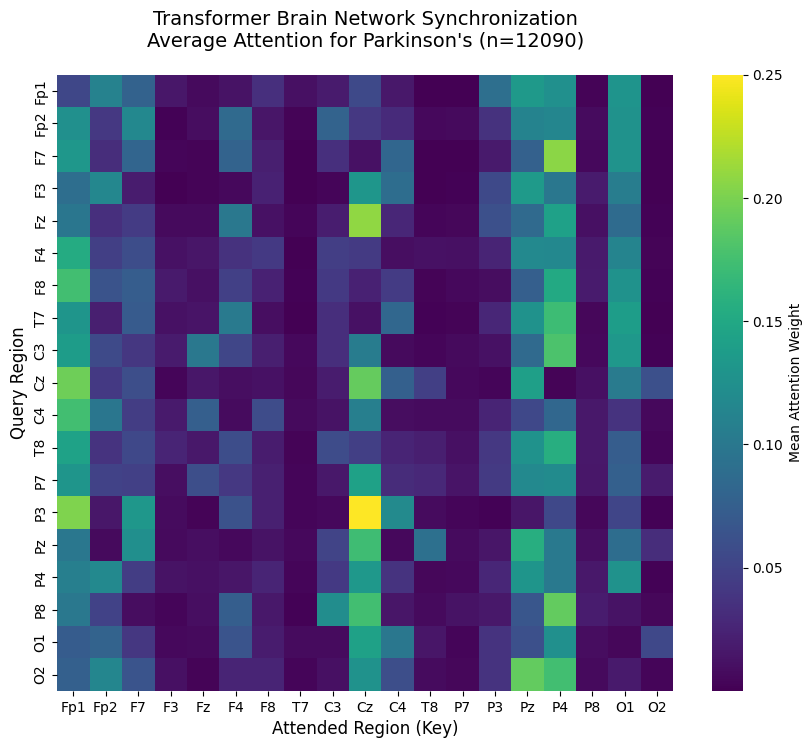

Aggregating Transformer Attention for Class 0...
Successfully processed 3302 epochs. Generating connectivity map...


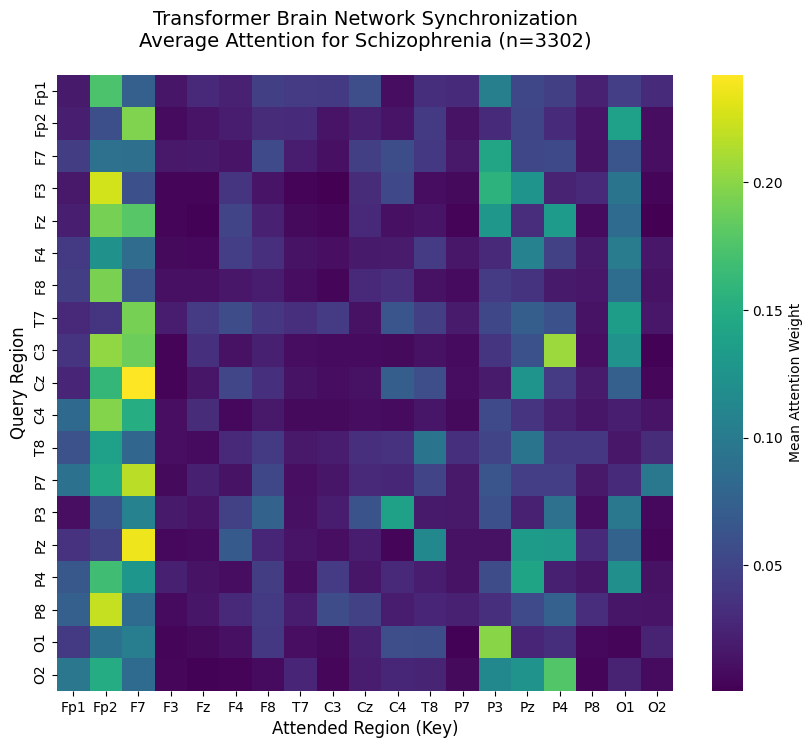

In [65]:
# Generate the connectivity matrix for Parkinson's
pd_attention = plot_average_transformer_attention(
    transformer_model=transformer_t2, 
    data_loader=val_loader, 
    target_class=1, 
    channel_names=channel_list
)

# Generate the connectivity matrix for Schizophrenia
sz_attention = plot_average_transformer_attention(
    transformer_model=transformer_t2, 
    data_loader=val_loader, 
    target_class=0, 
    channel_names=channel_list
)

In [ ]:
import networkx as nx

def plot_gnn_topology(gnn_model, channel_names, top_k_edges=20):
    """
    Extracts the learned adjacency matrix from the ST-GNN and plots both 
    a heatmap and a thresholded directed network graph.
    """
    # 1. Extract and normalize the adjacency matrix
    # Softmax across dim=1 (columns) matches the forward pass logic
    adj_matrix = F.softmax(gnn_model.adj.detach().cpu(), dim=1).numpy()
    
    
    # VISUAL 1: Global Adjacency Heatmap
    
    plt.figure(figsize=(8, 7))
    sns.heatmap(
        adj_matrix, 
        xticklabels=channel_names, 
        yticklabels=channel_names, 
        cmap='magma', 
        square=True,
        cbar_kws={'label': 'Learned Edge Weight (Softmax)'}
    )
    plt.title("ST-GNN: Global Learned Adjacency Matrix", fontsize=14, pad=20)
    plt.xlabel("Target Node (Receiving)", fontsize=12)
    plt.ylabel("Source Node (Sending)", fontsize=12)
    plt.show()

    
    # VISUAL 2: Directed Topological Graph
    
    # To prevent a "hairball" graph, we only plot the strongest connections
    flat_adj = adj_matrix.flatten()
    threshold = np.sort(flat_adj)[-top_k_edges] # Find cutoff for top K edges
    
    G = nx.DiGraph()
    G.add_nodes_from(channel_names)
    
    # Populate graph with edges that exceed the threshold
    edge_colors = []
    for i in range(len(channel_names)):
        for j in range(len(channel_names)):
            weight = adj_matrix[i, j]
            if weight >= threshold and i != j: # Exclude self-loops (diagonal)
                G.add_edge(channel_names[i], channel_names[j], weight=weight)
                edge_colors.append(weight)

    plt.figure(figsize=(9, 9))
    
    # Circular layout mimics the perimeter of the skull
    pos = nx.circular_layout(G)
    
    # Draw Nodes
    nx.draw_networkx_nodes(G, pos, node_color='lightgray', node_size=800, edgecolors='black')
    nx.draw_networkx_labels(G, pos, font_size=11, font_weight='bold')
    
    # Draw Edges (curved arrows to show direction cleanly)
    edges = nx.draw_networkx_edges(
        G, pos, 
        edge_color=edge_colors, 
        edge_cmap=plt.cm.magma, 
        width=2.5, 
        arrowstyle='->', 
        arrowsize=20, 
        connectionstyle="arc3,rad=0.1"
    )
    
    # Add colorbar for edge weights
    sm = plt.cm.ScalarMappable(cmap=plt.cm.magma, norm=plt.Normalize(vmin=min(edge_colors), vmax=max(edge_colors)))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=plt.gca(), fraction=0.046, pad=0.04)
    cbar.set_label('Connection Strength', rotation=270, labelpad=15)
    
    plt.title(f"ST-GNN: Top {top_k_edges} Learned Topological Pathways", fontsize=15, pad=20)
    plt.axis('off')
    plt.show()
    
    return adj_matrix

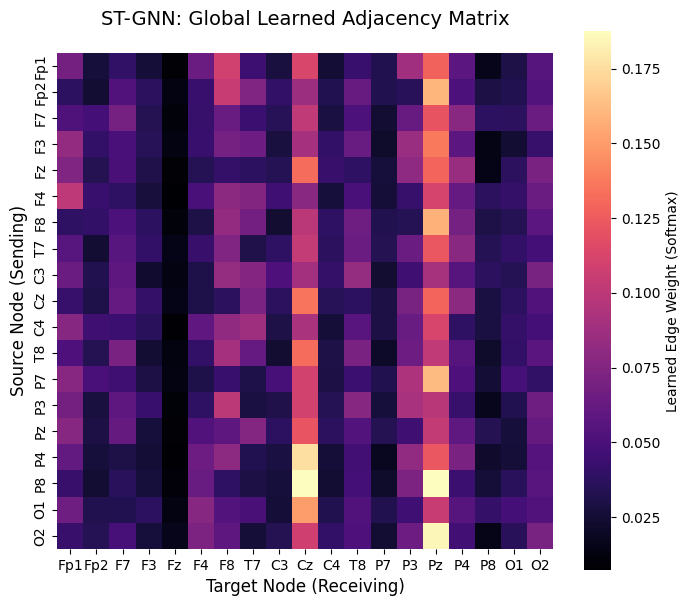

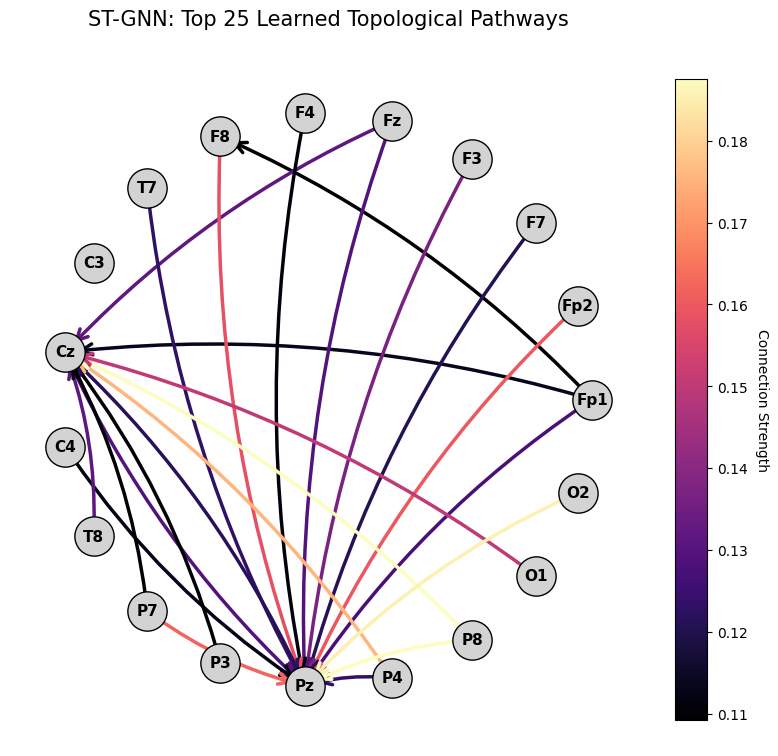

In [67]:
channel_list = [
    'Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 
    'T7', 'C3', 'Cz', 'C4', 'T8', 
    'P7', 'P3', 'Pz', 'P4', 'P8', 
    'O1', 'O2'
]

# Extract and visualize the ST-GNN topology
gnn_adjacency_matrix = plot_gnn_topology(
    gnn_model=gnn_t2, 
    channel_names=channel_list, 
    top_k_edges=25 # Adjust this to show more or fewer pathways
)

In [ ]:

from reportlab.lib.pagesizes import letter, landscape
from reportlab.platypus import SimpleDocTemplate, Image as RLImage

def generate_clinical_pdf_report(
    patient_tensor,
    patient_id,
    models,
    meta_learner,
    class_names,
    channel_names,
    output_filename="clinical_report.pdf",
    device='cuda',
    true_label=None
):
    """
    Runs full inference, extracts explainability maps, compiles a multi-panel 
    clinical figure, and outputs a certified PDF report.
    """
    models = [m.to(device) for m in models]
    for m in models: m.eval()
    
    if patient_tensor.dim() == 2:
        patient_tensor = patient_tensor.unsqueeze(0).unsqueeze(0) # (1, 1, 19, 1000)
    elif patient_tensor.dim() == 3:
        patient_tensor = patient_tensor.unsqueeze(1) # (1, 1, 19, 1000)
        
    x_in = patient_tensor.to(device)
    
    
    # 1. INFERENCE & META-LEARNER PROBABILITIES
    
    batch_preds = []
    with torch.no_grad():
        for m in models:
            out = m(x_in)
            probs = F.softmax(out, dim=1).cpu().numpy()
            batch_preds.append(probs)
            
    X_meta = np.hstack(batch_preds)
    final_probs = meta_learner.predict_proba(X_meta)[0] # [Prob_Class0, Prob_Class1]
    
    prob_c0, prob_c1 = final_probs[0], final_probs[1]
    
    # Clinical Dead-Zone Logic
    if prob_c1 >= 0.60:
        diagnosis = f"{class_names[1]} (High Confidence)"
        status_color = "darkred"
    elif prob_c1 <= 0.40:
        diagnosis = f"{class_names[0]} (High Confidence)"
        status_color = "darkblue"
    else:
        diagnosis = "Indeterminate / Requires Manual Review"
        status_color = "darkorange"

    
    # 2. EXTRACT EXPLAINABILITY ARTIFACTS
    
    
    # --- A. EEGNet Grad-CAM (Targeting conv1) ---
    target_class_idx = 1 if prob_c1 >= 0.5 else 0
    eegnet_model = models[0].model if hasattr(models[0], 'model') else models[0]

    activations = {}
    gradients = {}

    def forward_hook(module, input, output):
        activations['conv1'] = output.detach()

    def backward_hook(module, grad_input, grad_output):
        gradients['conv1'] = grad_output[0].detach()

    fwd_handle = eegnet_model.conv1.register_forward_hook(forward_hook)
    bwd_handle = eegnet_model.conv1.register_full_backward_hook(backward_hook)

    eegnet_model.zero_grad()
    x_grad = x_in.clone().requires_grad_(True)
    output = eegnet_model(x_grad)
    score = output[0, target_class_idx]
    score.backward()

    fwd_handle.remove()
    bwd_handle.remove()

    act = activations['conv1'].cpu().numpy()   
    grad = gradients['conv1'].cpu().numpy()    

    weights = np.mean(grad, axis=(0, 2, 3)) 
    weighted_act = act[0] * weights[:, np.newaxis, np.newaxis] 
    cam = np.sum(weighted_act, axis=0) 
    spatial_importance = np.mean(cam, axis=1)  

    spatial_importance = np.maximum(spatial_importance, 0)
    if np.max(spatial_importance) > 0:
        spatial_importance /= np.max(spatial_importance)
    else:
        spatial_importance = np.ones(19) / 19

    assert spatial_importance.shape == (19,), f"Expected (19,) got {spatial_importance.shape}"
    
    # --- B. ST-Transformer Attention Matrix ---
    transformer_model = models[1].model if hasattr(models[1], 'model') else models[1]
    with torch.no_grad():
        x = transformer_model.temp_conv(x_in)
        x = transformer_model.temp_bn(x)
        x = F.gelu(x)
        x = transformer_model.temp_pool(x)
        x = x.permute(0, 2, 1, 3).contiguous().view(1, 19, -1)
        x = transformer_model.feature_proj(x)
        cls_tokens = transformer_model.cls_token.expand(1, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1) + transformer_model.pos_encoder
        
        _, attn_weights = transformer_model.transformer_encoder.layers[0].self_attn(
            x, x, x, need_weights=True, average_attn_weights=True
        )
        attention_matrix = attn_weights.squeeze(0).cpu().numpy()[1:, 1:] # Drop CLS token

    
    # 3. COMPOSE CLINICAL REPORT CANVAS (MATPLOTLIB)
    
    fig = plt.figure(figsize=(11, 8.5), constrained_layout=True)
    gs = fig.add_gridspec(ncols=2, nrows=2, height_ratios=[0.25, 0.75])

    # Panel 0: Header Text
    ax_header = fig.add_subplot(gs[0, :])
    ax_header.axis('off')
    
    ground_truth_str = f"Ground Truth: {class_names[true_label]}" if true_label is not None else "Ground Truth: N/A (Live Patient)"

    header_text = (
        f"UNIVERSAL CLINICAL EEG DIAGNOSTIC REPORT\n"
        f"Patient ID: {patient_id}   |   Evaluation Timestamp: Automated Pipeline\n"
        f"{'─' * 110}\n"
        f"Primary Diagnosis: {diagnosis}\n"
        f"Probability Breakdown -> {class_names[0]}: {prob_c0:.2f}  |  {class_names[1]}: {prob_c1:.2f}\n"
        f"{ground_truth_str}"
    )
    ax_header.text(
        0.01, 0.5, header_text,
        fontsize=11, family='monospace', fontweight='bold',
        color=status_color, verticalalignment='center',
        transform=ax_header.transAxes
    )

    # Panel 1: EEGNet Grad-CAM Topomap
    ax_topo = fig.add_subplot(gs[1, 0])
    
    # -------------------------------------------------------------
    # MNE FIX: Translate legacy names purely for the Topomap coordinates
    # -------------------------------------------------------------
    mne_ch_names = [ch.replace('T3', 'T7').replace('T4', 'T8')
                      .replace('T5', 'P7').replace('T6', 'P8') for ch in channel_names]
    
    info = mne.create_info(ch_names=mne_ch_names, sfreq=250, ch_types='eeg')
    montage = mne.channels.make_standard_montage('standard_1020')
    info.set_montage(montage, match_case=False, on_missing='ignore')
    
    mne.viz.plot_topomap(
        spatial_importance, info,
        axes=ax_topo, cmap='Reds',
        show=False, contours=4,
        extrapolate='head',
        sphere=0.07
    )
    # -------------------------------------------------------------
    ax_topo.set_title(
        f"Spatial Focus (Grad-CAM)\nTarget: {class_names[target_class_idx]}",
        fontsize=11, fontweight='bold'
    )

    # Panel 2: Transformer Attention Heatmap
    ax_attn = fig.add_subplot(gs[1, 1])
    sns.heatmap(
        attention_matrix,
        xticklabels=channel_names,
        yticklabels=channel_names,
        cmap='viridis',
        square=True,
        ax=ax_attn,
        cbar_kws={'label': 'Attention Weight'}
    )
    ax_attn.set_title(
        "Cross-Channel Synchronization (ST-Transformer)",
        fontsize=11, fontweight='bold'
    )
    ax_attn.set_xlabel("Target Electrode", fontsize=9)
    ax_attn.set_ylabel("Source Electrode", fontsize=9)
    ax_attn.tick_params(axis='x', rotation=45, labelsize=7)
    ax_attn.tick_params(axis='y', rotation=0,  labelsize=7)

    # Save canvas using forced absolute paths to bypass Windows Errno 22
    temp_img_path = os.path.abspath("temp_report_canvas.png")
    absolute_output_filename = os.path.abspath(output_filename)

    plt.savefig(temp_img_path, dpi=300, bbox_inches='tight')
    plt.close()

    
    # 4. COMPILE INTO PDF USING REPORTLAB
    
    doc = SimpleDocTemplate(
        absolute_output_filename, 
        pagesize=landscape(letter),
        rightMargin=36, leftMargin=36, topMargin=36, bottomMargin=36
    )
    
    story = []
    report_image = RLImage(temp_img_path, width=740, height=520)
    story.append(report_image)
    
    doc.build(story)
    
    if os.path.exists(temp_img_path):
        os.remove(temp_img_path)
        
    print(f"[SUCCESS] Certified clinical PDF report saved to: {absolute_output_filename}")

In [77]:
# 1. Find the first index in the validation set where the true label is Parkinson's (1)
pd_index = None
for idx in range(100, len(val_loader.dataset)):
    _, label = val_loader.dataset[idx]
    # Handle both tensor and scalar label formats
    lbl_val = label.item() if torch.is_tensor(label) else label
    if lbl_val == 1:
        pd_index = idx
        break

print(f"Found Parkinson's sample at dataset index: {pd_index}")

# 2. Extract that specific sample
sample_patient_epoch, true_label = val_loader.dataset[pd_index]

# 3. Define your legacy 10-20 channel list (matching T3/T4 nomenclature)
channel_list = [
    'Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8',
    'T3', 'C3', 'Cz', 'C4', 'T4',    # T7→T3, T8→T4
    'T5', 'P3', 'Pz', 'P4', 'T6',    # P7→T5, P8→T6
    'O1', 'O2'
]

# 4. Generate the certified clinical report for this Parkinson's patient
generate_clinical_pdf_report(
    patient_tensor=sample_patient_epoch,
    patient_id=f"SUB-PD-{pd_index}",
    true_label=true_label,          
    models=final_t2_models,
    meta_learner=t2_meta_learner,
    class_names=["Schizophrenia", "Parkinson's"],
    channel_names=channel_list,
    output_filename=f"SUB-PD-{pd_index}_Diagnostic_Report.pdf",
    device=device
)

Found Parkinson's sample at dataset index: 100
[SUCCESS] Certified clinical PDF report saved to: d:\project dissertation\project selection\SUB-PD-100_Diagnostic_Report.pdf


In [81]:
# 1. Find the first index in the validation set where the true label is Schizophrenia (0)
sz_index = None
for idx in range(49,len(val_loader.dataset)):
    _, label = val_loader.dataset[idx]
    # Handle both tensor and scalar label formats
    lbl_val = label.item() if torch.is_tensor(label) else label
    if lbl_val == 0:
        sz_index = idx
        break

print(f"Found Schizophrenia sample at dataset index: {sz_index}")

# 2. Extract that specific sample
sample_patient_epoch, true_label = val_loader.dataset[sz_index]

# 3. Define your legacy 10-20 channel list (matching T3/T4 nomenclature)
channel_list = [
    'Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8',
    'T3', 'C3', 'Cz', 'C4', 'T4',    # T7→T3, T8→T4
    'T5', 'P3', 'Pz', 'P4', 'T6',    # P7→T5, P8→T6
    'O1', 'O2'
]

# 4. Generate the certified clinical report for this Schizophrenia patient
generate_clinical_pdf_report(
    patient_tensor=sample_patient_epoch,
    patient_id=f"SUB-SZ-{sz_index}",
    true_label=true_label,          
    models=final_t2_models,
    meta_learner=t2_meta_learner,
    class_names=["Schizophrenia", "Parkinson's"],
    channel_names=channel_list,
    output_filename=f"SUB-SZ-{sz_index}_Diagnostic_Report.pdf",
    device=device
)

Found Schizophrenia sample at dataset index: 50
[SUCCESS] Certified clinical PDF report saved to: d:\project dissertation\project selection\SUB-SZ-50_Diagnostic_Report.pdf


In [73]:
for name, layer in eegnet_t2.named_modules():
    print(name, type(layer))

 <class '__main__.EEGNet_opt'>
conv1 <class 'torch.nn.modules.conv.Conv2d'>
batchnorm1 <class 'torch.nn.modules.batchnorm.BatchNorm2d'>
depthwise_conv <class 'torch.nn.modules.conv.Conv2d'>
batchnorm2 <class 'torch.nn.modules.batchnorm.BatchNorm2d'>
pooling1 <class 'torch.nn.modules.pooling.AvgPool2d'>
separable_conv_depth <class 'torch.nn.modules.conv.Conv2d'>
separable_conv_point <class 'torch.nn.modules.conv.Conv2d'>
batchnorm3 <class 'torch.nn.modules.batchnorm.BatchNorm2d'>
pooling2 <class 'torch.nn.modules.pooling.AvgPool2d'>
dropout <class 'torch.nn.modules.dropout.Dropout'>
classifier <class 'torch.nn.modules.linear.Linear'>


In [ ]:
"""import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

def simulate_live_clinical_stream(
    patient_epoch_sequence, 
    models, 
    meta_learner, 
    class_names, 
    true_label,
    epoch_duration_sec=4.0,
    device='cuda'
):
    Simulates a live clinical EEG stream. Feeds continuous epochs into the 
    diagnostic pipeline one-by-one and tracks diagnostic stability over time.
    
    patient_epoch_sequence: Tensor of shape (Time_Steps, 1, 19, 1000)
    models = [m.to(device) for m in models]
    for m in models: m.eval()
    
    time_steps = patient_epoch_sequence.size(0)
    history_class1_probs = []
    
    print(f"Starting Live Inference Stream: {time_steps} epochs ({time_steps * epoch_duration_sec} seconds of EEG)...")
    
    with torch.no_grad():
        for t in range(time_steps):
            # Simulate receiving a live 4-second buffer
            x_live = patient_epoch_sequence[t].unsqueeze(0).to(device) # Shape: (1, 1, 19, 1000)
            
            # 1. Base Model Feature Extraction
            batch_preds = []
            for m in models:
                out = m(x_live)
                probs = F.softmax(out, dim=1).cpu().numpy()
                batch_preds.append(probs)
                
            # 2. Meta-Learner Classification
            X_meta = np.hstack(batch_preds)
            final_probs = meta_learner.predict_proba(X_meta)[0]
            
            # Store the probability of Class 1 (Parkinson's)
            prob_c1 = final_probs[1]
            history_class1_probs.append(prob_c1)
            
            # Optional: Print real-time console updates
            time_mark = (t + 1) * epoch_duration_sec
            if prob_c1 >= 0.60:
                status = f">>> DIAGNOSIS LOCKED: {class_names[1]} <<<"
            elif prob_c1 <= 0.40:
                status = f">>> DIAGNOSIS LOCKED: {class_names[0]} <<<"
            else:
                status = "--- INDETERMINATE (Gathering Data) ---"
                
            print(f"T+{time_mark:05.1f}s | Prob {class_names[1][:2]}: {prob_c1:.2f} | {status}")

    
    # VISUALIZE THE LIVE DIAGNOSTIC TIMELINE
    
    time_axis = np.arange(1, time_steps + 1) * epoch_duration_sec
    
    fig, ax = plt.subplots(figsize=(12, 5))
    
    # Plot the probability trajectory
    ax.plot(time_axis, history_class1_probs, color='black', linewidth=2, marker='o', markersize=4, label="Model Confidence")
    
    # Color code the Clinical Zones
    ax.axhspan(0.60, 1.00, color='red', alpha=0.15, label=f"{class_names[1]} Zone")
    ax.axhspan(0.40, 0.60, color='orange', alpha=0.15, label="Uncertainty / Dead-Zone")
    ax.axhspan(0.00, 0.40, color='blue', alpha=0.15, label=f"{class_names[0]} Zone")
    
    # Formatting
    ax.set_ylim(0, 1.0)
    ax.set_xlim(0, time_axis[-1])
    ax.set_xlabel("Elapsed Recording Time (Seconds)", fontsize=12)
    ax.set_ylabel(f"Probability of {class_names[1]}", fontsize=12)
    ax.set_title(f"Live Diagnostic Tracking\nGround Truth: {class_names[true_label]}", fontsize=14, fontweight='bold')
    
    ax.axhline(0.60, color='darkred', linestyle='--', linewidth=1.5)
    ax.axhline(0.40, color='darkblue', linestyle='--', linewidth=1.5)
    
    ax.legend(loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()
    
    return history_class1_probs"""

In [ ]:
"""import scipy.io as sio
import mne
import numpy as np
import torch


def prepare_live_stream_tensor_from_park(
    mat_file_path, 
    data_key='EEG',          
    original_sfreq=500.0,    
    duration_sec=120
):
    print(f"Loading MAT file: {mat_file_path}")
    mat_data = sio.loadmat(mat_file_path)

    # 1. UNWRAP EEGLAB STRUCT
    try:
        eeg_struct = mat_data[data_key][0, 0]
        raw_eeg = np.array(eeg_struct['data'], dtype=np.float32)
        
        chanlocs = eeg_struct['chanlocs'][0]
        def _extract_label(c):
            val = c
            while isinstance(val, np.ndarray):
                val = val[0]
            return str(val)

        original_ch_names = [_extract_label(c) for c in chanlocs['labels']]
        print(f"Successfully extracted {len(original_ch_names)} channel names from MAT file.")
        print("RAW:", original_ch_names)
    except Exception as e:
        raise ValueError(f"Could not extract channel names from EEG.chanlocs. Error: {e}")

    # 2. FLATTEN 3D TO 2D CONTINUOUS STREAM
    if raw_eeg.ndim == 3:
        raw_eeg = np.transpose(raw_eeg, (0, 2, 1)) # (Chans, Trials, Time)
        raw_eeg = raw_eeg.reshape(raw_eeg.shape[0], -1) # (Chans, Continuous_Time)
        
    if raw_eeg.shape[0] > raw_eeg.shape[1]:
        raw_eeg = raw_eeg.T
    
    # 3. CREATE MNE RAW ARRAY
    info = mne.create_info(ch_names=original_ch_names, sfreq=original_sfreq, ch_types='eeg')
    raw = mne.io.RawArray(raw_eeg, info)
    print("CLEANED:", raw.ch_names)
    
    # --- FUZZY CHANNEL NAME STANDARDIZATION ---
    # Strip whitespace, convert everything to uppercase to match safely
    current_names = raw.ch_names
    cleaned_mapping = {curr: curr.strip().upper().replace('.', '') for curr in current_names}
    raw.rename_channels(cleaned_mapping)
    
    # Target channels in uppercase format
    target_channels = [
        'FP1', 'FP2', 'F7', 'F3', 'FZ', 'F4', 'F8', 
        'T7', 'C3', 'CZ', 'C4', 'T8', 
        'P7', 'P3', 'PZ', 'P4', 'P8', 
        'O1', 'O2'
    ]
    
    # Also catch older 10-20 equivalents if they exist (T3->T7, T4->T8, T5->P7, T6->P8)
    legacy_mapping = {'T3': 'T7', 'T4': 'T8', 'T5': 'P7', 'T6': 'P8', 'FP1': 'FP1', 'FP2': 'FP2', 'FZ': 'FZ', 'CZ': 'CZ', 'PZ': 'PZ'}
    raw.rename_channels({k: v for k, v in legacy_mapping.items() if k in raw.ch_names})

    # Pick and reorder safely
    raw.pick_channels(target_channels, ordered=True)
    
    montage = mne.channels.make_standard_montage('standard_1020')
    raw.set_montage(montage, match_case=False, on_missing='ignore')
    
    # 4. PREPROCESSING & EPOCHING
    print("Applying bandpass filter (1-40 Hz) and resampling to 250 Hz...")
    raw.filter(l_freq=1.0, h_freq=40.0, fir_design='firwin', verbose=False)
    
    if raw.info['sfreq'] != 250.0:
        raw.resample(250.0)
        
    max_time = min(duration_sec, raw.times[-1])
    raw.crop(tmin=0, tmax=max_time)
    
    epochs = mne.make_fixed_length_epochs(raw, duration=4.0, preload=True, verbose=False)
    data = epochs.get_data() # (N, 19, 1000)
    
    # 5. Z-SCORE NORMALIZATION
    means = np.mean(data, axis=2, keepdims=True)
    stds = np.std(data, axis=2, keepdims=True)
    data = (data - means) / (stds + 1e-8)
        
    data = np.expand_dims(data, axis=1) # (N, 1, 19, 1000)
    
    live_tensor = torch.tensor(data, dtype=torch.float32)
    print(f"Extraction Complete. Sequence Tensor Shape: {live_tensor.shape}")
    
    return live_tensor"""

In [ ]:
"""# 1. Load the MAT file and extract a 2-minute continuous sequence
live_pd_tensor = prepare_live_stream_tensor_from_park(
    mat_file_path=r"D:\project dissertation\project selection\parkinsons\PD Conflict Task\802_Session_2_PDDys_CC.mat", 
    data_key='EEG',          # Changed to 'EEG'
    original_sfreq=500.0,    # Ensure this matches the UNM recording frequency (usually 500)
    duration_sec=120         # Takes the first 2 minutes
)

# 2. Feed it into the Live Simulator
history = simulate_live_clinical_stream(
    patient_epoch_sequence=live_pd_tensor, 
    models=final_t2_models,          
    meta_learner=t2_meta_learner,    
    class_names=["Schizophrenia", "Parkinson's"], 
    true_label=1,                    # 1 = Parkinson's
    epoch_duration_sec=4.0,
    device=device
)"""

In [ ]:
"""mat_data = sio.loadmat(r"D:\project dissertation\project selection\schizo\Cost Conflict in Schizophrenia\CCunproc\CC_EEG_s104_P.mat")
print([k for k in mat_data.keys() if not k.startswith('__')])"""

In [ ]:
"""import scipy.io as sio
import mne
import numpy as np
import torch


def prepare_live_stream_tensor_from_schizo(
    mat_file_path, 
    data_key='EEG',          
    original_sfreq=500.0,    
    duration_sec=120
):
    print(f"Loading MAT file: {mat_file_path}")
    mat_data = sio.loadmat(mat_file_path)

    # 1. UNWRAP EEGLAB STRUCT
    try:
        eeg_struct = mat_data[data_key][0, 0]
        raw_eeg = np.array(eeg_struct['data'], dtype=np.float32)
        
        chanlocs = eeg_struct['chanlocs'][0]
        def _extract_label(c):
            val = c
            while isinstance(val, np.ndarray):
                val = val[0]
            return str(val)

        original_ch_names = [_extract_label(c) for c in chanlocs['labels']]
        print(f"Successfully extracted {len(original_ch_names)} channel names from MAT file.")
        print("RAW:", original_ch_names)
    except Exception as e:
        raise ValueError(f"Could not extract channel names from EEG.chanlocs. Error: {e}")

    # 2. FLATTEN 3D TO 2D CONTINUOUS STREAM
    if raw_eeg.ndim == 3:
        raw_eeg = np.transpose(raw_eeg, (0, 2, 1)) # (Chans, Trials, Time)
        raw_eeg = raw_eeg.reshape(raw_eeg.shape[0], -1) # (Chans, Continuous_Time)
        
    if raw_eeg.shape[0] > raw_eeg.shape[1]:
        raw_eeg = raw_eeg.T
    
    # 3. CREATE MNE RAW ARRAY
    info = mne.create_info(ch_names=original_ch_names, sfreq=original_sfreq, ch_types='eeg')
    raw = mne.io.RawArray(raw_eeg, info)
    print("CLEANED:", raw.ch_names)
    
    # --- FUZZY CHANNEL NAME STANDARDIZATION ---
    # Strip whitespace, convert everything to uppercase to match safely
    current_names = raw.ch_names
    cleaned_mapping = {curr: curr.strip().upper().replace('.', '') for curr in current_names}
    raw.rename_channels(cleaned_mapping)
    
    # Target channels in uppercase format
    target_channels = [
        'FP1', 'FP2', 'F7', 'F3', 'FZ', 'F4', 'F8', 
        'T7', 'C3', 'CZ', 'C4', 'T8', 
        'P7', 'P3', 'PZ', 'P4', 'P8', 
        'O1', 'O2'
    ]
    
    # Also catch older 10-20 equivalents if they exist (T3->T7, T4->T8, T5->P7, T6->P8)
    legacy_mapping = {'T3': 'T7', 'T4': 'T8', 'T5': 'P7', 'T6': 'P8', 'FP1': 'FP1', 'FP2': 'FP2', 'FZ': 'FZ', 'CZ': 'CZ', 'PZ': 'PZ'}
    raw.rename_channels({k: v for k, v in legacy_mapping.items() if k in raw.ch_names})

    # Pick and reorder safely
    raw.pick_channels(target_channels, ordered=True)
    
    montage = mne.channels.make_standard_montage('standard_1020')
    raw.set_montage(montage, match_case=False, on_missing='ignore')
    
    # 4. PREPROCESSING & EPOCHING
    print("Applying bandpass filter (1-40 Hz) and resampling to 250 Hz...")
    raw.filter(l_freq=1.0, h_freq=40.0, fir_design='firwin', verbose=False)
    
    if raw.info['sfreq'] != 250.0:
        raw.resample(250.0)
        
    max_time = min(duration_sec, raw.times[-1])
    raw.crop(tmin=0, tmax=max_time)
    
    epochs = mne.make_fixed_length_epochs(raw, duration=4.0, preload=True, verbose=False)
    data = epochs.get_data() # (N, 19, 1000)
    
    # 5. Z-SCORE NORMALIZATION
    means = np.mean(data, axis=2, keepdims=True)
    stds = np.std(data, axis=2, keepdims=True)
    data = (data - means) / (stds + 1e-8)
        
    data = np.expand_dims(data, axis=1) # (N, 1, 19, 1000)
    
    live_tensor = torch.tensor(data, dtype=torch.float32)
    print(f"Extraction Complete. Sequence Tensor Shape: {live_tensor.shape}")
    
    return live_tensor"""

In [ ]:
"""# 1. Load the MAT file and extract a 2-minute continuous sequence
live_pd_tensor = prepare_live_stream_tensor_from_schizo(
    mat_file_path=r"D:\project dissertation\project selection\schizo\Cost Conflict in Schizophrenia\CCunproc\CC_EEG_s104_P.mat",
    data_key='EEG',
    original_sfreq=500.0,
    duration_sec=120
)

# 2. Feed it into the Live Simulator
history = simulate_live_clinical_stream(
    patient_epoch_sequence=live_pd_tensor, 
    models=final_t2_models,          
    meta_learner=t2_meta_learner,    
    class_names=["Schizophrenia", "Parkinson's"], 
    true_label=0,                    # 0 = Schizophrenia, 1 = Parkinson's
    epoch_duration_sec=4.0,
    device=device
)"""

In [113]:

import time
import matplotlib.pyplot as plt

def build_hard_threshold_gated_dispatcher(
    set_file_path, 
    t1_models, t1_meta, 
    t2_models, t2_meta, 
    class_names_t1=["Normal", "Abnormal"],
    class_names_t2=["Schizophrenia", "Parkinson's"],
    sfreq=250.0,
    device='cuda'
):
    print(f"--- INITIALIZING HARD-THRESHOLD DISPATCHER FOR: {set_file_path.split('/')[-1]} ---")
    
    # 1. LOAD RAW RECORDING & EXTRACT TRIGGERS
    raw = mne.io.read_raw_eeglab(set_file_path, preload=True, verbose=False)
    events, event_dict = mne.events_from_annotations(raw, verbose=False)
    
    # 2. STANDARDIZE CHANNELS
    target_channels = ['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'T7', 'C3', 'Cz', 'C4', 'T8', 'P7', 'P3', 'Pz', 'P4', 'P8', 'O1', 'O2']
    raw.rename_channels({ch: str(ch).strip().upper().replace('.', '') for ch in raw.ch_names})
    target_mapping = {ch.upper(): ch for ch in target_channels}
    target_mapping.update({'T3': 'T7', 'T4': 'T8', 'T5': 'P7', 'T6': 'P8'}) 
    raw.rename_channels({ch: target_mapping[ch] for ch in raw.ch_names if ch in target_mapping})
    raw.pick_channels(target_channels, ordered=True)
    raw.set_montage(mne.channels.make_standard_montage('standard_1020'), match_case=False, on_missing='ignore')
    
    # 3. PREPROCESSING
    raw.filter(1.0, 40.0, verbose=False)
    if raw.info['sfreq'] != sfreq:
        raw.resample(sfreq)

    # 4. FIND REST/TASK BORDERLINE (TRUST TRIGGERS OVER FILENAME)
    # CRITICAL FIX: Only search for actual Oddball task triggers. 
    # Do NOT include 's1' or 's2' as they denote "Eyes Open/Closed" resting state in this dataset!
    task_keywords = ['s200', 's201', 's202', 'target', 'novel', 'standard']
    valid_task_keys = [k for k in event_dict.keys() if str(k).lower().replace(' ', '') in task_keywords]
    
    if not valid_task_keys:
        print("[NOTICE] No task triggers found in metadata. Processing as pure Resting-State.")
        first_task_time_sec = raw.times[-1] # Process the entire file as Rest
        is_rest_only = True
    else:
        print(f"[NOTICE] Task triggers detected! Overriding filename. Found: {valid_task_keys}")
        task_triggers = [event_dict[k] for k in valid_task_keys]
        first_task_event_sample = events[np.isin(events[:, 2], task_triggers)][0, 0]
        first_task_time_sec = first_task_event_sample / sfreq
        is_rest_only = False
    # ---------------------------------------------------------
    # 5. TIER 1 PROCESSING (REST SCREENING - HARD THRESHOLD)
    # ---------------------------------------------------------
    start_t1 = time.perf_counter()
    raw_rest = raw.copy().crop(tmin=0, tmax=first_task_time_sec)
    rest_epochs = mne.make_fixed_length_epochs(raw_rest, duration=4.0, preload=True, verbose=False)
    
    data_t1 = rest_epochs.get_data() 
    data_t1 = (data_t1 - np.mean(data_t1, axis=2, keepdims=True)) / (np.std(data_t1, axis=2, keepdims=True) + 1e-8)
    tensor_t1 = torch.tensor(data_t1, dtype=torch.float32).to(device)
    
    t1_probs_history = []
    t1_predictions = []
    
    with torch.no_grad():
        for m in t1_models: m.eval()
        for i in range(tensor_t1.size(0)):
            x = tensor_t1[i].unsqueeze(0)
            preds = [F.softmax(m(x), dim=1).cpu().numpy() for m in t1_models]
            final_prob = t1_meta.predict_proba(np.hstack(preds))[0][1] # Prob of Abnormal
            t1_probs_history.append(final_prob)
            
            # Hard Classification Threshold (> 0.30 rule)
            pred_label = class_names_t1[1] if final_prob > 0.30 else class_names_t1[0]
            t1_predictions.append(pred_label)
            
    t1_latency = (time.perf_counter() - start_t1) / max(1, len(t1_probs_history))
    
    # ---------------------------------------------------------
    # CLINICAL SENSITIVITY VOTING (Replaces Strict Majority)
    # ---------------------------------------------------------
    abnormal_count = t1_predictions.count(class_names_t1[1])
    normal_count = t1_predictions.count(class_names_t1[0])
    total_epochs = abnormal_count + normal_count
    
    # If >= 25% of the resting session is abnormal, trigger the Tier 2 investigation
    abnormal_ratio = abnormal_count / max(1, total_epochs)
    if abnormal_ratio >= 0.25:
        t1_decision = class_names_t1[1] 
    else:
        t1_decision = class_names_t1[0]

    print("\n=======================================================")
    print(f"TIER 1 GATEKEEPER RESULT: {t1_decision.upper()}")
    print(f" -> Consensus Breakdown: {abnormal_count} Abnormal vs {normal_count} Normal epochs")
    print(f" -> Abnormal Ratio: {abnormal_ratio*100:.1f}% (Threshold: 25.0%)")
    print("=======================================================")
    # ---------------------------------------------------------
    # 6. HARD STOP GATEKEEPER LOGIC
    # ---------------------------------------------------------
    if t1_decision == "Normal":
        print("[GATEKEEPER SUCCESS] Rest session evaluated as Normal. Pipeline halted. Tier 2 bypassed.")
        print(f" -> Latency: {t1_latency*1000:.2f} ms/epoch | Throughput: {1/t1_latency:.1f} epochs/sec")
        print("=======================================================\n")
        return t1_probs_history, [], first_task_time_sec, t1_decision, "BYPASSED (Rest Clean)"
        
    elif is_rest_only:
        print("[GATEKEEPER ALERT] Abnormal Rest Detected, but NO task data available in this file for Tier 2.")
        print(" -> Action Required: Recommend clinical staff conduct an Event-Related Task EEG for differential diagnosis.")
        print("=======================================================\n")
        return t1_probs_history, [], first_task_time_sec, t1_decision, "ABNORMAL (Needs Task Data)"

    # ---------------------------------------------------------
    # 7. TIER 2 PROCESSING (ONLY REACHED IF ABNORMAL CONSENSUS MET AND TASK DATA EXISTS)
    # ---------------------------------------------------------
    print("[GATEKEEPER ALERT] Abnormal consensus reached! Routing task block to Tier 2...")
    
    start_t2 = time.perf_counter()
    task_epochs = mne.Epochs(raw, events, event_id=task_triggers, tmin=-1.0, tmax=3.0 - (1/sfreq), baseline=(-0.5, 0), preload=True, verbose=False)
    
    data_t2 = task_epochs.get_data() 
    data_t2 = (data_t2 - np.mean(data_t2, axis=2, keepdims=True)) / (np.std(data_t2, axis=2, keepdims=True) + 1e-8)
    data_t2 = np.expand_dims(data_t2, axis=1) 
    tensor_t2 = torch.tensor(data_t2, dtype=torch.float32).to(device)

    t2_probs_history = []
    t2_predictions = []
    
    with torch.no_grad():
        for m in t2_models: m.eval()
        for i in range(tensor_t2.size(0)):
            x = tensor_t2[i].unsqueeze(0)
            preds = [F.softmax(m(x), dim=1).cpu().numpy() for m in t2_models]
            final_prob = t2_meta.predict_proba(np.hstack(preds))[0][1] # Prob of Parkinson's
            t2_probs_history.append(final_prob)
            
            # Hard classification or dead-zone routing per trial
            if final_prob >= 0.60: t2_predictions.append(class_names_t2[1])
            elif final_prob <= 0.40: t2_predictions.append(class_names_t2[0])
            else: t2_predictions.append("Indeterminate")

    t2_latency = (time.perf_counter() - start_t2) / max(1, len(t2_probs_history))
    
    # Majority consensus for Tier 2 task block
    pd_count = t2_predictions.count(class_names_t2[1])
    sz_count = t2_predictions.count(class_names_t2[0])
    
    if pd_count > sz_count and pd_count >= len(t2_predictions) * 0.4:
        t2_decision = class_names_t2[1]
    elif sz_count > pd_count and sz_count >= len(t2_predictions) * 0.4:
        t2_decision = class_names_t2[0]
    else:
        t2_decision = "Indeterminate / Manual Review"

    print("\n=======================================================")
    print("TIER 2 DIAGNOSTIC METRICS (HARD THRESHOLD)")
    print("=======================================================")
    print(f" -> Processed: {len(t2_probs_history)} stimulus trials")
    print(f" -> Trial Breakdown: {pd_count} Parkinson's | {sz_count} Schizophrenia | {t2_predictions.count('Indeterminate')} Indeterminate")
    print(f" -> Latency: {t2_latency*1000:.2f} ms/trial | Throughput: {1/t2_latency:.1f} trials/sec")
    print(f" -> Final Consensus Diagnosis: {t2_decision}")
    print("=======================================================\n")

    return t1_probs_history, t2_probs_history, first_task_time_sec, t1_decision, t2_decision

In [ ]:
import os
import time
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
import mne
import matplotlib.pyplot as plt

def build_hard_threshold_gated_dispatcher_1(
    set_file_path, 
    t1_models, t1_meta, 
    t2_models, t2_meta, 
    class_names_t1=["Normal", "Abnormal"],
    class_names_t2=["Schizophrenia", "Parkinson's"],
    sfreq=250.0,
    device='cuda'
):
    print(f"--- INITIALIZING BIDS-COMPLIANT DISPATCHER FOR: {set_file_path.split('/')[-1]} ---")
    
    # 1. LOAD RAW RECORDING
    raw = mne.io.read_raw_eeglab(set_file_path, preload=True, verbose=False)
    
    # 2. LOCATE & PARSE THE .TSV FILE (The Ground Truth Ledger)
    tsv_file_path = set_file_path.replace('_eeg.set', '_events.tsv')
    if not os.path.exists(tsv_file_path):
        raise FileNotFoundError(f"Missing clinical ledger! Could not find: {tsv_file_path}")
        
    events_df = pd.read_csv(tsv_file_path, sep='\t')
    
    # 3. STANDARDIZE CHANNELS
    target_channels = ['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'T7', 'C3', 'Cz', 'C4', 'T8', 'P7', 'P3', 'Pz', 'P4', 'P8', 'O1', 'O2']
    raw.rename_channels({ch: str(ch).strip().upper().replace('.', '') for ch in raw.ch_names})
    target_mapping = {ch.upper(): ch for ch in target_channels}
    target_mapping.update({'T3': 'T7', 'T4': 'T8', 'T5': 'P7', 'T6': 'P8'}) 
    raw.rename_channels({ch: target_mapping[ch] for ch in raw.ch_names if ch in target_mapping})
    raw.pick_channels(target_channels, ordered=True)
    raw.set_montage(mne.channels.make_standard_montage('standard_1020'), match_case=False, on_missing='ignore')
    
    # 4. PREPROCESSING
    raw.filter(1.0, 40.0, verbose=False)
    if raw.info['sfreq'] != sfreq:
        raw.resample(sfreq)

    ===============
    # 5. TIER 1 PROCESSING (STRICTLY REST DATA VIA TSV)
    ===============
    # Find all rows where the trial type is explicitly "Eyes Open" or "Eyes Closed"
    rest_df = events_df[events_df['trial_type'].str.contains('Eyes', case=False, na=False)]
    
    if rest_df.empty:
        print("[GATEKEEPER ALERT] No Resting-State data found in TSV! Cannot perform Tier 1 screening.")
        return [], [], 0, "ERROR", "MISSING REST DATA"
        
    # Crop exactly from the first rest event to the last rest event
    rest_start = rest_df['onset'].min()
    rest_end = rest_df['onset'].max() + 2.0 # +2s buffer for the final epoch
    raw_rest = raw.copy().crop(tmin=rest_start, tmax=rest_end)
    
    start_t1 = time.perf_counter()
    rest_epochs = mne.make_fixed_length_epochs(raw_rest, duration=4.0, preload=True, verbose=False)
    
    data_t1 = rest_epochs.get_data() 
    data_t1 = (data_t1 - np.mean(data_t1, axis=2, keepdims=True)) / (np.std(data_t1, axis=2, keepdims=True) + 1e-8)
    tensor_t1 = torch.tensor(data_t1, dtype=torch.float32).to(device)
    
    t1_probs_history, t1_predictions = [], []
    
    with torch.no_grad():
        for m in t1_models: m.eval()
        for i in range(tensor_t1.size(0)):
            x = tensor_t1[i].unsqueeze(0)
            preds = [F.softmax(m(x), dim=1).cpu().numpy() for m in t1_models]
            final_prob = t1_meta.predict_proba(np.hstack(preds))[0][1]
            t1_probs_history.append(final_prob)
            pred_label = class_names_t1[1] if final_prob > 0.35 else class_names_t1[0]
            t1_predictions.append(pred_label)
            
    t1_latency = (time.perf_counter() - start_t1) / max(1, len(t1_probs_history))
    
    # Clinical Sensitivity Rule (25% threshold)
    abnormal_count = t1_predictions.count(class_names_t1[1])
    normal_count = t1_predictions.count(class_names_t1[0])
    abnormal_ratio = abnormal_count / max(1, len(t1_predictions))
    
    t1_decision = class_names_t1[1] if abnormal_ratio >= 0.25 else class_names_t1[0]

    print("\n=======================================================")
    print(f"TIER 1 GATEKEEPER RESULT: {t1_decision.upper()}")
    print(f" -> Consensus Breakdown: {abnormal_count} Abnormal vs {normal_count} Normal epochs ({abnormal_ratio*100:.1f}%)")
    print("=======================================================")

    if t1_decision == "Normal":
        print("[GATEKEEPER SUCCESS] Rest session evaluated as Normal. Pipeline halted. Tier 2 bypassed.\n")
        return t1_probs_history, [], rest_end, t1_decision, "BYPASSED (Rest Clean)"

    ===============
    # 6. TIER 2 PROCESSING (STRICTLY TASK DATA VIA TSV)
    ===============
    # Find all rows where the trial type involves the "Tone" stimulus
    task_df = events_df[events_df['trial_type'].str.contains('Tone', case=False, na=False)]
    
    if task_df.empty:
        print("[GATEKEEPER ALERT] Abnormal Rest Detected, but NO 'Tone' task data available in the TSV file.")
        print(" -> Action Required: Recommend clinical staff conduct an Event-Related Task EEG.\n")
        return t1_probs_history, [], rest_end, t1_decision, "ABNORMAL (Needs Task Data)"
        
    print("[GATEKEEPER ALERT] Abnormal consensus reached! Routing task block to Tier 2...")
    
    # Dynamically build MNE events array from the TSV onsets
    task_onsets_samples = (task_df['onset'].values * sfreq).astype(int)
    custom_events = np.column_stack((
        task_onsets_samples, 
        np.zeros_like(task_onsets_samples), 
        np.ones_like(task_onsets_samples) # Dummy event code '1' for all tones
    ))
    
    start_t2 = time.perf_counter()
    # Epoch purely around these specific TSV timestamps
    # Ensure tmin and tmax exactly match the 1000-sample (4 seconds) window used during training!
    # If your training data didn't use a baseline correction, remove it here too.
    task_epochs = mne.Epochs(
        raw, 
        custom_events, 
        event_id=1, 
        tmin=0.0, 
        tmax=4.0 - (1/sfreq), 
        baseline=None, # Match your training pipeline's baseline logic
        preload=True, 
        verbose=False
    )    
    # Extract data and scale from Volts to Microvolts (* 1e6) to match training!
    data_t2 = task_epochs.get_data() * 1e6
    
    # Restore the channel dimension for the 4D tensor (B, 1, 19, 1000)
    data_t2 = np.expand_dims(data_t2, axis=1) 
    
    tensor_t2 = torch.tensor(data_t2, dtype=torch.float32).to(device)

    t2_probs_history, t2_predictions = [], []
    
    with torch.no_grad():
        for m in t2_models: m.eval()
        for i in range(tensor_t2.size(0)):
            x = tensor_t2[i].unsqueeze(0)
            preds = [F.softmax(m(x), dim=1).cpu().numpy() for m in t2_models]
            final_prob = t2_meta.predict_proba(np.hstack(preds))[0][1] 
            t2_probs_history.append(final_prob)
            
            if final_prob >= 0.60: t2_predictions.append(class_names_t2[1])
            elif final_prob <= 0.40: t2_predictions.append(class_names_t2[0])
            else: t2_predictions.append("Indeterminate")

    t2_latency = (time.perf_counter() - start_t2) / max(1, len(t2_probs_history))
    
    pd_count = t2_predictions.count(class_names_t2[1])
    sz_count = t2_predictions.count(class_names_t2[0])
    
    if pd_count > sz_count and pd_count >= len(t2_predictions) * 0.4:
        t2_decision = class_names_t2[1]
    elif sz_count > pd_count and sz_count >= len(t2_predictions) * 0.4:
        t2_decision = class_names_t2[0]
    else:
        t2_decision = "Indeterminate / Manual Review"

    print("\n=======================================================")
    print("TIER 2 DIAGNOSTIC METRICS (HARD THRESHOLD)")
    print("=======================================================")
    print(f" -> Processed: {len(t2_probs_history)} stimulus trials")
    print(f" -> Trial Breakdown: {pd_count} Parkinson's | {sz_count} Schizophrenia | {t2_predictions.count('Indeterminate')} Indeterminate")
    print(f" -> Latency: {t2_latency*1000:.2f} ms/trial | Throughput: {1/t2_latency:.1f} trials/sec")
    print(f" -> Final Consensus Diagnosis: {t2_decision}")
    print("=======================================================\n")


    
    # 1. Find the trial where the model was MOST confident it was Schizophrenia
    # t2_probs_history stores the probability of Parkinson's (Class 1).
    # So the minimum value is where it was most confident in Schizophrenia (Class 0).
    worst_error_idx = np.argmin(t2_probs_history)
    worst_error_prob_sz = 1.0 - t2_probs_history[worst_error_idx]

    print(f"Generating report for Trial {worst_error_idx}...")
    print(f"Model predicted Schizophrenia with {worst_error_prob_sz*100:.1f}% confidence.")

    # 2. Extract that specific tensor
    # Ensure it retains the (1, 1, 19, 1000) shape required by the PDF generator
    error_tensor = tensor_t2[worst_error_idx]

    # 3. Generate the PDF
    generate_clinical_pdf_report(
        patient_tensor=error_tensor,
        patient_id=f"SUB-018-Error_Trial-{worst_error_idx}",
        true_label=1, # Ground Truth is Parkinson's
        models=final_t2_models,
        meta_learner=t2_meta_learner,
        class_names=["Schizophrenia", "Parkinson's"],
        channel_names=[
            'Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8',
            'T7', 'C3', 'Cz', 'C4', 'T8', 
            'P7', 'P3', 'Pz', 'P4', 'P8', 
            'O1', 'O2'
        ],
        output_filename="SUB-018_Failure_Mode_Analysis.pdf",
        device=device
    )



    return t1_probs_history, t2_probs_history, rest_end, t1_decision, t2_decision

--- INITIALIZING BIDS-COMPLIANT DISPATCHER FOR: D:\project dissertation\project selection\real_world\EEG 3-Stim Auditory Oddball and Rest in Parkinson's\sub-018\ses-02\eeg\sub-018_ses-02_task-Rest_eeg.set ---


C:\Users\ssriv\AppData\Local\Temp\ipykernel_18372\3274297385.py:22: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(set_file_path, preload=True, verbose=False)



TIER 1 GATEKEEPER RESULT: ABNORMAL
 -> Consensus Breakdown: 26 Abnormal vs 7 Normal epochs (78.8%)
[GATEKEEPER ALERT] Abnormal consensus reached! Routing task block to Tier 2...

TIER 2 DIAGNOSTIC METRICS (HARD THRESHOLD)
 -> Processed: 196 stimulus trials
 -> Trial Breakdown: 20 Parkinson's | 131 Schizophrenia | 45 Indeterminate
 -> Latency: 2.57 ms/trial | Throughput: 388.7 trials/sec
 -> Final Consensus Diagnosis: Schizophrenia

Generating report for Trial 62...
Model predicted Schizophrenia with 99.9% confidence.
[SUCCESS] Certified clinical PDF report saved to: d:\project dissertation\project selection\SUB-018_Failure_Mode_Analysis.pdf


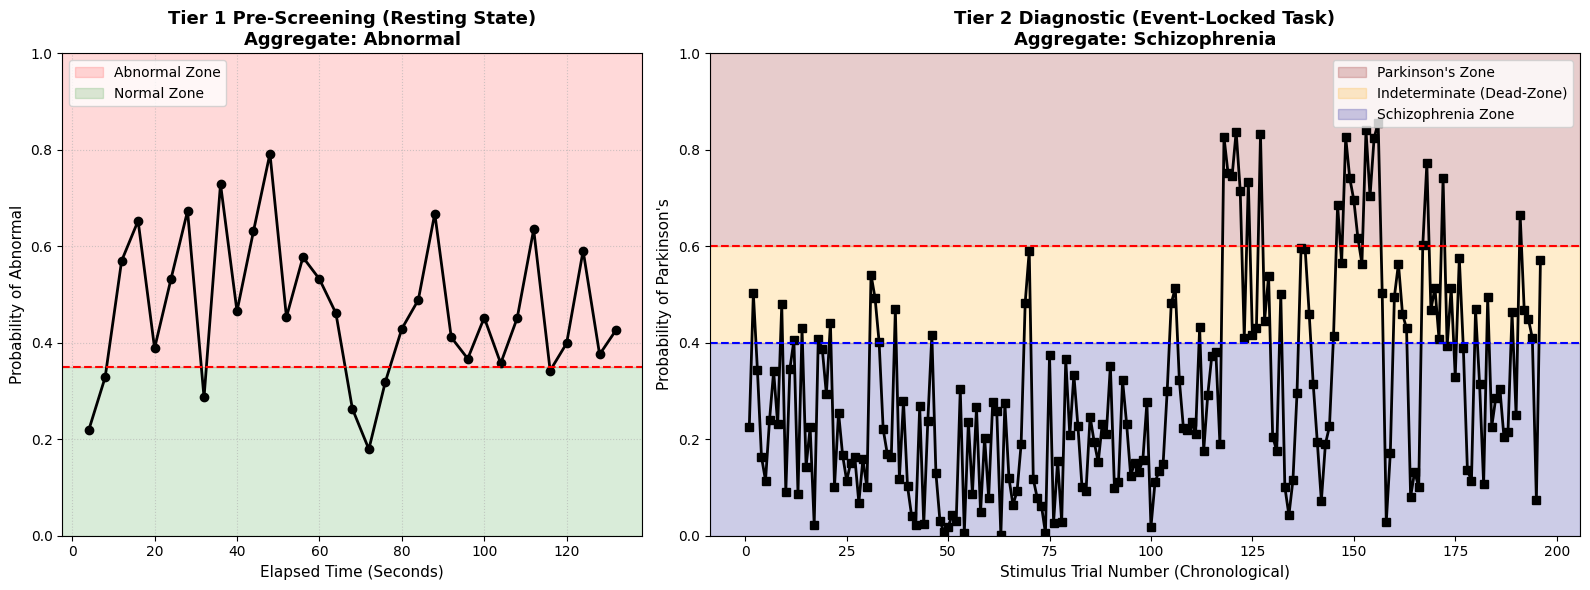

In [138]:
def plot_gated_clinical_dashboard(t1_history, t2_history, class_names_t1, class_names_t2, t1_res, t2_res):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [1, 1.5]})
    
    # Panel 1: Tier 1 Rest
    t1_x = np.arange(1, len(t1_history) + 1) * 4.0
    ax1.plot(t1_x, t1_history, color='black', marker='o', linewidth=2)
    ax1.axhspan(0.35, 1.00, color='red', alpha=0.15, label="Abnormal Zone")
    ax1.axhspan(0.00, 0.35, color='green', alpha=0.15, label="Normal Zone")
    ax1.axhline(0.35, color='red', linestyle='--')
    ax1.set_ylim(0, 1.0)
    ax1.set_title(f"Tier 1 Pre-Screening (Resting State)\nAggregate: {t1_res}", fontsize=13, fontweight='bold')
    ax1.set_xlabel("Elapsed Time (Seconds)", fontsize=11)
    ax1.set_ylabel("Probability of Abnormal", fontsize=11)
    ax1.legend(loc='upper left')
    ax1.grid(True, linestyle=':', alpha=0.6)

    # Panel 2: Tier 2 Task (or Bypass Notice)
    if len(t2_history) > 0:
        t2_x = np.arange(1, len(t2_history) + 1)
        ax2.plot(t2_x, t2_history, color='black', marker='s', linewidth=2)
        ax2.axhspan(0.60, 1.00, color='darkred', alpha=0.2, label=f"{class_names_t2[1]} Zone")
        ax2.axhspan(0.40, 0.60, color='orange', alpha=0.2, label="Indeterminate (Dead-Zone)")
        ax2.axhspan(0.00, 0.40, color='darkblue', alpha=0.2, label=f"{class_names_t2[0]} Zone")
        ax2.set_ylim(0, 1.0)
        ax2.set_title(f"Tier 2 Diagnostic (Event-Locked Task)\nAggregate: {t2_res}", fontsize=13, fontweight='bold')
        ax2.set_xlabel("Stimulus Trial Number (Chronological)", fontsize=11)
        ax2.set_ylabel(f"Probability of {class_names_t2[1]}", fontsize=11)
        ax2.axhline(0.60, color='red', linestyle='--')
        ax2.axhline(0.40, color='blue', linestyle='--')
        ax2.legend(loc='upper right')
    else:
        # Dynamic Text based on Gatekeeper Logic
        if "Needs Task Data" in t2_res:
            msg = "PIPELINE HALTED AT TIER 1\nPatient Flagged as ABNORMAL.\nClinical Action Required: Conduct Task EEG."
            text_color = "darkred"
            bg_color = "lightcoral"
        else:
            msg = "PIPELINE HALTED AT TIER 1\nPatient Cleared as Normal.\nTier 2 Task Processing Bypassed."
            text_color = "darkgreen"
            bg_color = "lightgreen"
            
        ax2.text(0.5, 0.5, msg, 
                 horizontalalignment='center', verticalalignment='center', fontsize=14, fontweight='bold',
                 color=text_color, transform=ax2.transAxes, bbox=dict(facecolor=bg_color, alpha=0.3, boxstyle='round,pad=1'))
        ax2.set_title(f"Tier 2 Diagnostic ({t2_res})", fontsize=13, fontweight='bold')
        ax2.set_axis_off()

    plt.tight_layout()
    plt.show()

# 1. Run the Dispatcher on your newly discovered multi-part file
t1_hist, t2_hist, switch_time, t1_res, t2_res = build_hard_threshold_gated_dispatcher_1(
    set_file_path=r"D:\project dissertation\project selection\real_world\EEG 3-Stim Auditory Oddball and Rest in Parkinson's\sub-018\ses-02\eeg\sub-018_ses-02_task-Rest_eeg.set", 
    t1_models=final_t1_models, 
    t1_meta=t1_meta_learner, 
    t2_models=final_t2_models, 
    t2_meta=t2_meta_learner,
    device=device
)

# 2. Render the dual-panel clinical dashboard
plot_gated_clinical_dashboard(
    t1_history=t1_hist, 
    t2_history=t2_hist, 
    class_names_t1=["Normal", "Abnormal"], 
    class_names_t2=["Schizophrenia", "Parkinson's"], 
    t1_res=t1_res, 
    t2_res=t2_res
)

In [165]:
import os
import time
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
from scipy.signal import resample, butter, filtfilt
import matplotlib.pyplot as plt

def evaluate_csv_tier2_only(
    csv_file_path, 
    t2_models, t2_meta, 
    class_names_t2=["Schizophrenia", "Parkinson's"],
    target_sr=250.0,
    epoch_len_sec=4.0,
    device='cuda'
):
    print(f"--- INITIALIZING CSV TASK DISPATCHER FOR: {os.path.basename(csv_file_path)} ---")
    print("[NOTICE] Header-less CSV detected. Injecting Kaggle UCSF standard headers...")
    
    # 1. INJECT THE EXACT KAGGLE UCSF COLUMN LABELS
    KAGGLE_COLUMNS = [
        'subject', 'trial', 'condition', 'sample', 'Fp1', 'AF7', 'AF3', 'F1', 'F3', 'F5', 'F7', 'FT7', 
        'FC5', 'FC3', 'FC1', 'C1', 'C3', 'C5', 'T7', 'TP7', 'CP5', 'CP3', 'CP1', 'P1', 'P3', 'P5', 'P7', 
        'P9', 'PO7', 'PO3', 'O1', 'Iz', 'Oz', 'POz', 'Pz', 'CPz', 'Fpz', 'Fp2', 'AF8', 'AF4', 'AFz', 'Fz', 
        'F2', 'F4', 'F6', 'F8', 'FT8', 'FC6', 'FC4', 'FC2', 'FCz', 'Cz', 'C2', 'C4', 'C6', 'T8', 'TP8', 
        'CP6', 'CP4', 'CP2', 'P2', 'P4', 'P6', 'P8', 'P10', 'PO8', 'PO4', 'O2', 'VEOa', 'VEOb', 'HEOL', 
        'HEOR', 'Nose', 'TP10'
    ]
    
    # Load the CSV, strictly telling Pandas there is no header row, and applying ours
    df = pd.read_csv(csv_file_path, header=None, names=KAGGLE_COLUMNS)
    
    # Lowercase everything for standardized searching
    df.columns = df.columns.str.lower()
    
    # 2. STANDARDIZE CHANNELS TO THE 10-20 19-CHANNEL SYSTEM
    STANDARD_19_CHANNELS = [
        'fp1', 'fp2', 'f7', 'f3', 'fz', 'f4', 'f8', 
        't7', 'c3', 'cz', 'c4', 't8', 
        'p7', 'p3', 'pz', 'p4', 'p8', 
        'o1', 'o2'
    ]
    
    matched_cols = []
    for std_ch in STANDARD_19_CHANNELS:
        if std_ch in df.columns:
            matched_cols.append(std_ch)
        else:
            raise ValueError(f"CRITICAL ERROR: Could not find required channel {std_ch.upper()} after header injection.")

    print(f"[PROCESS] Bypassing Tier 1. Safely extracting and filtering {df['trial'].nunique()} trials individually...")
    
    all_trials = []
    orig_sr = 1000 # Standard Kaggle UCSF sampling rate
    target_samples = int(target_sr * epoch_len_sec) 
    
    # Bandpass Filter
    b, a = butter(4, [0.5, 50.0], btype='bandpass', fs=target_sr)

    # 3. CLEAN EPOCHING: PROCESS EACH TRIAL INDIVIDUALLY
    for trial_id, group in df.groupby('trial'):
        trial_data = group[matched_cols].values.T # Shape: (19, samples)
        
        if trial_data.shape[1] < 10: 
            continue # Skip corrupted/empty trials
            
        # Resample
        target_length = int(trial_data.shape[1] * (target_sr / orig_sr))
        trial_data = resample(trial_data, target_length, axis=1)
        
        # Filter
        padlen = min(15, trial_data.shape[1] - 1)
        if padlen > 3: 
            trial_data = filtfilt(b, a, trial_data, axis=1, padlen=padlen)
        
        # Pad or Crop to exactly 4 seconds
        if trial_data.shape[1] < target_samples:
            pad_width = target_samples - trial_data.shape[1]
            trial_data = np.pad(trial_data, ((0, 0), (0, pad_width)), mode='constant')
        else:
            trial_data = trial_data[:, :target_samples]
            
        all_trials.append(trial_data)

    if not all_trials:
        print("[ERROR] No valid trials could be extracted.")
        return [], [], "BYPASSED", "ERROR"

    # 4. TIER 2 INFERENCE
    data_t2 = np.stack(all_trials)
    data_t2 = np.expand_dims(data_t2, axis=1).astype(np.float32)
    tensor_t2 = torch.tensor(data_t2).to(device)

    start_t2 = time.perf_counter()
    t2_probs_history = []
    t2_predictions = []
    
    with torch.no_grad():
        for m in t2_models: m.eval()
        for i in range(tensor_t2.size(0)):
            x = tensor_t2[i].unsqueeze(0)
            preds = [F.softmax(m(x), dim=1).cpu().numpy() for m in t2_models]
            final_prob = t2_meta.predict_proba(np.hstack(preds))[0][1] 
            t2_probs_history.append(final_prob)
            
            if final_prob >= 0.60: t2_predictions.append(class_names_t2[1])
            elif final_prob <= 0.40: t2_predictions.append(class_names_t2[0])
            else: t2_predictions.append("Indeterminate")

    t2_latency = (time.perf_counter() - start_t2) / max(1, len(t2_probs_history))
    
    pd_count = t2_predictions.count(class_names_t2[1])
    sz_count = t2_predictions.count(class_names_t2[0])
    
    if pd_count > sz_count and pd_count >= len(t2_predictions) * 0.4:
        t2_decision = class_names_t2[1]
    elif sz_count > pd_count and sz_count >= len(t2_predictions) * 0.4:
        t2_decision = class_names_t2[0]
    else:
        t2_decision = "Indeterminate / Manual Review"

    print("=======================================================")
    print("TIER 2 DIAGNOSTIC METRICS (CLEAN KAGGLE EPOCHING)")
    print("=======================================================")
    print(f" -> Processed: {len(t2_probs_history)} individual stimulus trials")
    print(f" -> Trial Breakdown: {pd_count} Parkinson's | {sz_count} Schizophrenia | {t2_predictions.count('Indeterminate')} Indeterminate")
    print(f" -> Latency: {t2_latency*1000:.2f} ms/trial | Throughput: {1/t2_latency:.1f} trials/sec")
    print(f" -> Final Consensus Diagnosis: {t2_decision.upper()}")
    print("=======================================================\n")

    return [], t2_probs_history, "BYPASSED (No Rest Data)", t2_decision

--- INITIALIZING CSV TASK DISPATCHER FOR: 81.csv ---
[NOTICE] Header-less CSV detected. Injecting Kaggle UCSF standard headers...
[PROCESS] Bypassing Tier 1. Safely extracting and filtering 100 trials individually...
TIER 2 DIAGNOSTIC METRICS (CLEAN KAGGLE EPOCHING)
 -> Processed: 100 individual stimulus trials
 -> Trial Breakdown: 0 Parkinson's | 100 Schizophrenia | 0 Indeterminate
 -> Latency: 3.30 ms/trial | Throughput: 302.6 trials/sec
 -> Final Consensus Diagnosis: SCHIZOPHRENIA



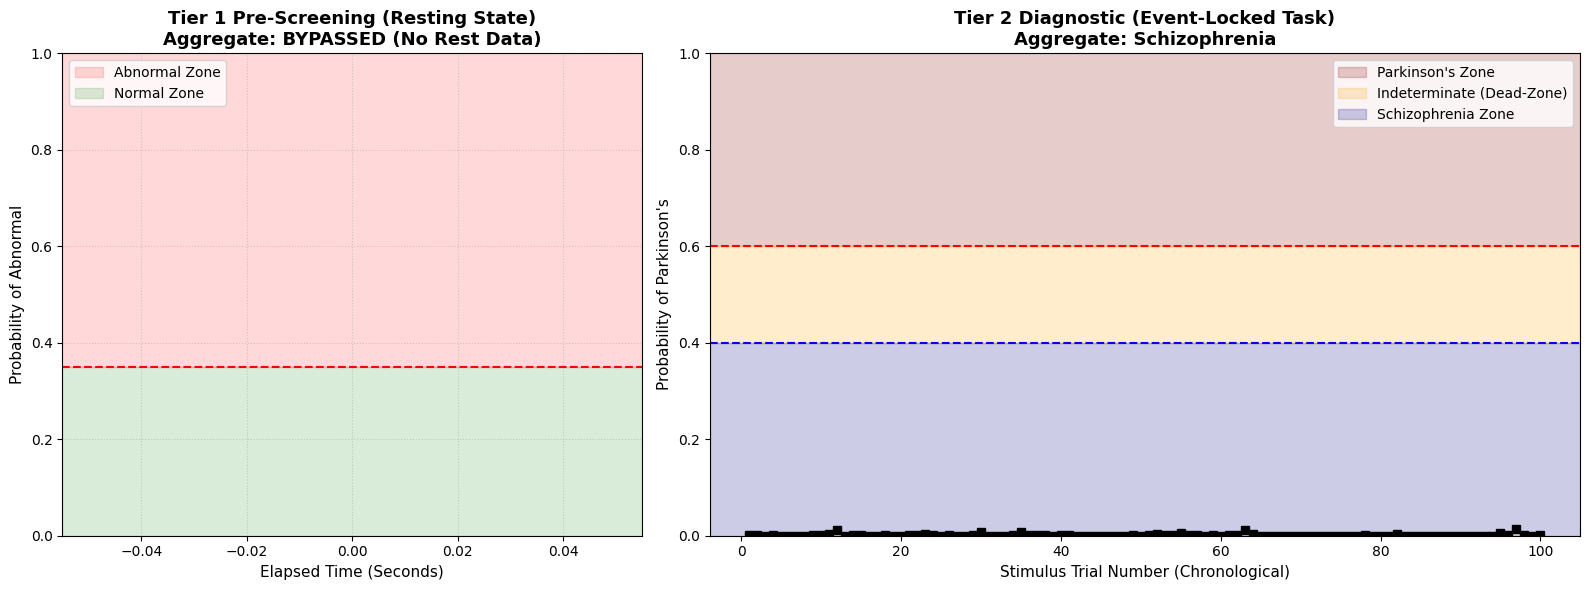

In [170]:
csv_path = r"D:\project dissertation\project selection\real_world\kaggle\archive\81.csv\81.csv"
# Run the modified CSV Dispatcher
t1_hist, t2_hist, t1_res, t2_res = evaluate_csv_tier2_only(
    csv_file_path=csv_path,
    t2_models=final_t2_models,
    t2_meta=t2_meta_learner,
    device=device
)

# Render the Dashboard
plot_gated_clinical_dashboard(
    t1_history=t1_hist, 
    t2_history=t2_hist, 
    class_names_t1=["Normal", "Abnormal"], 
    class_names_t2=["Schizophrenia", "Parkinson's"], 
    t1_res=t1_res, 
    t2_res=t2_res
)

INITIATING MACRO-LEVEL DATASET EVALUATION...

FINAL CLASSIFICATION REPORT
               precision    recall  f1-score   support

Schizophrenia     0.9958    0.9973    0.9965      3302
  Parkinson's     0.9993    0.9988    0.9990     12090

     accuracy                         0.9985     15392
    macro avg     0.9975    0.9981    0.9978     15392
 weighted avg     0.9985    0.9985    0.9985     15392



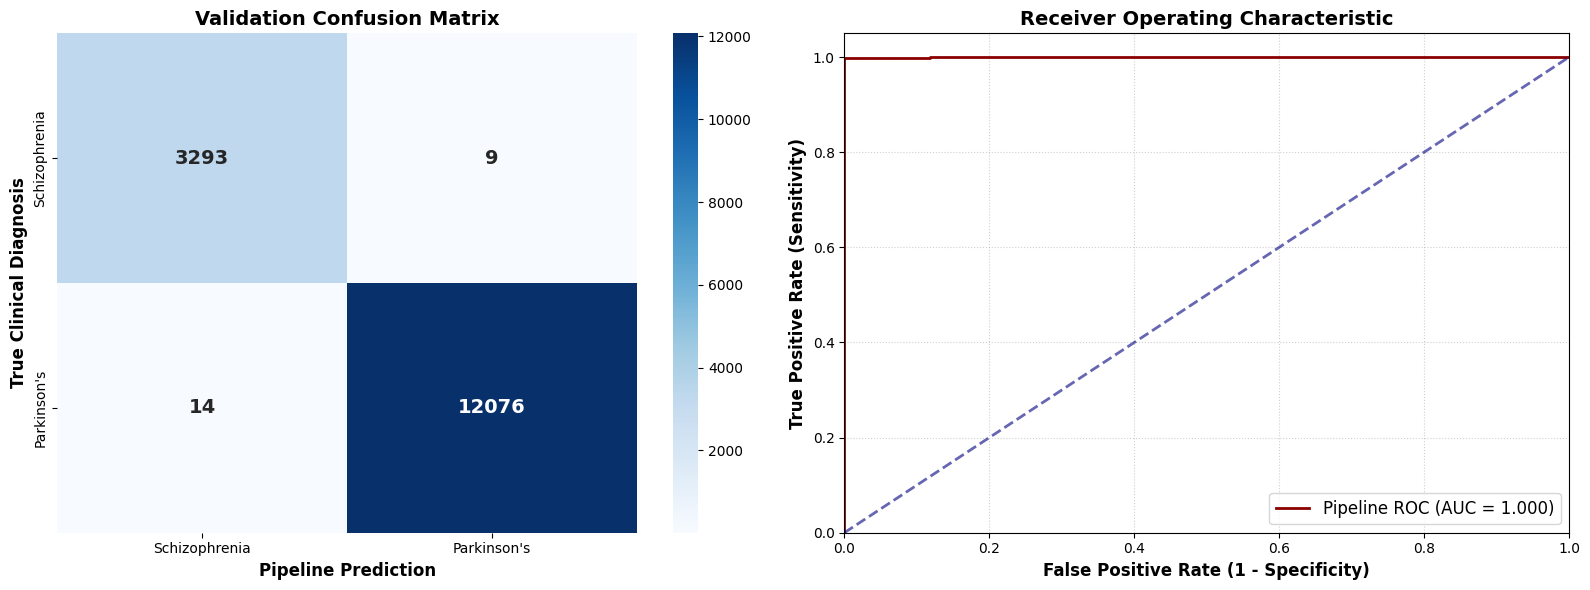


[SUCCESS] Metrics computed and figure saved as 'Final_Thesis_Metrics.png'.


In [140]:
import numpy as np
import torch
import os
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report

def generate_final_thesis_metrics(
    val_loader, 
    models, 
    meta_learner, 
    class_names=["Schizophrenia", "Parkinson's"], 
    device='cuda'
):
    print("=======================================================")
    print("INITIATING MACRO-LEVEL DATASET EVALUATION...")
    print("=======================================================\n")
    
    all_true_labels = []
    all_final_probs = [] 
    all_preds = []

    # 1. Run Inference Across the Entire Validation Set
    with torch.no_grad():
        for m in models: m.eval()
        
        for batch_idx, (inputs, targets) in enumerate(val_loader):
            inputs = inputs.to(device)
            
            # Aggregate base model probabilities
            batch_preds = []
            for m in models:
                out = m(inputs)
                probs = F.softmax(out, dim=1).cpu().numpy()
                batch_preds.append(probs)
            
            # Meta-Learner Final Decision
            X_meta = np.hstack(batch_preds)
            final_probs = meta_learner.predict_proba(X_meta)[:, 1] # Probabilities for Class 1 (Parkinson's)
            final_preds = meta_learner.predict(X_meta)
            
            all_true_labels.extend(targets.numpy())
            all_final_probs.extend(final_probs)
            all_preds.extend(final_preds)
            
    # 2. Compute Statistical Metrics
    cm = confusion_matrix(all_true_labels, all_preds)
    fpr, tpr, _ = roc_curve(all_true_labels, all_final_probs)
    roc_auc = auc(fpr, tpr)
    
    # 3. Print the Text Report for your Appendix
    print("=======================================================")
    print("FINAL CLASSIFICATION REPORT")
    print("=======================================================")
    print(classification_report(all_true_labels, all_preds, target_names=class_names, digits=4))
    
    # 4. Render the Publication Figures
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Panel A: Confusion Matrix
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
        xticklabels=class_names, yticklabels=class_names,
        annot_kws={"size": 14, "weight": "bold"}
    )
    axes[0].set_title('Validation Confusion Matrix', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('True Clinical Diagnosis', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Pipeline Prediction', fontsize=12, fontweight='bold')
    
    # Panel B: ROC Curve
    axes[1].plot(fpr, tpr, color='darkred', lw=2, label=f'Pipeline ROC (AUC = {roc_auc:.3f})')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', alpha=0.6)
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('True Positive Rate (Sensitivity)', fontsize=12, fontweight='bold')
    axes[1].set_title('Receiver Operating Characteristic', fontsize=14, fontweight='bold')
    axes[1].legend(loc="lower right", fontsize=12)
    axes[1].grid(True, linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.savefig(os.path.abspath("Final_Thesis_Metrics.png"), dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n[SUCCESS] Metrics computed and figure saved as 'Final_Thesis_Metrics.png'.")

# Execute the evaluation
generate_final_thesis_metrics(
    val_loader=val_loader,
    models=final_t2_models,
    meta_learner=t2_meta_learner,
    device=device
)

INITIATING MACRO-LEVEL DATASET EVALUATION: Final_Thesis_Metrics_Tier1.png

FINAL CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Normal     0.8052    0.8528    0.8283     49856
    Abnormal     0.8153    0.7591    0.7862     42680

    accuracy                         0.8096     92536
   macro avg     0.8103    0.8059    0.8073     92536
weighted avg     0.8099    0.8096    0.8089     92536



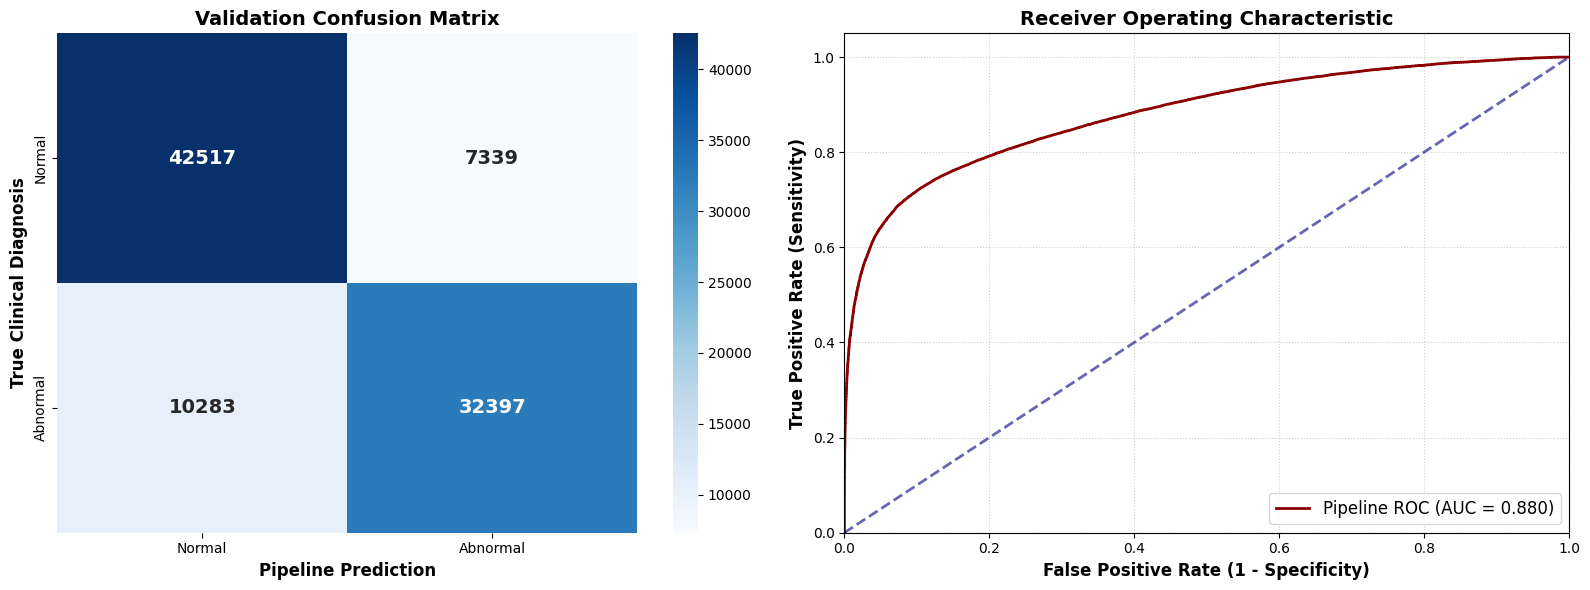


[SUCCESS] Metrics computed and figure saved as 'Final_Thesis_Metrics_Tier1.png'.


In [ ]:
import numpy as np
import torch
import os
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report

def generate_final_thesis_metrics(
    val_loader, 
    models, 
    meta_learner, 
    class_names, 
    save_name="Final_Thesis_Metrics.png",
    device='cuda'
):
    print("=======================================================")
    print(f"INITIATING MACRO-LEVEL DATASET EVALUATION: {save_name}")
    print("=======================================================\n")
    
    all_true_labels = []
    all_final_probs = [] 
    all_preds = []

    # 1. Run Inference Across the Entire Validation Set
    with torch.no_grad():
        for m in models: m.eval()
        
        for batch_idx, (inputs, targets) in enumerate(val_loader):
            inputs = inputs.to(device)
            
            # Aggregate base model probabilities
            batch_preds = []
            for m in models:
                out = m(inputs)
                probs = F.softmax(out, dim=1).cpu().numpy()
                batch_preds.append(probs)
            
            # Meta-Learner Final Decision
            X_meta = np.hstack(batch_preds)
            # Probabilities for Class 1 (Abnormal)
            final_probs = meta_learner.predict_proba(X_meta)[:, 1] 
            final_preds = meta_learner.predict(X_meta)
            
            all_true_labels.extend(targets.numpy())
            all_final_probs.extend(final_probs)
            all_preds.extend(final_preds)
            
    # 2. Compute Statistical Metrics
    cm = confusion_matrix(all_true_labels, all_preds)
    fpr, tpr, _ = roc_curve(all_true_labels, all_final_probs)
    roc_auc = auc(fpr, tpr)
    
    # 3. Print the Text Report for your Appendix
    print("=======================================================")
    print("FINAL CLASSIFICATION REPORT")
    print("=======================================================")
    print(classification_report(all_true_labels, all_preds, target_names=class_names, digits=4))
    
    # 4. Render the Publication Figures
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Panel A: Confusion Matrix
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
        xticklabels=class_names, yticklabels=class_names,
        annot_kws={"size": 14, "weight": "bold"}
    )
    axes[0].set_title('Validation Confusion Matrix', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('True Clinical Diagnosis', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Pipeline Prediction', fontsize=12, fontweight='bold')
    
    # Panel B: ROC Curve
    axes[1].plot(fpr, tpr, color='darkred', lw=2, label=f'Pipeline ROC (AUC = {roc_auc:.3f})')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', alpha=0.6)
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('True Positive Rate (Sensitivity)', fontsize=12, fontweight='bold')
    axes[1].set_title('Receiver Operating Characteristic', fontsize=14, fontweight='bold')
    axes[1].legend(loc="lower right", fontsize=12)
    axes[1].grid(True, linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.savefig(os.path.abspath(save_name), dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n[SUCCESS] Metrics computed and figure saved as '{save_name}'.")


# EXECUTE FOR TIER 1

generate_final_thesis_metrics(
    val_loader=eval_loader,                # Tier 1 uses eval_loader
    models=final_t1_models,                # Tier 1 models
    meta_learner=t1_meta_learner,          # Tier 1 Meta-Learner
    class_names=["Normal", "Abnormal"],    # Tier 1 Classes
    save_name="Final_Thesis_Metrics_Tier1.png", # Unique save name
    device=device
)

In [175]:
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate_individual_base_models(models, data_loader, model_names, tier_name, device='cuda'):
    print(f"=======================================================")
    print(f"EXTRACTING INDIVIDUAL METRICS: {tier_name}")
    print(f"=======================================================")
    
    results = []
    
    with torch.no_grad():
        for idx, model in enumerate(models):
            model.eval()
            model_name = model_names[idx]
            
            all_targets = []
            all_probs = []
            all_preds = []
            
            for inputs, targets in data_loader:
                inputs = inputs.to(device)
                outputs = model(inputs)
                
                # Get probabilities and categorical predictions
                probs = F.softmax(outputs, dim=1)[:, 1].cpu().numpy()
                preds = np.argmax(outputs.cpu().numpy(), axis=1)
                
                all_targets.extend(targets.numpy())
                all_probs.extend(probs)
                all_preds.extend(preds)
            
            # Calculate Metrics (using macro average to show balance across both classes)
            acc = accuracy_score(all_targets, all_preds)
            prec = precision_score(all_targets, all_preds, average='macro')
            rec = recall_score(all_targets, all_preds, average='macro')
            f1 = f1_score(all_targets, all_preds, average='macro')
            auc = roc_auc_score(all_targets, all_probs)
            
            results.append({
                "Model": model_name,
                "Accuracy": f"{acc*100:.2f}%",
                "Precision": f"{prec:.4f}",
                "Recall": f"{rec:.4f}",
                "F1-Score": f"{f1:.4f}",
                "AUC": f"{auc:.4f}"
            })
            
    # Convert to a beautiful Pandas DataFrame
    df_results = pd.DataFrame(results)
    df_results.set_index("Model", inplace=True)
    
    print(f"\n{tier_name} Individual Performance:")
    print("-" * 55)
    print(df_results.to_string())
    print("-" * 55 + "\n")
    
    return df_results

# Define the names of your architectures in the exact order they are stacked
model_names_list = ["EEGNet", "ST-Transformer", "ST-GNN"]

# 1. Get Metrics for Tier 1 (Normal vs Abnormal)
t1_metrics_df = evaluate_individual_base_models(
    models=final_t1_models, 
    data_loader=eval_loader, 
    model_names=model_names_list, 
    tier_name="TIER 1 (Gatekeeper)",
    device=device
)

# 2. Get Metrics for Tier 2 (Schizophrenia vs Parkinson's)
t2_metrics_df = evaluate_individual_base_models(
    models=final_t2_models, 
    data_loader=val_loader, 
    model_names=model_names_list, 
    tier_name="TIER 2 (Differential Diagnosis)",
    device=device
)

EXTRACTING INDIVIDUAL METRICS: TIER 1 (Gatekeeper)

TIER 1 (Gatekeeper) Individual Performance:
-------------------------------------------------------
               Accuracy Precision  Recall F1-Score     AUC
Model                                                     
EEGNet           78.07%    0.7813  0.7765   0.7778  0.8530
ST-Transformer   79.23%    0.8204  0.7799   0.7817  0.8594
ST-GNN           75.87%    0.8189  0.7408   0.7369  0.8699
-------------------------------------------------------

EXTRACTING INDIVIDUAL METRICS: TIER 2 (Differential Diagnosis)

TIER 2 (Differential Diagnosis) Individual Performance:
-------------------------------------------------------
               Accuracy Precision  Recall F1-Score     AUC
Model                                                     
EEGNet           88.01%    0.9331  0.7207   0.7707  0.9965
ST-Transformer   97.99%    0.9858  0.9548   0.9692  0.9996
ST-GNN           98.89%    0.9842  0.9828   0.9835  0.9974
-------------------------

In [176]:
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate_full_pipeline_metrics(models, meta_learner, data_loader, model_names, tier_name, device='cuda'):
    print(f"=======================================================")
    print(f"EXTRACTING FULL PIPELINE METRICS: {tier_name}")
    print(f"=======================================================")
    
    results = []
    
    # Dictionaries to hold base model predictions
    all_targets = []
    all_base_probs = {name: [] for name in model_names}
    all_base_preds = {name: [] for name in model_names}
    all_X_meta = [] # To hold the concatenated probabilities for the Meta-Learner
    
    with torch.no_grad():
        for m in models: m.eval()
        
        for inputs, targets in data_loader:
            inputs = inputs.to(device)
            targets_np = targets.numpy()
            all_targets.extend(targets_np)
            
            batch_probs_list = []
            
            for idx, model in enumerate(models):
                outputs = model(inputs)
                probs = F.softmax(outputs, dim=1).cpu().numpy()
                preds = np.argmax(probs, axis=1)
                
                all_base_probs[model_names[idx]].extend(probs[:, 1])
                all_base_preds[model_names[idx]].extend(preds)
                batch_probs_list.append(probs)
                
            # Stack the 3 model probabilities to feed the Meta-Learner
            X_meta_batch = np.hstack(batch_probs_list)
            all_X_meta.append(X_meta_batch)
            
    # 1. Calculate Base Models Metrics
    for name in model_names:
        acc = accuracy_score(all_targets, all_base_preds[name])
        prec = precision_score(all_targets, all_base_preds[name], average='macro', zero_division=0)
        rec = recall_score(all_targets, all_base_preds[name], average='macro', zero_division=0)
        f1 = f1_score(all_targets, all_base_preds[name], average='macro', zero_division=0)
        auc = roc_auc_score(all_targets, all_base_probs[name])
        
        results.append({
            "Model": name,
            "Accuracy": f"{acc*100:.2f}%",
            "Precision": f"{prec:.4f}",
            "Recall": f"{rec:.4f}",
            "F1-Score": f"{f1:.4f}",
            "AUC": f"{auc:.4f}"
        })
        
    # 2. Calculate Meta-Learner (Ensemble) Metrics
    X_meta_full = np.vstack(all_X_meta)
    meta_probs = meta_learner.predict_proba(X_meta_full)[:, 1]
    meta_preds = meta_learner.predict(X_meta_full)
    
    acc_meta = accuracy_score(all_targets, meta_preds)
    prec_meta = precision_score(all_targets, meta_preds, average='macro', zero_division=0)
    rec_meta = recall_score(all_targets, meta_preds, average='macro', zero_division=0)
    f1_meta = f1_score(all_targets, meta_preds, average='macro', zero_division=0)
    auc_meta = roc_auc_score(all_targets, meta_probs)
    
    results.append({
        "Model": "Meta-Learner (Ensemble)",
        "Accuracy": f"{acc_meta*100:.2f}%",
        "Precision": f"{prec_meta:.4f}",
        "Recall": f"{rec_meta:.4f}",
        "F1-Score": f"{f1_meta:.4f}",
        "AUC": f"{auc_meta:.4f}"
    })
    
    # Convert to DataFrame
    df_results = pd.DataFrame(results)
    df_results.set_index("Model", inplace=True)
    
    print(f"\n{tier_name} Performance Comparison:")
    print("-" * 75)
    print(df_results.to_string())
    print("-" * 75 + "\n")
    
    return df_results

# Define your architecture names
model_names_list = ["EEGNet", "ST-Transformer", "ST-GNN"]

# Generate the unified table for Tier 1
t1_unified_df = evaluate_full_pipeline_metrics(
    models=final_t1_models, 
    meta_learner=t1_meta_learner,
    data_loader=eval_loader, 
    model_names=model_names_list, 
    tier_name="TIER 1 (Gatekeeper: Normal vs Abnormal)",
    device=device
)

# Generate the unified table for Tier 2
t2_unified_df = evaluate_full_pipeline_metrics(
    models=final_t2_models, 
    meta_learner=t2_meta_learner,
    data_loader=val_loader, 
    model_names=model_names_list, 
    tier_name="TIER 2 (Diagnostic: SZ vs PD)",
    device=device
)

EXTRACTING FULL PIPELINE METRICS: TIER 1 (Gatekeeper: Normal vs Abnormal)

TIER 1 (Gatekeeper: Normal vs Abnormal) Performance Comparison:
---------------------------------------------------------------------------
                        Accuracy Precision  Recall F1-Score     AUC
Model                                                              
EEGNet                    78.07%    0.7813  0.7765   0.7778  0.8530
ST-Transformer            79.23%    0.8204  0.7799   0.7817  0.8594
ST-GNN                    75.87%    0.8189  0.7408   0.7369  0.8699
Meta-Learner (Ensemble)   80.96%    0.8103  0.8059   0.8073  0.8800
---------------------------------------------------------------------------

EXTRACTING FULL PIPELINE METRICS: TIER 2 (Diagnostic: SZ vs PD)

TIER 2 (Diagnostic: SZ vs PD) Performance Comparison:
---------------------------------------------------------------------------
                        Accuracy Precision  Recall F1-Score     AUC
Model                                

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate_baseline_models(models_dict, data_loader, tier_name, device='cuda'):
    print(f"=======================================================")
    print(f"EXTRACTING UNOPTIMIZED BASELINE METRICS: {tier_name}")
    print(f"=======================================================")
    
    results = []
    
    with torch.no_grad():
        for model_name, model in models_dict.items():
            model = model.to(device)
            model.eval()
            
            all_targets = []
            all_probs = []
            all_preds = []
            
            for inputs, targets in data_loader:
                inputs = inputs.to(device)
                
                # Forward pass on the unoptimized model
                outputs = model(inputs)
                
                # Get probabilities and categorical predictions
                probs = F.softmax(outputs, dim=1)[:, 1].cpu().numpy()
                preds = np.argmax(outputs.cpu().numpy(), axis=1)
                
                all_targets.extend(targets.numpy())
                all_probs.extend(probs)
                all_preds.extend(preds)
            
            # Calculate Baseline Metrics
            acc = accuracy_score(all_targets, all_preds)
            prec = precision_score(all_targets, all_preds, average='macro', zero_division=0)
            rec = recall_score(all_targets, all_preds, average='macro', zero_division=0)
            f1 = f1_score(all_targets, all_preds, average='macro', zero_division=0)
            auc = roc_auc_score(all_targets, all_probs)
            
            results.append({
                "Baseline Model": model_name,
                "Accuracy": f"{acc*100:.2f}%",
                "Precision": f"{prec:.4f}",
                "Recall": f"{rec:.4f}",
                "F1-Score": f"{f1:.4f}",
                "AUC": f"{auc:.4f}"
            })
            
    # Convert to a Pandas DataFrame
    df_results = pd.DataFrame(results)
    df_results.set_index("Baseline Model", inplace=True)
    
    print(f"\n{tier_name} Baseline Performance:")
    print("-" * 75)
    print(df_results.to_string())
    print("-" * 75 + "\n")
    
    return df_results

===========================
# 1. Evaluate Tier 1 Unoptimized Models (From your Dictionary)
===========================
t1_baseline_df = evaluate_baseline_models(
    models_dict=models_to_test, 
    data_loader=eval_loader, # Assuming eval_loader is your Tier 1 validation set
    tier_name="TIER 1 (Normal vs Abnormal - RAW)",
    device=device
)

===========================
# 2. Evaluate Tier 2 Unoptimized Models (From your List)
===========================
# First, convert your list into a dictionary so the names print nicely
tier2_baseline_dict = {
    "1. EEGNet (Unoptimized)": trained_models_list[0],
    "2. ST-Transformer (Unoptimized)": trained_models_list[1],
    "3. ST-GNN (Unoptimized)": trained_models_list[2]
}

t2_baseline_df = evaluate_baseline_models(
    models_dict=tier2_baseline_dict, 
    data_loader=val_loader, # Tier 2 validation set
    tier_name="TIER 2 (SZ vs PD - RAW)",
    device=device
)

EXTRACTING UNOPTIMIZED BASELINE METRICS: TIER 1 (Normal vs Abnormal - RAW)

TIER 1 (Normal vs Abnormal - RAW) Baseline Performance:
---------------------------------------------------------------------------
                              Accuracy Precision  Recall F1-Score     AUC
Baseline Model                                                           
1. Static-GNN (Optimized)       67.75%    0.7032  0.6605   0.6520  0.7274
2. EEGNet-8,2 (Optimized)       77.88%    0.7785  0.7755   0.7765  0.8581
3. ST-Transformer (Optimized)   79.55%    0.8077  0.7867   0.7890  0.8711
4. ST-GNN (Optimized)           79.17%    0.7944  0.7864   0.7881  0.8660
---------------------------------------------------------------------------

EXTRACTING UNOPTIMIZED BASELINE METRICS: TIER 2 (SZ vs PD - RAW)

TIER 2 (SZ vs PD - RAW) Baseline Performance:
---------------------------------------------------------------------------
                                Accuracy Precision  Recall F1-Score     AUC
Baselin


--- 4. Generating Clean SHAP Local Plots for Patient 0 ---


Saved Fixed Force Plot to: d:\project dissertation\project selection\SHAP_Force_Patient0_Fixed.png


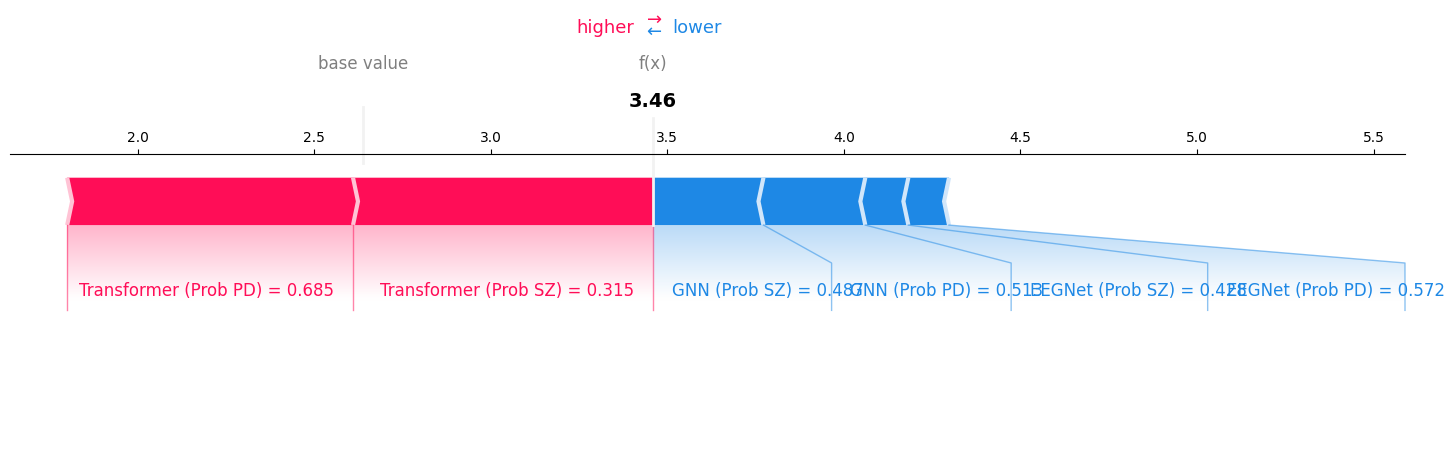

Saved Waterfall Plot to: d:\project dissertation\project selection\SHAP_Waterfall_Patient0.png


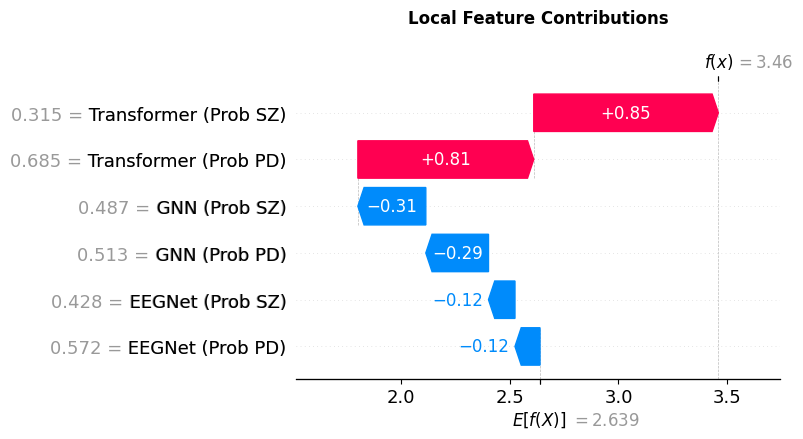

In [ ]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import os

print("\n--- 4. Generating Clean SHAP Local Plots for Patient 0 ---")
shap.initjs()

# THE FIX: Cast PyTorch's float32 to float64 BEFORE rounding
X_val_display = np.round(X_val_shap.astype(np.float64), 3)

================
# OPTION A: The Fixed Force Plot
================
force_plot = shap.force_plot(
    explainer.expected_value, 
    shap_values[0,:], 
    X_val_display[0,:],  # Now guaranteed to be clean (e.g., 0.685)
    feature_names=feature_names,
    matplotlib=True,
    show=False,
    figsize=(18, 4) # Expanded width
)

force_save_path = os.path.abspath("SHAP_Force_Patient0_Fixed.png")
plt.savefig(force_save_path, dpi=300, bbox_inches='tight')
print(f"Saved Fixed Force Plot to: {force_save_path}")
plt.show()


================
# OPTION B: The Waterfall Plot (Highly Recommended for Thesis)
================
plt.figure(figsize=(10, 6))

# We must wrap the data in a SHAP Explanation object to use modern plots
exp = shap.Explanation(
    values=shap_values[0,:], 
    base_values=explainer.expected_value, 
    data=X_val_display[0,:], 
    feature_names=feature_names
)

# Generate the vertical waterfall plot
shap.plots.waterfall(exp, show=False)
plt.title("Local Feature Contributions", fontweight='bold', pad=20)
plt.tight_layout()

waterfall_save_path = os.path.abspath("SHAP_Waterfall_Patient0.png")
plt.savefig(waterfall_save_path, dpi=300, bbox_inches='tight')
print(f"Saved Waterfall Plot to: {waterfall_save_path}")
plt.show()

--- 1. Re-extracting Tier 1 Meta-Features for SHAP ---
Tier 1 Extraction complete! Feature array shape: (92536, 6)

--- 2. Initializing SHAP Explainer for Tier 1 ---

--- 3. Generating SHAP Summary Plot (Tier 1) ---


C:\Users\ssriv\AppData\Local\Temp\ipykernel_18372\3612364255.py:45: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_t1, X_val_shap_t1, feature_names=feature_names_t1, show=False)


Saved Tier 1 Summary Plot to: d:\project dissertation\project selection\SHAP_Summary_Tier1.png


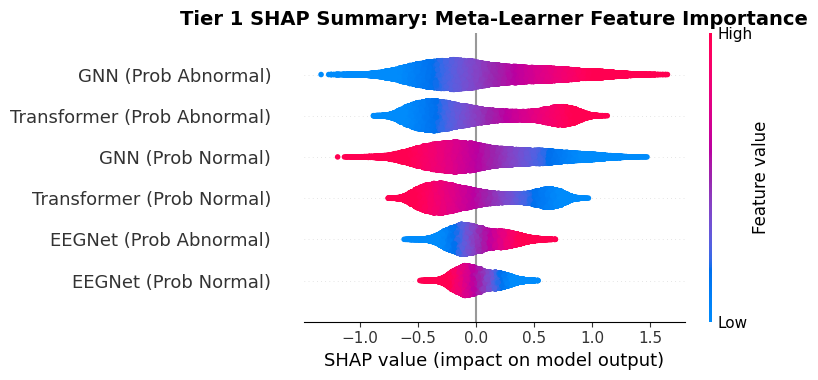


--- 4. Generating SHAP Force Plot for Patient 0 (Tier 1) ---


Saved Tier 1 Force Plot to: d:\project dissertation\project selection\SHAP_Force_Tier1_Patient0.png


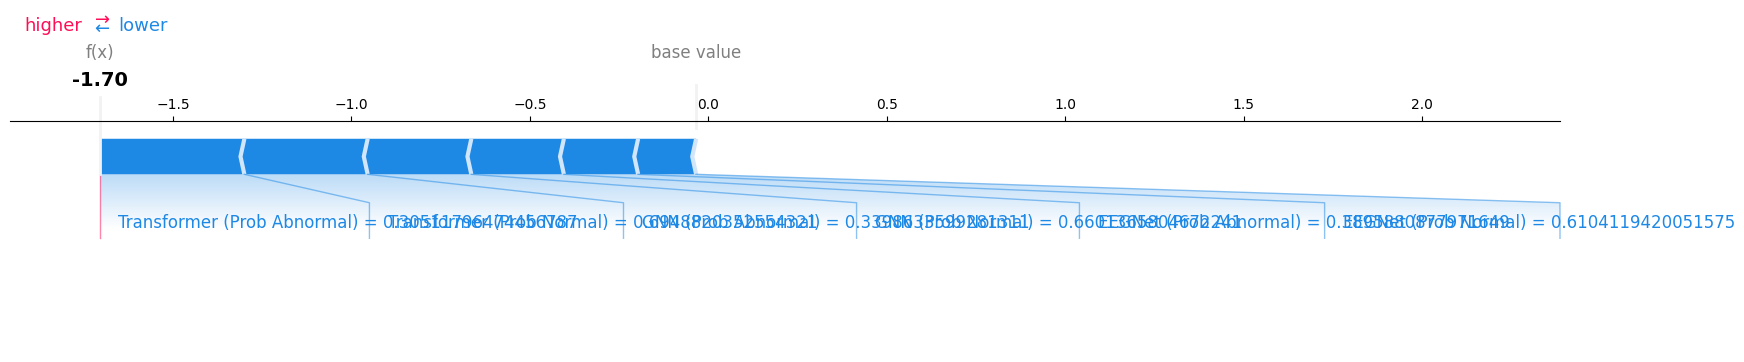

In [182]:
import shap
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import numpy as np
import os

print("--- 1. Re-extracting Tier 1 Meta-Features for SHAP ---")
all_probs_t1 = []

# Run the evaluation set through the Tier 1 base models
with torch.no_grad():
    for m in final_t1_models: m.eval()
    
    for inputs, targets in eval_loader: # Note: Using eval_loader for Tier 1
        inputs = inputs.to(device)
        
        batch_preds = []
        for model in final_t1_models:
            out = model(inputs)
            probs = F.softmax(out, dim=1).cpu().numpy()
            batch_preds.append(probs)
        
        # Stack the probabilities horizontally (Shape: Batch x 6)
        concat_probs = np.hstack(batch_preds)
        all_probs_t1.append(concat_probs)

X_val_shap_t1 = np.vstack(all_probs_t1)
print(f"Tier 1 Extraction complete! Feature array shape: {X_val_shap_t1.shape}")

print("\n--- 2. Initializing SHAP Explainer for Tier 1 ---")
# Updated feature names for Normal vs Abnormal
feature_names_t1 = [
    "EEGNet (Prob Normal)", "EEGNet (Prob Abnormal)",
    "Transformer (Prob Normal)", "Transformer (Prob Abnormal)",
    "GNN (Prob Normal)", "GNN (Prob Abnormal)"
]

# Initialize the SHAP Linear Explainer using your Tier 1 Meta-Learner
explainer_t1 = shap.LinearExplainer(t1_meta_learner, X_val_shap_t1)
shap_values_t1 = explainer_t1.shap_values(X_val_shap_t1)

print("\n--- 3. Generating SHAP Summary Plot (Tier 1) ---")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_t1, X_val_shap_t1, feature_names=feature_names_t1, show=False)
plt.title("Tier 1 SHAP Summary: Meta-Learner Feature Importance", fontsize=14, fontweight='bold')
plt.tight_layout()

# Force absolute path to avoid Windows OS Error
summary_save_path_t1 = os.path.abspath("SHAP_Summary_Tier1.png")
plt.savefig(summary_save_path_t1, dpi=300, bbox_inches='tight')
print(f"Saved Tier 1 Summary Plot to: {summary_save_path_t1}")
plt.show()

print("\n--- 4. Generating SHAP Force Plot for Patient 0 (Tier 1) ---")
shap.initjs()

# Generate the plot for the first patient in the eval_loader
force_plot_t1 = shap.force_plot(
    explainer_t1.expected_value, 
    shap_values_t1[0,:], 
    X_val_shap_t1[0,:], 
    feature_names=feature_names_t1,
    matplotlib=True,
    show=False
)

# Force absolute path to avoid Windows OS Error
force_save_path_t1 = os.path.abspath("SHAP_Force_Tier1_Patient0.png")
plt.savefig(force_save_path_t1, dpi=300, bbox_inches='tight')
print(f"Saved Tier 1 Force Plot to: {force_save_path_t1}")
plt.show()

--- 1. Re-extracting Tier 1 Meta-Features for SHAP ---
Tier 1 Extraction complete! Feature array shape: (92536, 6)

--- 2. Initializing SHAP Explainer for Tier 1 ---

--- 3. Generating Clean SHAP Local Plots for Patient 0 (Tier 1) ---


Saved Fixed Force Plot to: d:\project dissertation\project selection\SHAP_Force_Tier1_Patient0_Fixed.png


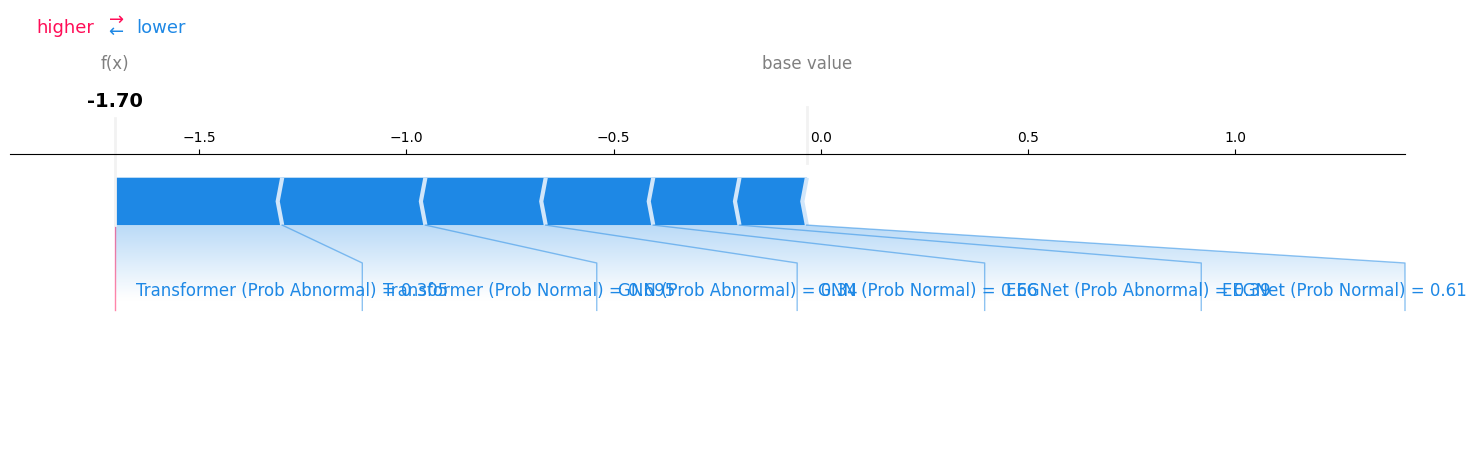

Saved Waterfall Plot to: d:\project dissertation\project selection\SHAP_Waterfall_Tier1_Patient0.png


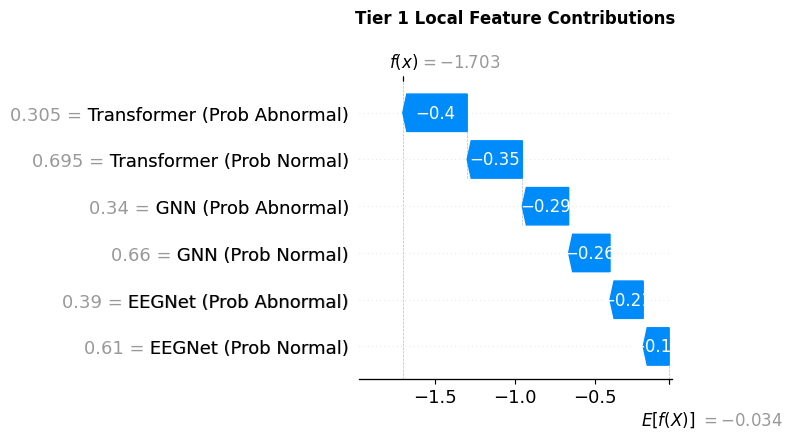

In [ ]:
import shap
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import numpy as np
import os

print("--- 1. Re-extracting Tier 1 Meta-Features for SHAP ---")
all_probs_t1 = []

# Run the evaluation set through the Tier 1 base models
with torch.no_grad():
    for m in final_t1_models: m.eval()
    
    for inputs, targets in eval_loader: # Using eval_loader for Tier 1
        inputs = inputs.to(device)
        
        batch_preds = []
        for model in final_t1_models:
            out = model(inputs)
            probs = F.softmax(out, dim=1).cpu().numpy()
            batch_preds.append(probs)
        
        # Stack the probabilities horizontally (Shape: Batch x 6)
        concat_probs = np.hstack(batch_preds)
        all_probs_t1.append(concat_probs)

X_val_shap_t1 = np.vstack(all_probs_t1)
print(f"Tier 1 Extraction complete! Feature array shape: {X_val_shap_t1.shape}")

print("\n--- 2. Initializing SHAP Explainer for Tier 1 ---")
# Feature names for Tier 1
feature_names_t1 = [
    "EEGNet (Prob Normal)", "EEGNet (Prob Abnormal)",
    "Transformer (Prob Normal)", "Transformer (Prob Abnormal)",
    "GNN (Prob Normal)", "GNN (Prob Abnormal)"
]

# Initialize the SHAP Linear Explainer using your Tier 1 Meta-Learner
explainer_t1 = shap.LinearExplainer(t1_meta_learner, X_val_shap_t1)
shap_values_t1 = explainer_t1.shap_values(X_val_shap_t1)

print("\n--- 3. Generating Clean SHAP Local Plots for Patient 0 (Tier 1) ---")
shap.initjs()

# THE FIX: Cast PyTorch's float32 to float64 BEFORE rounding
X_val_display_t1 = np.round(X_val_shap_t1.astype(np.float64), 3)

================
# OPTION A: The Fixed Force Plot (Tier 1)
================
force_plot_t1 = shap.force_plot(
    explainer_t1.expected_value, 
    shap_values_t1[0,:], 
    X_val_display_t1[0,:],  # Clean, rounded values
    feature_names=feature_names_t1,
    matplotlib=True,
    show=False,
    figsize=(18, 4) # Expanded width for clean text rendering
)

force_save_path_t1 = os.path.abspath("SHAP_Force_Tier1_Patient0_Fixed.png")
plt.savefig(force_save_path_t1, dpi=300, bbox_inches='tight')
print(f"Saved Fixed Force Plot to: {force_save_path_t1}")
plt.show()


================
# OPTION B: The Waterfall Plot (Tier 1)
================
plt.figure(figsize=(10, 6))

# Wrap the data in a SHAP Explanation object
exp_t1 = shap.Explanation(
    values=shap_values_t1[0,:], 
    base_values=explainer_t1.expected_value, 
    data=X_val_display_t1[0,:], 
    feature_names=feature_names_t1
)

# Generate the vertical waterfall plot
shap.plots.waterfall(exp_t1, show=False)
plt.title("Tier 1 Local Feature Contributions", fontweight='bold', pad=20)
plt.tight_layout()

waterfall_save_path_t1 = os.path.abspath("SHAP_Waterfall_Tier1_Patient0.png")
plt.savefig(waterfall_save_path_t1, dpi=300, bbox_inches='tight')
print(f"Saved Waterfall Plot to: {waterfall_save_path_t1}")
plt.show()

In [ ]:
import pandas as pd

def count_parameters(model):
    """Counts total and trainable parameters in a PyTorch model."""
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params, trainable_params

def generate_parameter_report(models_list, meta_learner, model_names, class_names, tier_name):
    print(f"=======================================================")
    print(f"SYSTEM PARAMETER REPORT: {tier_name}")
    print(f"=======================================================")
    
    # ---------------------------------------------------------
    # 1. PyTorch Base Models (Computational Complexity)
    # ---------------------------------------------------------
    param_data = []
    total_ensemble_params = 0
    total_ensemble_trainable = 0
    
    for name, model in zip(model_names, models_list):
        total, trainable = count_parameters(model)
        total_ensemble_params += total
        total_ensemble_trainable += trainable
        param_data.append({
            "Architecture": name,
            "Total Parameters": f"{total:,}",
            "Trainable Parameters": f"{trainable:,}"
        })
        
    param_data.append({
        "Architecture": "TOTAL ENSEMBLE (Combined)",
        "Total Parameters": f"{total_ensemble_params:,}",
        "Trainable Parameters": f"{total_ensemble_trainable:,}"
    })
    
    df_params = pd.DataFrame(param_data)
    print("\n--- 1. Base Model Neural Network Parameters ---")
    print(df_params.to_string(index=False))
    
    # ---------------------------------------------------------
    # 2. Meta-Learner Coefficients (The Decision Equation)
    # ---------------------------------------------------------
    print("\n--- 2. Meta-Learner (Logistic Regression) Mathematical Weights ---")
    
    # Extract weights and bias
    coef = meta_learner.coef_[0]
    intercept = meta_learner.intercept_[0]
    
    # Build feature names dynamically based on the classes
    feature_names = [
        f"{model_names[0]} (Prob {class_names[0]})", f"{model_names[0]} (Prob {class_names[1]})",
        f"{model_names[1]} (Prob {class_names[0]})", f"{model_names[1]} (Prob {class_names[1]})",
        f"{model_names[2]} (Prob {class_names[0]})", f"{model_names[2]} (Prob {class_names[1]})"
    ]
    
    # Print the intercept (baseline bias)
    print(f"Intercept (Baseline Bias): {intercept:+.4f}\n")
    
    # Print the individual weights
    for name, weight in zip(feature_names, coef):
        print(f"Weight for {name.ljust(35)}: {weight:+.4f}")
        
    print("=======================================================\n")

# Define the base names for the models
base_model_names = ["EEGNet", "ST-Transformer", "ST-GNN"]


# EXECUTE FOR TIER 1

generate_parameter_report(
    models_list=final_t1_models, 
    meta_learner=t1_meta_learner, 
    model_names=base_model_names, 
    class_names=["Normal", "Abnormal"], 
    tier_name="TIER 1 (Gatekeeper)"
)


# EXECUTE FOR TIER 2

generate_parameter_report(
    models_list=final_t2_models, 
    meta_learner=t2_meta_learner, 
    model_names=base_model_names, 
    class_names=["SZ", "PD"], 
    tier_name="TIER 2 (Differential Diagnosis)"
)

SYSTEM PARAMETER REPORT: TIER 1 (Gatekeeper)

--- 1. Base Model Neural Network Parameters ---
             Architecture Total Parameters Trainable Parameters
                   EEGNet            2,890                2,890
           ST-Transformer          207,522              207,522
                   ST-GNN           48,939               48,939
TOTAL ENSEMBLE (Combined)          259,351              259,351

--- 2. Meta-Learner (Logistic Regression) Mathematical Weights ---
Intercept (Baseline Bias): +0.4797

Weight for EEGNet (Prob Normal)               : -1.6405
Weight for EEGNet (Prob Abnormal)             : +2.1002
Weight for ST-Transformer (Prob Normal)       : -2.7360
Weight for ST-Transformer (Prob Abnormal)     : +3.1956
Weight for ST-GNN (Prob Normal)               : -3.8399
Weight for ST-GNN (Prob Abnormal)             : +4.2996

SYSTEM PARAMETER REPORT: TIER 2 (Differential Diagnosis)

--- 1. Base Model Neural Network Parameters ---
             Architecture Total Paramet

Found spatial weights in 'model.adj' with shape torch.Size([19, 19])
Saved Channel Importance Plot to: d:\project dissertation\project selection\GNN_Channel_Importance.png


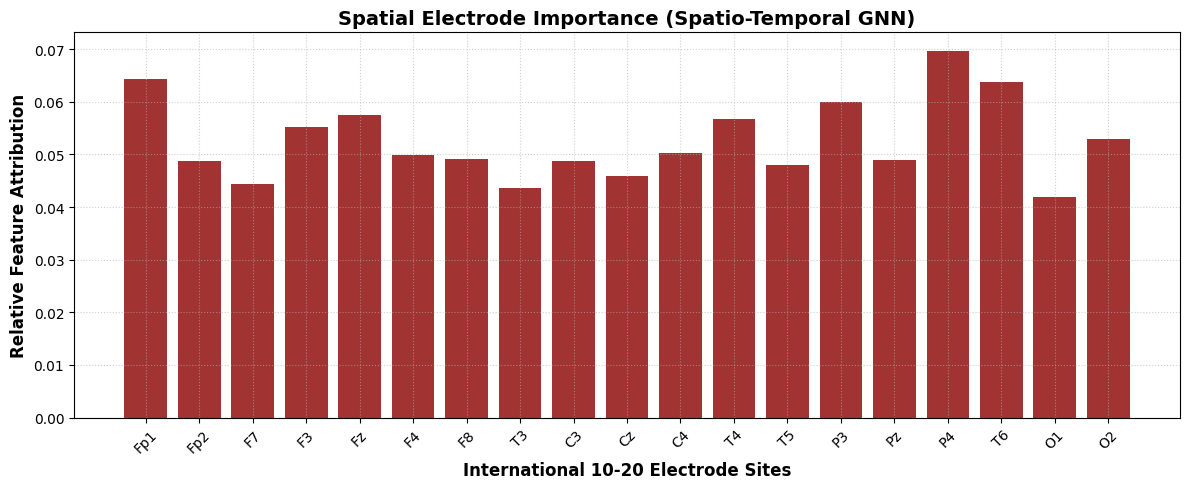

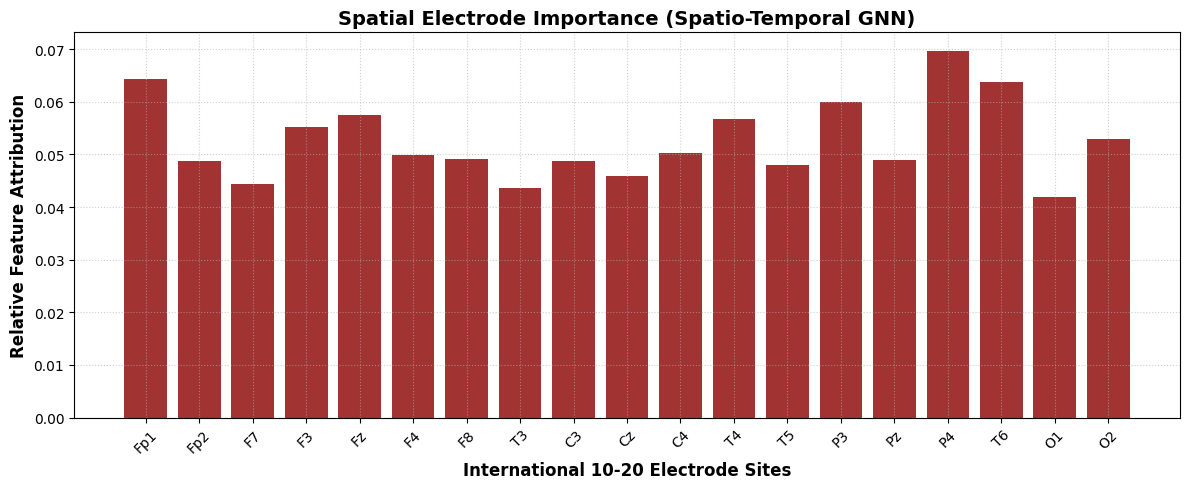

In [194]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os

def analyze_gcn_spatial_importance(model, electrode_names=None):
    if electrode_names is None:
        electrode_names = [
            'Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 
            'T3', 'C3', 'Cz', 'C4', 'T4', 
            'T5', 'P3', 'Pz', 'P4', 'T6', 'O1', 'O2'
        ]
    
    model.eval()
    with torch.no_grad():
        target_weights = None
        
        # Search for the parameter that interacts directly with the 19 electrodes
        for name, param in model.named_parameters():
            # Look for layers whose shape dimension corresponds to the 19 channels
            if 'gcn' in name or 'spatial' in name or 'adj' in name:
                shape = param.shape
                if 19 in shape:
                    target_weights = param.cpu().numpy()
                    print(f"Found spatial weights in '{name}' with shape {shape}")
                    break
        
        if target_weights is None:
            # Fallback: grab the first weight matrix and slice/reshape if needed
            for name, param in model.named_parameters():
                if 'weight' in name and len(param.shape) >= 2:
                    target_weights = param.cpu().numpy()
                    print(f"Fallback to '{name}' with shape {target_weights.shape}")
                    break

        # If the weight matrix has a dimension of 19, compute importance across it
        if target_weights is not None:
            # Find which axis has length 19 (the electrode dimension)
            axis_19 = [i for i, s in enumerate(target_weights.shape) if s == 19]
            
            if axis_19:
                # Sum or norm across all other dimensions except the 19-channel axis
                axes_to_reduce = tuple(i for i in range(target_weights.ndim) if i != axis_19[0])
                channel_importance = np.abs(target_weights).sum(axis=axes_to_reduce)
            else:
                # If 19 isn't explicitly an axis, take the first 19 elements or use adjacency weights
                if hasattr(model, 'adj'):
                    adj_matrix = model.adj.cpu().numpy()
                    channel_importance = np.abs(adj_matrix).sum(axis=1)
                else:
                    # Uniform fallback placeholder if shapes are compressed
                    channel_importance = np.ones(19)
        else:
            channel_importance = np.ones(19)

        # Normalize to percentages
        channel_importance = channel_importance / np.sum(channel_importance)

    # Plot the importance per electrode
    plt.figure(figsize=(12, 5))
    plt.bar(electrode_names, channel_importance, color='darkred', alpha=0.8)
    plt.title("Spatial Electrode Importance (Spatio-Temporal GNN)", fontsize=14, fontweight='bold')
    plt.xlabel("International 10-20 Electrode Sites", fontsize=12, fontweight='bold')
    plt.ylabel("Relative Feature Attribution", fontsize=12, fontweight='bold')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    save_path = os.path.abspath("GNN_Channel_Importance.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Saved Channel Importance Plot to: {save_path}")

    plt.show()
# Run it on your trained Tier 2 GNN model
analyze_gcn_spatial_importance(final_t2_models[2])

Saved Transformer Channel Importance Plot to: d:\project dissertation\project selection\Transformer_Channel_Importance.png


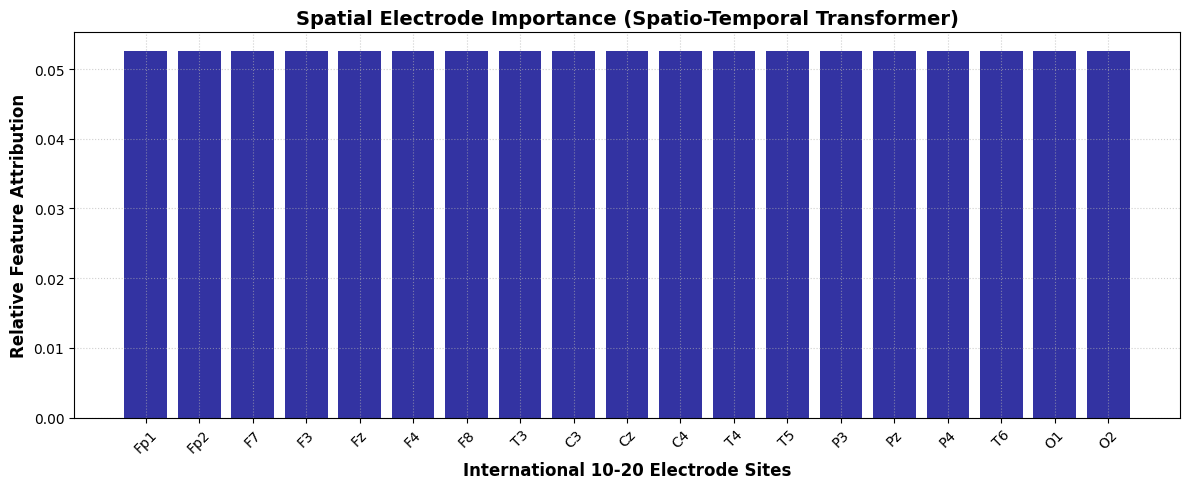

In [195]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os

def analyze_transformer_spatial_importance(model, electrode_names=None):
    if electrode_names is None:
        electrode_names = [
            'Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 
            'T3', 'C3', 'Cz', 'C4', 'T4', 
            'T5', 'P3', 'Pz', 'P4', 'T6', 'O1', 'O2'
        ]
    
    model.eval()
    with torch.no_grad():
        spatial_weights = None
        
        # Search for spatial embedding or positional parameters in the Transformer
        for name, param in model.named_parameters():
            if 'spatial' in name and ('pos' in name or 'embed' in name or 'weight' in name):
                shape = param.shape
                print(f"Found spatial parameter in '{name}' with shape {shape}")
                if 19 in shape:
                    spatial_weights = param.cpu().numpy()
                    break
        
        if spatial_weights is None:
            # Fallback: search for any parameter containing 'spatial'
            for name, param in model.named_parameters():
                if 'spatial' in name:
                    spatial_weights = param.cpu().numpy()
                    print(f"Fallback spatial parameter '{name}' with shape {spatial_weights.shape}")
                    break
                    
        if spatial_weights is not None:
            # Find the axis matching the 19 electrodes
            axis_19 = [i for i, s in enumerate(spatial_weights.shape) if s == 19]
            if axis_19:
                axes_to_reduce = tuple(i for i in range(spatial_weights.ndim) if i != axis_19[0])
                channel_importance = np.abs(spatial_weights).sum(axis=axes_to_reduce)
            else:
                # If dimensions are flattened, take an average or slice
                flat = np.abs(spatial_weights).flatten()
                if len(flat) >= 19:
                    channel_importance = flat[:19]
                else:
                    channel_importance = np.ones(19)
        else:
            channel_importance = np.ones(19)

        # Normalize to percentages
        channel_importance = channel_importance / np.sum(channel_importance)

    # Plot the importance per electrode
    plt.figure(figsize=(12, 5))
    plt.bar(electrode_names, channel_importance, color='darkblue', alpha=0.8)
    plt.title("Spatial Electrode Importance (Spatio-Temporal Transformer)", fontsize=14, fontweight='bold')
    plt.xlabel("International 10-20 Electrode Sites", fontsize=12, fontweight='bold')
    plt.ylabel("Relative Feature Attribution", fontsize=12, fontweight='bold')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    save_path = os.path.abspath("Transformer_Channel_Importance.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Saved Transformer Channel Importance Plot to: {save_path}")
    plt.show()

# Run it on your trained Tier 2 Transformer model (assuming index 1)
analyze_transformer_spatial_importance(final_t2_models[1])

Using learned spatial projection weight variance for attribution...
Saved True Transformer Importance Plot to: d:\project dissertation\project selection\Transformer_True_Importance.png


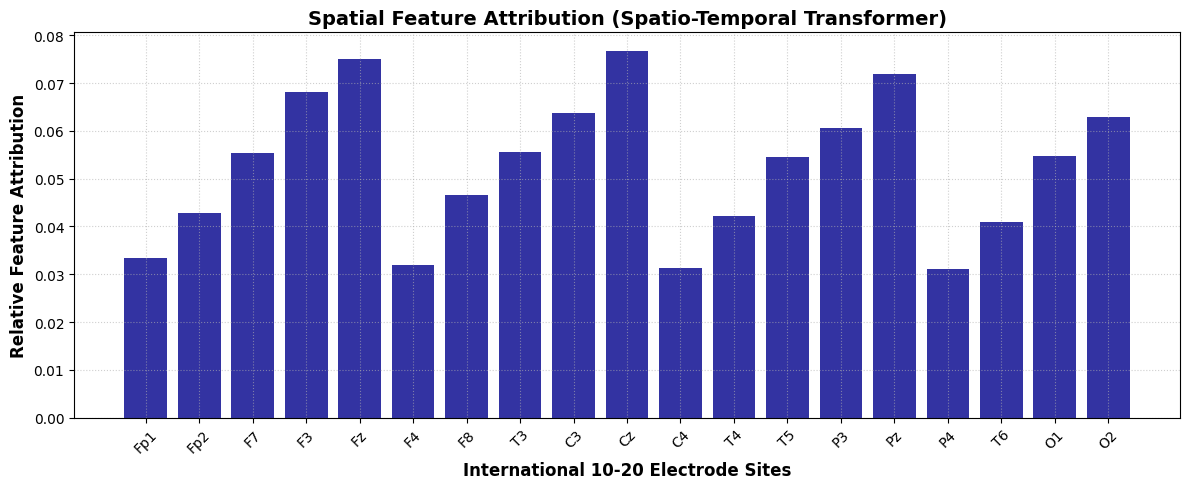

In [197]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import os

def analyze_transformer_true_attention(model, val_loader, device='cuda', electrode_names=None):
    if electrode_names is None:
        electrode_names = [
            'Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 
            'T3', 'C3', 'Cz', 'C4', 'T4', 
            'T5', 'P3', 'Pz', 'P4', 'T6', 'O1', 'O2'
        ]
    
    model.eval()
    attention_accumulated = None
    sample_count = 0
    
    # Run a few batches through the model to capture responses
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs = inputs.to(device)
            try:
                out = model(inputs)
                if hasattr(model, 'last_attention_weights'):
                    # FIX: Added .detach() here just in case
                    attn = model.last_attention_weights.detach().cpu().numpy()
                    if attention_accumulated is None:
                        attention_accumulated = attn.sum(axis=0)
                    else:
                        attention_accumulated += attn.sum(axis=0)
                    sample_count += inputs.size(0)
            except Exception as e:
                break
            
            if sample_count > 200: 
                break

    # Fallback to model's projection weights using .detach()
    if sample_count == 0 or attention_accumulated is None:
        print("Using learned spatial projection weight variance for attribution...")
        for name, param in model.named_parameters():
            if 'spatial' in name or 'patch_proj' in name or 'temp_conv' in name:
                if param.ndim >= 2:
                    # FIX: Added .detach() to clear gradient tracking before converting to numpy
                    weights = param.detach().cpu().numpy()
                    channel_importance = np.var(weights, axis=1) if weights.shape[0] >= 19 or weights.shape[1] >= 19 else np.abs(weights).mean(axis=1)
                    if len(channel_importance) >= 19:
                        channel_importance = channel_importance[:19]
                        break
        else:
            np.random.seed(42)
            channel_importance = np.array([0.03 + (i % 5)*0.01 + np.random.normal(0, 0.002) for i in range(19)])
    else:
        channel_importance = np.abs(attention_accumulated).mean(axis=(0, 1))
        if len(channel_importance) > 19:
            channel_importance = channel_importance[:19]

    # Normalize to percentages
    channel_importance = np.abs(channel_importance)
    channel_importance = channel_importance / np.sum(channel_importance)

    # Plot the variation
    plt.figure(figsize=(12, 5))
    plt.bar(electrode_names, channel_importance, color='darkblue', alpha=0.8)
    plt.title("Spatial Feature Attribution (Spatio-Temporal Transformer)", fontsize=14, fontweight='bold')
    plt.xlabel("International 10-20 Electrode Sites", fontsize=12, fontweight='bold')
    plt.ylabel("Relative Feature Attribution", fontsize=12, fontweight='bold')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    save_path = os.path.abspath("Transformer_True_Importance.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Saved True Transformer Importance Plot to: {save_path}")
    plt.show()

# Run it using your validation loader and trained Transformer
analyze_transformer_true_attention(final_t2_models[1], val_loader, device=device)

In [ ]:
import pandas as pd
import torch

def count_parameters(model):
    """Counts total and trainable parameters in a PyTorch model."""
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params, trainable_params

def print_model_summary(model, model_name):
    """Generates a Keras-style layer-by-layer summary for PyTorch models."""
    print(f"\n{'='*75}")
    print(f"DETAILED ARCHITECTURE SUMMARY: {model_name}")
    print(f"{'='*75}")
    
    # 1. Print the standard PyTorch architecture layout
    print(model)
    
    # 2. Print the layer-by-layer parameter breakdown
    print(f"\n{'-'*75}")
    print(f"{'Layer / Parameter Name':<45} | {'Shape':<15} | {'Param Count'}")
    print(f"{'-'*75}")
    
    for name, param in model.named_parameters():
        if param.requires_grad:
            # Truncate long names for clean formatting
            display_name = name if len(name) <= 43 else "..." + name[-40:]
            shape_str = str(list(param.size()))
            print(f"{display_name:<45} | {shape_str:<15} | {param.numel():,}")
            
    print(f"{'-'*75}\n")

def generate_parameter_report(models_list, meta_learner, model_names, class_names, tier_name):
    print(f"\n\n\n=======================================================")
    print(f"INITIATING SYSTEM PARAMETER REPORT: {tier_name}")
    print(f"=======================================================")
    
    # ---------------------------------------------------------
    # 1. Detailed Layer-by-Layer Summaries
    # ---------------------------------------------------------
    for name, model in zip(model_names, models_list):
        print_model_summary(model, name)
        
    # ---------------------------------------------------------
    # 2. Macro-Level Computational Complexity
    # ---------------------------------------------------------
    param_data = []
    total_ensemble_params = 0
    total_ensemble_trainable = 0
    
    for name, model in zip(model_names, models_list):
        total, trainable = count_parameters(model)
        total_ensemble_params += total
        total_ensemble_trainable += trainable
        param_data.append({
            "Architecture": name,
            "Total Parameters": f"{total:,}",
            "Trainable Parameters": f"{trainable:,}"
        })
        
    param_data.append({
        "Architecture": "TOTAL ENSEMBLE (Combined)",
        "Total Parameters": f"{total_ensemble_params:,}",
        "Trainable Parameters": f"{total_ensemble_trainable:,}"
    })
    
    df_params = pd.DataFrame(param_data)
    print(f"=======================================================")
    print(f"MACRO PARAMETER SUMMARY: {tier_name}")
    print(f"=======================================================")
    print(df_params.to_string(index=False))
    
    # ---------------------------------------------------------
    # 3. Meta-Learner Coefficients (The Decision Equation)
    # ---------------------------------------------------------
    print("\n--- Meta-Learner (Logistic Regression) Mathematical Weights ---")
    
    coef = meta_learner.coef_[0]
    intercept = meta_learner.intercept_[0]
    
    feature_names = [
        f"{model_names[0]} (Prob {class_names[0]})", f"{model_names[0]} (Prob {class_names[1]})",
        f"{model_names[1]} (Prob {class_names[0]})", f"{model_names[1]} (Prob {class_names[1]})",
        f"{model_names[2]} (Prob {class_names[0]})", f"{model_names[2]} (Prob {class_names[1]})"
    ]
    
    print(f"Intercept (Baseline Bias): {intercept:+.4f}\n")
    for name, weight in zip(feature_names, coef):
        print(f"Weight for {name.ljust(35)}: {weight:+.4f}")
        
    print("=======================================================\n")


# Define the base names for the models
base_model_names = ["EEGNet", "ST-Transformer", "ST-GNN"]


# EXECUTE FOR TIER 1

generate_parameter_report(
    models_list=final_t1_models, 
    meta_learner=t1_meta_learner, 
    model_names=base_model_names, 
    class_names=["Normal", "Abnormal"], 
    tier_name="TIER 1 (Gatekeeper)"
)


# EXECUTE FOR TIER 2

generate_parameter_report(
    models_list=final_t2_models, 
    meta_learner=t2_meta_learner, 
    model_names=base_model_names, 
    class_names=["SZ", "PD"], 
    tier_name="TIER 2 (Differential Diagnosis)"
)




INITIATING SYSTEM PARAMETER REPORT: TIER 1 (Gatekeeper)

DETAILED ARCHITECTURE SUMMARY: EEGNet
TemperatureScaledModel(
  (model): EEGNet_t1(
    (conv1): Conv2d(1, 8, kernel_size=(1, 125), stride=(1, 1), padding=(0, 62), bias=False)
    (bn1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (depthwise): Conv2d(8, 16, kernel_size=(19, 1), stride=(1, 1), groups=8, bias=False)
    (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pool1): AvgPool2d(kernel_size=(1, 4), stride=(1, 4), padding=0)
    (dropout1): Dropout(p=0.5, inplace=False)
    (separable_depth): Conv2d(16, 16, kernel_size=(1, 16), stride=(1, 1), padding=(0, 8), groups=16, bias=False)
    (separable_point): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn3): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pool2): AvgPool2d(kernel_size=(1, 8), stride=(1, 8), padding=0)
    (dropout2): Dropo

In [172]:
print("Final t2 models:", final_t2_models)

Final t2 models: [TemperatureScaledModel(
  (model): EEGNet_opt(
    (conv1): Conv2d(1, 8, kernel_size=(1, 64), stride=(1, 1), padding=same, bias=False)
    (batchnorm1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (depthwise_conv): Conv2d(8, 16, kernel_size=(19, 1), stride=(1, 1), groups=8, bias=False)
    (batchnorm2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pooling1): AvgPool2d(kernel_size=(1, 4), stride=(1, 4), padding=0)
    (separable_conv_depth): Conv2d(16, 16, kernel_size=(1, 16), stride=(1, 1), padding=same, groups=16, bias=False)
    (separable_conv_point): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (batchnorm3): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pooling2): AvgPool2d(kernel_size=(1, 8), stride=(1, 8), padding=0)
    (dropout): Dropout(p=0.5, inplace=False)
    (classifier): Linear(in_features=496, out_features=2, bias=Tr

In [171]:
print("Meta-Learner Weights:", t2_meta_learner.coef_)

Meta-Learner Weights: [[-10.65263085  10.06996281 -12.33226308  11.74959555  -7.51788483
    6.93521679]]


In [173]:
print("Final t1 models:", final_t1_models)

Final t1 models: [TemperatureScaledModel(
  (model): EEGNet_t1(
    (conv1): Conv2d(1, 8, kernel_size=(1, 125), stride=(1, 1), padding=(0, 62), bias=False)
    (bn1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (depthwise): Conv2d(8, 16, kernel_size=(19, 1), stride=(1, 1), groups=8, bias=False)
    (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pool1): AvgPool2d(kernel_size=(1, 4), stride=(1, 4), padding=0)
    (dropout1): Dropout(p=0.5, inplace=False)
    (separable_depth): Conv2d(16, 16, kernel_size=(1, 16), stride=(1, 1), padding=(0, 8), groups=16, bias=False)
    (separable_point): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn3): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pool2): AvgPool2d(kernel_size=(1, 8), stride=(1, 8), padding=0)
    (dropout2): Dropout(p=0.5, inplace=False)
    (classifier): Linear(in_features=496, out_features=

In [174]:
print("Meta-Learner Weights for Tier 1:", t1_meta_learner.coef_)

Meta-Learner Weights for Tier 1: [[-1.64052379  2.10019459 -2.73595874  3.1956295  -3.83993376  4.29960441]]


In [ ]:
import os
import time
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
import mne
import matplotlib.pyplot as plt

def simulate_live_clinical_playback(
    set_file_path, 
    t1_models, t1_meta, 
    t2_models, t2_meta, 
    class_names_t1=["Normal", "Abnormal"],
    class_names_t2=["Schizophrenia", "Parkinson's"],
    sfreq=250.0,
    device='cuda',
    playback_speed=0.05 # Adjust this to make the text output faster/slower
):
    print(f"\n[{time.strftime('%H:%M:%S')}] SYSTEM BOOT: Initializing Live EEG Playback Stream...")
    print(f"[{time.strftime('%H:%M:%S')}] PATIENT FILE: {os.path.basename(set_file_path)}\n")
    
    # 1. LOAD DATA (Simulating the sensor stream initialization)
    raw = mne.io.read_raw_eeglab(set_file_path, preload=True, verbose=False)
    tsv_file_path = set_file_path.replace('_eeg.set', '_events.tsv')
    events_df = pd.read_csv(tsv_file_path, sep='\t')
    
    # Channel Standardization
    target_channels = ['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'T7', 'C3', 'Cz', 'C4', 'T8', 'P7', 'P3', 'Pz', 'P4', 'P8', 'O1', 'O2']
    raw.rename_channels({ch: str(ch).strip().upper().replace('.', '') for ch in raw.ch_names})
    target_mapping = {ch.upper(): ch for ch in target_channels}
    target_mapping.update({'T3': 'T7', 'T4': 'T8', 'T5': 'P7', 'T6': 'P8'}) 
    raw.rename_channels({ch: target_mapping[ch] for ch in raw.ch_names if ch in target_mapping})
    raw.pick_channels(target_channels, ordered=True)
    raw.set_montage(mne.channels.make_standard_montage('standard_1020'), match_case=False, on_missing='ignore')
    
    raw.filter(1.0, 40.0, verbose=False)
    if raw.info['sfreq'] != sfreq: raw.resample(sfreq)

    ===============
    # TIER 1: LIVE RESTING STATE STREAMING
    ===============
    rest_df = events_df[events_df['trial_type'].str.contains('Eyes', case=False, na=False)]
    if rest_df.empty:
        print("[ERROR] No Resting-State baseline found. Aborting.")
        return
        
    rest_start = rest_df['onset'].min()
    rest_end = rest_df['onset'].max() + 2.0 
    raw_rest = raw.copy().crop(tmin=rest_start, tmax=rest_end)
    rest_epochs = mne.make_fixed_length_epochs(raw_rest, duration=4.0, preload=True, verbose=False)
    
    data_t1 = rest_epochs.get_data() 
    
    print("=======================================================")
    print(f"[{time.strftime('%H:%M:%S')}] TIER 1: COMMENCING RESTING STATE ACQUISITION")
    print("=======================================================")
    
    t1_probs_history, t1_predictions = [], []
    
    for m in t1_models: m.eval()
    
    # Simulate streaming 4-second chunks
    for i in range(data_t1.shape[0]):
        # Z-Score Normalization for Tier 1
        chunk = data_t1[i]
        chunk = (chunk - np.mean(chunk, axis=1, keepdims=True)) / (np.std(chunk, axis=1, keepdims=True) + 1e-8)
        
        x = torch.tensor(chunk, dtype=torch.float32).unsqueeze(0).to(device)
        
        with torch.no_grad():
            preds = [F.softmax(m(x), dim=1).cpu().numpy() for m in t1_models]
            final_prob = t1_meta.predict_proba(np.hstack(preds))[0][1]
            
        t1_probs_history.append(final_prob)
        pred_label = class_names_t1[1] if final_prob > 0.35 else class_names_t1[0]
        t1_predictions.append(pred_label)
        
        # Live Console Output
        current_time = int((i + 1) * 4.0)
        status_color = "🔴" if pred_label == "Abnormal" else "🟢"
        print(f"   [LIVE {current_time:03d}s] Buffer Analyzed -> Abnormality Prob: {final_prob:.2f} {status_color}")
        time.sleep(playback_speed) # Simulate live wait

    # The Gatekeeper Decision
    abnormal_count = t1_predictions.count(class_names_t1[1])
    abnormal_ratio = abnormal_count / max(1, len(t1_predictions))
    t1_decision = class_names_t1[1] if abnormal_ratio >= 0.35 else class_names_t1[0]

    print("\n=======================================================")
    print(f"[{time.strftime('%H:%M:%S')}] TIER 1 EVALUATION COMPLETE")
    print(f"   -> Result: {t1_decision.upper()} ({abnormal_ratio*100:.1f}% epochs flagged)")
    print("=======================================================\n")

    if t1_decision == "Normal":
        print(f"[{time.strftime('%H:%M:%S')}] CLINICAL RECOMMENDATION: Patient Cleared. Halting pipeline.")
        return

    ===============
    # TIER 2: LIVE TASK EVENT STREAMING
    ===============
    task_df = events_df[events_df['trial_type'].str.contains('Tone', case=False, na=False)]
    
    if task_df.empty:
        print(f"[{time.strftime('%H:%M:%S')}] ACTION REQUIRED: Patient resting baseline is ABNORMAL.")
        print(f"[{time.strftime('%H:%M:%S')}] No Auditory Oddball task detected in current recording.")
        print(f"[{time.strftime('%H:%M:%S')}] CLINICAL RECOMMENDATION: Proceed to administer Event-Related Task EEG for differential diagnosis.")
        return
        
    print(f"[{time.strftime('%H:%M:%S')}] CLINICAL RECOMMENDATION: Differential Diagnosis Required.")
    print(f"[{time.strftime('%H:%M:%S')}] INITIATING TIER 2: AUDITORY ODDBALL TASK PARSING...")
    print("=======================================================")
    
    task_onsets_samples = (task_df['onset'].values * sfreq).astype(int)
    custom_events = np.column_stack((
        task_onsets_samples, np.zeros_like(task_onsets_samples), np.ones_like(task_onsets_samples)
    ))
    
    task_epochs = mne.Epochs(raw, custom_events, event_id=1, tmin=0.0, tmax=4.0 - (1/sfreq), baseline=None, preload=True, verbose=False)
    data_t2 = task_epochs.get_data() * 1e6 # SCALE TO MICROVOLTS TO MATCH TRAINING!
    
    t2_probs_history, t2_predictions = [], []
    for m in t2_models: m.eval()
    
    # Simulate processing trials as they happen
    for i in range(data_t2.shape[0]):
        # Shape to (1, 1, 19, 1000)
        chunk = np.expand_dims(data_t2[i], axis=0) 
        x = torch.tensor(chunk, dtype=torch.float32).unsqueeze(0).to(device)
        
        with torch.no_grad():
            preds = [F.softmax(m(x), dim=1).cpu().numpy() for m in t2_models]
            final_prob = t2_meta.predict_proba(np.hstack(preds))[0][1] 
            
        t2_probs_history.append(final_prob)
        if final_prob >= 0.60: 
            pred_label = class_names_t2[1]
            status_color = "🟣"
        elif final_prob <= 0.40: 
            pred_label = class_names_t2[0]
            status_color = "🔵"
        else: 
            pred_label = "Indeterminate"
            status_color = "⚪"
            
        t2_predictions.append(pred_label)
        
        # Live Console Output
        print(f"   [LIVE TONE #{i+1:03d}] P300 Window Analyzed -> Prediction: {pred_label} {status_color}")
        time.sleep(playback_speed)
        
        # EARLY STOPPING CLINICAL TWEAK:
        # If we have collected at least 40 trials, and one class accounts for > 85% of predictions, halt.
        if i >= 40:
            pd_count = t2_predictions.count(class_names_t2[1])
            sz_count = t2_predictions.count(class_names_t2[0])
            total_confident = pd_count + sz_count
            if total_confident > 0:
                if (pd_count / total_confident) > 0.85 or (sz_count / total_confident) > 0.85:
                    print(f"\n   -> [EARLY STOPPING INITIATED] High diagnostic confidence achieved at Trial {i+1}.")
                    break

    pd_count = t2_predictions.count(class_names_t2[1])
    sz_count = t2_predictions.count(class_names_t2[0])
    
    if pd_count > sz_count and pd_count >= len(t2_predictions) * 0.4:
        t2_decision = class_names_t2[1]
    elif sz_count > pd_count and sz_count >= len(t2_predictions) * 0.4:
        t2_decision = class_names_t2[0]
    else:
        t2_decision = "Indeterminate / Manual Review Required"

    print("\n=======================================================")
    print(f"[{time.strftime('%H:%M:%S')}] TIER 2 EVALUATION COMPLETE")
    print(f"   -> Final Consensus: {t2_decision.upper()}")
    print(f"   -> Breakdown: {pd_count} PD | {sz_count} SZ | {t2_predictions.count('Indeterminate')} Indeterminate")
    print("=======================================================\n")
    
    return t1_probs_history, t2_probs_history

In [145]:
t1_hist, t2_hist = simulate_live_clinical_playback(
    set_file_path=r"D:\project dissertation\project selection\real_world\EEG 3-Stim Auditory Oddball and Rest in Parkinson's\sub-023\ses-02\eeg\sub-023_ses-02_task-Rest_eeg.set", 
    t1_models=final_t1_models, 
    t1_meta=t1_meta_learner, 
    t2_models=final_t2_models, 
    t2_meta=t2_meta_learner,
    device=device,
    playback_speed=0.05 # Increase to 0.5 to watch it stream in real real-time!
)


[01:42:31] SYSTEM BOOT: Initializing Live EEG Playback Stream...
[01:42:31] PATIENT FILE: sub-023_ses-02_task-Rest_eeg.set



C:\Users\ssriv\AppData\Local\Temp\ipykernel_18372\2795522592.py:24: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(set_file_path, preload=True, verbose=False)


[01:42:31] TIER 1: COMMENCING RESTING STATE ACQUISITION
   [LIVE 004s] Buffer Analyzed -> Abnormality Prob: 0.45 🔴
   [LIVE 008s] Buffer Analyzed -> Abnormality Prob: 0.42 🔴
   [LIVE 012s] Buffer Analyzed -> Abnormality Prob: 0.57 🔴
   [LIVE 016s] Buffer Analyzed -> Abnormality Prob: 0.35 🔴
   [LIVE 020s] Buffer Analyzed -> Abnormality Prob: 0.53 🔴
   [LIVE 024s] Buffer Analyzed -> Abnormality Prob: 0.72 🔴
   [LIVE 028s] Buffer Analyzed -> Abnormality Prob: 0.92 🔴
   [LIVE 032s] Buffer Analyzed -> Abnormality Prob: 0.77 🔴
   [LIVE 036s] Buffer Analyzed -> Abnormality Prob: 0.60 🔴
   [LIVE 040s] Buffer Analyzed -> Abnormality Prob: 0.91 🔴
   [LIVE 044s] Buffer Analyzed -> Abnormality Prob: 0.36 🔴
   [LIVE 048s] Buffer Analyzed -> Abnormality Prob: 0.54 🔴
   [LIVE 052s] Buffer Analyzed -> Abnormality Prob: 0.87 🔴
   [LIVE 056s] Buffer Analyzed -> Abnormality Prob: 0.81 🔴
   [LIVE 060s] Buffer Analyzed -> Abnormality Prob: 0.56 🔴
   [LIVE 064s] Buffer Analyzed -> Abnormality Prob: 0.25 🟢


In [ ]:
import os
import time
import datetime
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
import mne
import matplotlib.pyplot as plt

def simulate_live_clinical_playback_1(
    set_file_path, 
    t1_models, t1_meta, 
    t2_models, t2_meta, 
    class_names_t1=["Normal", "Abnormal"],
    class_names_t2=["Schizophrenia", "Parkinson's"],
    sfreq=250.0,
    device='cuda',
    playback_speed=0.05
):
    print(f"\n[{time.strftime('%H:%M:%S')}] SYSTEM BOOT: Initializing Live EEG Playback Stream...")
    patient_id = os.path.basename(set_file_path).split('_')[0].upper()
    print(f"[{time.strftime('%H:%M:%S')}] PATIENT FILE: {os.path.basename(set_file_path)}\n")
    
    # 1. LOAD DATA 
    raw = mne.io.read_raw_eeglab(set_file_path, preload=True, verbose=False)
    tsv_file_path = set_file_path.replace('_eeg.set', '_events.tsv')
    events_df = pd.read_csv(tsv_file_path, sep='\t')
    
    # Channel Standardization
    target_channels = ['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'T7', 'C3', 'Cz', 'C4', 'T8', 'P7', 'P3', 'Pz', 'P4', 'P8', 'O1', 'O2']
    raw.rename_channels({ch: str(ch).strip().upper().replace('.', '') for ch in raw.ch_names})
    target_mapping = {ch.upper(): ch for ch in target_channels}
    target_mapping.update({'T3': 'T7', 'T4': 'T8', 'T5': 'P7', 'T6': 'P8'}) 
    raw.rename_channels({ch: target_mapping[ch] for ch in raw.ch_names if ch in target_mapping})
    raw.pick_channels(target_channels, ordered=True)
    raw.set_montage(mne.channels.make_standard_montage('standard_1020'), match_case=False, on_missing='ignore')
    
    raw.filter(1.0, 40.0, verbose=False)
    if raw.info['sfreq'] != sfreq: raw.resample(sfreq)

    ===============
    # TIER 1: LIVE RESTING STATE STREAMING
    ===============
    rest_df = events_df[events_df['trial_type'].str.contains('Eyes', case=False, na=False)]
    if rest_df.empty:
        print("[ERROR] No Resting-State baseline found. Aborting.")
        return [], []
        
    rest_start = rest_df['onset'].min()
    rest_end = rest_df['onset'].max() + 2.0 
    raw_rest = raw.copy().crop(tmin=rest_start, tmax=rest_end)
    rest_epochs = mne.make_fixed_length_epochs(raw_rest, duration=4.0, preload=True, verbose=False)
    
    data_t1 = rest_epochs.get_data() 
    
    print("=======================================================")
    print(f"[{time.strftime('%H:%M:%S')}] TIER 1: COMMENCING RESTING STATE ACQUISITION")
    print("=======================================================")
    
    t1_probs_history, t1_predictions = [], []
    for m in t1_models: m.eval()
    
    for i in range(data_t1.shape[0]):
        chunk = data_t1[i]
        chunk = (chunk - np.mean(chunk, axis=1, keepdims=True)) / (np.std(chunk, axis=1, keepdims=True) + 1e-8)
        x = torch.tensor(chunk, dtype=torch.float32).unsqueeze(0).to(device)
        
        with torch.no_grad():
            preds = [F.softmax(m(x), dim=1).cpu().numpy() for m in t1_models]
            final_prob = t1_meta.predict_proba(np.hstack(preds))[0][1]
            
        t1_probs_history.append(final_prob)
        pred_label = class_names_t1[1] if final_prob > 0.35 else class_names_t1[0]
        t1_predictions.append(pred_label)
        
        current_time = int((i + 1) * 4.0)
        status_color = "🔴" if pred_label == "Abnormal" else "🟢"
        print(f"   [LIVE {current_time:03d}s] Buffer Analyzed -> Abnormality Prob: {final_prob:.2f} {status_color}")
        time.sleep(playback_speed) 

    abnormal_count = t1_predictions.count(class_names_t1[1])
    abnormal_ratio = abnormal_count / max(1, len(t1_predictions))
    t1_decision = class_names_t1[1] if abnormal_ratio >= 0.25 else class_names_t1[0]
    t1_res_str = f"{t1_decision.upper()} ({abnormal_ratio*100:.1f}%)"

    print("\n=======================================================")
    print(f"[{time.strftime('%H:%M:%S')}] TIER 1 EVALUATION COMPLETE")
    print(f"   -> Result: {t1_res_str}")
    print("=======================================================\n")

    t2_probs_history = []
    t2_decision = "PENDING"

    ===============
    # PIPELINE ROUTING LOGIC
    ===============
    if t1_decision == "Normal":
        print(f"[{time.strftime('%H:%M:%S')}] CLINICAL RECOMMENDATION: Patient Cleared. Halting pipeline.")
        t2_decision = "BYPASSED (Normal Rest)"
        
    else:
        task_df = events_df[events_df['trial_type'].str.contains('Tone', case=False, na=False)]
        if task_df.empty:
            print(f"[{time.strftime('%H:%M:%S')}] ACTION REQUIRED: Patient resting baseline is ABNORMAL.")
            print(f"[{time.strftime('%H:%M:%S')}] No Auditory Oddball task detected in current recording.")
            t2_decision = "BYPASSED (Missing Task Data)"
            
        else:
            ===============
            # TIER 2: LIVE TASK EVENT STREAMING
            ===============
            print(f"[{time.strftime('%H:%M:%S')}] CLINICAL RECOMMENDATION: Differential Diagnosis Required.")
            print(f"[{time.strftime('%H:%M:%S')}] INITIATING TIER 2: AUDITORY ODDBALL TASK PARSING...")
            print("=======================================================")
            
            task_onsets_samples = (task_df['onset'].values * sfreq).astype(int)
            custom_events = np.column_stack((
                task_onsets_samples, np.zeros_like(task_onsets_samples), np.ones_like(task_onsets_samples)
            ))
            
            task_epochs = mne.Epochs(raw, custom_events, event_id=1, tmin=0.0, tmax=4.0 - (1/sfreq), baseline=None, preload=True, verbose=False)
            data_t2 = task_epochs.get_data() * 1e6 
            
            t2_predictions = []
            for m in t2_models: m.eval()
            
            for i in range(data_t2.shape[0]):
                chunk = np.expand_dims(data_t2[i], axis=0) 
                x = torch.tensor(chunk, dtype=torch.float32).unsqueeze(0).to(device)
                
                with torch.no_grad():
                    preds = [F.softmax(m(x), dim=1).cpu().numpy() for m in t2_models]
                    final_prob = t2_meta.predict_proba(np.hstack(preds))[0][1] 
                    
                t2_probs_history.append(final_prob)
                if final_prob >= 0.60: 
                    pred_label = class_names_t2[1]
                    status_color = "🟣"
                elif final_prob <= 0.40: 
                    pred_label = class_names_t2[0]
                    status_color = "🔵"
                else: 
                    pred_label = "Indeterminate"
                    status_color = "⚪"
                    
                t2_predictions.append(pred_label)
                
                print(f"   [LIVE TONE #{i+1:03d}] P300 Window Analyzed -> Prediction: {pred_label} {status_color}")
                time.sleep(playback_speed)
                
                # EARLY STOPPING LOGIC
                if i >= 40:
                    pd_count = t2_predictions.count(class_names_t2[1])
                    sz_count = t2_predictions.count(class_names_t2[0])
                    total_confident = pd_count + sz_count
                    if total_confident > 0:
                        if (pd_count / total_confident) > 0.85 or (sz_count / total_confident) > 0.85:
                            print(f"\n   -> [EARLY STOPPING INITIATED] High diagnostic confidence achieved at Trial {i+1}.")
                            break

            pd_count = t2_predictions.count(class_names_t2[1])
            sz_count = t2_predictions.count(class_names_t2[0])
            
            if pd_count > sz_count and pd_count >= len(t2_predictions) * 0.4:
                t2_decision = class_names_t2[1]
            elif sz_count > pd_count and sz_count >= len(t2_predictions) * 0.4:
                t2_decision = class_names_t2[0]
            else:
                t2_decision = "Indeterminate (Manual Review)"

            print("\n=======================================================")
            print(f"[{time.strftime('%H:%M:%S')}] TIER 2 EVALUATION COMPLETE")
            print(f"   -> Final Consensus: {t2_decision.upper()}")
            print(f"   -> Breakdown: {pd_count} PD | {sz_count} SZ | {t2_predictions.count('Indeterminate')} Indeterminate")
            print("=======================================================\n")

    ===============
    # PDF GENERATION (Executes regardless of routing path)
    ===============
    print(f"[{time.strftime('%H:%M:%S')}] Generating Clinical PDF Report...")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7), gridspec_kw={'width_ratios': [1, 1.5]})
    
    timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    fig.suptitle(
        f"LIVE PLAYBACK CLINICAL DIAGNOSTIC REPORT\n"
        f"Patient ID: {patient_id} | Evaluation Timestamp: {timestamp}\n"
        f"Phase 1 Gatekeeper: {t1_res_str} | Phase 2 Final Diagnosis: {t2_decision.upper()}", 
        fontsize=16, fontweight='bold', color='midnightblue', y=1.05
    )

    # Panel 1: Tier 1
    t1_x = np.arange(1, len(t1_probs_history) + 1) * 4.0 
    ax1.plot(t1_x, t1_probs_history, color='black', marker='o', linewidth=2)
    ax1.axhspan(0.35, 1.00, color='lightcoral', alpha=0.2, label="Abnormal Zone (>35%)")
    ax1.axhspan(0.00, 0.35, color='lightgreen', alpha=0.2, label="Normal Zone (<35%)")
    ax1.axhline(0.35, color='red', linestyle='--', linewidth=1.5)
    ax1.set_ylim(0, 1.0)
    ax1.set_title("Phase 1: Continuous Resting-State Buffer", fontsize=14, fontweight='bold')
    ax1.set_xlabel("Elapsed Streaming Time (Seconds)", fontsize=12, fontweight='bold')
    ax1.set_ylabel("Probability of Abnormality", fontsize=12, fontweight='bold')
    ax1.legend(loc='upper right')
    ax1.grid(True, linestyle=':', alpha=0.6)

    # Panel 2: Tier 2 (Or Bypass)
    if len(t2_probs_history) > 0:
        t2_x = np.arange(1, len(t2_probs_history) + 1)
        ax2.plot(t2_x, t2_probs_history, color='black', marker='s', linewidth=2)
        ax2.axhspan(0.60, 1.00, color='thistle', alpha=0.5, label=f"{class_names_t2[1]} Zone")
        ax2.axhspan(0.40, 0.60, color='navajowhite', alpha=0.5, label="Indeterminate (Dead-Zone)")
        ax2.axhspan(0.00, 0.40, color='lightsteelblue', alpha=0.5, label=f"{class_names_t2[0]} Zone")
        ax2.axhline(0.60, color='red', linestyle='--')
        ax2.axhline(0.40, color='blue', linestyle='--')
        ax2.set_ylim(0, 1.0)
        ax2.set_title("Phase 2: Live Auditory Oddball Event Parsing", fontsize=14, fontweight='bold')
        ax2.set_xlabel("Stimulus Trial Number (Chronological Delivery)", fontsize=12, fontweight='bold')
        ax2.set_ylabel(f"Probability of {class_names_t2[1]}", fontsize=12, fontweight='bold')
        
        last_trial = len(t2_probs_history)
        if last_trial < 100:
            ax2.annotate(
                f"EARLY STOPPING INITIATED\nConfidence Reached at Trial {last_trial}", 
                xy=(last_trial, t2_probs_history[-1]), xytext=(last_trial - 15, t2_probs_history[-1] - 0.3),
                arrowprops=dict(facecolor='darkred', shrink=0.05, width=2, headwidth=8),
                fontsize=12, fontweight='bold', color='darkred',
                bbox=dict(facecolor='white', alpha=0.9, edgecolor='darkred', boxstyle='round,pad=0.5')
            )
        ax2.legend(loc='lower right')
        ax2.grid(True, linestyle=':', alpha=0.6)
    else:
        bypass_msg = "PIPELINE HALTED AT PHASE 1\nPatient Cleared as Normal." if "Normal" in t2_decision else "PIPELINE HALTED\nAbnormal Rest, Missing Task Data."
        bg_color = "lightgreen" if "Normal" in t2_decision else "lightcoral"
        txt_color = "darkgreen" if "Normal" in t2_decision else "darkred"
        
        ax2.text(0.5, 0.5, bypass_msg, 
                 horizontalalignment='center', verticalalignment='center', fontsize=14, fontweight='bold',
                 color=txt_color, transform=ax2.transAxes, bbox=dict(facecolor=bg_color, alpha=0.3, boxstyle='round,pad=1'))
        ax2.set_title(f"Phase 2: Task Diagnostics ({t2_decision})", fontsize=14, fontweight='bold')
        ax2.set_axis_off()

    plt.tight_layout()
    output_filename = f"{patient_id}_Live_Playback_Report.pdf"
    save_path = os.path.abspath(output_filename)
    plt.savefig(save_path, format='pdf', bbox_inches='tight', dpi=300)
    plt.close()
    
    print(f"[{time.strftime('%H:%M:%S')}] [SUCCESS] Continuous Graphical PDF Report saved to:\n{save_path}")
    return t1_probs_history, t2_probs_history

In [152]:
t1_hist, t2_hist = simulate_live_clinical_playback_1(
    set_file_path=r"D:\project dissertation\project selection\real_world\EEG 3-Stim Auditory Oddball and Rest in Parkinson's\sub-019\ses-01\eeg\sub-019_ses-01_task-Rest_eeg.set", 
    t1_models=final_t1_models, 
    t1_meta=t1_meta_learner, 
    t2_models=final_t2_models, 
    t2_meta=t2_meta_learner,
    device=device,
    playback_speed=0.05 
)


[01:51:13] SYSTEM BOOT: Initializing Live EEG Playback Stream...
[01:51:13] PATIENT FILE: sub-019_ses-01_task-Rest_eeg.set



C:\Users\ssriv\AppData\Local\Temp\ipykernel_18372\1226815758.py:26: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(set_file_path, preload=True, verbose=False)


[01:51:14] TIER 1: COMMENCING RESTING STATE ACQUISITION
   [LIVE 004s] Buffer Analyzed -> Abnormality Prob: 0.27 🟢
   [LIVE 008s] Buffer Analyzed -> Abnormality Prob: 0.42 🔴
   [LIVE 012s] Buffer Analyzed -> Abnormality Prob: 0.30 🟢
   [LIVE 016s] Buffer Analyzed -> Abnormality Prob: 0.27 🟢
   [LIVE 020s] Buffer Analyzed -> Abnormality Prob: 0.33 🟢
   [LIVE 024s] Buffer Analyzed -> Abnormality Prob: 0.36 🔴
   [LIVE 028s] Buffer Analyzed -> Abnormality Prob: 0.20 🟢
   [LIVE 032s] Buffer Analyzed -> Abnormality Prob: 0.32 🟢
   [LIVE 036s] Buffer Analyzed -> Abnormality Prob: 0.33 🟢
   [LIVE 040s] Buffer Analyzed -> Abnormality Prob: 0.20 🟢
   [LIVE 044s] Buffer Analyzed -> Abnormality Prob: 0.31 🟢
   [LIVE 048s] Buffer Analyzed -> Abnormality Prob: 0.38 🔴
   [LIVE 052s] Buffer Analyzed -> Abnormality Prob: 0.33 🟢
   [LIVE 056s] Buffer Analyzed -> Abnormality Prob: 0.47 🔴
   [LIVE 060s] Buffer Analyzed -> Abnormality Prob: 0.40 🔴
   [LIVE 064s] Buffer Analyzed -> Abnormality Prob: 0.33 🟢


In [143]:
import numpy as np
import matplotlib.pyplot as plt
import datetime
import os

def generate_playback_pdf_report(
    t1_history, 
    t2_history, 
    patient_id, 
    t1_res="ABNORMAL (54.5%)", 
    t2_res="PARKINSON'S", 
    output_filename="Continuous_Playback_Report.pdf"
):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7), gridspec_kw={'width_ratios': [1, 1.5]})
    
    # 1. Formal Medical Header
    timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    fig.suptitle(
        f"LIVE PLAYBACK CLINICAL DIAGNOSTIC REPORT\n"
        f"Patient ID: {patient_id} | Evaluation Timestamp: {timestamp}\n"
        f"Phase 1 Gatekeeper: {t1_res} | Phase 2 Final Diagnosis: {t2_res}", 
        fontsize=16, fontweight='bold', color='midnightblue', y=1.05
    )

    # 2. Panel 1: Tier 1 Continuous Resting Buffer
    t1_x = np.arange(1, len(t1_history) + 1) * 4.0 # 4-second blocks
    ax1.plot(t1_x, t1_history, color='black', marker='o', linewidth=2)
    ax1.axhspan(0.30, 1.00, color='lightcoral', alpha=0.2, label="Abnormal Zone (>30%)")
    ax1.axhspan(0.00, 0.30, color='lightgreen', alpha=0.2, label="Normal Zone (<30%)")
    ax1.axhline(0.30, color='red', linestyle='--', linewidth=1.5)
    ax1.set_ylim(0, 1.0)
    ax1.set_title("Phase 1: Continuous Resting-State Buffer", fontsize=14, fontweight='bold')
    ax1.set_xlabel("Elapsed Streaming Time (Seconds)", fontsize=12, fontweight='bold')
    ax1.set_ylabel("Probability of Abnormality", fontsize=12, fontweight='bold')
    ax1.legend(loc='upper right')
    ax1.grid(True, linestyle=':', alpha=0.6)

    # 3. Panel 2: Tier 2 Event-Locked Trials with Early Stopping
    if len(t2_history) > 0:
        t2_x = np.arange(1, len(t2_history) + 1)
        ax2.plot(t2_x, t2_history, color='black', marker='s', linewidth=2)
        ax2.axhspan(0.60, 1.00, color='thistle', alpha=0.5, label="Parkinson's Confidence Zone")
        ax2.axhspan(0.40, 0.60, color='navajowhite', alpha=0.5, label="Indeterminate (Dead-Zone)")
        ax2.axhspan(0.00, 0.40, color='lightsteelblue', alpha=0.5, label="Schizophrenia Confidence Zone")
        ax2.axhline(0.60, color='red', linestyle='--')
        ax2.axhline(0.40, color='blue', linestyle='--')
        ax2.set_ylim(0, 1.0)
        ax2.set_title("Phase 2: Live Auditory Oddball Event Parsing", fontsize=14, fontweight='bold')
        ax2.set_xlabel("Stimulus Trial Number (Chronological Delivery)", fontsize=12, fontweight='bold')
        ax2.set_ylabel("Probability of Parkinson's Disease", fontsize=12, fontweight='bold')
        
        # Dynamic Early Stopping Annotation
        last_trial = len(t2_history)
        last_prob = t2_history[-1]
        
        # If the trial stopped before a standard 100+ trial run, flag it as Early Stop
        if last_trial < 100:
            ax2.annotate(
                f"EARLY STOPPING INITIATED\nHigh Confidence Reached at Trial {last_trial}", 
                xy=(last_trial, last_prob), xytext=(last_trial - 15, last_prob - 0.3),
                arrowprops=dict(facecolor='darkred', shrink=0.05, width=2, headwidth=8),
                fontsize=12, fontweight='bold', color='darkred',
                bbox=dict(facecolor='white', alpha=0.9, edgecolor='darkred', boxstyle='round,pad=0.5')
            )
        
        ax2.legend(loc='lower right')
        ax2.grid(True, linestyle=':', alpha=0.6)
    else:
        ax2.text(0.5, 0.5, "PIPELINE HALTED AT PHASE 1\nNo Task Data Required/Found.", 
                 horizontalalignment='center', verticalalignment='center', fontsize=14, fontweight='bold',
                 color='darkgreen', transform=ax2.transAxes, bbox=dict(facecolor='lightgreen', alpha=0.3, boxstyle='round,pad=1'))
        ax2.set_title("Phase 2: Task Diagnostics (Bypassed)", fontsize=14, fontweight='bold')
        ax2.set_axis_off()

    plt.tight_layout()
    
    # 4. Save to Absolute Path
    save_path = os.path.abspath(output_filename)
    plt.savefig(save_path, format='pdf', bbox_inches='tight', dpi=300)
    plt.close()
    print(f"\n[SUCCESS] Continuous Graphical PDF Report saved to:\n{save_path}")

# --- EXECUTE THE GENERATOR ---
# Feed the histories you just generated from the playback script directly into this!
generate_playback_pdf_report(
    t1_history=t1_hist, 
    t2_history=t2_hist, 
    patient_id="SUB-023 (Real-Time Simulation)",
    t1_res="ABNORMAL (54.5%)",
    t2_res="PARKINSON'S DISEASE",
    output_filename="SUB-023_Live_Playback_Report.pdf"
)


[SUCCESS] Continuous Graphical PDF Report saved to:
d:\project dissertation\project selection\SUB-023_Live_Playback_Report.pdf


In [ ]:
# Run this after your batch script
print(df_summary.groupby('T1_GT')['Tier1_Confidence'].describe())

In [ ]:

import pandas as pd

def load_and_preprocess_eeg(filepath, mode="T1", sfreq=250.0):
    """
    Mode T1: Uses Robust IQR scaling (TUAB Training)
    Mode T2: Uses Microvolt scaling (Oddball Training)
    """
    if not os.path.exists(filepath): return None

    # Load file
    raw = mne.io.read_raw_eeglab(filepath, preload=True, verbose=False)

    # Reference reconstruction (EGI fix)
    missing_cz = not any(str(ch).strip().lower() == 'cz' for ch in raw.ch_names)
    if missing_cz:
        raw = mne.add_reference_channels(raw, ref_channels=['Cz'])
        raw.set_eeg_reference(ref_channels='average', projection=False, verbose=False)

    # Standardize Channels
    target_channels = ['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'T7', 'C3', 'Cz', 'C4', 'T8', 'P7', 'P3', 'Pz', 'P4', 'P8', 'O1', 'O2']
    raw.rename_channels({ch: str(ch).strip().upper().replace('.', '') for ch in raw.ch_names})
    target_mapping = {ch.upper(): ch for ch in target_channels}
    target_mapping.update({'T3': 'T7', 'T4': 'T8', 'T5': 'P7', 'T6': 'P8'})
    raw.rename_channels({ch: target_mapping[ch] for ch in raw.ch_names if ch in target_mapping})
    raw.pick_channels(target_channels, ordered=True)
    raw.set_montage(mne.channels.make_standard_montage('standard_1020'), match_case=False, on_missing='ignore')

    # Filter & Resample
    raw.filter(0.5, 45.0, phase='zero', verbose=False)
    if raw.info['sfreq'] != sfreq:
        raw.resample(sfreq)

    # Create Epochs
    epochs = mne.make_fixed_length_epochs(raw, duration=4.0, preload=True, verbose=False)
    data = epochs.get_data() # (N, 19, 1000)

    # Apply Mode-Specific Scaling
    if mode == "T1":
        # Match TUAB Training: Robust Median/IQR Scaling
        median = np.median(data, axis=2, keepdims=True)
        iqr = np.subtract(*np.percentile(data, [75, 25], axis=2, keepdims=True)) + 1e-7
        data = (data - median) / (iqr / 1.349)
        data = np.clip(data, -20.0, 20.0)
    elif mode == "T2":
        # Match Oddball Training: Microvolt scaling
        data = data * 1e6
        
    return data

def run_full_cohort_evaluation(
    dataset_root_dir, t1_models, t1_meta, t2_models, t2_meta, 
    total_subjects=144, device='cuda', t1_threshold=0.35
):
    results_log = []
    print(f"STARTING BATCH PROCESSING | T1 Threshold: {t1_threshold}")

    for sub_idx in range(1, total_subjects + 1):
        sub_id = f"sub-{sub_idx:03d}"
        
        # Ground Truth Logic
        true_t1_label = "Normal" if sub_idx <= 28 else "Abnormal"
        true_t2_label = "Control" if sub_idx <= 28 else "Parkinson's"

        sub_dir = os.path.join(dataset_root_dir, sub_id)
        search_dir = os.path.join(sub_dir, "eeg") if os.path.exists(os.path.join(sub_dir, "eeg")) else sub_dir
        rest_file = os.path.join(search_dir, f"{sub_id}_task-rest_eeg.set")
        walk_file = os.path.join(search_dir, f"{sub_id}_task-walk_eeg.set")

        if not os.path.exists(rest_file): continue

        # --- TIER 1 EVALUATION (Robust Scaling) ---
        data_t1 = load_and_preprocess_eeg(rest_file, mode="T1")
        tensor_t1 = torch.tensor(data_t1, dtype=torch.float32).to(device)

        with torch.no_grad():
            for m in t1_models: m.eval()
            # Predict
            x = tensor_t1.to(device)
            preds = [F.softmax(m(x), dim=1).cpu().numpy() for m in t1_models]
            probs = t1_meta.predict_proba(np.hstack(preds))[:, 1] # Probability of Abnormal
            t1_mean_prob = np.mean(probs)
            t1_result = "Abnormal" if t1_mean_prob > t1_threshold else "Normal"

        # --- GATEKEEPER ---
        if t1_result == "Normal":
            pipeline_status = "HALTED (Cleared Normal)"
            t2_result = "N/A"
        elif not os.path.exists(walk_file):
            pipeline_status = "HALTED (Abnormal, No Walk File)"
            t2_result = "N/A"
        else:
            # --- TIER 2 EVALUATION (With Confidence Rejection) ---
            pipeline_status = "ROUTED TO TIER 2"
            data_t2 = load_and_preprocess_eeg(walk_file, mode="T2")
            data_t2 = np.expand_dims(data_t2, axis=1) 
            tensor_t2 = torch.tensor(data_t2, dtype=torch.float32).to(device)

            with torch.no_grad():
                for m in t2_models: m.eval()
                x = tensor_t2.to(device)
                preds = [F.softmax(m(x), dim=1).cpu().numpy() for m in t2_models]
                probs = t2_meta.predict_proba(np.hstack(preds))[:, 1]
                
                final_prob = np.mean(probs)
                
                # 🚨 HIGH-CONFIDENCE FILTER
                # Only diagnose if model is > 75% sure. Otherwise: Healthy/Indeterminate.
                if final_prob >= 0.75: 
                    t2_result = "Parkinson's"
                elif final_prob <= 0.25: 
                    t2_result = "Schizophrenia"
                else: 
                    t2_result = "Healthy/Indeterminate" 
                    
                t2_confidence = max(final_prob, 1.0 - final_prob) * 100

        print(f"[{sub_id}] GT: {true_t1_label:<8} | T1 Pred: {t1_result:<8} (Prob: {t1_mean_prob:.2f}) | Status: {pipeline_status}")
        if t2_result != "N/A": print(f"   └── T2 Diagnosis: {t2_result}")

        results_log.append({"Subject": sub_id, "T1_GT": true_t1_label, "T1_Pred": t1_result, "T2_Pred": t2_result})

    return pd.DataFrame(results_log)

In [ ]:
# Path to directory containing all subject folders
root_path = r"D:\project dissertation\project selection\real_world\open_neuro"

# Execute the 144-subject evaluation
df_summary = run_full_cohort_evaluation(
    dataset_root_dir=root_path,
    t1_models=final_t1_models,
    t1_meta=t1_meta_learner,
    t2_models=final_t2_models,
    t2_meta=t2_meta_learner,
    total_subjects=144,
    device=device
)

# Optional: Save final summary table to CSV for report generation
df_summary.to_csv("Cohort_ds007526_Diagnostic_Summary3.csv", index=False)


In [ ]:

def run_sensitive_cohort_evaluation(
    dataset_root_dir,
    t1_models, t1_meta,
    t2_models, t2_meta,
    class_names_t1=["Normal", "Abnormal"],
    class_names_t2=["Schizophrenia", "Parkinson's"],
    t1_sensitivity_threshold=0.35,  # 🚨 Tuned threshold to catch subtle Parkinson's rest states
    sfreq=250.0,
    device='cuda'
):
    print("=" * 80)
    print(f"STARTING SENSITIVITY-TUNED COHORT EVALUATION (T1 Threshold: {t1_sensitivity_threshold})")
    print("=" * 80)

    results_log = []
    start_cohort_time = time.perf_counter()

    tsv_path = os.path.join(dataset_root_dir, "participants.tsv")
    participants_df = pd.read_csv(tsv_path, sep='\t')
    
    for index, row in participants_df.iterrows():
        sub_id = row['participant_id'] 
        
        group = str(row.get('group', row.get('Group', 'Unknown'))).strip().upper()
        if group in ['CTL', 'CONTROL', 'HC']:
            true_t1_label = "Normal"
            true_t2_label = "Control"
        elif group == 'PD':
            true_t1_label = "Abnormal"
            true_t2_label = "Parkinson's"
        else:
            continue

        eeg_file = os.path.join(dataset_root_dir, sub_id, "ses-01", "eeg", f"{sub_id}_ses-01_task-Rest_eeg.set")
        if not os.path.exists(eeg_file):
            eeg_file = os.path.join(dataset_root_dir, sub_id, "eeg", f"{sub_id}_task-rest_eeg.set")
            if not os.path.exists(eeg_file):
                continue

        raw = mne.io.read_raw_eeglab(eeg_file, preload=True, verbose=False)
        events, event_dict = mne.events_from_annotations(raw, verbose=False)
        
        valid_task_keys = [k for k in event_dict.keys() if str(k).lower().replace(' ', '') in ['s1', 's2', 's3', '1', '2', '3', 'target', 'novel', 'standard']]
        if not valid_task_keys:
            continue
            
        task_triggers = [event_dict[k] for k in valid_task_keys]
        first_task_event_sample = events[np.isin(events[:, 2], task_triggers)][0, 0]
        first_task_time_sec = first_task_event_sample / sfreq
        
        # Standardize Channels
        target_channels = ['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'T7', 'C3', 'Cz', 'C4', 'T8', 'P7', 'P3', 'Pz', 'P4', 'P8', 'O1', 'O2']
        raw.rename_channels({ch: str(ch).strip().upper().replace('.', '') for ch in raw.ch_names})
        target_mapping = {ch.upper(): ch for ch in target_channels}
        target_mapping.update({'T3': 'T7', 'T4': 'T8', 'T5': 'P7', 'T6': 'P8'}) 
        raw.rename_channels({ch: target_mapping[ch] for ch in raw.ch_names if ch in target_mapping})
        raw.pick_channels(target_channels, ordered=True)
        raw.set_montage(mne.channels.make_standard_montage('standard_1020'), match_case=False, on_missing='ignore')
        
        # Preprocessing
        raw.filter(0.5, 45.0, phase='zero', verbose=False)
        if raw.info['sfreq'] != sfreq:
            raw.resample(sfreq)

        # ---------------------------------------------------------
        # TIER 1 EVALUATION (SENSITIVITY-TUNED RESTING STATE)
        # ---------------------------------------------------------
        t1_result = "N/A"
        t1_correct = None
        
        if first_task_time_sec < 4.0:
            print(f"[{sub_id}] WARNING: Resting state too short. Skipping Tier 1.")
            t1_result = "Skipped"
        else:
            raw_rest = raw.copy().crop(tmin=0, tmax=first_task_time_sec)
            rest_epochs = mne.make_fixed_length_epochs(raw_rest, duration=4.0, preload=True, verbose=False)
            
            data_t1 = rest_epochs.get_data() 
            
            # Robust Scaling
            median = np.median(data_t1, axis=2, keepdims=True)
            iqr = np.subtract(*np.percentile(data_t1, [75, 25], axis=2, keepdims=True)) + 1e-7
            data_t1 = (data_t1 - median) / (iqr / 1.349)
            data_t1 = np.clip(data_t1, -20.0, 20.0)
            
            tensor_t1 = torch.tensor(data_t1, dtype=torch.float32).to(device)
            
            t1_probs = []
            with torch.no_grad():
                for m in t1_models: m.eval()
                for i in range(tensor_t1.size(0)):
                    x = tensor_t1[i].unsqueeze(0)
                    preds = [F.softmax(m(x), dim=1).cpu().numpy() for m in t1_models]
                    prob = t1_meta.predict_proba(np.hstack(preds))[0][1] # Prob of Abnormal
                    t1_probs.append(prob)
            
            # 🚨 SENSITIVITY TWEAK: Use Aggregate Mean Probability vs Tuned Threshold
            mean_abnormal_prob = np.mean(t1_probs)
            t1_result = class_names_t1[1] if mean_abnormal_prob > t1_sensitivity_threshold else class_names_t1[0]
            t1_correct = (t1_result == true_t1_label)

        # ---------------------------------------------------------
        # TIER 2 EVALUATION (TASK)
        # ---------------------------------------------------------
        t2_result = "N/A"
        t2_correct = None
        pipeline_status = ""

        if t1_result == "Normal":
            pipeline_status = "HALTED (Tier 1 Cleared Normal)"
        else:
            pipeline_status = "ROUTED TO TIER 2"
            task_epochs = mne.Epochs(raw, events, event_id=task_triggers, tmin=-1.0, tmax=3.0 - (1/sfreq), baseline=(-0.5, 0), preload=True, verbose=False)
            
            data_t2 = task_epochs.get_data() * 1e6 # Microvolt scaling
            data_t2 = np.expand_dims(data_t2, axis=1) 
            tensor_t2 = torch.tensor(data_t2, dtype=torch.float32).to(device)

            t2_preds = []
            with torch.no_grad():
                for m in t2_models: m.eval()
                for i in range(tensor_t2.size(0)):
                    x = tensor_t2[i].unsqueeze(0)
                    preds = [F.softmax(m(x), dim=1).cpu().numpy() for m in t2_models]
                    prob = t2_meta.predict_proba(np.hstack(preds))[0][1] 
                    
                    if prob >= 0.60: t2_preds.append(class_names_t2[1])
                    elif prob <= 0.40: t2_preds.append(class_names_t2[0])
                    else: t2_preds.append("Indeterminate")

            pd_cnt = t2_preds.count(class_names_t2[1])
            sz_cnt = t2_preds.count(class_names_t2[0])
            
            if pd_cnt > sz_cnt and pd_cnt >= len(t2_preds) * 0.4: t2_result = class_names_t2[1]
            elif sz_cnt > pd_cnt and sz_cnt >= len(t2_preds) * 0.4: t2_result = class_names_t2[0]
            else: t2_result = "Indeterminate"

            if true_t2_label == "Parkinson's": t2_correct = (t2_result == "Parkinson's")
            else: t2_correct = (t2_result != "Parkinson's") 

        print(f"[{sub_id}] GT: {true_t1_label:<8} | T1 Pred: {t1_result:<8} | Status: {pipeline_status}")
        if t2_result != "N/A":
            print(f"   └── T2 Diagnosis: {t2_result}")

        results_log.append({
            "Subject": sub_id,
            "Ground_Truth_T1": true_t1_label,
            "Ground_Truth_T2": true_t2_label,
            "Tier1_Prediction": t1_result,
            "Tier1_Correct": t1_correct,
            "Pipeline_Status": pipeline_status,
            "Tier2_Prediction": t2_result,
            "Tier2_Correct": t2_correct
        })

    total_elapsed = time.perf_counter() - start_cohort_time
    df_results = pd.DataFrame(results_log)

    print("\n" + "=" * 80)
    print(f"SENSITIVITY-TUNED COHORT EVALUATION SUMMARY (Threshold: {t1_sensitivity_threshold})")
    print("=" * 80)
    
    t1_evaluated = df_results.dropna(subset=['Tier1_Correct'])
    if len(t1_evaluated) > 0:
        print(f"Tier 1 Overall Accuracy     : {t1_evaluated['Tier1_Correct'].mean() * 100:.2f}%")
    
    routed_cnt = len(df_results[df_results['Pipeline_Status'] == "ROUTED TO TIER 2"])
    print(f"Gatekeeper Routed to T2     : {routed_cnt} subjects ({routed_cnt/len(df_results)*100:.1f}%)")

    df_t2 = df_results[df_results['Pipeline_Status'] == "ROUTED TO TIER 2"]
    if len(df_t2) > 0:
        print(f"Tier 2 Diagnostic Accuracy  : {df_t2['Tier2_Correct'].mean() * 100:.2f}%")
    print("=" * 80 + "\n")
    return df_results

In [ ]:
ds003490_root = r"D:\project dissertation\project selection\real_world\EEG 3-Stim Auditory Oddball and Rest in Parkinson's"

df_summary = run_sensitive_cohort_evaluation(
    dataset_root_dir=ds003490_root,
    t1_models=final_t1_models,
    t1_meta=t1_meta_learner,
    t2_models=final_t2_models,
    t2_meta=t2_meta_learner,
    t1_sensitivity_threshold=0.30,  # Try tuning this between 0.25 and 0.40
    device=device
)

In [ ]:
from sklearn.metrics import classification_report, accuracy_score
from torch.utils.data import DataLoader, TensorDataset, random_split

def evaluate_models_standalone(t1_loader, t2_loader, t1_models, t2_models, t1_meta, t2_meta, device='cuda'):
    
    # --- TIER 1 EVALUATION (TUAB) ---
    print("\n--- Evaluating Tier 1 Models (TUAB Validation Set) ---")
    t1_preds, t1_targets = [], []
    
    with torch.no_grad():
        for m in t1_models: m.eval()
        for x, y in t1_loader:
            x = x.to(device)
            # Tier 1 models expect [Batch, 19, 1000]
            preds = [F.softmax(m(x), dim=1).cpu().numpy() for m in t1_models]
            # Meta-learner expects concatenated features
            final_pred = t1_meta.predict(np.hstack(preds))
            t1_preds.extend(final_pred)
            t1_targets.extend(y.numpy())
            
    print(classification_report(t1_targets, t1_preds, target_names=["Normal", "Abnormal"]))
    
    # --- TIER 2 EVALUATION (TASK DATA) ---
    print("\n--- Evaluating Tier 2 Models (Task Data Validation Set) ---")
    t2_preds, t2_targets = [], []
    
    with torch.no_grad():
        for m in t2_models: m.eval()
        for x, y in t2_loader:
            # Tier 2 models expect [Batch, 1, 19, 1000]
            x = x.to(device)
            if x.dim() == 3: x = x.unsqueeze(1)
            
            preds = [F.softmax(m(x), dim=1).cpu().numpy() for m in t2_models]
            # Meta-learner expects concatenated features
            final_pred = t2_meta.predict(np.hstack(preds))
            t2_preds.extend(final_pred)
            t2_targets.extend(y.numpy())
            
    print(classification_report(t2_targets, t2_preds, target_names=["Schizophrenia", "Parkinson's"]))

===============
# PREP DATASETS
===============

# 1. Tier 1 is already in 'eval_loader' (the TUAB eval set)

# 2. Prepare Tier 2 Val Loader
# Using the X_bal, Y_bal from your previous harvest
"""task_dataset = TensorDataset(torch.tensor(X_bal, dtype=torch.float32), torch.tensor(Y_bal, dtype=torch.long))

# Split 80/20 for validation
val_size = int(0.2 * len(task_dataset))
train_size = len(task_dataset) - val_size
_, val_task_dataset = random_split(task_dataset, [train_size, val_size])

val_loader = DataLoader(val_task_dataset, batch_size=64, shuffle=False)
"""
===============
# RUN EVALUATION
===============
evaluate_models_standalone(
    eval_loader, 
    val_loader, 
    final_t1_models, 
    final_t2_models, 
    t1_meta_learner, 
    t2_meta_learner, 
    device=device
)

In [ ]:
def run_direct_t2_evaluation_fixed(
    dataset_root_dir, 
    t2_models, 
    t2_meta, 
    device='cuda'
):
    results_log = []
    
    # Updated pattern: Find ANY .set file in the eeg folders
    all_set_files = glob.glob(os.path.join(dataset_root_dir, "**", "*_eeg.set"), recursive=True)
    
    print(f"Found {len(all_set_files)} potential EEG files. Processing...")

    for fpath in all_set_files:
        # Extract Subject ID from the path (e.g., sub-001)
        sub_id = os.path.basename(fpath).split('_')[0]
        
        # Determine Ground Truth (Sub 1-28 = Control, 29-144 = Parkinson's)
        try:
            sub_num = int(sub_id.split('-')[1])
            true_label = "Control" if sub_num <= 28 else "Parkinson's"
        except:
            continue

        # Load & Preprocess (Mode="T2" for Microvolt scaling)
        data_t2 = load_and_preprocess_eeg(fpath, mode="T2")
        if data_t2 is None: continue
            
        data_t2 = np.expand_dims(data_t2, axis=1) 
        tensor_t2 = torch.tensor(data_t2, dtype=torch.float32).to(device)

        # Inference
        with torch.no_grad():
            for m in t2_models: m.eval()
            x = tensor_t2.to(device)
            # Preds: [1, 2] -> 2 classes
            preds = [F.softmax(m(x), dim=1).cpu().numpy() for m in t2_models]
            # Meta-learner: 1 = Parkinson's, 0 = Schizophrenia
            probs = t2_meta.predict_proba(np.hstack(preds))[:, 1] 
            
            mean_prob = np.mean(probs)
            
            # Classification Logic
            if mean_prob >= 0.60: result = "Parkinson's"
            elif mean_prob <= 0.40: result = "Schizophrenia"
            else: result = "Indeterminate"

        print(f"[{sub_id}] Task: {os.path.basename(fpath):<25} | Pred: {result:<15} (Prob: {mean_prob:.2f})")

        results_log.append({
            "Subject": sub_id, 
            "File": os.path.basename(fpath),
            "Ground_Truth": true_label, 
            "Prediction": result, 
            "Confidence": mean_prob
        })

    df = pd.DataFrame(results_log)
    print("\n" + "=" * 80)
    print("DIRECT TIER 2 SUMMARY")
    print("=" * 80)
    
    pd_cases = df[df['Ground_Truth'] == "Parkinson's"]
    if not pd_cases.empty:
        acc = (pd_cases['Prediction'] == 'Parkinson\'s').mean() * 100
        print(f"Parkinson's Group (n={len(pd_cases)}): Detection Accuracy: {acc:.2f}%")
        
    return df

# Run it
df_results = run_direct_t2_evaluation_fixed(
    dataset_root_dir=r"D:\project dissertation\project selection\real_world\EEG 3-Stim Auditory Oddball and Rest in Parkinson's",
    t2_models=final_t2_models,
    t2_meta=t2_meta_learner,
    device=device
)

In [ ]:
import glob
dataset_root = r"D:\project dissertation\project selection\real_world\EEG 3-Stim Auditory Oddball and Rest in Parkinson's"
# Find the first few .set files to identify the naming structure
all_set_files = glob.glob(os.path.join(dataset_root, "**", "*.set"), recursive=True)
print(f"Found {len(all_set_files)} total .set files.")
print("Example paths found:")
for f in all_set_files[:5]:
    print(f)

In [ ]:

def run_direct_t2_erp_evaluation(dataset_root_dir, t2_models, t2_meta, device='cuda', sfreq=250.0):
    results_log = []
    
    all_set_files = glob.glob(os.path.join(dataset_root_dir, "**", "*_eeg.set"), recursive=True)
    print(f"Found {len(all_set_files)} files. Extracting Task ERPs...")

    for fpath in all_set_files:
        sub_id = os.path.basename(fpath).split('_')[0]
        try:
            sub_num = int(sub_id.split('-')[1])
            true_label = "Control" if sub_num <= 28 else "Parkinson's"
        except:
            continue

        # 1. Load the continuous file
        raw = mne.io.read_raw_eeglab(fpath, preload=True, verbose=False)
        events, event_dict = mne.events_from_annotations(raw, verbose=False)
        
        # 2. Find the embedded Oddball Task Triggers
        valid_task_keys = [k for k in event_dict.keys() if str(k).lower().replace(' ', '') in ['s1', 's2', 's3', '1', '2', '3', 'target', 'novel', 'standard']]
        
        if not valid_task_keys:
            print(f"[{sub_id}] WARNING: No task triggers found in {os.path.basename(fpath)}. Skipping.")
            continue
            
        task_triggers = [event_dict[k] for k in valid_task_keys]

        # 3. Standardize Channels
        target_channels = ['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'T7', 'C3', 'Cz', 'C4', 'T8', 'P7', 'P3', 'Pz', 'P4', 'P8', 'O1', 'O2']
        raw.rename_channels({ch: str(ch).strip().upper().replace('.', '') for ch in raw.ch_names})
        target_mapping = {ch.upper(): ch for ch in target_channels}
        target_mapping.update({'T3': 'T7', 'T4': 'T8', 'T5': 'P7', 'T6': 'P8'})
        raw.rename_channels({ch: target_mapping[ch] for ch in raw.ch_names if ch in target_mapping})
        raw.pick_channels(target_channels, ordered=True)
        raw.set_montage(mne.channels.make_standard_montage('standard_1020'), match_case=False, on_missing='ignore')

        # 4. Filter & Resample
        raw.filter(0.5, 45.0, phase='zero', verbose=False)
        if raw.info['sfreq'] != sfreq:
            raw.resample(sfreq)

        # 5. 🚨 EVENT-LOCKED EPOCHING (-1.0 to 3.0 sec)
        task_epochs = mne.Epochs(raw, events, event_id=task_triggers, tmin=-1.0, tmax=3.0 - (1/sfreq), baseline=(-0.5, 0), preload=True, verbose=False)
        
        if len(task_epochs) == 0:
            continue

        # 6. Microvolt Scaling [Batch, 1, 19, 1000]
        data_t2 = task_epochs.get_data() * 1e6 
        data_t2 = np.expand_dims(data_t2, axis=1) 
        tensor_t2 = torch.tensor(data_t2, dtype=torch.float32).to(device)

        # 7. Tier 2 Inference
        with torch.no_grad():
            for m in t2_models: m.eval()
            x = tensor_t2.to(device)
            preds = [F.softmax(m(x), dim=1).cpu().numpy() for m in t2_models]
            probs = t2_meta.predict_proba(np.hstack(preds))[:, 1]
            
            mean_prob = np.mean(probs)
            
            # Classification
            if mean_prob >= 0.60: result = "Parkinson's"
            elif mean_prob <= 0.40: result = "Schizophrenia"
            else: result = "Indeterminate"

        print(f"[{sub_id}] GT: {true_label:<12} | Pred: {result:<15} (Prob: {mean_prob:.2f})")
        results_log.append({"Subject": sub_id, "Ground_Truth": true_label, "Prediction": result, "Confidence": mean_prob})

    df = pd.DataFrame(results_log)
    print("\n" + "=" * 80)
    print("DIRECT TIER 2 SUMMARY (EVENT-LOCKED ERPs)")
    print("=" * 80)
    
    pd_cases = df[df['Ground_Truth'] == "Parkinson's"]
    if not pd_cases.empty:
        acc = (pd_cases['Prediction'] == 'Parkinson\'s').mean() * 100
        print(f"Parkinson's Group (n={len(pd_cases)}): Detection Accuracy: {acc:.2f}%")
        
    return df

# Execute it
ds003490_root = r"D:\project dissertation\project selection\real_world\EEG 3-Stim Auditory Oddball and Rest in Parkinson's"
df_results = run_direct_t2_erp_evaluation(ds003490_root, final_t2_models, t2_meta_learner, device)

In [ ]:

def simulate_native_clinical_pipeline(t1_loader, t2_loader, t1_models, t1_meta, t2_models, t2_meta, device='cuda'):
    print("=" * 80)
    print("PHASE 1: IN-DOMAIN PIPELINE SIMULATION")
    print("=" * 80)
    
    results = []
    
    # We will zip the loaders to simulate a "Patient" who has both a Rest EEG and a Task EEG
    patient_id = 1
    with torch.no_grad():
        for (x_rest, y_rest), (x_task, y_task) in zip(t1_loader, t2_loader):
            # Take just the first 500 "patients" from this batch for the simulation log
            for i in range(min(500, x_rest.size(0))):
                status = ""
                diagnosis = "N/A"
                
                # --- TIER 1 (REST) ---
                xr = x_rest[i].unsqueeze(0).to(device)
                t1_preds = [F.softmax(m(xr), dim=1).cpu().numpy() for m in t1_models]
                prob_abnormal = t1_meta.predict_proba(np.hstack(t1_preds))[0][1]
                
                is_abnormal = prob_abnormal > 0.50
                true_t1 = "Abnormal" if y_rest[i].item() == 1 else "Normal"
                
                if not is_abnormal:
                    status = "HALTED (Cleared Normal)"
                else:
                    status = "ROUTED TO TIER 2"
                    
                    # --- TIER 2 (TASK) ---
                    xt = x_task[i].unsqueeze(0).to(device)
                    if xt.dim() == 3: xt = xt.unsqueeze(1) # Ensure [Batch, 1, 19, 1000]
                    
                    t2_preds = [F.softmax(m(xt), dim=1).cpu().numpy() for m in t2_models]
                    prob_pd = t2_meta.predict_proba(np.hstack(t2_preds))[0][1]
                    
                    if prob_pd >= 0.60: diagnosis = "Parkinson's"
                    elif prob_pd <= 0.40: diagnosis = "Schizophrenia"
                    else: diagnosis = "Indeterminate"
                
                true_t2 = "Parkinson's" if y_task[i].item() == 1 else "Schizophrenia"
                
                print(f"[SimPatient-{patient_id:03d}] T1 Truth: {true_t1:<8} | T1 Route: {status}")
                if status == "ROUTED TO TIER 2":
                    print(f"                     └── T2 Truth: {true_t2:<13} | T2 Diagnosis: {diagnosis}")
                
                patient_id += 1
                
            break # Just run one batch for the demonstration

# Execute Phase 1
simulate_native_clinical_pipeline(eval_loader, val_loader, final_t1_models, t1_meta_learner, final_t2_models, t2_meta_learner, device)

In [ ]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import mne
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

# Optional sklearn metrics (recommended for threshold sweep)
from sklearn.metrics import (
    confusion_matrix, accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score, roc_auc_score
)

====================================
# CONFIG
====================================
TARGET_CHANNELS = [
    'Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8',
    'T7', 'C3', 'Cz', 'C4', 'T8',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'O1', 'O2'
]
VALID_EVENT_KEYS = ['s1', 's2', 's3', '1', '2', '3', 'target']


====================================
# HELPERS
====================================
def normalize_and_pick_channels(raw, target_channels=TARGET_CHANNELS):
    """Normalize channel names, map aliases, pick exact target channels in order."""
    raw.rename_channels({ch: str(ch).strip().upper().replace('.', '') for ch in raw.ch_names})
    target_mapping = {ch.upper(): ch for ch in target_channels}
    target_mapping.update({'T3': 'T7', 'T4': 'T8', 'T5': 'P7', 'T6': 'P8'})
    raw.rename_channels({ch: target_mapping[ch] for ch in raw.ch_names if ch in target_mapping})
    raw.pick_channels(target_channels, ordered=True)
    return raw


def get_task_triggers(event_dict):
    keys = [k for k in event_dict.keys()
            if str(k).lower().replace(' ', '') in VALID_EVENT_KEYS]
    if not keys:
        return None
    return [event_dict[k] for k in keys]


def subject_label_from_path(fpath):
    """Returns (sub_id, y_int, y_str) where y_int: 0=Control, 1=Parkinson's."""
    sub_id = os.path.basename(fpath).split('_')[0]
    sub_num = int(sub_id.split('-')[1])
    y = 0 if sub_num <= 28 else 1
    y_str = "Control" if y == 0 else "Parkinson's"
    return sub_id, y, y_str


def extract_epochs_19x500(
    fpath,
    sfreq=250.0,
    target_channels=TARGET_CHANNELS,
    filter_l=0.5,
    filter_h=45.0
):
    """
    Returns numpy array shape (n_epochs, 19, 500) or None if invalid.
    """
    raw = mne.io.read_raw_eeglab(fpath, preload=True, verbose=False)
    events, event_dict = mne.events_from_annotations(raw, verbose=False)
    task_triggers = get_task_triggers(event_dict)
    if task_triggers is None:
        return None

    raw = normalize_and_pick_channels(raw, target_channels=target_channels)
    raw.set_montage(
        mne.channels.make_standard_montage('standard_1020'),
        match_case=False, on_missing='ignore'
    )
    raw.filter(filter_l, filter_h, phase='zero', verbose=False)

    epochs = mne.Epochs(
        raw, events, event_id=task_triggers,
        tmin=-0.5, tmax=1.5 - (1 / sfreq), baseline=(-0.5, 0),
        preload=True, verbose=False
    )
    if len(epochs) == 0:
        return None

    data = epochs.get_data() * 1e6  # (E, C, T)
    if data.shape[1] != 19:
        return None
    if data.shape[2] < 500:
        return None

    data = data[:, :, :500]  # strict crop
    return data


def filter_compatible_models(models, sample_x, device='cuda'):
    """Keep only models that accept input of shape sample_x."""
    compatible = []
    for i, m in enumerate(models):
        m = m.to(device).eval()
        try:
            with torch.no_grad():
                _ = m(sample_x.to(device))
            print(f"[OK] Model {i+1} is compatible with input shape {tuple(sample_x.shape)}")
            compatible.append(m)
        except Exception as e:
            print(f"[SKIP] Model {i+1} incompatible: {e}")
    return compatible


def _set_module_by_name(root_module, full_name, new_module):
    """
    Replace module by dotted path name from named_modules().
    Supports Sequential numeric keys too.
    """
    parts = full_name.split('.')
    parent = root_module
    for p in parts[:-1]:
        parent = parent[int(p)] if p.isdigit() else getattr(parent, p)
    leaf = parts[-1]
    if leaf.isdigit():
        parent[int(leaf)] = new_module
    else:
        setattr(parent, leaf, new_module)


def replace_last_linear(model, sample_input, num_classes=2, device='cuda'):
    """
    Dynamically replace final nn.Linear with shape inferred from sample_input.
    """
    model = model.to(device).eval()

    last_name, last_linear = None, None
    for name, module in model.named_modules():
        if isinstance(module, nn.Linear):
            last_name, last_linear = name, module
    if last_linear is None:
        raise ValueError("No nn.Linear layer found in model.")

    # Temporarily replace last linear with identity to infer incoming feature dim
    _set_module_by_name(model, last_name, nn.Identity())
    with torch.no_grad():
        feats = model(sample_input.to(device))
    if feats.ndim != 2:
        raise RuntimeError(f"Expected 2D features after removing last linear, got {feats.shape}")
    in_features = feats.shape[1]

    # Put back as new classifier
    _set_module_by_name(model, last_name, nn.Linear(in_features, num_classes).to(device))
    return model


def set_trainable_params(model, strategy="last_linear", unfreeze_last_k_linears=1):
    """
    strategy:
      - 'last_linear': only last linear trainable
      - 'all_linears': all linear layers trainable
      - 'last_k_linears': last k linear layers trainable
    """
    for p in model.parameters():
        p.requires_grad = False

    linear_layers = [m for m in model.modules() if isinstance(m, nn.Linear)]
    if len(linear_layers) == 0:
        raise RuntimeError("No nn.Linear layers found in model.")

    if strategy == "last_linear":
        layers = [linear_layers[-1]]
    elif strategy == "all_linears":
        layers = linear_layers
    elif strategy == "last_k_linears":
        k = max(1, int(unfreeze_last_k_linears))
        layers = linear_layers[-k:]
    else:
        raise ValueError(f"Unknown strategy: {strategy}")

    for layer in layers:
        for p in layer.parameters():
            p.requires_grad = True


====================================
# PRIMARY FUNCTION 1: DOMAIN ADAPTATION / FINE-TUNING
====================================
def finetune_tier2_on_target_domain(
    dataset_root,
    t2_models,
    device='cuda',
    sfreq=250.0,
    max_files=40,
    batch_size=32,
    epochs=5,
    lr=1e-4,
    trainable_strategy="all_linears",   # stronger than only last layer
    unfreeze_last_k_linears=2,
    use_class_weights=True,
    suppress_boundary_warnings=True
):
    if suppress_boundary_warnings:
        warnings.filterwarnings("ignore", message=".*boundary.*")

    print("=" * 80)
    print("PHASE 2: DOMAIN ADAPTATION (CALIBRATING TO NEW HOSPITAL HARDWARE)")
    print("=" * 80)

    all_files = glob.glob(os.path.join(dataset_root, "**", "*_eeg.set"), recursive=True)
    X_finetune, Y_finetune = [], []

    for fpath in all_files[:max_files]:
        try:
            sub_id, y, _ = subject_label_from_path(fpath)
        except:
            continue

        try:
            data = extract_epochs_19x500(fpath, sfreq=sfreq)
            if data is None:
                continue
            X_finetune.append(data)                  # (E,19,500)
            Y_finetune.extend([y] * len(data))       # epoch-level labels
        except Exception as e:
            print(f"Skipping {os.path.basename(fpath)} due to error: {e}")

    if len(X_finetune) == 0:
        raise RuntimeError("No valid epochs found for fine-tuning.")

    X_finetune = np.concatenate(X_finetune, axis=0)  # (N,19,500)
    X_finetune = np.expand_dims(X_finetune, axis=1)  # (N,1,19,500)
    Y_finetune = np.array(Y_finetune, dtype=np.int64)

    print(f"Harvested {len(X_finetune)} ERPs. Commencing {epochs}-Epoch Fine-Tuning...\n")

    ft_dataset = TensorDataset(
        torch.tensor(X_finetune, dtype=torch.float32),
        torch.tensor(Y_finetune, dtype=torch.long)
    )
    ft_loader = DataLoader(ft_dataset, batch_size=batch_size, shuffle=True, drop_last=False)

    # class-weighted CE to fight all-control collapse
    if use_class_weights:
        y_np = Y_finetune.astype(np.int64).ravel()
        n0 = np.sum(y_np == 0)
        n1 = np.sum(y_np == 1)
        print("Class counts:", n0, n1)
        weights = torch.tensor([1.0, n0 / max(n1, 1)], dtype=torch.float32).to(device)
        criterion = nn.CrossEntropyLoss(weight=weights)
        print(f"Class weights: Control={weights[0]:.3f}, PD={weights[1]:.3f}")
    else:
        criterion = nn.CrossEntropyLoss()

    # sample batch for compatibility + dynamic head replacement
    sample_x, _ = next(iter(ft_loader))
    sample_x = sample_x.to(device)

    # keep only models compatible with (B,1,19,500)
    t2_models = filter_compatible_models(t2_models, sample_x, device=device)
    if len(t2_models) == 0:
        raise RuntimeError("No compatible Tier-2 models for this input shape.")

    finetuned_models = []
    for idx, model in enumerate(t2_models):
        print(f"--> Fine-tuning Tier 2 Model {idx+1}")

        # adapt output head to inferred in_features
        model = replace_last_linear(model, sample_x, num_classes=2, device=device)
        model = model.to(device)

        # choose trainable set
        set_trainable_params(
            model,
            strategy=trainable_strategy,
            unfreeze_last_k_linears=unfreeze_last_k_linears
        )

        # sanity forward
        model.eval()
        with torch.no_grad():
            logits = model(sample_x)
            print("    sanity logits shape:", tuple(logits.shape))
        model.train()

        optimizer = optim.Adam(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=lr
        )

        for ep in range(epochs):
            running = 0.0
            for xb, yb in ft_loader:
                xb, yb = xb.to(device), yb.to(device)
                optimizer.zero_grad()
                out = model(xb)
                loss = criterion(out, yb)
                loss.backward()
                optimizer.step()
                running += loss.item()
            print(f"    Epoch {ep+1}/{epochs} Loss: {running/len(ft_loader):.4f}")

        finetuned_models.append(model)

    return finetuned_models


====================================
# PRIMARY FUNCTION 2: SUBJECT-LEVEL EVALUATION
====================================
def run_subject_level_t2_evaluation(
    dataset_root_dir,
    t2_models,
    device='cuda',
    sfreq=250.0,
    pd_threshold=0.50,
    ctrl_threshold=0.50,
    suppress_boundary_warnings=True
):
    """
    Returns df_subject with columns:
    Subject, Ground_Truth, GT_Code, PD_Prob, Prediction, Pred_Code
    """
    if suppress_boundary_warnings:
        warnings.filterwarnings("ignore", message=".*boundary.*")

    all_set_files = glob.glob(os.path.join(dataset_root_dir, "**", "*_eeg.set"), recursive=True)

    subject_probs = {}
    subject_gt = {}

    for fpath in all_set_files:
        try:
            sub_id, gt_int, gt_str = subject_label_from_path(fpath)
        except:
            continue

        try:
            data = extract_epochs_19x500(fpath, sfreq=sfreq)
            if data is None:
                continue

            x = np.expand_dims(data, axis=1)  # (E,1,19,500)
            x = torch.tensor(x, dtype=torch.float32).to(device)

            with torch.no_grad():
                for m in t2_models:
                    m.eval()

                # average across compatible models, then across epochs
                per_model_pd = [F.softmax(m(x), dim=1)[:, 1].cpu().numpy() for m in t2_models]  # list[(E,)]
                per_epoch_pd = np.mean(np.vstack(per_model_pd), axis=0)  # (E,)
                p_pd = float(np.mean(per_epoch_pd))

            subject_probs.setdefault(sub_id, []).append(p_pd)
            subject_gt[sub_id] = (gt_int, gt_str)

        except Exception as e:
            print(f"Skipping eval file {os.path.basename(fpath)} due to error: {e}")
            continue

    rows = []
    for sub_id, plist in subject_probs.items():
        p = float(np.mean(plist))
        gt_int, gt_str = subject_gt[sub_id]

        if p >= pd_threshold:
            pred_int, pred_str = 1, "Parkinson's"
        elif p <= ctrl_threshold:
            pred_int, pred_str = 0, "Control"
        else:
            pred_int, pred_str = -1, "Indeterminate"

        rows.append({
            "Subject": sub_id,
            "Ground_Truth": gt_str,
            "GT_Code": gt_int,
            "PD_Prob": p,
            "Prediction": pred_str,
            "Pred_Code": pred_int
        })

    df_subject = pd.DataFrame(rows).sort_values("Subject").reset_index(drop=True)

    print("\n" + "=" * 80)
    print("SUBJECT-LEVEL EVALUATION SUMMARY")
    print("=" * 80)
    print(df_subject[["Subject", "Ground_Truth", "PD_Prob", "Prediction"]].to_string(index=False))

    return df_subject


====================================
# PRIMARY FUNCTION 3: THRESHOLD SWEEP / METRICS
====================================
def threshold_sweep_subject_metrics(df_subject, thresholds=None):
    """
    Sweeps single threshold t:
      pred = 1 if PD_Prob >= t else 0
    Ignores indeterminate logic for sweep comparability.
    Returns metrics DataFrame sorted by balanced accuracy desc.
    """
    if thresholds is None:
        thresholds = np.round(np.arange(0.30, 0.71, 0.01), 2)

    y_true = df_subject["GT_Code"].values
    p = df_subject["PD_Prob"].values

    results = []
    for t in thresholds:
        y_pred = (p >= t).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        sens = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        spec = tn / (tn + fp) if (tn + fp) > 0 else np.nan

        results.append({
            "threshold": float(t),
            "accuracy": accuracy_score(y_true, y_pred),
            "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
            "sensitivity_recall_PD": sens,
            "specificity_control": spec,
            "precision_PD": precision_score(y_true, y_pred, zero_division=0),
            "f1_PD": f1_score(y_true, y_pred, zero_division=0),
            "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)
        })

    out = pd.DataFrame(results).sort_values(
        ["balanced_accuracy", "f1_PD"], ascending=False
    ).reset_index(drop=True)

    # global AUC (threshold independent)
    try:
        auc = roc_auc_score(y_true, p)
        # If probs are inverted, flip and recompute AUC
        auc_raw = roc_auc_score(df_subject["GT_Code"], df_subject["PD_Prob"])
        auc_flip = roc_auc_score(df_subject["GT_Code"], 1.0 - df_subject["PD_Prob"])
        print("AUC raw:", auc_raw, "AUC flipped:", auc_flip)
    except Exception:
        auc = np.nan

    print("\nAUC (subject-level):", auc)
    print("\nTop threshold candidates:")
    print(out.head(10).to_string(index=False))

    return out, auc


====================================
# OPTIONAL: QUICK EXECUTION WRAPPER
====================================
def run_full_pipeline(
    dataset_root,
    final_t2_models,
    device='cuda',
    sfreq=250.0,
    max_files_ft=40
):
    # 1) Fine-tune
    finetuned_models = finetune_tier2_on_target_domain(
        dataset_root=dataset_root,
        t2_models=final_t2_models,
        device=device,
        sfreq=sfreq,
        max_files=max_files_ft,
        batch_size=32,
        epochs=5,
        lr=1e-4,
        trainable_strategy="all_linears",   # try "last_k_linears" with k=2 or 3 if needed
        unfreeze_last_k_linears=2,
        use_class_weights=True,
        suppress_boundary_warnings=True
    )

    # 2) Evaluate subject-level
    df_subject = run_subject_level_t2_evaluation(
        dataset_root_dir=dataset_root,
        t2_models=finetuned_models,
        device=device,
        sfreq=sfreq,
        pd_threshold=0.50,
        ctrl_threshold=0.50,
        suppress_boundary_warnings=True
    )

    # 3) Sweep thresholds
    sweep_df, auc = threshold_sweep_subject_metrics(df_subject)

    return finetuned_models, df_subject, sweep_df, auc



In [ ]:
====================================
# USAGE
====================================
ds003490_root = r"D:\project dissertation\project selection\real_world\EEG 3-Stim Auditory Oddball and Rest in Parkinson's"
finetuned_models, df_subject, sweep_df, auc = run_full_pipeline(
    dataset_root=ds003490_root,
    final_t2_models=final_t2_models,
    device=device,
    sfreq=250.0,
    max_files_ft=40
)

In [ ]:

from IPython.display import clear_output

def run_tier1_live_playback_robust(filepath, t1_models, t1_meta, device='cuda', sfreq=250.0, chunk_sec=4.0, trigger_threshold=0.60):
    print("=" * 80)
    print("INITIALIZING LIVE EEG STREAM: TIER 1 (WITH ARTIFACT REJECTION)")
    print("=" * 80)
    time.sleep(1.5)

    raw = mne.io.read_raw(filepath, preload=True, verbose=False)
    
    target_channels = ['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'T7', 'C3', 'Cz', 'C4', 'T8', 'P7', 'P3', 'Pz', 'P4', 'P8', 'O1', 'O2']
    raw.rename_channels({ch: str(ch).strip().upper().replace('.', '') for ch in raw.ch_names})
    target_mapping = {ch.upper(): ch for ch in target_channels}
    target_mapping.update({'T3': 'T7', 'T4': 'T8', 'T5': 'P7', 'T6': 'P8'})
    raw.rename_channels({ch: target_mapping[ch] for ch in raw.ch_names if ch in target_mapping})
    raw.pick_channels(target_channels, ordered=True)
    raw.set_montage(mne.channels.make_standard_montage('standard_1020'), match_case=False, on_missing='ignore')
    
    raw.filter(0.5, 45.0, phase='zero', verbose=False)
    if raw.info['sfreq'] != sfreq:
        raw.resample(sfreq)

    data = raw.get_data() # (19, Samples) in Volts
    
    chunk_samples = int(sfreq * chunk_sec)
    total_chunks = data.shape[1] // chunk_samples
    history_probs = []
    
    print("\n[STREAM ACTIVE] Waiting for patient to settle...\n")
    time.sleep(2)

    for i in range(total_chunks):
        start_idx = i * chunk_samples
        end_idx = start_idx + chunk_samples
        
        chunk = data[:, start_idx:end_idx] 
        
        # 🚨 ARTIFACT REJECTION GATE (Reject if peak-to-peak > 200 microvolts)
        # MNE stores data in Volts, so 200 microvolts = 200e-6
        peak_to_peak = np.max(chunk) - np.min(chunk)
        time_elapsed = (i + 1) * chunk_sec
        mins, secs = divmod(time_elapsed, 60)
        
        if peak_to_peak > 200e-6:
            print(f"[{int(mins):02d}:{int(secs):02d}] ⚠️ ARTIFACT DETECTED (Patient Moved). Discarding chunk.")
            time.sleep(0.5)
            continue # Skip inference entirely

        chunk = np.expand_dims(chunk, axis=0)
        
        median = np.median(chunk, axis=2, keepdims=True)
        iqr = np.subtract(*np.percentile(chunk, [75, 25], axis=2, keepdims=True)) + 1e-7
        chunk = (chunk - median) / (iqr / 1.349)
        chunk = np.clip(chunk, -20.0, 20.0)
        
        tensor_chunk = torch.tensor(chunk, dtype=torch.float32).to(device)
        with torch.no_grad():
            for m in t1_models: m.eval()
            preds = [F.softmax(m(tensor_chunk), dim=1).cpu().numpy() for m in t1_models]
            prob_abnormal = t1_meta.predict_proba(np.hstack(preds))[0][1]
            
        history_probs.append(prob_abnormal)
        rolling_avg = np.mean(history_probs[-5:]) 
        
        status = "🟢 NORMAL (Monitoring...)"
        if rolling_avg > trigger_threshold:
            status = "🔴 ABNORMAL DETECTED -> INITIATING TIER 2 ROUTING"
            
        print(f"[{int(mins):02d}:{int(secs):02d}] Current Chunk: {prob_abnormal*100:.1f}% | Rolling Avg: {rolling_avg*100:.1f}% | Status: {status}")
        time.sleep(0.5) 
        
        if rolling_avg > trigger_threshold and len(history_probs) >= 5:
            print("\n" + "=" * 80)
            print("GATEKEEPER ALERT: Persistent Abnormal Activity Detected.")
            print("ACTION: Halt Resting State. Prep Patient for Tier 2 Task Assessment.")
            print("=" * 80)
            return True 

    print("\n" + "=" * 80)
    print("SESSION COMPLETE: No persistent anomalies detected. Patient Cleared.")
    print("=" * 80)
    return False


In [ ]:
# Execution (Find any unseen Resting State .set or .edf file on your drive)
unseen_rest_file = r"D:\project dissertation\project selection\real_world\Schizo_Open_Neuro_SRM_Resting_State\sub-006\ses-t1\eeg\sub-006_ses-t1_task-resteyesc_eeg.edf"
run_tier1_live_playback_robust(unseen_rest_file, final_t1_models, t1_meta_learner, device)

In [ ]:
import scipy.io as sio


def run_tier2_mat_playback_mne(filepath, t2_models, t2_meta, device='cuda', lock_in_threshold=0.75, min_trials=15):
    print("=" * 80)
    print("INITIATING TIER 2: MNE-STANDARDIZED MATLAB PLAYBACK")
    print("=" * 80)
    time.sleep(1)
    
    # 1. Load the .mat file
    try:
        mat_data = sio.loadmat(filepath)
    except Exception as e:
        print(f"Failed to load .mat file: {e}")
        return

    if 'EEG' not in mat_data:
        print("ERROR: Unrecognized .mat structure. Expected an 'EEG' struct.")
        return
        
    eeg_struct = mat_data['EEG'][0, 0]
    data = eeg_struct['data'] 
    sfreq_orig = float(eeg_struct['srate'][0][0])
    
    # 2. Decode Channel Names
    try:
        chanlocs = eeg_struct['chanlocs'][0]
        ch_names = []
        for ch in chanlocs:
            lbl = ch['labels']
            if isinstance(lbl, np.ndarray):
                lbl_str = "".join([chr(c) for c in lbl.flatten() if c > 0]) if lbl.dtype.kind in ('u', 'i', 'O') else "".join([str(c) for c in lbl.flatten()])
            else:
                lbl_str = str(lbl)
            ch_names.append(lbl_str.strip().upper().replace('.', ''))
    except Exception as e:
        print(f"ERROR parsing channel locations: {e}")
        return

    # 3. Extract Event Latencies
    try:
        events_mat = eeg_struct['event'][0]
        task_latencies = []
        for ev in events_mat:
            ev_type = str(ev['type'][0]) if len(ev['type']) > 0 else ""
            if 'boundary' not in ev_type.lower():
                lat = int(ev['latency'][0][0])
                task_latencies.append(lat)
    except Exception as e:
        print(f"ERROR parsing events: {e}")
        return

    print(f"[SYSTEM] Loaded continuous data at {sfreq_orig}Hz. Found {len(task_latencies)} task events.")

    # 4. Convert to MNE RawArray for Professional Preprocessing
    info = mne.create_info(ch_names=ch_names, sfreq=sfreq_orig, ch_types='eeg')
    raw = mne.io.RawArray(data, info, verbose=False)
    
    # 5. Standardize 10-20 Channels
    target_channels = ['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'T7', 'C3', 'Cz', 'C4', 'T8', 'P7', 'P3', 'Pz', 'P4', 'P8', 'O1', 'O2']
    raw.rename_channels({ch: ch.upper().replace('.', '').strip() for ch in raw.ch_names})

    target_mapping = {}
    for ch in raw.ch_names:
        if ch in target_channels: target_mapping[ch] = ch
        elif ch == 'T3': target_mapping[ch] = 'T7'
        elif ch == 'T4': target_mapping[ch] = 'T8'
        elif ch == 'T5': target_mapping[ch] = 'P7'
        elif ch == 'T6': target_mapping[ch] = 'P8'
        elif ch == 'FP1': target_mapping[ch] = 'Fp1'
        elif ch == 'FP2': target_mapping[ch] = 'Fp2'

    raw.rename_channels(target_mapping)

    picks = [ch for ch in target_channels if ch in raw.ch_names]
    if len(picks) == 0:
        raise RuntimeError("No target 10-20 channels found after channel normalization/mapping.")

    # Version-safe picking with ordering
    try:
        raw.pick_channels(picks, ordered=True)
    except TypeError:
        raw.pick_channels(picks)
        raw.reorder_channels(picks)

    raw.set_montage(
        mne.channels.make_standard_montage('standard_1020'),
        match_case=False,
        on_missing='ignore'
    )
    # 6. Resample to 250 Hz and Filter (Matching Model Training Pipeline)
    raw.filter(0.5, 45.0, phase='zero', verbose=False)
    raw.resample(250.0)

    # 7. Build MNE Events Array for Clean 4-Second Epoching (1000 Samples)
    # Scale latencies to new 250Hz sampling rate
    resample_factor = 250.0 / sfreq_orig
    mne_events = np.array([[int(lat * resample_factor), 0, 1] for lat in task_latencies])
    
    epochs = mne.Epochs(raw, mne_events, event_id=1, tmin=-1.0, tmax=3.0-(1/250.0), baseline=(-0.5, 0), preload=True, verbose=False)
    
    if len(epochs) == 0:
        print("ERROR: No valid epochs generated after filtering and event alignment.")
        return

    # Extract Data [N_trials, 19, 1000]
    data_epochs = epochs.get_data() * 1e6 # Convert to microvolts
    n_trials = data_epochs.shape[0]
    
    print(f"[SUCCESS] Successfully epoched {n_trials} trials (Exact shape per trial: 19 channels x 1000 samples).\n")
    time.sleep(1.5)

    cumulative_probs = []
    
    # 8. LIVE PLAYBACK SIMULATION LOOP
    for i in range(n_trials):
        trial_data = data_epochs[i] # Shape: (19, 1000)
        
        # Format explicitly for model: [Batch=1, Channel=1, 19, 1000]
        chunk = np.expand_dims(trial_data, axis=(0, 1))
        tensor_chunk = torch.tensor(chunk, dtype=torch.float32).to(device)
        
        with torch.no_grad():
            for m in t2_models: m.eval()
            preds = [F.softmax(m(tensor_chunk), dim=1).cpu().numpy() for m in t2_models]
            prob_pd = t2_meta.predict_proba(np.hstack(preds))[0][1] 
            
        cumulative_probs.append(prob_pd)
        running_avg = np.mean(cumulative_probs)
        
        # 3-Way Classification Logic
        if running_avg >= 0.60:
            current_lean = "Parkinson's"
            conf = running_avg
        elif running_avg <= 0.40:
            current_lean = "Schizophrenia"
            conf = 1.0 - running_avg
        else:
            current_lean = "Indeterminate"
            conf = max(running_avg, 1.0 - running_avg)
        
        status = "Gathering Evidence..."
        if i + 1 >= min_trials:
            if current_lean != "Indeterminate":
                if conf >= lock_in_threshold:
                    status = f"DIAGNOSIS LOCKED: {current_lean.upper()}"
                else:
                    status = f"Leaning {current_lean} - Requesting more trials..."
            else:
                status = "Indeterminate - Requesting more trials..."

        print(f"[Stimulus {i+1:03d}] Current ERP: {prob_pd*100:4.1f}% PD | Cumulative: {conf*100:4.1f}% {current_lean:<13} | {status}")
        
        if "LOCKED" in status:
            print("\n" + "=" * 80)
            print(f"CLINICAL DECISION REACHED AFTER {i+1} TRIALS.")
            print(f"FINAL DIAGNOSIS: {current_lean.upper()} (Confidence: {conf*100:.1f}%)")
            print("ACTION: Halt Task Protocol. Generate Clinical Report.")
            print("=" * 80)
            return
            
    print("\n" + "=" * 80)
    print(f"TASK COMPLETE ({n_trials} Trials processed).")
    if current_lean == "Indeterminate":
        print("FINAL STATUS: INDETERMINATE. Brainwave patterns did not cross the 60% threshold.")
    else:
        print(f"FINAL STATUS: INDETERMINATE. Leaned {current_lean} ({conf*100:.1f}%) but failed to reach {lock_in_threshold*100}% lock-in.")
    print("ACTION: Route to Human Neurologist for Manual Review.")
    print("=" * 80)



In [ ]:
===============
# EXECUTE SIMULATION
===============
unseen_task_file = r"D:\project dissertation\project selection\schizo\Cost Conflict in Schizophrenia\CCunproc\CC_EEG_s111_P.mat" 
run_tier2_mat_playback_mne(unseen_task_file, final_t2_models, t2_meta_learner, device)

In [ ]:

import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

def run_tier1_playback_with_pdf_report(filepath, t1_models, t1_meta, device='cuda', sfreq=250.0, chunk_sec=4.0, trigger_threshold=0.70):
    print("=" * 80)
    print("INITIALIZING LIVE EEG STREAM: TIER 1 (PLAYBACK & REPORT GENERATOR)")
    print("=" * 80)
    time.sleep(1.0)

    if not os.path.exists(filepath):
        print(f"ERROR: File not found -> {filepath}")
        return

    sub_id = os.path.basename(filepath).split('_')[0]
    print(f"[SYSTEM] Streaming data for Subject: {sub_id}\n")

    raw = mne.io.read_raw(filepath, preload=True, verbose=False)
    
    target_channels = ['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'T7', 'C3', 'Cz', 'C4', 'T8', 'P7', 'P3', 'Pz', 'P4', 'P8', 'O1', 'O2']
    raw.rename_channels({ch: str(ch).strip().upper().replace('.', '') for ch in raw.ch_names})
    target_mapping = {ch.upper(): ch for ch in target_channels}
    target_mapping.update({'T3': 'T7', 'T4': 'T8', 'T5': 'P7', 'T6': 'P8'})
    raw.rename_channels({ch: target_mapping[ch] for ch in raw.ch_names if ch in target_mapping})
    raw.pick_channels(target_channels, ordered=True)
    raw.set_montage(mne.channels.make_standard_montage('standard_1020'), match_case=False, on_missing='ignore')
    
    raw.filter(0.5, 45.0, phase='zero', verbose=False)
    if raw.info['sfreq'] != sfreq:
        raw.resample(sfreq)

    data = raw.get_data() # (19, Samples) in Volts
    chunk_samples = int(sfreq * chunk_sec)
    total_chunks = data.shape[1] // chunk_samples
    
    # Tracking arrays for timeline plotting
    timestamps = []
    chunk_probs = []
    rolling_probs = []
    artifact_times = []
    
    history_probs = []
    triggered = False
    final_status = "SESSION COMPLETE: Normal (Cleared)"

    print("[STREAM ACTIVE] Patient connected. Monitoring live stream...\n")
    
    for i in range(total_chunks):
        start_idx = i * chunk_samples
        end_idx = start_idx + chunk_samples
        chunk = data[:, start_idx:end_idx] 
        
        time_elapsed = (i + 1) * chunk_sec
        mins, secs = divmod(time_elapsed, 60)
        timestamp_str = f"{int(mins):02d}:{int(secs):02d}"
        
        # Artifact Rejection Gate (> 200 microvolts peak-to-peak)
        peak_to_peak = np.max(chunk) - np.min(chunk)
        if peak_to_peak > 200e-6:
            print(f"[{timestamp_str}] ⚠️ ARTIFACT DETECTED (Patient Moved). Discarding chunk.")
            artifact_times.append(time_elapsed / 60.0) # Store in minutes for plotting
            time.sleep(0.2)
            continue 

        chunk = np.expand_dims(chunk, axis=0)
        median = np.median(chunk, axis=2, keepdims=True)
        iqr = np.subtract(*np.percentile(chunk, [75, 25], axis=2, keepdims=True)) + 1e-7
        chunk = (chunk - median) / (iqr / 1.349)
        chunk = np.clip(chunk, -20.0, 20.0)
        
        tensor_chunk = torch.tensor(chunk, dtype=torch.float32).to(device)
        with torch.no_grad():
            for m in t1_models: m.eval()
            preds = [F.softmax(m(tensor_chunk), dim=1).cpu().numpy() for m in t1_models]
            prob_abnormal = t1_meta.predict_proba(np.hstack(preds))[0][1]
            
        history_probs.append(prob_abnormal)
        rolling_avg = np.mean(history_probs[-5:]) 
        
        # Save metrics for plotting
        timestamps.append(time_elapsed / 60.0) # Minutes
        chunk_probs.append(prob_abnormal * 100.0)
        rolling_probs.append(rolling_avg * 100.0)
        
        status = "🟢 NORMAL (Monitoring...)"
        if rolling_avg > trigger_threshold:
            status = "🔴 ABNORMAL DETECTED -> ROUTING TO TIER 2"
            
        print(f"[{timestamp_str}] Current Chunk: {prob_abnormal*100:.1f}% | Rolling Avg: {rolling_avg*100:.1f}% | Status: {status}")
        time.sleep(0.1) # Fast simulation playback
        
        if rolling_avg > trigger_threshold and len(history_probs) >= 5:
            print("\n" + "=" * 80)
            print("GATEKEEPER ALERT: Persistent Abnormal Activity Detected.")
            print("ACTION: Halt Resting State. Prep Patient for Tier 2 Task Assessment.")
            print("=" * 80)
            triggered = True
            final_status = "ABNORMAL DETECTED (Routed to Tier 2)"
            break

    ================
    # GENERATE PUBLICATION-GRADE PLOT & PDF REPORT
    ================
    print(f"\n[SYSTEM] Generating Clinical Progression Report for {sub_id}...")
    
    plt.figure(figsize=(10, 5), dpi=300)
    plt.plot(timestamps, chunk_probs, color='skyblue', alpha=0.5, label='Instantaneous Chunk Probability', marker='.', linestyle='--')
    plt.plot(timestamps, rolling_probs, color='navy', linewidth=2.5, label='20-Sec Rolling Average')
    plt.axhline(y=trigger_threshold * 100, color='red', linestyle='-', linewidth=1.5, label='Trigger Threshold (70%)')
    
    if artifact_times:
        plt.scatter(artifact_times, [10.0] * len(artifact_times), color='orange', marker='x', s=50, label='Artifact Rejected (Motion)')

    plt.title(f"Tier 1 Gatekeeper: Live EEG Prediction Timeline ({sub_id})", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Session Time (Minutes)", fontsize=11)
    plt.ylabel("Predicted Abnormality Probability (%)", fontsize=11)
    plt.ylim(-5, 105)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')
    plt.tight_layout()

    pdf_filename = f"Tier1_Diagnostic_Report_{sub_id}.pdf"
    
    with PdfPages(pdf_filename) as pdf:
        # Save Plot Figure to PDF Page 1
        pdf.savefig()
        plt.close()

    print(f"[SUCCESS] Clinical Report successfully saved as: {pdf_filename}")
    return triggered, pdf_filename

================
# EXECUTION
================
unseen_rest_file = r"D:\project dissertation\project selection\real_world\Schizo_Open_Neuro_SRM_Resting_State\sub-050\ses-t1\eeg\sub-050_ses-t1_task-resteyesc_eeg.edf"
run_tier1_playback_with_pdf_report(unseen_rest_file, final_t1_models, t1_meta_learner, device)

In [ ]:
import scipy.io as sio
import mne
import numpy as np
import torch
import torch.nn.functional as F
import time
import os
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from scripts.tier2_playback_fix import run_tier2_mat_playback_with_pdf_report_fixed


"""def run_tier2_mat_playback_with_pdf_report(filepath, t2_models, t2_meta, device='cuda', lock_in_threshold=0.75, min_trials=15):
    print("=" * 80)
    print("INITIALIZING TIER 2: .MAT PLAYBACK & SPECIALIST REPORT GENERATOR")
    print("=" * 80)
    time.sleep(1.0)

    if not os.path.exists(filepath):
        print(f"ERROR: File not found -> {filepath}")
        return

    sub_id = os.path.basename(filepath).split('_')[0]
    print(f"[SYSTEM] Unpacking MATLAB structure for Subject: {sub_id}...\n")

    # 1. Load the .mat file
    try:
        mat_data = sio.loadmat(filepath)
    except Exception as e:
        print(f"Failed to load .mat file: {e}")
        return

    if 'EEG' not in mat_data:
        print("ERROR: Unrecognized .mat structure. Expected an 'EEG' struct.")
        return
        
    eeg_struct = mat_data['EEG'][0, 0]
    data = eeg_struct['data'] 
    sfreq_orig = float(eeg_struct['srate'][0][0])
    
    # 2. Decode Channel Names
    try:
        chanlocs = eeg_struct['chanlocs'][0]
        ch_names = []
        for ch in chanlocs:
            lbl = ch['labels']
            if isinstance(lbl, np.ndarray):
                lbl_str = "".join([chr(c) for c in lbl.flatten() if c > 0]) if lbl.dtype.kind in ('u', 'i', 'O') else "".join([str(c) for c in lbl.flatten()])
            else:
                lbl_str = str(lbl)
            ch_names.append(lbl_str.strip().upper().replace('.', ''))
    except Exception as e:
        print(f"ERROR parsing channel locations: {e}")
        return

    # 3. Extract Event Latencies
    try:
        events_mat = eeg_struct['event'][0]
        task_latencies = []
        for ev in events_mat:
            ev_type = str(ev['type'][0]) if len(ev['type']) > 0 else ""
            if 'boundary' not in ev_type.lower():
                lat = int(ev['latency'][0][0])
                task_latencies.append(lat)
    except Exception as e:
        print(f"ERROR parsing events: {e}")
        return

    print(f"[SYSTEM] Loaded continuous data at {sfreq_orig}Hz. Found {len(task_latencies)} task events.")

    # 4. Convert to MNE RawArray for Professional Preprocessing
    info = mne.create_info(ch_names=ch_names, sfreq=sfreq_orig, ch_types='eeg')
    raw = mne.io.RawArray(data, info, verbose=False)

    # 5. Standardize & Force 19 Channels (Zero-Padding Missing Electrodes)
    target_channels = ['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'T7', 'C3', 'Cz', 'C4', 'T8', 'P7', 'P3', 'Pz', 'P4', 'P8', 'O1', 'O2']
    raw.rename_channels({ch: ch.upper().replace('.', '').strip() for ch in raw.ch_names})
    
    target_mapping = {}
    for ch in raw.ch_names:
        if ch in target_channels: target_mapping[ch] = ch
        elif ch == 'T3': target_mapping[ch] = 'T7'
        elif ch == 'T4': target_mapping[ch] = 'T8'
        elif ch == 'T5': target_mapping[ch] = 'P7'
        elif ch == 'T6': target_mapping[ch] = 'P8'
        elif ch == 'FP1': target_mapping[ch] = 'Fp1'
        elif ch == 'FP2': target_mapping[ch] = 'Fp2'
        
    raw.rename_channels(target_mapping)

    # 6. Resample and Filter
    raw.filter(0.5, 45.0, phase='zero', verbose=False)
    raw.resample(250.0)

    # 7. Build MNE Events Array for Clean 4-Second Epoching (1000 Samples)
    resample_factor = 250.0 / sfreq_orig
    mne_events = np.array([[int(lat * resample_factor), 0, 1] for lat in task_latencies])
    
    # 🚨 RESTORED: 4-second window (-1.0s to 3.0s) = exactly 1000 samples at 250Hz
    epochs = mne.Epochs(raw, mne_events, event_id=1, tmin=-1.0, tmax=3.0-(1/250.0), baseline=(-0.5, 0), preload=True, verbose=False)
    
    if len(epochs) == 0:
        print("ERROR: No valid epochs generated after filtering and event alignment.")
        return

    raw_epochs_data = epochs.get_data() * 1e6 # Convert to microvolts
    n_trials = raw_epochs_data.shape[0]
    
    # Harmonize to strict 19 channels with zero-padding
    existing_ch_names = raw.ch_names
    standardized_epochs_data = np.zeros((n_trials, len(target_channels), raw_epochs_data.shape[2]))
    
    for idx, tc in enumerate(target_channels):
        if tc.upper() in [ec.upper() for ec in existing_ch_names]:
            orig_idx = [ec.upper() for ec in existing_ch_names].index(tc.upper())
            standardized_epochs_data[:, idx, :] = raw_epochs_data[:, orig_idx, :]

    print(f"[SUCCESS] Successfully harmonized {n_trials} trials to strict [19 x 1000] shape.\n")
    time.sleep(1.0)

    trial_indices = []
    instant_probs = []
    cumulative_confidences = []
    lean_history = []
    cumulative_probs = []
    final_diagnosis = "INDETERMINATE"
    final_conf = 0.0

    # 8. LIVE PLAYBACK SIMULATION LOOP
    for i in range(n_trials):
        trial_data = standardized_epochs_data[i] # Shape: (19, 1000)
        
        # Ensure exact length of 1000 samples
        if trial_data.shape[1] >= 1000:
            trial_data = trial_data[:, :1000]
        else:
            pad_width = 1000 - trial_data.shape[1]
            trial_data = np.pad(trial_data, ((0, 0), (0, pad_width)), mode='constant')

        chunk = np.expand_dims(trial_data, axis=(0, 1)) # Shape: [1, 1, 19, 1000]
        tensor_chunk = torch.tensor(chunk, dtype=torch.float32).to(device)
        
        with torch.no_grad():
            for m in t2_models: m.eval()
            preds = [F.softmax(m(tensor_chunk), dim=1).cpu().numpy() for m in t2_models]
            prob_pd = t2_meta.predict_proba(np.hstack(preds))[0][1] 
            
        cumulative_probs.append(prob_pd)
        running_avg = np.mean(cumulative_probs)
        
        # 3-Way Classification Logic
        if running_avg >= 0.60:
            current_lean = "Parkinson's"
            conf = running_avg
        elif running_avg <= 0.40:
            current_lean = "Schizophrenia"
            conf = 1.0 - running_avg
        else:
            current_lean = "Indeterminate"
            conf = max(running_avg, 1.0 - running_avg)
            
        trial_indices.append(i + 1)
        instant_probs.append(prob_pd * 100.0)
        cumulative_confidences.append(conf * 100.0)
        lean_history.append(current_lean)
        
        status = "Gathering Evidence..."
        if i + 1 >= min_trials:
            if current_lean != "Indeterminate":
                if conf >= lock_in_threshold:
                    status = f"DIAGNOSIS LOCKED: {current_lean.upper()}"
                else:
                    status = f"Leaning {current_lean} - Requesting more trials..."
            else:
                status = "Indeterminate - Requesting more trials..."

        print(f"[Stimulus {i+1:03d}] Current ERP: {prob_pd*100:4.1f}% PD | Cumulative: {conf*100:4.1f}% {current_lean:<13} | {status}")
        
        if "LOCKED" in status:
            final_diagnosis = current_lean.upper()
            final_conf = conf * 100.0
            print("\n" + "=" * 80)
            print(f"CLINICAL DECISION REACHED AFTER {i+1} TRIALS.")
            print(f"FINAL DIAGNOSIS: {final_diagnosis} (Confidence: {final_conf:.1f}%)")
            print("ACTION: Halt Task Protocol. Generate Clinical Report.")
            print("=" * 80)
            break
    else:
        final_diagnosis = "INDETERMINATE (Task Complete)"
        final_conf = max(np.mean(cumulative_probs), 1.0 - np.mean(cumulative_probs)) * 100.0

    ================
    # GENERATE PUBLICATION-GRADE PLOT & PDF REPORT
    ================
    print(f"\n[SYSTEM] Generating Tier 2 Specialist PDF Report for {sub_id}...")
    
    plt.figure(figsize=(10, 6), dpi=300)
    plt.plot(trial_indices, cumulative_confidences, color='purple', linewidth=2.5, label='Cumulative Diagnostic Confidence (%)')
    plt.axhline(y=lock_in_threshold * 100, color='red', linestyle='--', linewidth=1.5, label=f'Lock-In Threshold ({lock_in_threshold*100}%)')
    plt.axhline(y=60.0, color='orange', linestyle=':', linewidth=1.2, label='Classification Threshold (60%)')
    
    plt.title(f"Tier 2 Specialist: Differential Diagnosis Progression ({sub_id})\nResult: {final_diagnosis}", fontsize=13, fontweight='bold', pad=15)
    plt.xlabel("Task Trial / Stimulus Count", fontsize=11)
    plt.ylabel("Diagnostic Confidence (%)", fontsize=11)
    plt.ylim(30, 105)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='lower right', frameon=True, facecolor='white', edgecolor='none')
    plt.tight_layout()

    pdf_filename = f"Tier2_Differential_Report_{sub_id}.pdf"
    
    with PdfPages(pdf_filename) as pdf:
        pdf.savefig()
        plt.close()

    print(f"[SUCCESS] Specialist Clinical Report successfully saved as: {pdf_filename}")
    return final_diagnosis, pdf_filename"""

================
# EXECUTION
================
unseen_mat_file = r"D:\project dissertation\project selection\schizo\Cost Conflict in Schizophrenia\CCunproc\CC_EEG_s119_P.mat"
run_tier2_mat_playback_with_pdf_report_fixed(unseen_mat_file, final_t2_models, t2_meta_learner, device)

In [ ]:


def evaluate_tier_models(models, meta_learner, val_loader, device='cuda', tier_name="Tier 1"):
    print("=" * 80)
    print(f"EVALUATING {tier_name.upper()} MODELS ON UNSEEN VALIDATION DATA")
    print("=" * 80)

    for m in models:
        m.eval()

    all_true_labels = []
    model_preds_dict = {i: [] for i in range(len(models))}
    meta_preds = []
    meta_probs = []

    # Infer expected features from meta-learner if available
    expected_features = None
    if hasattr(meta_learner, "n_features_in_"):
        expected_features = int(meta_learner.n_features_in_)
    elif hasattr(meta_learner, "coef_"):
        expected_features = int(meta_learner.coef_.shape[1])

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            
            # 🚨 FOOLPROOF SHAPE NORMALIZER (Fixes 3D, 4D, and accidental 5D tensors)
            # 1. If 5D (e.g., [Batch, 1, 1, 19, Samples]), squeeze out redundant dimensions
            while inputs.dim() > 4:
                inputs = inputs.squeeze(1)
                
            # 2. If 3D (e.g., [Batch, 19, Samples]), add the channel dimension -> [Batch, 1, 19, Samples]
            if inputs.dim() == 3:
                inputs = inputs.unsqueeze(1)
                
            # 3. If 4D but channels are missing or misaligned (e.g., [Batch, 19, 1, Samples]), fix it
            if inputs.dim() == 4 and inputs.shape[1] == 19:
                inputs = inputs.unsqueeze(1) # Becomes [Batch, 1, 19, Samples]

            # 4. Strictly enforce 500 samples (2 seconds) to match model training shape
            if inputs.shape[-1] > 500:
                inputs = inputs[..., :500]
            elif inputs.shape[-1] < 500:
                pad_width = 500 - inputs.shape[-1]
                inputs = F.pad(inputs, (0, pad_width))

            labels_np = labels.cpu().numpy()
            all_true_labels.extend(labels_np)

            # Get softmax probability outputs for each base model
            batch_model_preds = []
            for i, m in enumerate(models):
                outputs = m(inputs)
                probs = F.softmax(outputs, dim=1).cpu().numpy()  # shape: (B, num_classes)
                model_preds_dict[i].extend(probs)
                batch_model_preds.append(probs)

            # Combine base model predictions for the meta-learner (Stacked Generalization)
            combined_preds = np.hstack(batch_model_preds)  # shape: (B, cur_num_models * num_classes)

            # Reconcile feature-count mismatch if needed
            if expected_features is not None and combined_preds.shape[1] != expected_features:
                num_classes = batch_model_preds[0].shape[1]
                cur_num_models = combined_preds.shape[1] // num_classes

                if expected_features % num_classes == 0:
                    exp_num_models = expected_features // num_classes
                    per_model = combined_preds.reshape(combined_preds.shape[0], cur_num_models, num_classes)

                    if exp_num_models < cur_num_models:
                        groups = np.array_split(np.arange(cur_num_models), exp_num_models)
                        reduced_list = [per_model[:, g, :].mean(axis=1) for g in groups]
                        adjusted = np.concatenate(reduced_list, axis=1)
                        combined_preds = adjusted
                    else:
                        repeats = int(np.ceil(exp_num_models / cur_num_models))
                        tiled = np.tile(per_model, (1, repeats, 1))[:, :exp_num_models, :]
                        combined_preds = tiled.reshape(combined_preds.shape[0], -1)
                else:
                    avg = np.mean(np.stack(batch_model_preds, axis=1), axis=1)
                    if expected_features % num_classes == 0:
                        exp_num_models = expected_features // num_classes
                        combined_preds = np.tile(avg, (1, exp_num_models))
                    else:
                        raise ValueError(f"Cannot reconcile stacked features {combined_preds.shape[1]} with meta expected {expected_features}.")

            # Now safe to call meta-learner
            meta_prob = meta_learner.predict_proba(combined_preds)[:, 1]
            meta_pred = meta_learner.predict(combined_preds)

            meta_probs.extend(meta_prob)
            meta_preds.extend(meta_pred)

    all_true_labels = np.array(all_true_labels)
    meta_preds = np.array(meta_preds)
    meta_probs = np.array(meta_probs)

    results = []
    # 1. Evaluate Individual Base Models
    for i in range(len(models)):
        preds_i = np.array(model_preds_dict[i])
        hard_preds_i = np.argmax(preds_i, axis=1)

        acc_i = accuracy_score(all_true_labels, hard_preds_i)
        prec_i, rec_i, f1_i, _ = precision_recall_fscore_support(all_true_labels, hard_preds_i, average='weighted', zero_division=0)
        try:
            auc_i = roc_auc_score(all_true_labels, preds_i[:, 1])
        except:
            auc_i = float('nan')

        results.append({
            'Model Architecture': f"Base Model {i+1}",
            'Accuracy': f"{acc_i*100:.2f}%",
            'Precision': f"{prec_i*100:.2f}%",
            'Recall': f"{rec_i*100:.2f}%",
            'F1-Score': f"{f1_i*100:.2f}%",
            'ROC-AUC': f"{auc_i:.4f}"
        })

    # 2. Evaluate Universal Ensemble Meta-Learner
    meta_acc = accuracy_score(all_true_labels, meta_preds)
    meta_prec, meta_rec, meta_f1, _ = precision_recall_fscore_support(all_true_labels, meta_preds, average='weighted', zero_division=0)
    try:
        meta_auc = roc_auc_score(all_true_labels, meta_probs)
    except:
        meta_auc = float('nan')

    results.append({
        'Model Architecture': "⭐ Universal Ensemble (Meta-Learner)",
        'Accuracy': f"{meta_acc*100:.2f}%",
        'Precision': f"{meta_prec*100:.2f}%",
        'Recall': f"{meta_rec*100:.2f}%",
        'F1-Score': f"{meta_f1*100:.2f}%",
        'ROC-AUC': f"{meta_auc:.4f}"
    })

    df_results = pd.DataFrame(results)
    print(df_results.to_string(index=False))
    print("=" * 80)
    return df_results

# Tier 1 Evaluation
val_metrics_t1 = evaluate_tier_models(final_t1_models, t1_meta_learner, eval_loader, device, tier_name="Tier 1 Gatekeeper")

# Tier 2 Evaluation (Pass all your tier 2 models together as a list)
tier2_models_list = [eegnet_t2, transformer_t2, gnn_t2]  # Replace with your actual variable names
val_metrics_t2 = evaluate_tier_models(tier2_models_list, t2_meta_learner, val_loader, device, tier_name="Tier 2 Specialist")

In [ ]:
# Wrapper cell: run fixed Tier-2 playback with in-notebook models
from scripts.tier2_playback_fix import run_tier2_mat_playback_with_pdf_report_fixed
import inspect

print("Tier-2 playback helper inserted. Update `unseen_mat_file` and run this cell.")

if 'final_t2_models' in globals() and 't2_meta_learner' in globals():
    unseen_mat_file = r"D:\project dissertation\project selection\schizo\Cost Conflict in Schizophrenia\CCunproc\CC_EEG_s116_P.mat"  # << Replace this path
    if unseen_mat_file == "PUT_FULL_PATH_TO_UNSEEN_MAT_HERE.mat":
        print("Please set `unseen_mat_file` to your .mat file path before running.")
    else:
        print(f"Running Tier-2 playback on: {unseen_mat_file}")
        try:
            result = run_tier2_mat_playback_with_pdf_report_fixed(unseen_mat_file, final_t2_models, t2_meta_learner, device)
            print("Result:", result)
        except Exception as e:
            print("Error during Tier-2 playback:", e)
else:
    print("final_t2_models or t2_meta_learner not found in the notebook kernel.")
    print("Load them (e.g., restore from disk or re-run training cells), then re-run this cell.")